# Notebook 09 — Ecological Informatics: Explainable Modelling of Multidimensional Forest Ecological Patterns

## Section 1 — Notebook Identity, Scientific Boundary and Reproducibility

### 1.1 Notebook purpose

Notebook 09 marks the transition from integrated ecological synthesis to ecological informatics.

Notebook 08 established the validated multidimensional ecological organization of the Omo Forest dataset by integrating:

- taxonomic/community diversity,
- functional composition,
- functional diversity,
- forest structural properties,
- Habitat and Management Zone,
- multivariate ecological gradients, and
- a validated four-state ecological typology.

Notebook 09 does **not** repeat those ecological analyses.

Instead, it asks whether the validated ecological information can be used computationally to:

1. discriminate validated ecological states;
2. model major multidimensional ecological gradients;
3. quantify predictive information exchanged among ecological domains;
4. identify variables that contribute consistently to model predictions;
5. assess predictive uncertainty and stability; and
6. derive practical monitoring-oriented ecological informatics insights.

---

### 1.2 Scientific boundary

A repository-wide spatial and environmental feasibility audit was completed before Notebook 09.

No validated set of independent plot-level geographic coordinates, remote-sensing variables, climatic predictors, terrain variables, edaphic variables, or other environmental measurements could be linked reliably to the 90 Omo Forest plots.

Apparent latitude, longitude and elevation fields found in the repository occur primarily in external trait-database records and are not coordinates or environmental measurements for the Omo sampling plots.

Therefore:

> **Notebook 09 is not an environmental-driver modelling notebook.**

It is an ecological-informatics notebook based on validated ecological information already assembled in Notebooks 01–08.

Any model that uses variables directly involved in constructing its target will be explicitly labelled as an **internal characterization model**, not as independent prediction.

---

### 1.3 Analytical tracks

Notebook 09 contains four principal analytical tracks.

#### Track A — Ecological-state classification

The validated four-state ecological typology from Notebook 08 will be treated as a classification target.

This analysis evaluates how effectively ecological information discriminates the previously validated ecological states.

Because some candidate predictors contributed to typology construction, strict leakage classification will be performed before modelling.

---

#### Track B — Ecological-gradient regression

The major multidimensional ecological gradients identified in Notebook 08, particularly PC1 and PC2, will be treated as continuous regression targets.

These analyses will quantify the extent to which different ecological domains contain information about the major axes of ecological organization.

---

#### Track C — Cross-domain predictive modelling

Predictive relationships among ecological domains will be examined using models such as:

- taxonomic/community variables → functional outcomes;
- functional variables → structural outcomes;
- structural variables → taxonomic or functional outcomes.

Cross-domain models are especially important because they provide a stronger test of ecological information transfer than models that reconstruct outcomes from their defining variables.

---

#### Track D — Explainability, uncertainty and monitoring informatics

Validated models will be examined using:

- intrinsic model coefficients where appropriate;
- permutation importance;
- SHAP-based model explanations where methodologically appropriate;
- out-of-fold predictive uncertainty;
- resampling stability;
- sensitivity analyses; and
- parsimonious monitoring-variable assessment.

Model explanation will be interpreted as **predictive association**, not causal ecological effect.

---

### 1.4 Leakage policy

Notebook 09 adopts the following rule:

> **No model may use a predictor that directly defines, mathematically reconstructs, or deterministically encodes its target unless that experiment is explicitly designated as internal characterization.**

Predictor–target relationships will therefore be classified before model fitting as:

- **INDEPENDENT_WITHIN_ECOLOGICAL_DATA**
- **CROSS_DOMAIN**
- **CONTEXTUAL**
- **INTERNAL_CHARACTERIZATION**
- **DIRECT_LEAKAGE**
- **NOT_ELIGIBLE**

Direct leakage variables will be excluded from predictive performance claims.

---

### 1.5 Modelling philosophy

The analytical sample contains approximately 90 plots, with smaller subsets for some metrics.

Accordingly, Notebook 09 prioritizes:

- parsimonious models;
- repeated resampling;
- leakage-safe preprocessing;
- out-of-fold prediction;
- uncertainty quantification;
- model stability;
- explainability; and
- ecological interpretability.

The notebook will not use deep neural networks.

Primary candidate model families are:

1. regularized linear/logistic/multinomial models;
2. Random Forest;
3. one gradient-boosting model where justified.

Model complexity will remain subordinate to validation quality.

---

### 1.6 Validation principle

Notebook 09 follows the sequence:

> **Validation first → modelling second → interpretation third.**

Performance will not be judged primarily from a single train/test split.

Repeated cross-validation, appropriate stratification, null-model comparison, out-of-fold prediction and sensitivity analysis will form the principal validation framework.

All preprocessing that can learn from the data—including scaling, imputation, feature filtering and model tuning—must occur inside the training resamples.

---

### 1.7 Interpretive language

Notebook 09 will distinguish clearly among:

- ecological association;
- predictive information;
- model contribution;
- statistical dependence;
- internal typology discrimination; and
- causal ecological explanation.

Terms such as **driver**, **cause**, **determines**, or **controls** will not be used solely on the basis of model importance or SHAP values.

Preferred language includes:

- "predictive contribution";
- "associated with higher predicted probability";
- "important for model discrimination";
- "contained predictive information";
- "consistently contributed across resamples".

---

### 1.8 Expected authoritative outputs

Notebook 09 will write products under:

`outputs/ecological_informatics/`

with the following structure:

- `data/` — frozen modelling matrices and out-of-fold predictions;
- `tables/` — performance, importance and synthesis tables;
- `validation/` — leakage registers, resampling definitions, diagnostics and sensitivity products;
- `figures/` — publication-quality ecological informatics figures.

---

### 1.9 Notebook status at initialization

**Scientific scope:** LOCKED  
**Independent environmental prediction:** NOT FEASIBLE FROM CURRENT REPOSITORY  
**Ecological informatics modelling:** FEASIBLE  
**Leakage audit required before modelling:** YES  
**Validation-first workflow:** REQUIRED

In [1]:
# ================================================================================================
# SECTION 1.10 — NOTEBOOK 09 INITIALIZATION, REPRODUCIBILITY AND OUTPUT ARCHITECTURE
# ================================================================================================

from pathlib import Path
import os
import sys
import platform
import random
import warnings

import numpy as np
import pandas as pd

warnings.filterwarnings("default")

# ------------------------------------------------------------------------------------------------
# Repository root
# ------------------------------------------------------------------------------------------------

PROJECT_ROOT = Path(r"C:\Peter\SDM_data\omo_ecodb\omo-ecological-informatics")

if not PROJECT_ROOT.exists():
    raise FileNotFoundError(
        f"Project root was not found:\n{PROJECT_ROOT}"
    )

# ------------------------------------------------------------------------------------------------
# Notebook 09 authoritative output architecture
# ------------------------------------------------------------------------------------------------

OUTPUT_ROOT = PROJECT_ROOT / "outputs" / "ecological_informatics"

OUTPUT_DATA = OUTPUT_ROOT / "data"
OUTPUT_TABLES = OUTPUT_ROOT / "tables"
OUTPUT_VALIDATION = OUTPUT_ROOT / "validation"
OUTPUT_FIGURES = OUTPUT_ROOT / "figures"

for directory in [
    OUTPUT_ROOT,
    OUTPUT_DATA,
    OUTPUT_TABLES,
    OUTPUT_VALIDATION,
    OUTPUT_FIGURES,
]:
    directory.mkdir(parents=True, exist_ok=True)

# ------------------------------------------------------------------------------------------------
# Reproducibility configuration
# ------------------------------------------------------------------------------------------------

RANDOM_SEED = 42

random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

# ------------------------------------------------------------------------------------------------
# Notebook identity
# ------------------------------------------------------------------------------------------------

NOTEBOOK_ID = "09"
NOTEBOOK_TITLE = (
    "Ecological Informatics: Explainable Modelling of "
    "Multidimensional Forest Ecological Patterns"
)

SCIENTIFIC_SCOPE = "LOCKED"
ENVIRONMENTAL_PREDICTION_STATUS = (
    "NOT_FEASIBLE_FROM_CURRENT_VALIDATED_REPOSITORY"
)
ECOLOGICAL_INFORMATICS_STATUS = "FEASIBLE"
LEAKAGE_AUDIT_REQUIRED = True
VALIDATION_FIRST_REQUIRED = True

# ------------------------------------------------------------------------------------------------
# Environment record
# ------------------------------------------------------------------------------------------------

environment_record = pd.DataFrame(
    {
        "Field": [
            "Notebook_ID",
            "Notebook_Title",
            "Project_Root",
            "Python_Version",
            "Platform",
            "Pandas_Version",
            "NumPy_Version",
            "Random_Seed",
            "Scientific_Scope",
            "Environmental_Prediction_Status",
            "Ecological_Informatics_Status",
            "Leakage_Audit_Required",
            "Validation_First_Required",
        ],
        "Value": [
            NOTEBOOK_ID,
            NOTEBOOK_TITLE,
            str(PROJECT_ROOT),
            sys.version.split()[0],
            platform.platform(),
            pd.__version__,
            np.__version__,
            RANDOM_SEED,
            SCIENTIFIC_SCOPE,
            ENVIRONMENTAL_PREDICTION_STATUS,
            ECOLOGICAL_INFORMATICS_STATUS,
            LEAKAGE_AUDIT_REQUIRED,
            VALIDATION_FIRST_REQUIRED,
        ],
    }
)

environment_path = (
    OUTPUT_VALIDATION / "omo_notebook09_initialization_environment.csv"
)

environment_record.to_csv(environment_path, index=False)

# ------------------------------------------------------------------------------------------------
# Console report
# ------------------------------------------------------------------------------------------------

print("=" * 100)
print("NOTEBOOK 09 — INITIALIZATION")
print("=" * 100)

print(f"\nNotebook ID     : {NOTEBOOK_ID}")
print(f"Notebook title  : {NOTEBOOK_TITLE}")

print("\nRepository")
print("-" * 100)
print(f"Project root    : {PROJECT_ROOT}")

print("\nOutput directories")
print("-" * 100)
print(f"Data            : {OUTPUT_DATA}")
print(f"Tables          : {OUTPUT_TABLES}")
print(f"Validation      : {OUTPUT_VALIDATION}")
print(f"Figures         : {OUTPUT_FIGURES}")

print("\nReproducibility")
print("-" * 100)
print(f"Random seed     : {RANDOM_SEED}")
print(f"Python          : {sys.version.split()[0]}")
print(f"pandas          : {pd.__version__}")
print(f"NumPy           : {np.__version__}")
print(f"Platform        : {platform.platform()}")

print("\nScientific boundary")
print("-" * 100)
print(f"Scope status                     : {SCIENTIFIC_SCOPE}")
print(f"Independent environmental model : {ENVIRONMENTAL_PREDICTION_STATUS}")
print(f"Ecological informatics           : {ECOLOGICAL_INFORMATICS_STATUS}")
print(f"Leakage audit required           : {LEAKAGE_AUDIT_REQUIRED}")
print(f"Validation-first workflow        : {VALIDATION_FIRST_REQUIRED}")

print("\nInitialization record")
print("-" * 100)
print(environment_path)

print("\n" + "=" * 100)
print("SECTION 1.10 INITIALIZATION COMPLETE")
print("=" * 100)

NOTEBOOK 09 — INITIALIZATION

Notebook ID     : 09
Notebook title  : Ecological Informatics: Explainable Modelling of Multidimensional Forest Ecological Patterns

Repository
----------------------------------------------------------------------------------------------------
Project root    : C:\Peter\SDM_data\omo_ecodb\omo-ecological-informatics

Output directories
----------------------------------------------------------------------------------------------------
Data            : C:\Peter\SDM_data\omo_ecodb\omo-ecological-informatics\outputs\ecological_informatics\data
Tables          : C:\Peter\SDM_data\omo_ecodb\omo-ecological-informatics\outputs\ecological_informatics\tables
Validation      : C:\Peter\SDM_data\omo_ecodb\omo-ecological-informatics\outputs\ecological_informatics\validation
Figures         : C:\Peter\SDM_data\omo_ecodb\omo-ecological-informatics\outputs\ecological_informatics\figures

Reproducibility
-------------------------------------------------------------------

## Section 2 — Authoritative Input Loading and Analytical Scope

### 2.1 Authoritative input discovery

Notebook 09 inherits its ecological evidence primarily from the validated products of Notebook 08 and, where necessary, authoritative upstream products from earlier notebooks.

Input selection follows four principles:

1. **Prefer final validated products over intermediate analytical files.**
2. **Preserve Plot as the fundamental observational unit.**
3. **Distinguish ecological targets from candidate predictors before modelling.**
4. **Do not treat derived Notebook 08 products as independent environmental information.**

The first task is therefore to identify the candidate authoritative files, verify their existence and inspect their dimensions and schemas before constructing any modelling matrix.

Particular attention is given to:

- integrated plot-level ecological matrices;
- ecological typology assignments;
- PCA scores and validated ecological gradients;
- Habitat and Management Zone metadata;
- taxonomic/community metrics;
- functional-composition metrics;
- functional-diversity metrics; and
- structural metrics.

No modelling is performed in this subsection.

In [2]:
# ================================================================================================
# SECTION 2.1 — AUTHORITATIVE INPUT DISCOVERY AND SCHEMA AUDIT
# ================================================================================================

from pathlib import Path
import pandas as pd

# ------------------------------------------------------------------------------------------------
# Candidate source directories
# ------------------------------------------------------------------------------------------------

candidate_dirs = {
    "integrated_ecology_data":
        PROJECT_ROOT / "outputs" / "integrated_ecology" / "data",

    "integrated_ecology_tables":
        PROJECT_ROOT / "outputs" / "integrated_ecology" / "tables",

    "integrated_ecology_validation":
        PROJECT_ROOT / "outputs" / "integrated_ecology" / "validation",

    "functional_ecology":
        PROJECT_ROOT / "outputs" / "functional_ecology",

    "processed":
        PROJECT_ROOT / "data" / "processed",
}

# ------------------------------------------------------------------------------------------------
# Discover CSV files
# ------------------------------------------------------------------------------------------------

records = []

for source_group, directory in candidate_dirs.items():

    if not directory.exists():
        records.append({
            "Source_Group": source_group,
            "File_Name": None,
            "Full_Path": str(directory),
            "Exists": False,
            "Rows": None,
            "Columns": None,
            "Column_Names": None,
            "Read_Status": "DIRECTORY_NOT_FOUND",
        })
        continue

    csv_files = sorted(directory.rglob("*.csv"))

    if not csv_files:
        records.append({
            "Source_Group": source_group,
            "File_Name": None,
            "Full_Path": str(directory),
            "Exists": True,
            "Rows": None,
            "Columns": None,
            "Column_Names": None,
            "Read_Status": "NO_CSV_FILES",
        })
        continue

    for path in csv_files:

        try:
            df = pd.read_csv(path)

            records.append({
                "Source_Group": source_group,
                "File_Name": path.name,
                "Full_Path": str(path),
                "Exists": True,
                "Rows": len(df),
                "Columns": len(df.columns),
                "Column_Names": " | ".join(map(str, df.columns)),
                "Read_Status": "READ_OK",
            })

        except Exception as exc:
            records.append({
                "Source_Group": source_group,
                "File_Name": path.name,
                "Full_Path": str(path),
                "Exists": True,
                "Rows": None,
                "Columns": None,
                "Column_Names": None,
                "Read_Status": f"READ_FAILED: {type(exc).__name__}",
            })

inventory = pd.DataFrame(records)

# ------------------------------------------------------------------------------------------------
# Identify files potentially relevant to Notebook 09
# ------------------------------------------------------------------------------------------------

keywords = [
    "plot",
    "integrated",
    "typology",
    "cluster",
    "pca",
    "ordination",
    "diversity",
    "richness",
    "pielou",
    "functional",
    "cwm",
    "structure",
    "structural",
    "habitat",
    "zone",
    "metric",
]

pattern = "|".join(keywords)

inventory["Notebook09_Candidate"] = (
    inventory["File_Name"]
    .fillna("")
    .str.contains(pattern, case=False, regex=True)
)

candidate_inventory = inventory[
    inventory["Notebook09_Candidate"]
].copy()

# ------------------------------------------------------------------------------------------------
# Export complete discovery audit
# ------------------------------------------------------------------------------------------------

inventory_path = (
    OUTPUT_VALIDATION /
    "omo_notebook09_authoritative_input_discovery.csv"
)

candidate_path = (
    OUTPUT_VALIDATION /
    "omo_notebook09_candidate_input_inventory.csv"
)

inventory.to_csv(inventory_path, index=False)
candidate_inventory.to_csv(candidate_path, index=False)

# ------------------------------------------------------------------------------------------------
# Summary
# ------------------------------------------------------------------------------------------------

print("=" * 100)
print("SECTION 2.1 — AUTHORITATIVE INPUT DISCOVERY AND SCHEMA AUDIT")
print("=" * 100)

print("\nSource-directory status")
print("-" * 100)

for source_group, directory in candidate_dirs.items():
    print(
        f"{source_group:<32} : "
        f"{'FOUND' if directory.exists() else 'NOT FOUND'}"
    )

print("\nDiscovery summary")
print("-" * 100)

readable = inventory["Read_Status"].eq("READ_OK").sum()
failed = inventory["Read_Status"].str.startswith(
    "READ_FAILED", na=False
).sum()

print(f"Inventory records       : {len(inventory)}")
print(f"Readable CSV files      : {readable}")
print(f"Failed CSV reads        : {failed}")
print(f"Notebook 09 candidates  : {len(candidate_inventory)}")

print("\nCandidate files")
print("-" * 100)

if len(candidate_inventory) == 0:
    print("No candidate files identified.")

else:
    display_cols = [
        "Source_Group",
        "File_Name",
        "Rows",
        "Columns",
        "Read_Status",
    ]

    print(
        candidate_inventory[display_cols]
        .sort_values(
            ["Source_Group", "File_Name"],
            na_position="last"
        )
        .to_string(index=False)
    )

print("\nAudit exports")
print("-" * 100)
print(f"Complete inventory : {inventory_path}")
print(f"Candidate inventory: {candidate_path}")

print("\n" + "=" * 100)
print("SECTION 2.1 DISCOVERY COMPLETE")
print("=" * 100)

SECTION 2.1 — AUTHORITATIVE INPUT DISCOVERY AND SCHEMA AUDIT

Source-directory status
----------------------------------------------------------------------------------------------------
integrated_ecology_data          : NOT FOUND
integrated_ecology_tables        : FOUND
integrated_ecology_validation    : FOUND
functional_ecology               : FOUND
processed                        : FOUND

Discovery summary
----------------------------------------------------------------------------------------------------
Inventory records       : 374
Readable CSV files      : 373
Failed CSV reads        : 0
Notebook 09 candidates  : 231

Candidate files
----------------------------------------------------------------------------------------------------
                 Source_Group                                                             File_Name   Rows  Columns Read_Status
           functional_ecology                                    omo_07C_cwm_headline_synthesis.csv    4.0      3.0     

### 2.2 Authoritative input selection and cross-file integrity validation

Repository discovery identified a large number of historical, intermediate, diagnostic and publication-oriented products.

Notebook 09 therefore adopts a deliberately restricted authoritative input set rather than importing all candidate files.

The initial authoritative products represent five distinct analytical roles:

1. the final integrated 90-plot ecological backbone;
2. the full 90-plot core ecological metric matrix;
3. the final typology status of all 90 plots;
4. the authoritative 82-plot classified typology subset; and
5. the validated full-data PCA scores representing multidimensional ecological gradients.

These files are not yet merged for modelling.

This subsection first validates:

- file existence and readability;
- dimensions and column schemas;
- candidate plot-identifier fields;
- uniqueness of plot records;
- cross-file plot overlap;
- Habitat and Management Zone availability; and
- missingness structure.

Only after these checks will individual target and predictor variables be formally registered.

In [3]:
# ================================================================================================
# SECTION 2.2 — AUTHORITATIVE INPUT SELECTION AND CROSS-FILE INTEGRITY VALIDATION
# ================================================================================================

TABLES_08 = PROJECT_ROOT / "outputs" / "integrated_ecology" / "tables"

authoritative_files = {
    "integrated_backbone":
        TABLES_08 / "omo_integrated_ecological_backbone_final_90plots_08.csv",

    "core_metrics":
        TABLES_08 / "omo_core_ecological_metrics_full_90plots_08.csv",

    "typology_status":
        TABLES_08 / "omo_ecological_typology_status_all_90plots_08.csv",

    "typology_authoritative":
        TABLES_08 / "omo_ecological_typology_authoritative_82plots_08.csv",

    "pca_scores_full":
        TABLES_08 / "omo_section34_pca_scores_full_89plots_08.csv",
}

# ------------------------------------------------------------------------------------------------
# Load authoritative products
# ------------------------------------------------------------------------------------------------

datasets = {}

for name, path in authoritative_files.items():

    if not path.exists():
        raise FileNotFoundError(
            f"Required authoritative input missing:\n{name}: {path}"
        )

    datasets[name] = pd.read_csv(path)

# ------------------------------------------------------------------------------------------------
# Detect likely plot identifier and design columns without assuming their exact names
# ------------------------------------------------------------------------------------------------

def find_candidate_columns(df, terms):
    matches = []
    for col in df.columns:
        col_lower = str(col).lower()
        if any(term.lower() in col_lower for term in terms):
            matches.append(col)
    return matches


schema_records = []

for name, df in datasets.items():

    plot_candidates = find_candidate_columns(
        df,
        ["plot_id", "plotid", "plot"]
    )

    habitat_candidates = find_candidate_columns(
        df,
        ["habitat"]
    )

    zone_candidates = find_candidate_columns(
        df,
        ["zone"]
    )

    schema_records.append({
        "Dataset": name,
        "Rows": len(df),
        "Columns": len(df.columns),
        "Plot_Column_Candidates": " | ".join(plot_candidates),
        "Habitat_Column_Candidates": " | ".join(habitat_candidates),
        "Zone_Column_Candidates": " | ".join(zone_candidates),
        "Total_Missing_Cells": int(df.isna().sum().sum()),
        "Columns_With_Missing": int((df.isna().sum() > 0).sum()),
    })

schema_audit = pd.DataFrame(schema_records)

# ------------------------------------------------------------------------------------------------
# Print complete schemas
# ------------------------------------------------------------------------------------------------

print("=" * 100)
print("SECTION 2.2 — AUTHORITATIVE INPUT SELECTION AND CROSS-FILE INTEGRITY VALIDATION")
print("=" * 100)

print("\nAuthoritative products loaded")
print("-" * 100)

for name, df in datasets.items():
    print(f"{name:<25} : {len(df):>3} rows x {len(df.columns):>3} columns")

print("\nSchema audit")
print("-" * 100)
print(schema_audit.to_string(index=False))

for name, df in datasets.items():

    print("\n" + "=" * 100)
    print(f"DATASET: {name}")
    print("=" * 100)

    print("\nColumns")
    print("-" * 100)

    for i, col in enumerate(df.columns, start=1):
        print(f"{i:>3}. {col}")

# ------------------------------------------------------------------------------------------------
# Determine the common plot identifier only if an unambiguous exact candidate exists
# ------------------------------------------------------------------------------------------------

preferred_plot_names = [
    "Plot_ID",
    "PlotID",
    "Plot",
    "plot_id",
    "plotid",
    "plot",
]

plot_columns = {}

for name, df in datasets.items():

    exact_matches = [
        col for col in preferred_plot_names
        if col in df.columns
    ]

    if len(exact_matches) == 1:
        plot_columns[name] = exact_matches[0]
    else:
        plot_columns[name] = None

print("\n" + "=" * 100)
print("PLOT IDENTIFIER RESOLUTION")
print("=" * 100)

for name, col in plot_columns.items():
    print(f"{name:<25} : {col}")

# ------------------------------------------------------------------------------------------------
# Plot uniqueness and overlap, but only when plot identifiers resolve safely
# ------------------------------------------------------------------------------------------------

if all(col is not None for col in plot_columns.values()):

    print("\nPlot identifier uniqueness")
    print("-" * 100)

    plot_sets = {}

    for name, df in datasets.items():

        col = plot_columns[name]

        n_missing = int(df[col].isna().sum())
        n_unique = int(df[col].nunique(dropna=True))
        n_duplicate_rows = int(df[col].duplicated(keep=False).sum())

        plot_sets[name] = set(
            df[col].dropna().astype(str)
        )

        print(
            f"{name:<25} : "
            f"unique={n_unique:<3} "
            f"missing={n_missing:<3} "
            f"duplicate_rows={n_duplicate_rows:<3}"
        )

    reference_name = "integrated_backbone"
    reference_set = plot_sets[reference_name]

    print("\nPlot overlap relative to integrated backbone")
    print("-" * 100)

    overlap_records = []

    for name, current_set in plot_sets.items():

        overlap = reference_set & current_set
        missing_from_dataset = reference_set - current_set
        additional_to_reference = current_set - reference_set

        overlap_records.append({
            "Dataset": name,
            "Reference_Plots": len(reference_set),
            "Dataset_Plots": len(current_set),
            "Overlap": len(overlap),
            "Missing_From_Dataset": len(missing_from_dataset),
            "Additional_To_Reference": len(additional_to_reference),
        })

        print(
            f"{name:<25} : "
            f"overlap={len(overlap):<3} "
            f"missing_from_dataset={len(missing_from_dataset):<3} "
            f"additional={len(additional_to_reference):<3}"
        )

    overlap_audit = pd.DataFrame(overlap_records)

else:

    print(
        "\nCross-file plot overlap was NOT calculated because at least one "
        "plot identifier could not be resolved unambiguously."
    )

    overlap_audit = pd.DataFrame()

# ------------------------------------------------------------------------------------------------
# Export audit
# ------------------------------------------------------------------------------------------------

schema_path = (
    OUTPUT_VALIDATION /
    "omo_notebook09_authoritative_input_schema_audit.csv"
)

schema_audit.to_csv(schema_path, index=False)

if not overlap_audit.empty:

    overlap_path = (
        OUTPUT_VALIDATION /
        "omo_notebook09_authoritative_plot_overlap_audit.csv"
    )

    overlap_audit.to_csv(overlap_path, index=False)

else:
    overlap_path = None

print("\nAudit exports")
print("-" * 100)
print(f"Schema audit : {schema_path}")

if overlap_path is not None:
    print(f"Plot overlap : {overlap_path}")
else:
    print("Plot overlap : NOT EXPORTED — plot identifier resolution required")

print("\n" + "=" * 100)
print("SECTION 2.2 VALIDATION COMPLETE")
print("=" * 100)

SECTION 2.2 — AUTHORITATIVE INPUT SELECTION AND CROSS-FILE INTEGRITY VALIDATION

Authoritative products loaded
----------------------------------------------------------------------------------------------------
integrated_backbone       :  90 rows x  25 columns
core_metrics              :  90 rows x  16 columns
typology_status           :  90 rows x  14 columns
typology_authoritative    :  82 rows x  38 columns
pca_scores_full           :  89 rows x  13 columns

Schema audit
----------------------------------------------------------------------------------------------------
               Dataset  Rows  Columns         Plot_Column_Candidates Habitat_Column_Candidates Zone_Column_Candidates  Total_Missing_Cells  Columns_With_Missing
   integrated_backbone    90       25 Plot_ID | Plot_Total_Abundance                   Habitat                   Zone                    8                     2
          core_metrics    90       16                        Plot_ID                   Habitat  

### 2.3 Authoritative variable registry and leakage classification

Notebook 09 now defines the analytical role of every candidate variable before model fitting.

Variables are assigned to ecological domains and classified according to their relationship with each modelling target.

The principal ecological domains are:

- **TAXONOMIC** — richness and evenness;
- **FUNCTIONAL_COMPOSITION** — community-weighted trait means;
- **FUNCTIONAL_DIVERSITY** — multidimensional functional diversity metrics;
- **STRUCTURAL** — plot-level forest structural estimates;
- **CONTEXTUAL** — Habitat and Management Zone;
- **DERIVED_MULTIVARIATE** — PCA axes;
- **TYPOLOGY** — ecological-state labels and confidence variables.

Notebook 09 distinguishes between:

- variables that may legitimately predict another ecological domain;
- contextual design variables;
- variables used directly in constructing a target;
- variables mathematically derived from a target's defining variables; and
- variables that would constitute direct information leakage.

For ecological-state classification, the ten metrics used to construct the Notebook 08 typology are therefore treated as **internal-characterization variables**, not as independent predictors.

For PCA regression, the same ten standardized ecological metrics are treated as defining variables of the PCA axes and cannot be used to claim independent prediction of PC1 or PC2.

Cross-domain modelling will provide the principal non-circular predictive experiments in Notebook 09.

In [4]:
# ================================================================================================
# SECTION 2.3 — AUTHORITATIVE VARIABLE REGISTRY AND LEAKAGE CLASSIFICATION
# ================================================================================================

# ------------------------------------------------------------------------------------------------
# Define authoritative ecological variable domains
# ------------------------------------------------------------------------------------------------

variable_domains = {
    # identifiers / context
    "Plot_ID": "IDENTIFIER",
    "Zone": "CONTEXTUAL",
    "Habitat": "CONTEXTUAL",

    # taxonomic/community
    "Richness": "TAXONOMIC",
    "Pielou": "TAXONOMIC",

    # functional composition
    "CWM_WD": "FUNCTIONAL_COMPOSITION",
    "CWM_SLA": "FUNCTIONAL_COMPOSITION",
    "CWM_Log10_Seed_Mass": "FUNCTIONAL_COMPOSITION",
    "CWM_Max_Height_m": "FUNCTIONAL_COMPOSITION",

    # functional diversity
    "FDis": "FUNCTIONAL_DIVERSITY",
    "FEve": "FUNCTIONAL_DIVERSITY",

    # structure
    "Estimated_Mean_DBH": "STRUCTURAL",
    "Estimated_Mean_Height": "STRUCTURAL",

    # typology targets / diagnostics
    "Typology_ID": "TYPOLOGY",
    "Typology_Name": "TYPOLOGY",
    "Short_Name": "TYPOLOGY",
    "Confidence_Class": "TYPOLOGY_DIAGNOSTIC",
    "Within_Cluster_Consensus": "TYPOLOGY_DIAGNOSTIC",
    "Maximum_External_Consensus": "TYPOLOGY_DIAGNOSTIC",
    "Consensus_Margin": "TYPOLOGY_DIAGNOSTIC",
    "Silhouette": "TYPOLOGY_DIAGNOSTIC",
    "Typology_Status": "TYPOLOGY_DIAGNOSTIC",
    "Typology_Confidence_Qualified": "TYPOLOGY_DIAGNOSTIC",

    # multivariate targets
    "PC1": "DERIVED_MULTIVARIATE",
    "PC2": "DERIVED_MULTIVARIATE",
    "PC3": "DERIVED_MULTIVARIATE",
    "PC4": "DERIVED_MULTIVARIATE",
    "PC5": "DERIVED_MULTIVARIATE",
    "PC6": "DERIVED_MULTIVARIATE",
    "PC7": "DERIVED_MULTIVARIATE",
    "PC8": "DERIVED_MULTIVARIATE",
    "PC9": "DERIVED_MULTIVARIATE",
    "PC10": "DERIVED_MULTIVARIATE",
}

# ------------------------------------------------------------------------------------------------
# Core ten metrics that defined the Notebook 08 integrated typology / PCA space
# ------------------------------------------------------------------------------------------------

core_typology_metrics = [
    "Richness",
    "Pielou",
    "CWM_WD",
    "CWM_SLA",
    "CWM_Log10_Seed_Mass",
    "CWM_Max_Height_m",
    "FDis",
    "FEve",
    "Estimated_Mean_DBH",
    "Estimated_Mean_Height",
]

# ------------------------------------------------------------------------------------------------
# Variable registry
# ------------------------------------------------------------------------------------------------

registry_records = []

all_registered_variables = list(variable_domains.keys())

for variable in all_registered_variables:

    domain = variable_domains[variable]

    registry_records.append({
        "Variable": variable,
        "Domain": domain,

        # Role in ecological-state classification
        "Typology_Classification_Role": (
            "IDENTIFIER"
            if domain == "IDENTIFIER"
            else
            "CONTEXTUAL"
            if domain == "CONTEXTUAL"
            else
            "INTERNAL_CHARACTERIZATION"
            if variable in core_typology_metrics
            else
            "DIRECT_LEAKAGE"
            if domain in ["TYPOLOGY", "TYPOLOGY_DIAGNOSTIC"]
            else
            "NOT_PRIMARY"
        ),

        # Role in PCA regression
        "PCA_Regression_Role": (
            "IDENTIFIER"
            if domain == "IDENTIFIER"
            else
            "CONTEXTUAL"
            if domain == "CONTEXTUAL"
            else
            "DEFINING_VARIABLE"
            if variable in core_typology_metrics
            else
            "DIRECT_LEAKAGE"
            if domain == "DERIVED_MULTIVARIATE"
            else
            "NOT_PRIMARY"
        ),

        # Generic eligibility for cross-domain prediction
        "Cross_Domain_Eligibility": (
            "NO"
            if domain in [
                "IDENTIFIER",
                "TYPOLOGY",
                "TYPOLOGY_DIAGNOSTIC",
                "DERIVED_MULTIVARIATE",
            ]
            else
            "CONTEXT_ONLY"
            if domain == "CONTEXTUAL"
            else
            "YES"
        ),
    })

variable_registry = pd.DataFrame(registry_records)

# ------------------------------------------------------------------------------------------------
# Cross-domain modelling policy
# ------------------------------------------------------------------------------------------------

cross_domain_policy = pd.DataFrame(
    [
        {
            "Experiment_ID": "CD01",
            "Predictor_Domain": "TAXONOMIC",
            "Target_Domain": "FUNCTIONAL_COMPOSITION",
            "Status": "ELIGIBLE",
        },
        {
            "Experiment_ID": "CD02",
            "Predictor_Domain": "TAXONOMIC",
            "Target_Domain": "FUNCTIONAL_DIVERSITY",
            "Status": "ELIGIBLE",
        },
        {
            "Experiment_ID": "CD03",
            "Predictor_Domain": "TAXONOMIC",
            "Target_Domain": "STRUCTURAL",
            "Status": "ELIGIBLE",
        },
        {
            "Experiment_ID": "CD04",
            "Predictor_Domain": "FUNCTIONAL_COMPOSITION",
            "Target_Domain": "TAXONOMIC",
            "Status": "ELIGIBLE",
        },
        {
            "Experiment_ID": "CD05",
            "Predictor_Domain": "FUNCTIONAL_COMPOSITION",
            "Target_Domain": "FUNCTIONAL_DIVERSITY",
            "Status": "ELIGIBLE_WITH_CAUTION",
        },
        {
            "Experiment_ID": "CD06",
            "Predictor_Domain": "FUNCTIONAL_COMPOSITION",
            "Target_Domain": "STRUCTURAL",
            "Status": "ELIGIBLE",
        },
        {
            "Experiment_ID": "CD07",
            "Predictor_Domain": "FUNCTIONAL_DIVERSITY",
            "Target_Domain": "TAXONOMIC",
            "Status": "ELIGIBLE_WITH_CAUTION",
        },
        {
            "Experiment_ID": "CD08",
            "Predictor_Domain": "FUNCTIONAL_DIVERSITY",
            "Target_Domain": "FUNCTIONAL_COMPOSITION",
            "Status": "ELIGIBLE_WITH_CAUTION",
        },
        {
            "Experiment_ID": "CD09",
            "Predictor_Domain": "FUNCTIONAL_DIVERSITY",
            "Target_Domain": "STRUCTURAL",
            "Status": "ELIGIBLE",
        },
        {
            "Experiment_ID": "CD10",
            "Predictor_Domain": "STRUCTURAL",
            "Target_Domain": "TAXONOMIC",
            "Status": "ELIGIBLE",
        },
        {
            "Experiment_ID": "CD11",
            "Predictor_Domain": "STRUCTURAL",
            "Target_Domain": "FUNCTIONAL_COMPOSITION",
            "Status": "ELIGIBLE",
        },
        {
            "Experiment_ID": "CD12",
            "Predictor_Domain": "STRUCTURAL",
            "Target_Domain": "FUNCTIONAL_DIVERSITY",
            "Status": "ELIGIBLE",
        },
    ]
)

# ------------------------------------------------------------------------------------------------
# Validate that all ten defining metrics exist in authoritative datasets
# ------------------------------------------------------------------------------------------------

missing_core_metrics = [
    var for var in core_typology_metrics
    if var not in datasets["core_metrics"].columns
]

if missing_core_metrics:
    raise ValueError(
        "Missing required core metrics from authoritative core_metrics dataset:\n"
        + ", ".join(missing_core_metrics)
    )

# ------------------------------------------------------------------------------------------------
# Verify typology target and PCA targets exist
# ------------------------------------------------------------------------------------------------

required_typology_fields = [
    "Plot_ID",
    "Typology_ID",
    "Typology_Name",
]

missing_typology_fields = [
    var for var in required_typology_fields
    if var not in datasets["typology_authoritative"].columns
]

if missing_typology_fields:
    raise ValueError(
        "Missing required typology fields:\n"
        + ", ".join(missing_typology_fields)
    )

required_pca_targets = [
    "Plot_ID",
    "PC1",
    "PC2",
]

missing_pca_fields = [
    var for var in required_pca_targets
    if var not in datasets["pca_scores_full"].columns
]

if missing_pca_fields:
    raise ValueError(
        "Missing required PCA target fields:\n"
        + ", ".join(missing_pca_fields)
    )

# ------------------------------------------------------------------------------------------------
# Export authoritative registries
# ------------------------------------------------------------------------------------------------

registry_path = (
    OUTPUT_VALIDATION /
    "omo_notebook09_authoritative_variable_registry.csv"
)

cross_domain_path = (
    OUTPUT_VALIDATION /
    "omo_notebook09_cross_domain_modelling_policy.csv"
)

variable_registry.to_csv(registry_path, index=False)
cross_domain_policy.to_csv(cross_domain_path, index=False)

# ------------------------------------------------------------------------------------------------
# Console report
# ------------------------------------------------------------------------------------------------

print("=" * 100)
print("SECTION 2.3 — AUTHORITATIVE VARIABLE REGISTRY AND LEAKAGE CLASSIFICATION")
print("=" * 100)

print("\nCore ecological metrics defining Notebook 08 typology/PCA")
print("-" * 100)

for variable in core_typology_metrics:
    print(
        f"{variable:<32} : "
        f"{variable_domains[variable]}"
    )

print("\nTypology-classification leakage roles")
print("-" * 100)

print(
    variable_registry[
        ["Variable", "Domain", "Typology_Classification_Role"]
    ]
    .to_string(index=False)
)

print("\nPCA-regression leakage roles")
print("-" * 100)

print(
    variable_registry[
        ["Variable", "Domain", "PCA_Regression_Role"]
    ]
    .to_string(index=False)
)

print("\nCross-domain experiment policy")
print("-" * 100)

print(
    cross_domain_policy.to_string(index=False)
)

print("\nValidation")
print("-" * 100)
print(f"Core typology metrics present : {len(core_typology_metrics)}/10")
print(f"Typology target available     : YES")
print(f"PC1 target available          : YES")
print(f"PC2 target available          : YES")

print("\nLeakage boundary")
print("-" * 100)
print(
    "Typology metrics -> typology target : INTERNAL CHARACTERIZATION ONLY"
)
print(
    "Core metrics -> PC1/PC2             : DEFINING VARIABLES; NO INDEPENDENT-PREDICTION CLAIM"
)
print(
    "Cross-domain ecological modelling   : PRINCIPAL NON-CIRCULAR PREDICTIVE FRAMEWORK"
)

print("\nAudit exports")
print("-" * 100)
print(f"Variable registry   : {registry_path}")
print(f"Cross-domain policy : {cross_domain_path}")

print("\n" + "=" * 100)
print("SECTION 2.3 REGISTRY COMPLETE")
print("=" * 100)

SECTION 2.3 — AUTHORITATIVE VARIABLE REGISTRY AND LEAKAGE CLASSIFICATION

Core ecological metrics defining Notebook 08 typology/PCA
----------------------------------------------------------------------------------------------------
Richness                         : TAXONOMIC
Pielou                           : TAXONOMIC
CWM_WD                           : FUNCTIONAL_COMPOSITION
CWM_SLA                          : FUNCTIONAL_COMPOSITION
CWM_Log10_Seed_Mass              : FUNCTIONAL_COMPOSITION
CWM_Max_Height_m                 : FUNCTIONAL_COMPOSITION
FDis                             : FUNCTIONAL_DIVERSITY
FEve                             : FUNCTIONAL_DIVERSITY
Estimated_Mean_DBH               : STRUCTURAL
Estimated_Mean_Height            : STRUCTURAL

Typology-classification leakage roles
----------------------------------------------------------------------------------------------------
                     Variable                 Domain Typology_Classification_Role
                   

## Section 3 — Target Definition, Predictor Domains and Formal Leakage Audit

### 3.1 Target-specific modelling experiments

Notebook 09 does not treat all variables as interchangeable predictors.

Each modelling experiment is defined independently according to:

- target variable;
- ecological domain;
- eligible predictors;
- contextual covariates;
- sample size;
- target missingness;
- predictor–target dependence;
- leakage status; and
- scientific interpretation.

Three classes of modelling experiment are recognized.

#### A. Internal ecological-state characterization

The validated four-state typology from Notebook 08 is modelled using the ten ecological metrics from which the typology was constructed.

This experiment does not test independent prediction.

Its purpose is to quantify:

- separability of the ecological states;
- relative discriminatory contribution of ecological dimensions;
- class-specific uncertainty; and
- consistency between multivariate typology construction and supervised model explanation.

Results from this analysis will therefore be described as **internal ecological-state characterization**.

---

#### B. Multidimensional gradient characterization

PC1 and PC2 represent continuous ecological gradients derived from the same ten-dimensional ecological metric space.

Models using those ten defining variables therefore do not constitute independent prediction.

These analyses are retained only where useful for:

- validating axis reconstruction;
- quantifying domain-level contributions to each ecological gradient; and
- comparing linear versus nonlinear representation of the same multivariate structure.

They are interpreted as **gradient characterization**, not independent ecological prediction.

---

#### C. Cross-domain predictive modelling

Cross-domain experiments form the principal predictive component of Notebook 09.

Predictors and targets are drawn from different ecological domains so that direct mathematical reconstruction of the target is avoided.

Eligible domain relationships include:

- taxonomic → functional composition;
- taxonomic → functional diversity;
- taxonomic → structure;
- functional composition → taxonomic;
- functional composition → structure;
- functional diversity → structure;
- structure → taxonomic;
- structure → functional composition; and
- structure → functional diversity.

Relationships involving functional composition and functional diversity remain eligible only with explicit caution because both are based on the same underlying trait information.

Contextual variables (Habitat and Management Zone) may be evaluated as baseline covariates or supplementary predictors, but they are not treated as independent environmental measurements.

In [5]:
# ================================================================================================
# SECTION 3.1 — TARGET DEFINITIONS, PREDICTOR GROUPS AND FORMAL LEAKAGE AUDIT
# ================================================================================================

# ------------------------------------------------------------------------------------------------
# Ecological domain definitions
# ------------------------------------------------------------------------------------------------

domain_variables = {
    "TAXONOMIC": [
        "Richness",
        "Pielou",
    ],

    "FUNCTIONAL_COMPOSITION": [
        "CWM_WD",
        "CWM_SLA",
        "CWM_Log10_Seed_Mass",
        "CWM_Max_Height_m",
    ],

    "FUNCTIONAL_DIVERSITY": [
        "FDis",
        "FEve",
    ],

    "STRUCTURAL": [
        "Estimated_Mean_DBH",
        "Estimated_Mean_Height",
    ],

    "CONTEXTUAL": [
        "Habitat",
        "Zone",
    ],
}

# ------------------------------------------------------------------------------------------------
# Build authoritative modelling backbone
# ------------------------------------------------------------------------------------------------

core = datasets["core_metrics"].copy()

typology = datasets["typology_authoritative"][
    [
        "Plot_ID",
        "Typology_ID",
        "Typology_Name",
        "Short_Name",
        "Confidence_Class",
        "Typology_Status",
    ]
].copy()

pca = datasets["pca_scores_full"][
    [
        "Plot_ID",
        "PC1",
        "PC2",
    ]
].copy()

model_backbone = (
    core
    .merge(
        typology,
        on="Plot_ID",
        how="left",
        validate="one_to_one",
    )
    .merge(
        pca,
        on="Plot_ID",
        how="left",
        validate="one_to_one",
    )
)

# ------------------------------------------------------------------------------------------------
# Define modelling experiments
# ------------------------------------------------------------------------------------------------

experiment_records = []

# A — internal typology characterization
experiment_records.append({
    "Experiment_ID": "IC01",
    "Experiment_Class": "INTERNAL_CHARACTERIZATION",
    "Target": "Typology_ID",
    "Target_Domain": "TYPOLOGY",
    "Predictor_Domain": "ALL_CORE_ECOLOGICAL",
    "Predictors": core_typology_metrics.copy(),
    "Contextual_Variables": ["Habitat", "Zone"],
    "Interpretation": (
        "Internal supervised characterization of a typology constructed "
        "from the same ecological metrics."
    ),
    "Leakage_Status": "INTERNAL_CONSTRUCTION_DEPENDENCE",
    "Independent_Prediction_Claim": False,
})

# B — PCA gradient characterization
for target in ["PC1", "PC2"]:

    experiment_records.append({
        "Experiment_ID": f"GC_{target}",
        "Experiment_Class": "GRADIENT_CHARACTERIZATION",
        "Target": target,
        "Target_Domain": "DERIVED_MULTIVARIATE",
        "Predictor_Domain": "ALL_CORE_ECOLOGICAL",
        "Predictors": core_typology_metrics.copy(),
        "Contextual_Variables": ["Habitat", "Zone"],
        "Interpretation": (
            f"Characterization of {target} using its defining ecological variables."
        ),
        "Leakage_Status": "DEFINING_VARIABLE_DEPENDENCE",
        "Independent_Prediction_Claim": False,
    })

# C — cross-domain predictive experiments
cross_domain_pairs = [
    ("CD01", "TAXONOMIC", "FUNCTIONAL_COMPOSITION", "ELIGIBLE"),
    ("CD02", "TAXONOMIC", "FUNCTIONAL_DIVERSITY", "ELIGIBLE"),
    ("CD03", "TAXONOMIC", "STRUCTURAL", "ELIGIBLE"),

    ("CD04", "FUNCTIONAL_COMPOSITION", "TAXONOMIC", "ELIGIBLE"),
    ("CD05", "FUNCTIONAL_COMPOSITION", "FUNCTIONAL_DIVERSITY", "ELIGIBLE_WITH_CAUTION"),
    ("CD06", "FUNCTIONAL_COMPOSITION", "STRUCTURAL", "ELIGIBLE"),

    ("CD07", "FUNCTIONAL_DIVERSITY", "TAXONOMIC", "ELIGIBLE_WITH_CAUTION"),
    ("CD08", "FUNCTIONAL_DIVERSITY", "FUNCTIONAL_COMPOSITION", "ELIGIBLE_WITH_CAUTION"),
    ("CD09", "FUNCTIONAL_DIVERSITY", "STRUCTURAL", "ELIGIBLE"),

    ("CD10", "STRUCTURAL", "TAXONOMIC", "ELIGIBLE"),
    ("CD11", "STRUCTURAL", "FUNCTIONAL_COMPOSITION", "ELIGIBLE"),
    ("CD12", "STRUCTURAL", "FUNCTIONAL_DIVERSITY", "ELIGIBLE"),
]

for experiment_id, predictor_domain, target_domain, status in cross_domain_pairs:

    predictor_vars = domain_variables[predictor_domain]
    target_vars = domain_variables[target_domain]

    for target in target_vars:

        experiment_records.append({
            "Experiment_ID": f"{experiment_id}_{target}",
            "Experiment_Class": "CROSS_DOMAIN_PREDICTION",
            "Target": target,
            "Target_Domain": target_domain,
            "Predictor_Domain": predictor_domain,
            "Predictors": predictor_vars.copy(),
            "Contextual_Variables": ["Habitat", "Zone"],
            "Interpretation": (
                f"Predict {target} from {predictor_domain} variables."
            ),
            "Leakage_Status": status,
            "Independent_Prediction_Claim": (
                status == "ELIGIBLE"
            ),
        })

# ------------------------------------------------------------------------------------------------
# Convert experiment definitions to audit table
# ------------------------------------------------------------------------------------------------

experiment_audit_records = []

for exp in experiment_records:

    target = exp["Target"]
    predictors = exp["Predictors"]

    required_cols = predictors + [target]

    missing_cols = [
        col for col in required_cols
        if col not in model_backbone.columns
    ]

    if missing_cols:
        raise ValueError(
            f"{exp['Experiment_ID']} missing columns: {missing_cols}"
        )

    analytic = model_backbone[
        ["Plot_ID"] + required_cols
    ].copy()

    complete_case_mask = analytic[required_cols].notna().all(axis=1)

    n_total = len(analytic)
    n_target_available = int(analytic[target].notna().sum())
    n_complete_case = int(complete_case_mask.sum())

    target_unique = int(
        analytic.loc[analytic[target].notna(), target].nunique()
    )

    experiment_audit_records.append({
        "Experiment_ID": exp["Experiment_ID"],
        "Experiment_Class": exp["Experiment_Class"],
        "Target": target,
        "Target_Domain": exp["Target_Domain"],
        "Predictor_Domain": exp["Predictor_Domain"],
        "Predictor_Count": len(predictors),
        "Predictors": " | ".join(predictors),
        "Contextual_Variables": " | ".join(exp["Contextual_Variables"]),
        "Leakage_Status": exp["Leakage_Status"],
        "Independent_Prediction_Claim": exp["Independent_Prediction_Claim"],
        "N_Total_Plots": n_total,
        "N_Target_Available": n_target_available,
        "N_Complete_Case": n_complete_case,
        "N_Target_Unique": target_unique,
        "Interpretation": exp["Interpretation"],
    })

experiment_audit = pd.DataFrame(experiment_audit_records)

# ------------------------------------------------------------------------------------------------
# Explicit target-specific leakage register
# ------------------------------------------------------------------------------------------------

leakage_records = []

for target in ["Typology_ID", "PC1", "PC2"]:

    for variable in model_backbone.columns:

        if variable == "Plot_ID":
            role = "IDENTIFIER"

        elif variable == target:
            role = "DIRECT_TARGET_LEAKAGE"

        elif target == "Typology_ID" and variable in core_typology_metrics:
            role = "INTERNAL_CONSTRUCTION_VARIABLE"

        elif target in ["PC1", "PC2"] and variable in core_typology_metrics:
            role = "PCA_DEFINING_VARIABLE"

        elif target in ["PC1", "PC2"] and variable in ["PC1", "PC2"]:
            role = "DERIVED_SAME_SPACE_INELIGIBLE"

        elif target == "Typology_ID" and variable in [
            "Typology_Name",
            "Short_Name",
            "Confidence_Class",
            "Typology_Status",
        ]:
            role = "TYPOLOGY_DERIVED_LEAKAGE"

        elif variable in ["Habitat", "Zone"]:
            role = "CONTEXTUAL"

        else:
            role = "NOT_REGISTERED_FOR_PRIMARY_TARGET"

        leakage_records.append({
            "Target": target,
            "Variable": variable,
            "Leakage_Role": role,
        })

target_specific_leakage = pd.DataFrame(leakage_records)

# ------------------------------------------------------------------------------------------------
# Validate typology class distribution
# ------------------------------------------------------------------------------------------------

typology_distribution = (
    model_backbone
    .dropna(subset=["Typology_ID"])
    .groupby(
        ["Typology_ID", "Typology_Name"],
        dropna=False
    )
    .size()
    .reset_index(name="N_Plots")
    .sort_values("Typology_ID")
)

# ------------------------------------------------------------------------------------------------
# Export
# ------------------------------------------------------------------------------------------------

experiment_path = (
    OUTPUT_VALIDATION /
    "omo_notebook09_target_specific_experiment_registry.csv"
)

leakage_path = (
    OUTPUT_VALIDATION /
    "omo_notebook09_target_specific_leakage_audit.csv"
)

typology_distribution_path = (
    OUTPUT_VALIDATION /
    "omo_notebook09_typology_class_distribution.csv"
)

model_backbone_path = (
    OUTPUT_DATA /
    "omo_notebook09_authoritative_modelling_backbone.csv"
)

experiment_audit.to_csv(experiment_path, index=False)
target_specific_leakage.to_csv(leakage_path, index=False)
typology_distribution.to_csv(typology_distribution_path, index=False)
model_backbone.to_csv(model_backbone_path, index=False)

# ------------------------------------------------------------------------------------------------
# Console report
# ------------------------------------------------------------------------------------------------

print("=" * 100)
print("SECTION 3.1 — TARGET DEFINITIONS, PREDICTOR GROUPS AND FORMAL LEAKAGE AUDIT")
print("=" * 100)

print("\nAuthoritative modelling backbone")
print("-" * 100)
print(f"Rows                  : {len(model_backbone)}")
print(f"Columns               : {len(model_backbone.columns)}")
print(f"Unique Plot_ID        : {model_backbone['Plot_ID'].nunique()}")

print("\nPrimary target availability")
print("-" * 100)
print(
    f"Typology_ID available : "
    f"{model_backbone['Typology_ID'].notna().sum()}"
)
print(
    f"PC1 available         : "
    f"{model_backbone['PC1'].notna().sum()}"
)
print(
    f"PC2 available         : "
    f"{model_backbone['PC2'].notna().sum()}"
)

print("\nTypology class distribution")
print("-" * 100)
print(typology_distribution.to_string(index=False))

print("\nExperiment registry")
print("-" * 100)

display_cols = [
    "Experiment_ID",
    "Experiment_Class",
    "Target",
    "Predictor_Domain",
    "Predictor_Count",
    "Leakage_Status",
    "Independent_Prediction_Claim",
    "N_Target_Available",
    "N_Complete_Case",
]

print(
    experiment_audit[display_cols]
    .to_string(index=False)
)

print("\nExperiment-class counts")
print("-" * 100)
print(
    experiment_audit["Experiment_Class"]
    .value_counts()
    .to_string()
)

print("\nLeakage policy summary")
print("-" * 100)

print(
    target_specific_leakage[
        "Leakage_Role"
    ]
    .value_counts()
    .to_string()
)

print("\nAuthoritative exports")
print("-" * 100)
print(f"Modelling backbone   : {model_backbone_path}")
print(f"Experiment registry  : {experiment_path}")
print(f"Leakage audit        : {leakage_path}")
print(f"Typology distribution: {typology_distribution_path}")

print("\n" + "=" * 100)
print("SECTION 3.1 FORMAL TARGET AND LEAKAGE AUDIT COMPLETE")
print("=" * 100)

SECTION 3.1 — TARGET DEFINITIONS, PREDICTOR GROUPS AND FORMAL LEAKAGE AUDIT

Authoritative modelling backbone
----------------------------------------------------------------------------------------------------
Rows                  : 90
Columns               : 23
Unique Plot_ID        : 90

Primary target availability
----------------------------------------------------------------------------------------------------
Typology_ID available : 82
PC1 available         : 89
PC2 available         : 89

Typology class distribution
----------------------------------------------------------------------------------------------------
Typology_ID                                                 Typology_Name  N_Plots
         T1                     Core–Upland Dense-Wood Conservative State       26
         T2          Buffer-Enriched Structurally Developed Diverse State       30
         T3     Transition–Stream Functionally Diverse Light-Seeded State       13
         T4 Transition–Upland Acqui

### 3.2 Validation architecture, performance metrics and null-model policy

Notebook 09 adopts a resampling-based validation framework appropriate to the small plot-level sample size.

#### Classification validation

The authoritative ecological typology contains 82 classified plots distributed among four states:

- T1: 26 plots;
- T2: 30 plots;
- T3: 13 plots;
- T4: 13 plots.

Repeated stratified 5-fold cross-validation is therefore used for ecological-state classification.

This preserves class representation while avoiding dependence on a single train/test split.

#### Regression validation

Continuous ecological targets contain approximately 89–90 complete observations.

Repeated 5-fold cross-validation is used for regression experiments.

#### Repetition

Twenty repetitions are used, producing 100 validation folds per experiment.

This allows performance to be summarized as a distribution rather than a single estimate.

#### Classification performance metrics

Primary:

- Macro F1
- Balanced Accuracy

Secondary:

- Overall Accuracy
- Multiclass Log Loss

Macro-averaged metrics are emphasized because the four ecological states are not equally represented.

#### Regression performance metrics

Primary:

- Root Mean Squared Error (RMSE)
- Mean Absolute Error (MAE)

Secondary:

- coefficient of determination (R²)

#### Null models

All predictive performance must be interpreted relative to a simple null benchmark.

For classification, the principal null model is a stratified dummy classifier.

For regression, the principal null model predicts the training-set mean.

A complex model is not considered ecologically informative merely because its raw performance appears numerically acceptable; it must outperform an appropriate null benchmark consistently across resamples.

#### Contextual baseline

Habitat and Management Zone may later be fitted as contextual baseline predictors.

These models evaluate how much predictive information is contained in the known sampling/context structure.

They are not interpreted as environmental-driver models.

#### Preprocessing rule

Any preprocessing step that learns information from the data must be fitted inside each training fold.

This includes:

- scaling;
- encoding;
- imputation;
- feature selection; and
- hyperparameter tuning.

No information from a validation fold may enter model training or preprocessing.

In [6]:
# ================================================================================================
# SECTION 3.2 — VALIDATION ARCHITECTURE AND PERFORMANCE POLICY
# ================================================================================================

from sklearn.model_selection import (
    RepeatedStratifiedKFold,
    RepeatedKFold,
)
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    log_loss,
    mean_absolute_error,
    mean_squared_error,
    r2_score,
)

# ------------------------------------------------------------------------------------------------
# Validation configuration
# ------------------------------------------------------------------------------------------------

N_SPLITS = 5
N_REPEATS = 20
CV_RANDOM_SEED = RANDOM_SEED

classification_cv = RepeatedStratifiedKFold(
    n_splits=N_SPLITS,
    n_repeats=N_REPEATS,
    random_state=CV_RANDOM_SEED,
)

regression_cv = RepeatedKFold(
    n_splits=N_SPLITS,
    n_repeats=N_REPEATS,
    random_state=CV_RANDOM_SEED,
)

N_CLASSIFICATION_FOLDS = N_SPLITS * N_REPEATS
N_REGRESSION_FOLDS = N_SPLITS * N_REPEATS

# ------------------------------------------------------------------------------------------------
# Metric policy
# ------------------------------------------------------------------------------------------------

metric_policy = pd.DataFrame(
    [
        {
            "Task": "CLASSIFICATION",
            "Metric": "Macro_F1",
            "Priority": "PRIMARY",
            "Direction": "HIGHER_BETTER",
        },
        {
            "Task": "CLASSIFICATION",
            "Metric": "Balanced_Accuracy",
            "Priority": "PRIMARY",
            "Direction": "HIGHER_BETTER",
        },
        {
            "Task": "CLASSIFICATION",
            "Metric": "Accuracy",
            "Priority": "SECONDARY",
            "Direction": "HIGHER_BETTER",
        },
        {
            "Task": "CLASSIFICATION",
            "Metric": "Multiclass_Log_Loss",
            "Priority": "SECONDARY",
            "Direction": "LOWER_BETTER",
        },
        {
            "Task": "REGRESSION",
            "Metric": "RMSE",
            "Priority": "PRIMARY",
            "Direction": "LOWER_BETTER",
        },
        {
            "Task": "REGRESSION",
            "Metric": "MAE",
            "Priority": "PRIMARY",
            "Direction": "LOWER_BETTER",
        },
        {
            "Task": "REGRESSION",
            "Metric": "R2",
            "Priority": "SECONDARY",
            "Direction": "HIGHER_BETTER",
        },
    ]
)

# ------------------------------------------------------------------------------------------------
# Null-model policy
# ------------------------------------------------------------------------------------------------

null_model_policy = pd.DataFrame(
    [
        {
            "Task": "CLASSIFICATION",
            "Null_Model": "DummyClassifier(strategy='stratified')",
            "Purpose": (
                "Estimate performance expected from class-frequency-aware random prediction."
            ),
        },
        {
            "Task": "REGRESSION",
            "Null_Model": "DummyRegressor(strategy='mean')",
            "Purpose": (
                "Estimate performance expected from predicting the training-set mean."
            ),
        },
    ]
)

# ------------------------------------------------------------------------------------------------
# Validate classification fold feasibility
# ------------------------------------------------------------------------------------------------

classification_data = (
    model_backbone
    .dropna(subset=["Typology_ID"])
    .copy()
)

class_counts = (
    classification_data["Typology_ID"]
    .value_counts()
    .sort_index()
)

min_class_size = int(class_counts.min())

if min_class_size < N_SPLITS:
    raise ValueError(
        f"Smallest typology class has only {min_class_size} observations, "
        f"which is insufficient for {N_SPLITS}-fold stratified CV."
    )

# Inspect actual test-fold class representation across all 100 resamples
X_dummy = np.zeros((len(classification_data), 1))
y_typology = classification_data["Typology_ID"].astype(str).to_numpy()

fold_class_records = []

for fold_number, (_, test_idx) in enumerate(
    classification_cv.split(X_dummy, y_typology),
    start=1
):

    test_labels = pd.Series(y_typology[test_idx])

    counts = test_labels.value_counts()

    fold_record = {
        "Fold": fold_number,
        "Test_N": len(test_idx),
    }

    for class_id in sorted(class_counts.index.astype(str)):
        fold_record[f"Test_N_{class_id}"] = int(
            counts.get(class_id, 0)
        )

    fold_class_records.append(fold_record)

classification_fold_audit = pd.DataFrame(fold_class_records)

# ------------------------------------------------------------------------------------------------
# Regression fold-size audit
# ------------------------------------------------------------------------------------------------

regression_fold_records = []

for target in ["PC1", "PC2"]:

    reg_data = (
        model_backbone
        .dropna(subset=[target])
        .copy()
    )

    X_reg_dummy = np.zeros((len(reg_data), 1))

    for fold_number, (_, test_idx) in enumerate(
        regression_cv.split(X_reg_dummy),
        start=1
    ):

        regression_fold_records.append({
            "Target": target,
            "Fold": fold_number,
            "Total_N": len(reg_data),
            "Test_N": len(test_idx),
            "Train_N": len(reg_data) - len(test_idx),
        })

regression_fold_audit = pd.DataFrame(
    regression_fold_records
)

# ------------------------------------------------------------------------------------------------
# Formal validation architecture registry
# ------------------------------------------------------------------------------------------------

validation_registry = pd.DataFrame(
    [
        {
            "Task": "TYPOLOGY_CLASSIFICATION",
            "CV_Type": "RepeatedStratifiedKFold",
            "N_Splits": N_SPLITS,
            "N_Repeats": N_REPEATS,
            "Total_Folds": N_CLASSIFICATION_FOLDS,
            "Random_Seed": CV_RANDOM_SEED,
            "Primary_Metrics": "Macro_F1 | Balanced_Accuracy",
            "Secondary_Metrics": "Accuracy | Multiclass_Log_Loss",
            "Null_Model": "Stratified Dummy Classifier",
        },
        {
            "Task": "CONTINUOUS_REGRESSION",
            "CV_Type": "RepeatedKFold",
            "N_Splits": N_SPLITS,
            "N_Repeats": N_REPEATS,
            "Total_Folds": N_REGRESSION_FOLDS,
            "Random_Seed": CV_RANDOM_SEED,
            "Primary_Metrics": "RMSE | MAE",
            "Secondary_Metrics": "R2",
            "Null_Model": "Training-Mean Dummy Regressor",
        },
    ]
)

# ------------------------------------------------------------------------------------------------
# Export validation policy
# ------------------------------------------------------------------------------------------------

validation_registry_path = (
    OUTPUT_VALIDATION /
    "omo_notebook09_validation_architecture_registry.csv"
)

metric_policy_path = (
    OUTPUT_VALIDATION /
    "omo_notebook09_performance_metric_policy.csv"
)

null_policy_path = (
    OUTPUT_VALIDATION /
    "omo_notebook09_null_model_policy.csv"
)

classification_fold_path = (
    OUTPUT_VALIDATION /
    "omo_notebook09_typology_cv_fold_class_audit.csv"
)

regression_fold_path = (
    OUTPUT_VALIDATION /
    "omo_notebook09_regression_cv_fold_size_audit.csv"
)

validation_registry.to_csv(
    validation_registry_path,
    index=False
)

metric_policy.to_csv(
    metric_policy_path,
    index=False
)

null_model_policy.to_csv(
    null_policy_path,
    index=False
)

classification_fold_audit.to_csv(
    classification_fold_path,
    index=False
)

regression_fold_audit.to_csv(
    regression_fold_path,
    index=False
)

# ------------------------------------------------------------------------------------------------
# Console report
# ------------------------------------------------------------------------------------------------

print("=" * 100)
print("SECTION 3.2 — VALIDATION ARCHITECTURE AND PERFORMANCE POLICY")
print("=" * 100)

print("\nTypology classification")
print("-" * 100)

print(f"Classified plots        : {len(classification_data)}")
print(f"Number of classes       : {len(class_counts)}")
print(f"Smallest class          : {min_class_size}")
print(f"CV structure            : {N_SPLITS}-fold x {N_REPEATS} repeats")
print(f"Total validation folds  : {N_CLASSIFICATION_FOLDS}")

print("\nClass distribution")
print("-" * 100)
print(class_counts.to_string())

print("\nValidation-fold class minima")
print("-" * 100)

class_test_columns = [
    col for col in classification_fold_audit.columns
    if col.startswith("Test_N_T")
]

for col in class_test_columns:
    print(
        f"{col:<20} : "
        f"min={classification_fold_audit[col].min()} "
        f"max={classification_fold_audit[col].max()}"
    )

print("\nRegression validation")
print("-" * 100)

for target in ["PC1", "PC2"]:

    sub = regression_fold_audit[
        regression_fold_audit["Target"] == target
    ]

    print(
        f"{target:<5} : "
        f"N={sub['Total_N'].iloc[0]}, "
        f"train={sub['Train_N'].min()}–{sub['Train_N'].max()}, "
        f"test={sub['Test_N'].min()}–{sub['Test_N'].max()}, "
        f"folds={len(sub)}"
    )

print("\nPerformance metric policy")
print("-" * 100)
print(metric_policy.to_string(index=False))

print("\nNull-model policy")
print("-" * 100)
print(null_model_policy.to_string(index=False))

print("\nValidation architecture")
print("-" * 100)
print(validation_registry.to_string(index=False))

print("\nAudit exports")
print("-" * 100)
print(f"Validation registry      : {validation_registry_path}")
print(f"Metric policy            : {metric_policy_path}")
print(f"Null-model policy        : {null_policy_path}")
print(f"Classification fold audit: {classification_fold_path}")
print(f"Regression fold audit    : {regression_fold_path}")

print("\n" + "=" * 100)
print("SECTION 3.2 VALIDATION ARCHITECTURE LOCKED")
print("=" * 100)

SECTION 3.2 — VALIDATION ARCHITECTURE AND PERFORMANCE POLICY

Typology classification
----------------------------------------------------------------------------------------------------
Classified plots        : 82
Number of classes       : 4
Smallest class          : 13
CV structure            : 5-fold x 20 repeats
Total validation folds  : 100

Class distribution
----------------------------------------------------------------------------------------------------
Typology_ID
T1    26
T2    30
T3    13
T4    13

Validation-fold class minima
----------------------------------------------------------------------------------------------------
Test_N_T1            : min=5 max=6
Test_N_T2            : min=6 max=6
Test_N_T3            : min=2 max=3
Test_N_T4            : min=2 max=3

Regression validation
----------------------------------------------------------------------------------------------------
PC1   : N=89, train=71–72, test=17–18, folds=100
PC2   : N=89, train=71–72, test=17–18,

## Section 4 — Modelling Matrix Construction and Predictor Quality Control

### 4.1 Frozen ecological modelling matrix and predictor quality control

The authoritative Notebook 09 modelling backbone has been established from validated Notebook 08 products.

Before model fitting, the ecological predictor space is subjected to quality control.

This subsection evaluates:

- sample availability;
- missingness;
- numeric data type;
- number of unique values;
- variance;
- observed range;
- skewness;
- pairwise correlation;
- potential predictor redundancy; and
- Habitat × Management Zone representation.

The purpose is not to select variables opportunistically according to their relationship with a target.

Instead, this audit identifies structural properties of the predictor matrix that may affect model stability, preprocessing or interpretation.

No target-dependent feature selection is performed at this stage.

For linear and regularized models, scaling will subsequently occur inside cross-validation pipelines.

Tree-based models will retain variables on their original scales unless a model-specific requirement justifies transformation.

Highly correlated predictors will not automatically be deleted. Their presence will instead be documented and considered when interpreting coefficients, permutation importance and SHAP values.

In [7]:
# ================================================================================================
# SECTION 4.1 — FROZEN MODELLING MATRIX AND PREDICTOR QUALITY CONTROL
# ================================================================================================

from scipy.stats import skew

# ------------------------------------------------------------------------------------------------
# Authoritative ecological predictor matrix
# ------------------------------------------------------------------------------------------------

ecological_predictors = core_typology_metrics.copy()

qc_matrix = model_backbone[
    ["Plot_ID", "Habitat", "Zone"] + ecological_predictors
].copy()

# ------------------------------------------------------------------------------------------------
# Variable-level quality control
# ------------------------------------------------------------------------------------------------

qc_records = []

for variable in ecological_predictors:

    s = pd.to_numeric(
        qc_matrix[variable],
        errors="coerce"
    )

    available = s.dropna()

    if len(available) > 2:
        skewness = float(skew(available, bias=False))
    else:
        skewness = np.nan

    qc_records.append({
        "Variable": variable,
        "Domain": variable_domains[variable],
        "N_Total": len(s),
        "N_Available": int(s.notna().sum()),
        "N_Missing": int(s.isna().sum()),
        "Percent_Missing": float(s.isna().mean() * 100),
        "N_Unique": int(s.nunique(dropna=True)),
        "Mean": float(available.mean()),
        "SD": float(available.std(ddof=1)),
        "Minimum": float(available.min()),
        "Median": float(available.median()),
        "Maximum": float(available.max()),
        "Variance": float(available.var(ddof=1)),
        "Skewness": skewness,
        "Zero_Variance": bool(
            available.nunique() <= 1
        ),
    })

predictor_qc = pd.DataFrame(qc_records)

# ------------------------------------------------------------------------------------------------
# Pairwise correlation audit
# ------------------------------------------------------------------------------------------------

correlation_matrix = (
    qc_matrix[ecological_predictors]
    .corr(method="pearson")
)

correlation_records = []

for i, var1 in enumerate(ecological_predictors):

    for j in range(i + 1, len(ecological_predictors)):

        var2 = ecological_predictors[j]

        pair = qc_matrix[
            [var1, var2]
        ].dropna()

        r = pair[var1].corr(pair[var2])

        correlation_records.append({
            "Variable_1": var1,
            "Domain_1": variable_domains[var1],
            "Variable_2": var2,
            "Domain_2": variable_domains[var2],
            "N_Paired": len(pair),
            "Pearson_r": float(r),
            "Absolute_r": float(abs(r)),
        })

correlation_audit = (
    pd.DataFrame(correlation_records)
    .sort_values(
        "Absolute_r",
        ascending=False
    )
    .reset_index(drop=True)
)

# Conservative diagnostic thresholds.
# These are flags for interpretation, not automatic deletion rules.

correlation_audit["Correlation_Flag"] = np.select(
    [
        correlation_audit["Absolute_r"] >= 0.90,
        correlation_audit["Absolute_r"] >= 0.80,
        correlation_audit["Absolute_r"] >= 0.70,
    ],
    [
        "VERY_HIGH",
        "HIGH",
        "MODERATE_HIGH",
    ],
    default="ACCEPTABLE",
)

# ------------------------------------------------------------------------------------------------
# Habitat × Zone design audit
# ------------------------------------------------------------------------------------------------

design_audit = (
    qc_matrix
    .groupby(
        ["Habitat", "Zone"],
        dropna=False
    )
    .size()
    .reset_index(name="N_Plots")
    .sort_values(["Habitat", "Zone"])
)

habitat_counts = (
    qc_matrix["Habitat"]
    .value_counts(dropna=False)
    .rename_axis("Habitat")
    .reset_index(name="N_Plots")
)

zone_counts = (
    qc_matrix["Zone"]
    .value_counts(dropna=False)
    .rename_axis("Zone")
    .reset_index(name="N_Plots")
)

# ------------------------------------------------------------------------------------------------
# Missingness-pattern audit
# ------------------------------------------------------------------------------------------------

missingness_pattern = (
    qc_matrix[ecological_predictors]
    .isna()
    .astype(int)
)

missingness_pattern["Missing_Count"] = (
    missingness_pattern.sum(axis=1)
)

plot_missingness = pd.DataFrame({
    "Plot_ID": qc_matrix["Plot_ID"],
    "Missing_Predictor_Count":
        missingness_pattern["Missing_Count"],
})

plots_with_missing = plot_missingness[
    plot_missingness["Missing_Predictor_Count"] > 0
].copy()

# ------------------------------------------------------------------------------------------------
# Freeze authoritative predictor matrix
# ------------------------------------------------------------------------------------------------

frozen_matrix_path = (
    OUTPUT_DATA /
    "omo_notebook09_frozen_ecological_predictor_matrix_90plots.csv"
)

predictor_qc_path = (
    OUTPUT_VALIDATION /
    "omo_notebook09_predictor_quality_control.csv"
)

correlation_matrix_path = (
    OUTPUT_VALIDATION /
    "omo_notebook09_predictor_correlation_matrix.csv"
)

correlation_audit_path = (
    OUTPUT_VALIDATION /
    "omo_notebook09_predictor_correlation_audit.csv"
)

design_audit_path = (
    OUTPUT_VALIDATION /
    "omo_notebook09_habitat_zone_design_audit.csv"
)

plot_missingness_path = (
    OUTPUT_VALIDATION /
    "omo_notebook09_predictor_missingness_by_plot.csv"
)

qc_matrix.to_csv(
    frozen_matrix_path,
    index=False
)

predictor_qc.to_csv(
    predictor_qc_path,
    index=False
)

correlation_matrix.to_csv(
    correlation_matrix_path
)

correlation_audit.to_csv(
    correlation_audit_path,
    index=False
)

design_audit.to_csv(
    design_audit_path,
    index=False
)

plot_missingness.to_csv(
    plot_missingness_path,
    index=False
)

# ------------------------------------------------------------------------------------------------
# Console report
# ------------------------------------------------------------------------------------------------

print("=" * 100)
print("SECTION 4.1 — FROZEN MODELLING MATRIX AND PREDICTOR QUALITY CONTROL")
print("=" * 100)

print("\nFrozen ecological predictor matrix")
print("-" * 100)
print(f"Plots                 : {len(qc_matrix)}")
print(f"Ecological predictors : {len(ecological_predictors)}")
print(f"Unique Plot_ID        : {qc_matrix['Plot_ID'].nunique()}")

print("\nVariable-level QC")
print("-" * 100)

qc_display = [
    "Variable",
    "Domain",
    "N_Available",
    "N_Missing",
    "N_Unique",
    "Mean",
    "SD",
    "Minimum",
    "Median",
    "Maximum",
    "Skewness",
    "Zero_Variance",
]

print(
    predictor_qc[qc_display]
    .round(4)
    .to_string(index=False)
)

print("\nMissingness")
print("-" * 100)
print(
    f"Plots with >=1 missing ecological predictor : "
    f"{len(plots_with_missing)}"
)

if len(plots_with_missing) > 0:
    print(
        plots_with_missing
        .to_string(index=False)
    )

print("\nHabitat counts")
print("-" * 100)
print(
    habitat_counts.to_string(index=False)
)

print("\nManagement Zone counts")
print("-" * 100)
print(
    zone_counts.to_string(index=False)
)

print("\nHabitat × Zone design")
print("-" * 100)
print(
    design_audit.to_string(index=False)
)

print("\nStrongest predictor correlations")
print("-" * 100)

print(
    correlation_audit[
        [
            "Variable_1",
            "Variable_2",
            "N_Paired",
            "Pearson_r",
            "Absolute_r",
            "Correlation_Flag",
        ]
    ]
    .head(15)
    .round(4)
    .to_string(index=False)
)

print("\nCorrelation flags")
print("-" * 100)
print(
    correlation_audit[
        "Correlation_Flag"
    ]
    .value_counts()
    .to_string()
)

print("\nQC exports")
print("-" * 100)
print(f"Frozen predictor matrix : {frozen_matrix_path}")
print(f"Predictor QC            : {predictor_qc_path}")
print(f"Correlation matrix      : {correlation_matrix_path}")
print(f"Correlation audit       : {correlation_audit_path}")
print(f"Habitat × Zone audit    : {design_audit_path}")
print(f"Plot missingness        : {plot_missingness_path}")

print("\n" + "=" * 100)
print("SECTION 4.1 PREDICTOR QUALITY CONTROL COMPLETE")
print("=" * 100)

SECTION 4.1 — FROZEN MODELLING MATRIX AND PREDICTOR QUALITY CONTROL

Frozen ecological predictor matrix
----------------------------------------------------------------------------------------------------
Plots                 : 90
Ecological predictors : 10
Unique Plot_ID        : 90

Variable-level QC
----------------------------------------------------------------------------------------------------
             Variable                 Domain  N_Available  N_Missing  N_Unique    Mean     SD  Minimum  Median  Maximum  Skewness  Zero_Variance
             Richness              TAXONOMIC           90          0        15  9.4556 3.4024   2.0000 10.0000  16.0000   -0.0670          False
               Pielou              TAXONOMIC           90          0        68  0.9044 0.0576   0.7610  0.9145   1.0000   -0.5391          False
               CWM_WD FUNCTIONAL_COMPOSITION           90          0        88  0.5448 0.0952   0.3567  0.5602   0.7285   -0.2512          False
              

### 4.2 Experiment-specific modelling matrices and preprocessing policy

Predictor quality control showed that the ecological modelling matrix is suitable for downstream analysis.

Only one ecological variable, FEve, contains a missing value, affecting a single plot (TuP3). No ecological predictor has zero variance.

The strongest predictor correlation occurs between Estimated Mean DBH and Estimated Mean Height (r ≈ 0.74). This level of association is documented but does not justify automatic predictor removal.

Estimated Mean DBH is positively skewed, but Notebook 09 does not apply an unconditional global transformation.

Instead, preprocessing follows a model-specific and leakage-safe policy.

#### Linear and regularized models

Numeric predictors will be standardized within each training fold.

Categorical contextual predictors, when used, will be one-hot encoded within the modelling pipeline.

Missing numeric values, where relevant, will be imputed using training-fold information only.

#### Random Forest

Numeric ecological predictors will remain on their original scales.

Any missing values will be handled through training-fold imputation before fitting because the scikit-learn Random Forest implementation used in this workflow should not be assumed to accept all missing-data patterns safely.

#### Gradient boosting

A boosting model may be introduced later if justified by baseline results.

Its preprocessing will be defined separately rather than assumed in advance.

#### Missingness policy

Complete-case datasets will be preferred where the loss of observations is trivial.

Because FEve is missing for only one of 90 plots, experiments requiring FEve may legitimately use 89 complete plots rather than introducing unnecessary imputation.

#### Contextual predictors

Habitat and Management Zone will not automatically be appended to ecological predictor sets.

They will be evaluated separately as:

- contextual baseline models;
- ecological-only models; and
- ecological + contextual models where scientifically informative.

This separation permits direct assessment of whether ecological variables add predictive information beyond the known Habitat/Zone structure.

In [8]:
# ================================================================================================
# SECTION 4.2 — EXPERIMENT-SPECIFIC MODELLING MATRICES AND PREPROCESSING POLICY
# ================================================================================================

# ------------------------------------------------------------------------------------------------
# Preprocessing policy registry
# ------------------------------------------------------------------------------------------------

preprocessing_policy = pd.DataFrame(
    [
        {
            "Model_Family": "REGULARIZED_LINEAR",
            "Numeric_Scaling": "STANDARDIZE_WITHIN_TRAINING_FOLD",
            "Numeric_Imputation": "MEDIAN_WITHIN_TRAINING_FOLD_IF_REQUIRED",
            "Categorical_Encoding": "ONE_HOT_WITHIN_TRAINING_FOLD",
            "Global_Transformation": "NONE",
        },
        {
            "Model_Family": "RANDOM_FOREST",
            "Numeric_Scaling": "NONE",
            "Numeric_Imputation": "MEDIAN_WITHIN_TRAINING_FOLD_IF_REQUIRED",
            "Categorical_Encoding": "ONE_HOT_WITHIN_TRAINING_FOLD",
            "Global_Transformation": "NONE",
        },
        {
            "Model_Family": "BOOSTING",
            "Numeric_Scaling": "MODEL_DEPENDENT",
            "Numeric_Imputation": "MODEL_DEPENDENT",
            "Categorical_Encoding": "MODEL_DEPENDENT",
            "Global_Transformation": "NONE",
        },
    ]
)

# ------------------------------------------------------------------------------------------------
# Helper to construct an experiment-specific matrix
# ------------------------------------------------------------------------------------------------

def build_experiment_matrix(
    df,
    target,
    predictors,
    contextual=None,
    include_context=False,
    complete_case=True,
):

    contextual = contextual or []

    selected_predictors = predictors.copy()

    if include_context:
        selected_predictors += contextual

    columns = ["Plot_ID"] + selected_predictors + [target]

    matrix = df[columns].copy()

    if complete_case:
        matrix = matrix.dropna(
            subset=selected_predictors + [target]
        ).copy()

    return matrix, selected_predictors


# ------------------------------------------------------------------------------------------------
# Build matrices for the principal experiment families
# ------------------------------------------------------------------------------------------------

experiment_matrix_records = []

experiment_matrices = {}

for _, row in experiment_audit.iterrows():

    exp_id = row["Experiment_ID"]
    target = row["Target"]

    predictors = [
        x.strip()
        for x in row["Predictors"].split("|")
    ]

    predictors = [
        x for x in predictors
        if x != ""
    ]

    # Ecological-only matrix
    ecological_matrix, ecological_predictors_used = build_experiment_matrix(
        df=model_backbone,
        target=target,
        predictors=predictors,
        contextual=["Habitat", "Zone"],
        include_context=False,
        complete_case=True,
    )

    ecological_key = f"{exp_id}__ECOLOGICAL_ONLY"

    experiment_matrices[ecological_key] = ecological_matrix

    experiment_matrix_records.append({
        "Experiment_ID": exp_id,
        "Matrix_ID": ecological_key,
        "Target": target,
        "Model_Input_Type": "ECOLOGICAL_ONLY",
        "Predictor_Count": len(ecological_predictors_used),
        "Predictors": " | ".join(ecological_predictors_used),
        "N_Rows": len(ecological_matrix),
        "N_Target_Unique": ecological_matrix[target].nunique(),
        "Missing_Cells": int(ecological_matrix.isna().sum().sum()),
    })

    # Ecological + contextual matrix
    contextual_matrix, contextual_predictors_used = build_experiment_matrix(
        df=model_backbone,
        target=target,
        predictors=predictors,
        contextual=["Habitat", "Zone"],
        include_context=True,
        complete_case=True,
    )

    contextual_key = f"{exp_id}__ECOLOGICAL_PLUS_CONTEXT"

    experiment_matrices[contextual_key] = contextual_matrix

    experiment_matrix_records.append({
        "Experiment_ID": exp_id,
        "Matrix_ID": contextual_key,
        "Target": target,
        "Model_Input_Type": "ECOLOGICAL_PLUS_CONTEXT",
        "Predictor_Count": len(contextual_predictors_used),
        "Predictors": " | ".join(contextual_predictors_used),
        "N_Rows": len(contextual_matrix),
        "N_Target_Unique": contextual_matrix[target].nunique(),
        "Missing_Cells": int(contextual_matrix.isna().sum().sum()),
    })

# ------------------------------------------------------------------------------------------------
# Separate contextual-only baseline matrices for primary targets
# ------------------------------------------------------------------------------------------------

contextual_baseline_targets = [
    "Typology_ID",
    "PC1",
    "PC2",
    "Richness",
    "Pielou",
    "FDis",
    "FEve",
    "Estimated_Mean_DBH",
    "Estimated_Mean_Height",
    "CWM_WD",
    "CWM_SLA",
    "CWM_Log10_Seed_Mass",
    "CWM_Max_Height_m",
]

for target in contextual_baseline_targets:

    if target not in model_backbone.columns:
        continue

    matrix = model_backbone[
        ["Plot_ID", "Habitat", "Zone", target]
    ].dropna(
        subset=["Habitat", "Zone", target]
    ).copy()

    matrix_id = f"CTX_{target}"

    experiment_matrices[matrix_id] = matrix

    experiment_matrix_records.append({
        "Experiment_ID": matrix_id,
        "Matrix_ID": matrix_id,
        "Target": target,
        "Model_Input_Type": "CONTEXTUAL_ONLY",
        "Predictor_Count": 2,
        "Predictors": "Habitat | Zone",
        "N_Rows": len(matrix),
        "N_Target_Unique": matrix[target].nunique(),
        "Missing_Cells": int(matrix.isna().sum().sum()),
    })

# ------------------------------------------------------------------------------------------------
# Matrix registry
# ------------------------------------------------------------------------------------------------

matrix_registry = pd.DataFrame(
    experiment_matrix_records
)

# ------------------------------------------------------------------------------------------------
# Validate all frozen matrices
# ------------------------------------------------------------------------------------------------

validation_records = []

for matrix_id, df in experiment_matrices.items():

    target = matrix_registry.loc[
        matrix_registry["Matrix_ID"] == matrix_id,
        "Target"
    ].iloc[0]

    n_duplicates = int(
        df["Plot_ID"].duplicated().sum()
    )

    validation_records.append({
        "Matrix_ID": matrix_id,
        "Rows": len(df),
        "Unique_Plots": df["Plot_ID"].nunique(),
        "Duplicate_Plot_Rows": n_duplicates,
        "Missing_Cells": int(df.isna().sum().sum()),
        "Target": target,
        "Target_Unique": int(df[target].nunique()),
        "Validation_Status": (
            "PASS"
            if (
                n_duplicates == 0
                and df.isna().sum().sum() == 0
            )
            else "REVIEW"
        ),
    })

matrix_validation = pd.DataFrame(
    validation_records
)

# ------------------------------------------------------------------------------------------------
# Export registries
# ------------------------------------------------------------------------------------------------

preprocessing_path = (
    OUTPUT_VALIDATION /
    "omo_notebook09_preprocessing_policy_registry.csv"
)

matrix_registry_path = (
    OUTPUT_VALIDATION /
    "omo_notebook09_experiment_matrix_registry.csv"
)

matrix_validation_path = (
    OUTPUT_VALIDATION /
    "omo_notebook09_experiment_matrix_validation.csv"
)

preprocessing_policy.to_csv(
    preprocessing_path,
    index=False
)

matrix_registry.to_csv(
    matrix_registry_path,
    index=False
)

matrix_validation.to_csv(
    matrix_validation_path,
    index=False
)

# ------------------------------------------------------------------------------------------------
# Export principal matrices only
# ------------------------------------------------------------------------------------------------

principal_exports = {}

principal_matrix_ids = [
    "IC01__ECOLOGICAL_ONLY",
    "IC01__ECOLOGICAL_PLUS_CONTEXT",
    "GC_PC1__ECOLOGICAL_ONLY",
    "GC_PC2__ECOLOGICAL_ONLY",
]

for matrix_id in principal_matrix_ids:

    if matrix_id in experiment_matrices:

        path = (
            OUTPUT_DATA /
            f"omo_notebook09_{matrix_id.lower()}.csv"
        )

        experiment_matrices[matrix_id].to_csv(
            path,
            index=False
        )

        principal_exports[matrix_id] = path

# ------------------------------------------------------------------------------------------------
# Console report
# ------------------------------------------------------------------------------------------------

print("=" * 100)
print("SECTION 4.2 — EXPERIMENT-SPECIFIC MODELLING MATRICES AND PREPROCESSING POLICY")
print("=" * 100)

print("\nPreprocessing policy")
print("-" * 100)

print(
    preprocessing_policy
    .to_string(index=False)
)

print("\nExperiment-matrix summary")
print("-" * 100)

summary = (
    matrix_registry
    .groupby(
        "Model_Input_Type"
    )
    .agg(
        N_Matrices=("Matrix_ID", "count"),
        Min_Rows=("N_Rows", "min"),
        Max_Rows=("N_Rows", "max"),
        Min_Predictors=("Predictor_Count", "min"),
        Max_Predictors=("Predictor_Count", "max"),
    )
    .reset_index()
)

print(
    summary.to_string(index=False)
)

print("\nValidation status")
print("-" * 100)

print(
    matrix_validation[
        "Validation_Status"
    ]
    .value_counts()
    .to_string()
)

print("\nMatrices requiring review")
print("-" * 100)

review = matrix_validation[
    matrix_validation["Validation_Status"] != "PASS"
]

if len(review) == 0:
    print("None")
else:
    print(
        review.to_string(index=False)
    )

print("\nTypology modelling matrices")
print("-" * 100)

typology_matrices = matrix_registry[
    matrix_registry["Target"] == "Typology_ID"
][
    [
        "Matrix_ID",
        "Model_Input_Type",
        "Predictor_Count",
        "N_Rows",
        "N_Target_Unique",
    ]
]

print(
    typology_matrices
    .to_string(index=False)
)

print("\nPC1 / PC2 modelling matrices")
print("-" * 100)

gradient_matrices = matrix_registry[
    matrix_registry["Target"].isin(["PC1", "PC2"])
][
    [
        "Matrix_ID",
        "Target",
        "Model_Input_Type",
        "Predictor_Count",
        "N_Rows",
    ]
]

print(
    gradient_matrices
    .to_string(index=False)
)

print("\nCross-domain matrix row-count distribution")
print("-" * 100)

cross_domain_matrix_registry = matrix_registry[
    matrix_registry["Experiment_ID"]
    .str.startswith("CD")
]

print(
    cross_domain_matrix_registry[
        "N_Rows"
    ]
    .value_counts()
    .sort_index()
    .to_string()
)

print("\nRegistry exports")
print("-" * 100)
print(f"Preprocessing policy : {preprocessing_path}")
print(f"Matrix registry      : {matrix_registry_path}")
print(f"Matrix validation    : {matrix_validation_path}")

print("\nPrincipal matrix exports")
print("-" * 100)

for matrix_id, path in principal_exports.items():
    print(f"{matrix_id:<35} : {path}")

print("\n" + "=" * 100)
print("SECTION 4.2 MODELLING MATRICES FROZEN")
print("=" * 100)

SECTION 4.2 — EXPERIMENT-SPECIFIC MODELLING MATRICES AND PREPROCESSING POLICY

Preprocessing policy
----------------------------------------------------------------------------------------------------
      Model_Family                  Numeric_Scaling                      Numeric_Imputation         Categorical_Encoding Global_Transformation
REGULARIZED_LINEAR STANDARDIZE_WITHIN_TRAINING_FOLD MEDIAN_WITHIN_TRAINING_FOLD_IF_REQUIRED ONE_HOT_WITHIN_TRAINING_FOLD                  NONE
     RANDOM_FOREST                             NONE MEDIAN_WITHIN_TRAINING_FOLD_IF_REQUIRED ONE_HOT_WITHIN_TRAINING_FOLD                  NONE
          BOOSTING                  MODEL_DEPENDENT                         MODEL_DEPENDENT              MODEL_DEPENDENT                  NONE

Experiment-matrix summary
----------------------------------------------------------------------------------------------------
       Model_Input_Type  N_Matrices  Min_Rows  Max_Rows  Min_Predictors  Max_Predictors
        CON

## Section 5 — Baseline and Null Models

### 5.1 Null and contextual benchmark models

Notebook 09 evaluates all subsequent model performance relative to simple benchmarks.

Two benchmark classes are used.

#### Null models

Null models provide the minimum predictive reference expected without meaningful ecological information.

For ecological-state classification, a stratified dummy classifier generates predictions according to the observed class-frequency distribution.

For continuous targets, a mean dummy regressor predicts the training-set mean.

#### Contextual baseline models

Habitat and Management Zone are then evaluated as contextual predictors.

These variables describe the known sampling structure of Omo Forest but are not independent environmental measurements.

The contextual models therefore answer:

> How much predictive information is contained in the known Habitat × Zone structure alone?

This is important because subsequent ecological models should be interpreted relative to both:

1. a null benchmark; and
2. the contextual design baseline.

All benchmark estimates are obtained using the locked repeated cross-validation architecture.

In [9]:
# ================================================================================================
# SECTION 5.1 — NULL AND CONTEXTUAL BENCHMARK MODELS
# ================================================================================================

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.dummy import DummyClassifier, DummyRegressor
from sklearn.linear_model import LogisticRegression, Ridge
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    log_loss,
    mean_absolute_error,
    mean_squared_error,
    r2_score,
)

# ------------------------------------------------------------------------------------------------
# Helper functions
# ------------------------------------------------------------------------------------------------

def classification_metrics(y_true, y_pred, y_proba=None, labels=None):
    result = {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Balanced_Accuracy": balanced_accuracy_score(y_true, y_pred),
        "Macro_F1": f1_score(
            y_true,
            y_pred,
            average="macro",
            zero_division=0,
        ),
    }

    if y_proba is not None and labels is not None:
        result["Multiclass_Log_Loss"] = log_loss(
            y_true,
            y_proba,
            labels=labels,
        )
    else:
        result["Multiclass_Log_Loss"] = np.nan

    return result


def regression_metrics(y_true, y_pred):
    return {
        "RMSE": mean_squared_error(
            y_true,
            y_pred,
        ) ** 0.5,
        "MAE": mean_absolute_error(
            y_true,
            y_pred,
        ),
        "R2": r2_score(
            y_true,
            y_pred,
        ),
    }


# ------------------------------------------------------------------------------------------------
# TYPOLOGY CLASSIFICATION
# ------------------------------------------------------------------------------------------------

typology_df = experiment_matrices["CTX_Typology_ID"].copy()

X_typology_context = typology_df[
    ["Habitat", "Zone"]
].copy()

y_typology = typology_df[
    "Typology_ID"
].astype(str).copy()

class_labels = sorted(
    y_typology.unique()
)

categorical_features = [
    "Habitat",
    "Zone",
]

context_preprocessor = ColumnTransformer(
    transformers=[
        (
            "categorical",
            OneHotEncoder(
                handle_unknown="ignore",
                drop=None,
            ),
            categorical_features,
        )
    ],
    remainder="drop",
)

contextual_classifier = Pipeline(
    steps=[
        (
            "preprocess",
            context_preprocessor,
        ),
        (
            "model",
            LogisticRegression(
                penalty="l2",
                solver="lbfgs",
                max_iter=5000,
                class_weight=None,
                random_state=RANDOM_SEED,
            ),
        ),
    ]
)

dummy_classifier = DummyClassifier(
    strategy="stratified",
    random_state=RANDOM_SEED,
)

classification_fold_records = []

for fold_id, (train_idx, test_idx) in enumerate(
    classification_cv.split(
        X_typology_context,
        y_typology,
    ),
    start=1,
):

    X_train = X_typology_context.iloc[train_idx]
    X_test = X_typology_context.iloc[test_idx]

    y_train = y_typology.iloc[train_idx]
    y_test = y_typology.iloc[test_idx]

    # ---------------------------------------------
    # Null classifier
    # ---------------------------------------------

    dummy_classifier.fit(
        np.zeros((len(train_idx), 1)),
        y_train,
    )

    dummy_pred = dummy_classifier.predict(
        np.zeros((len(test_idx), 1))
    )

    dummy_proba = dummy_classifier.predict_proba(
        np.zeros((len(test_idx), 1))
    )

    dummy_metrics = classification_metrics(
        y_test,
        dummy_pred,
        dummy_proba,
        labels=dummy_classifier.classes_,
    )

    for metric, value in dummy_metrics.items():
        classification_fold_records.append({
            "Fold": fold_id,
            "Model": "NULL_STRATIFIED",
            "Metric": metric,
            "Value": value,
        })

    # ---------------------------------------------
    # Contextual classifier
    # ---------------------------------------------

    contextual_classifier.fit(
        X_train,
        y_train,
    )

    context_pred = contextual_classifier.predict(
        X_test
    )

    context_proba = contextual_classifier.predict_proba(
        X_test
    )

    context_metrics = classification_metrics(
        y_test,
        context_pred,
        context_proba,
        labels=contextual_classifier.classes_,
    )

    for metric, value in context_metrics.items():
        classification_fold_records.append({
            "Fold": fold_id,
            "Model": "CONTEXT_LOGISTIC",
            "Metric": metric,
            "Value": value,
        })

classification_benchmark_folds = pd.DataFrame(
    classification_fold_records
)

# ------------------------------------------------------------------------------------------------
# Summarize classification performance
# ------------------------------------------------------------------------------------------------

classification_benchmark_summary = (
    classification_benchmark_folds
    .groupby(
        ["Model", "Metric"]
    )["Value"]
    .agg(
        Mean="mean",
        SD="std",
        Median="median",
        Min="min",
        Max="max",
    )
    .reset_index()
)

# ------------------------------------------------------------------------------------------------
# PC1 / PC2 REGRESSION
# ------------------------------------------------------------------------------------------------

regression_fold_records = []

for target in ["PC1", "PC2"]:

    reg_df = experiment_matrices[
        f"CTX_{target}"
    ].copy()

    X_context = reg_df[
        ["Habitat", "Zone"]
    ].copy()

    y = pd.to_numeric(
        reg_df[target],
        errors="coerce",
    )

    contextual_regressor = Pipeline(
        steps=[
            (
                "preprocess",
                context_preprocessor,
            ),
            (
                "model",
                Ridge(
                    alpha=1.0,
                ),
            ),
        ]
    )

    dummy_regressor = DummyRegressor(
        strategy="mean"
    )

    for fold_id, (train_idx, test_idx) in enumerate(
        regression_cv.split(X_context),
        start=1,
    ):

        X_train = X_context.iloc[train_idx]
        X_test = X_context.iloc[test_idx]

        y_train = y.iloc[train_idx]
        y_test = y.iloc[test_idx]

        # -----------------------------------------
        # Null regression
        # -----------------------------------------

        dummy_regressor.fit(
            np.zeros((len(train_idx), 1)),
            y_train,
        )

        dummy_pred = dummy_regressor.predict(
            np.zeros((len(test_idx), 1))
        )

        dummy_metrics = regression_metrics(
            y_test,
            dummy_pred,
        )

        for metric, value in dummy_metrics.items():
            regression_fold_records.append({
                "Target": target,
                "Fold": fold_id,
                "Model": "NULL_MEAN",
                "Metric": metric,
                "Value": value,
            })

        # -----------------------------------------
        # Contextual regression
        # -----------------------------------------

        contextual_regressor.fit(
            X_train,
            y_train,
        )

        context_pred = contextual_regressor.predict(
            X_test
        )

        context_metrics = regression_metrics(
            y_test,
            context_pred,
        )

        for metric, value in context_metrics.items():
            regression_fold_records.append({
                "Target": target,
                "Fold": fold_id,
                "Model": "CONTEXT_RIDGE",
                "Metric": metric,
                "Value": value,
            })

regression_benchmark_folds = pd.DataFrame(
    regression_fold_records
)

regression_benchmark_summary = (
    regression_benchmark_folds
    .groupby(
        ["Target", "Model", "Metric"]
    )["Value"]
    .agg(
        Mean="mean",
        SD="std",
        Median="median",
        Min="min",
        Max="max",
    )
    .reset_index()
)

# ------------------------------------------------------------------------------------------------
# Calculate contextual improvement relative to null
# ------------------------------------------------------------------------------------------------

classification_comparison = (
    classification_benchmark_summary
    .pivot(
        index="Metric",
        columns="Model",
        values="Mean",
    )
    .reset_index()
)

if {
    "NULL_STRATIFIED",
    "CONTEXT_LOGISTIC",
}.issubset(classification_comparison.columns):

    classification_comparison[
        "Context_Minus_Null"
    ] = (
        classification_comparison[
            "CONTEXT_LOGISTIC"
        ]
        -
        classification_comparison[
            "NULL_STRATIFIED"
        ]
    )

regression_comparison_records = []

for target in ["PC1", "PC2"]:

    sub = regression_benchmark_summary[
        regression_benchmark_summary[
            "Target"
        ] == target
    ]

    pivot = sub.pivot(
        index="Metric",
        columns="Model",
        values="Mean",
    )

    for metric in pivot.index:

        null_value = pivot.loc[
            metric,
            "NULL_MEAN",
        ]

        context_value = pivot.loc[
            metric,
            "CONTEXT_RIDGE",
        ]

        if metric in ["RMSE", "MAE"]:
            improvement = (
                null_value - context_value
            )
        else:
            improvement = (
                context_value - null_value
            )

        regression_comparison_records.append({
            "Target": target,
            "Metric": metric,
            "Null_Mean": null_value,
            "Context_Mean": context_value,
            "Context_Improvement": improvement,
        })

regression_comparison = pd.DataFrame(
    regression_comparison_records
)

# ------------------------------------------------------------------------------------------------
# Export benchmark products
# ------------------------------------------------------------------------------------------------

classification_folds_path = (
    OUTPUT_VALIDATION /
    "omo_notebook09_typology_benchmark_fold_results.csv"
)

classification_summary_path = (
    OUTPUT_TABLES /
    "omo_notebook09_typology_benchmark_summary.csv"
)

classification_comparison_path = (
    OUTPUT_TABLES /
    "omo_notebook09_typology_context_vs_null.csv"
)

regression_folds_path = (
    OUTPUT_VALIDATION /
    "omo_notebook09_pc_benchmark_fold_results.csv"
)

regression_summary_path = (
    OUTPUT_TABLES /
    "omo_notebook09_pc_benchmark_summary.csv"
)

regression_comparison_path = (
    OUTPUT_TABLES /
    "omo_notebook09_pc_context_vs_null.csv"
)

classification_benchmark_folds.to_csv(
    classification_folds_path,
    index=False,
)

classification_benchmark_summary.to_csv(
    classification_summary_path,
    index=False,
)

classification_comparison.to_csv(
    classification_comparison_path,
    index=False,
)

regression_benchmark_folds.to_csv(
    regression_folds_path,
    index=False,
)

regression_benchmark_summary.to_csv(
    regression_summary_path,
    index=False,
)

regression_comparison.to_csv(
    regression_comparison_path,
    index=False,
)

# ------------------------------------------------------------------------------------------------
# Console report
# ------------------------------------------------------------------------------------------------

print("=" * 100)
print("SECTION 5.1 — NULL AND CONTEXTUAL BENCHMARK MODELS")
print("=" * 100)

print("\nTypology classification benchmark summary")
print("-" * 100)

print(
    classification_benchmark_summary
    .round(4)
    .to_string(index=False)
)

print("\nContextual classification improvement over null")
print("-" * 100)

print(
    classification_comparison
    .round(4)
    .to_string(index=False)
)

print("\nPC1 / PC2 regression benchmark summary")
print("-" * 100)

print(
    regression_benchmark_summary
    .round(4)
    .to_string(index=False)
)

print("\nContextual regression improvement over null")
print("-" * 100)

print(
    regression_comparison
    .round(4)
    .to_string(index=False)
)

print("\nBenchmark exports")
print("-" * 100)
print(f"Classification fold results : {classification_folds_path}")
print(f"Classification summary      : {classification_summary_path}")
print(f"Classification comparison   : {classification_comparison_path}")
print(f"Regression fold results     : {regression_folds_path}")
print(f"Regression summary          : {regression_summary_path}")
print(f"Regression comparison       : {regression_comparison_path}")

print("\n" + "=" * 100)
print("SECTION 5.1 BENCHMARK MODELS COMPLETE")
print("=" * 100)

SECTION 5.1 — NULL AND CONTEXTUAL BENCHMARK MODELS

Typology classification benchmark summary
----------------------------------------------------------------------------------------------------
           Model              Metric    Mean     SD  Median     Min     Max
CONTEXT_LOGISTIC            Accuracy  0.5289 0.1042  0.5294  0.3125  0.8125
CONTEXT_LOGISTIC   Balanced_Accuracy  0.4889 0.1046  0.4833  0.2333  0.7417
CONTEXT_LOGISTIC            Macro_F1  0.4467 0.1015  0.4326  0.2019  0.7447
CONTEXT_LOGISTIC Multiclass_Log_Loss  0.9745 0.1170  0.9709  0.7149  1.3632
 NULL_STRATIFIED            Accuracy  0.3653 0.1061  0.3529  0.1176  0.6875
 NULL_STRATIFIED   Balanced_Accuracy  0.3355 0.1183  0.3250  0.0917  0.6917
 NULL_STRATIFIED            Macro_F1  0.3280 0.1073  0.3232  0.0940  0.6465
 NULL_STRATIFIED Multiclass_Log_Loss 22.8758 3.8236 23.3224 11.2636 31.8032

Contextual classification improvement over null
------------------------------------------------------------------------

### 5.1A Probability-baseline correction

The stratified dummy classifier is appropriate as a chance benchmark for class-label metrics such as accuracy, balanced accuracy and Macro F1.

However, its randomly generated one-hot class probabilities can assign zero probability to the observed class, producing extremely large and unstable multiclass log-loss values.

Therefore, Notebook 09 retains:

- the **stratified dummy classifier** for label-based chance performance; and
- a **class-prior dummy classifier** for probability-based log-loss benchmarking.

This correction affects only the probability benchmark and does not alter the conclusions from the other classification metrics.

In [10]:
# ================================================================================================
# SECTION 5.1A — PROBABILITY-BASELINE CORRECTION FOR TYPOLOGY CLASSIFICATION
# ================================================================================================

from sklearn.dummy import DummyClassifier

prior_logloss_records = []

for fold_id, (train_idx, test_idx) in enumerate(
    classification_cv.split(
        X_typology_context,
        y_typology,
    ),
    start=1,
):

    y_train = y_typology.iloc[train_idx]
    y_test = y_typology.iloc[test_idx]

    prior_dummy = DummyClassifier(
        strategy="prior"
    )

    prior_dummy.fit(
        np.zeros((len(train_idx), 1)),
        y_train,
    )

    prior_proba = prior_dummy.predict_proba(
        np.zeros((len(test_idx), 1))
    )

    fold_logloss = log_loss(
        y_test,
        prior_proba,
        labels=prior_dummy.classes_,
    )

    prior_logloss_records.append({
        "Fold": fold_id,
        "Model": "NULL_CLASS_PRIOR",
        "Metric": "Multiclass_Log_Loss",
        "Value": fold_logloss,
    })

prior_logloss_folds = pd.DataFrame(
    prior_logloss_records
)

prior_logloss_summary = (
    prior_logloss_folds["Value"]
    .agg(
        Mean="mean",
        SD="std",
        Median="median",
        Min="min",
        Max="max",
    )
    .to_frame()
    .T
)

context_logloss = (
    classification_benchmark_summary[
        (
            classification_benchmark_summary["Model"]
            == "CONTEXT_LOGISTIC"
        )
        &
        (
            classification_benchmark_summary["Metric"]
            == "Multiclass_Log_Loss"
        )
    ]["Mean"]
    .iloc[0]
)

prior_mean_logloss = (
    prior_logloss_summary["Mean"]
    .iloc[0]
)

logloss_comparison = pd.DataFrame(
    [{
        "Null_Model": "CLASS_PRIOR",
        "Null_Log_Loss": prior_mean_logloss,
        "Context_Log_Loss": context_logloss,
        "Improvement_Null_Minus_Context":
            prior_mean_logloss - context_logloss,
    }]
)

# ------------------------------------------------------------------------------------------------
# Export
# ------------------------------------------------------------------------------------------------

prior_fold_path = (
    OUTPUT_VALIDATION /
    "omo_notebook09_typology_prior_logloss_fold_results.csv"
)

prior_summary_path = (
    OUTPUT_TABLES /
    "omo_notebook09_typology_prior_logloss_summary.csv"
)

logloss_comparison_path = (
    OUTPUT_TABLES /
    "omo_notebook09_typology_context_vs_prior_logloss.csv"
)

prior_logloss_folds.to_csv(
    prior_fold_path,
    index=False,
)

prior_logloss_summary.to_csv(
    prior_summary_path,
    index=False,
)

logloss_comparison.to_csv(
    logloss_comparison_path,
    index=False,
)

# ------------------------------------------------------------------------------------------------
# Console report
# ------------------------------------------------------------------------------------------------

print("=" * 100)
print("SECTION 5.1A — PROBABILITY-BASELINE CORRECTION")
print("=" * 100)

print("\nClass-prior null log-loss")
print("-" * 100)
print(
    prior_logloss_summary
    .round(4)
    .to_string(index=False)
)

print("\nContextual logistic vs class-prior probability benchmark")
print("-" * 100)
print(
    logloss_comparison
    .round(4)
    .to_string(index=False)
)

print("\nInterpretive rule")
print("-" * 100)
print(
    "Stratified dummy -> Accuracy / Balanced Accuracy / Macro F1 benchmark"
)
print(
    "Class-prior dummy -> Multiclass Log Loss benchmark"
)

print("\nExports")
print("-" * 100)
print(f"Prior fold results : {prior_fold_path}")
print(f"Prior summary      : {prior_summary_path}")
print(f"Log-loss comparison: {logloss_comparison_path}")

print("\n" + "=" * 100)
print("SECTION 5.1A PROBABILITY BASELINE CORRECTED")
print("=" * 100)

SECTION 5.1A — PROBABILITY-BASELINE CORRECTION

Class-prior null log-loss
----------------------------------------------------------------------------------------------------
  Mean     SD  Median   Min    Max
1.3193 0.0131   1.315 1.307 1.3446

Contextual logistic vs class-prior probability benchmark
----------------------------------------------------------------------------------------------------
 Null_Model  Null_Log_Loss  Context_Log_Loss  Improvement_Null_Minus_Context
CLASS_PRIOR         1.3193            0.9745                          0.3448

Interpretive rule
----------------------------------------------------------------------------------------------------
Stratified dummy -> Accuracy / Balanced Accuracy / Macro F1 benchmark
Class-prior dummy -> Multiclass Log Loss benchmark

Exports
----------------------------------------------------------------------------------------------------
Prior fold results : C:\Peter\SDM_data\omo_ecodb\omo-ecological-informatics\outputs\ecologi

### 5.2 Ecological baseline models

The first ecological models evaluate the extent to which the ten-dimensional ecological metric space reproduces the integrated patterns derived from that same space in Notebook 08.

Two complementary model families are evaluated:

1. regularized linear models; and
2. Random Forest models.

For ecological-state classification, the target is the validated four-state typology.

For ecological-gradient regression, the targets are PC1 and PC2.

These experiments are explicitly classified as **internal characterization** rather than independent prediction because the typology and PCA axes were constructed from the same ten ecological variables.

Accordingly, strong performance indicates that the validated multidimensional ecological structure is recoverable under repeated out-of-fold modelling. It does not constitute independent prediction of an externally observed ecological outcome.

No hyperparameter optimization is performed in this subsection. The purpose is to establish transparent ecological-model baselines before model tuning, cross-domain prediction and explainability.

In [11]:
# ================================================================================================
# SECTION 5.2 — ECOLOGICAL BASELINE MODELS
# ================================================================================================

from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.ensemble import (
    RandomForestClassifier,
    RandomForestRegressor,
)

# ------------------------------------------------------------------------------------------------
# TYPOLOGY — ECOLOGICAL-ONLY INTERNAL CHARACTERIZATION
# ------------------------------------------------------------------------------------------------

typology_ecological = experiment_matrices[
    "IC01__ECOLOGICAL_ONLY"
].copy()

X_typology_eco = typology_ecological[
    core_typology_metrics
].copy()

y_typology_eco = typology_ecological[
    "Typology_ID"
].astype(str).copy()

# Linear pipeline
typology_linear = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="median"),
        ),
        (
            "scaler",
            StandardScaler(),
        ),
        (
            "model",
            LogisticRegression(
                penalty="l2",
                solver="lbfgs",
                max_iter=5000,
                random_state=RANDOM_SEED,
            ),
        ),
    ]
)

# Random Forest
typology_rf = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="median"),
        ),
        (
            "model",
            RandomForestClassifier(
                n_estimators=500,
                max_features="sqrt",
                class_weight="balanced",
                random_state=RANDOM_SEED,
                n_jobs=-1,
            ),
        ),
    ]
)

classification_models = {
    "ECO_LOGISTIC": typology_linear,
    "ECO_RANDOM_FOREST": typology_rf,
}

eco_classification_records = []

for fold_id, (train_idx, test_idx) in enumerate(
    classification_cv.split(
        X_typology_eco,
        y_typology_eco,
    ),
    start=1,
):

    X_train = X_typology_eco.iloc[train_idx]
    X_test = X_typology_eco.iloc[test_idx]

    y_train = y_typology_eco.iloc[train_idx]
    y_test = y_typology_eco.iloc[test_idx]

    for model_name, model in classification_models.items():

        model.fit(
            X_train,
            y_train,
        )

        y_pred = model.predict(
            X_test
        )

        y_proba = model.predict_proba(
            X_test
        )

        metrics = classification_metrics(
            y_test,
            y_pred,
            y_proba,
            labels=model.classes_,
        )

        for metric, value in metrics.items():

            eco_classification_records.append({
                "Fold": fold_id,
                "Model": model_name,
                "Metric": metric,
                "Value": value,
            })

eco_classification_folds = pd.DataFrame(
    eco_classification_records
)

eco_classification_summary = (
    eco_classification_folds
    .groupby(
        ["Model", "Metric"]
    )["Value"]
    .agg(
        Mean="mean",
        SD="std",
        Median="median",
        Min="min",
        Max="max",
    )
    .reset_index()
)

# ------------------------------------------------------------------------------------------------
# Compare ecological typology models with contextual benchmark
# ------------------------------------------------------------------------------------------------

classification_reference = (
    classification_benchmark_summary[
        classification_benchmark_summary[
            "Model"
        ] == "CONTEXT_LOGISTIC"
    ][
        ["Metric", "Mean"]
    ]
    .rename(
        columns={
            "Mean": "Context_Mean"
        }
    )
)

eco_classification_comparison = (
    eco_classification_summary[
        ["Model", "Metric", "Mean"]
    ]
    .merge(
        classification_reference,
        on="Metric",
        how="left",
    )
)

eco_classification_comparison[
    "Eco_Minus_Context"
] = (
    eco_classification_comparison["Mean"]
    -
    eco_classification_comparison["Context_Mean"]
)

# For log loss, improvement is reversed
logloss_mask = (
    eco_classification_comparison["Metric"]
    == "Multiclass_Log_Loss"
)

eco_classification_comparison.loc[
    logloss_mask,
    "Eco_Minus_Context"
] = (
    eco_classification_comparison.loc[
        logloss_mask,
        "Context_Mean"
    ]
    -
    eco_classification_comparison.loc[
        logloss_mask,
        "Mean"
    ]
)

# ------------------------------------------------------------------------------------------------
# PC1 / PC2 — ECOLOGICAL GRADIENT CHARACTERIZATION
# ------------------------------------------------------------------------------------------------

eco_regression_records = []

for target in ["PC1", "PC2"]:

    matrix_id = (
        f"GC_{target}__ECOLOGICAL_ONLY"
    )

    reg_df = experiment_matrices[
        matrix_id
    ].copy()

    X = reg_df[
        core_typology_metrics
    ].copy()

    y = pd.to_numeric(
        reg_df[target],
        errors="coerce",
    )

    ridge_model = Pipeline(
        steps=[
            (
                "imputer",
                SimpleImputer(strategy="median"),
            ),
            (
                "scaler",
                StandardScaler(),
            ),
            (
                "model",
                Ridge(
                    alpha=1.0,
                ),
            ),
        ]
    )

    rf_model = Pipeline(
        steps=[
            (
                "imputer",
                SimpleImputer(strategy="median"),
            ),
            (
                "model",
                RandomForestRegressor(
                    n_estimators=500,
                    max_features="sqrt",
                    random_state=RANDOM_SEED,
                    n_jobs=-1,
                ),
            ),
        ]
    )

    regression_models = {
        "ECO_RIDGE": ridge_model,
        "ECO_RANDOM_FOREST": rf_model,
    }

    for fold_id, (train_idx, test_idx) in enumerate(
        regression_cv.split(X),
        start=1,
    ):

        X_train = X.iloc[train_idx]
        X_test = X.iloc[test_idx]

        y_train = y.iloc[train_idx]
        y_test = y.iloc[test_idx]

        for model_name, model in regression_models.items():

            model.fit(
                X_train,
                y_train,
            )

            y_pred = model.predict(
                X_test
            )

            metrics = regression_metrics(
                y_test,
                y_pred,
            )

            for metric, value in metrics.items():

                eco_regression_records.append({
                    "Target": target,
                    "Fold": fold_id,
                    "Model": model_name,
                    "Metric": metric,
                    "Value": value,
                })

eco_regression_folds = pd.DataFrame(
    eco_regression_records
)

eco_regression_summary = (
    eco_regression_folds
    .groupby(
        ["Target", "Model", "Metric"]
    )["Value"]
    .agg(
        Mean="mean",
        SD="std",
        Median="median",
        Min="min",
        Max="max",
    )
    .reset_index()
)

# ------------------------------------------------------------------------------------------------
# Compare ecological regression models against contextual benchmark
# ------------------------------------------------------------------------------------------------

eco_regression_comparison_records = []

for target in ["PC1", "PC2"]:

    context_sub = regression_benchmark_summary[
        (
            regression_benchmark_summary["Target"] == target
        )
        &
        (
            regression_benchmark_summary["Model"] == "CONTEXT_RIDGE"
        )
    ]

    eco_sub = eco_regression_summary[
        eco_regression_summary["Target"] == target
    ]

    for model_name in eco_sub["Model"].unique():

        model_sub = eco_sub[
            eco_sub["Model"] == model_name
        ]

        for metric in ["RMSE", "MAE", "R2"]:

            eco_value = (
                model_sub.loc[
                    model_sub["Metric"] == metric,
                    "Mean",
                ]
                .iloc[0]
            )

            context_value = (
                context_sub.loc[
                    context_sub["Metric"] == metric,
                    "Mean",
                ]
                .iloc[0]
            )

            if metric in ["RMSE", "MAE"]:
                improvement = (
                    context_value - eco_value
                )
            else:
                improvement = (
                    eco_value - context_value
                )

            eco_regression_comparison_records.append({
                "Target": target,
                "Model": model_name,
                "Metric": metric,
                "Ecological_Mean": eco_value,
                "Context_Mean": context_value,
                "Ecological_Improvement":
                    improvement,
            })

eco_regression_comparison = pd.DataFrame(
    eco_regression_comparison_records
)

# ------------------------------------------------------------------------------------------------
# Export
# ------------------------------------------------------------------------------------------------

eco_class_folds_path = (
    OUTPUT_VALIDATION /
    "omo_notebook09_ecological_typology_baseline_fold_results.csv"
)

eco_class_summary_path = (
    OUTPUT_TABLES /
    "omo_notebook09_ecological_typology_baseline_summary.csv"
)

eco_class_comparison_path = (
    OUTPUT_TABLES /
    "omo_notebook09_ecological_typology_vs_context.csv"
)

eco_reg_folds_path = (
    OUTPUT_VALIDATION /
    "omo_notebook09_ecological_pc_baseline_fold_results.csv"
)

eco_reg_summary_path = (
    OUTPUT_TABLES /
    "omo_notebook09_ecological_pc_baseline_summary.csv"
)

eco_reg_comparison_path = (
    OUTPUT_TABLES /
    "omo_notebook09_ecological_pc_vs_context.csv"
)

eco_classification_folds.to_csv(
    eco_class_folds_path,
    index=False,
)

eco_classification_summary.to_csv(
    eco_class_summary_path,
    index=False,
)

eco_classification_comparison.to_csv(
    eco_class_comparison_path,
    index=False,
)

eco_regression_folds.to_csv(
    eco_reg_folds_path,
    index=False,
)

eco_regression_summary.to_csv(
    eco_reg_summary_path,
    index=False,
)

eco_regression_comparison.to_csv(
    eco_reg_comparison_path,
    index=False,
)

# ------------------------------------------------------------------------------------------------
# Console report
# ------------------------------------------------------------------------------------------------

print("=" * 100)
print("SECTION 5.2 — ECOLOGICAL BASELINE MODELS")
print("=" * 100)

print("\nTypology — ecological internal-characterization models")
print("-" * 100)

print(
    eco_classification_summary
    .round(4)
    .to_string(index=False)
)

print("\nTypology — ecological improvement over contextual baseline")
print("-" * 100)

print(
    eco_classification_comparison
    .round(4)
    .to_string(index=False)
)

print("\nPC1 / PC2 — ecological gradient-characterization models")
print("-" * 100)

print(
    eco_regression_summary
    .round(4)
    .to_string(index=False)
)

print("\nPC1 / PC2 — ecological improvement over contextual baseline")
print("-" * 100)

print(
    eco_regression_comparison
    .round(4)
    .to_string(index=False)
)

print("\nInterpretive boundary")
print("-" * 100)
print(
    "Typology models : INTERNAL CHARACTERIZATION — not independent prediction"
)
print(
    "PC1/PC2 models  : GRADIENT CHARACTERIZATION — defining-variable dependence"
)

print("\nExports")
print("-" * 100)
print(f"Typology fold results : {eco_class_folds_path}")
print(f"Typology summary      : {eco_class_summary_path}")
print(f"Typology comparison   : {eco_class_comparison_path}")
print(f"PC fold results       : {eco_reg_folds_path}")
print(f"PC summary            : {eco_reg_summary_path}")
print(f"PC comparison         : {eco_reg_comparison_path}")

print("\n" + "=" * 100)
print("SECTION 5.2 ECOLOGICAL BASELINE MODELS COMPLETE")
print("=" * 100)

SECTION 5.2 — ECOLOGICAL BASELINE MODELS

Typology — ecological internal-characterization models
----------------------------------------------------------------------------------------------------
            Model              Metric   Mean     SD  Median    Min    Max
     ECO_LOGISTIC            Accuracy 0.9693 0.0377  1.0000 0.8750 1.0000
     ECO_LOGISTIC   Balanced_Accuracy 0.9644 0.0476  1.0000 0.8333 1.0000
     ECO_LOGISTIC            Macro_F1 0.9681 0.0416  1.0000 0.8393 1.0000
     ECO_LOGISTIC Multiclass_Log_Loss 0.1610 0.0463  0.1592 0.0350 0.2911
ECO_RANDOM_FOREST            Accuracy 0.8644 0.0798  0.8750 0.6250 1.0000
ECO_RANDOM_FOREST   Balanced_Accuracy 0.8443 0.0971  0.8667 0.6167 1.0000
ECO_RANDOM_FOREST            Macro_F1 0.8365 0.0990  0.8416 0.6098 1.0000
ECO_RANDOM_FOREST Multiclass_Log_Loss 0.4154 0.0903  0.4022 0.2363 0.6252

Typology — ecological improvement over contextual baseline
----------------------------------------------------------------------------

## Section 6 — Cross-Domain Ecological Prediction

### 6.1 Regularized cross-domain screening

Cross-domain modelling constitutes the principal non-circular predictive component of Notebook 09.

Unlike the typology and PCA characterization experiments, these models predict ecological properties from variables belonging to a different ecological domain.

The four principal domains are:

- taxonomic diversity;
- functional composition;
- functional diversity; and
- forest structure.

Each continuous target is initially evaluated using regularized linear regression under the locked repeated 5-fold cross-validation framework.

This first-stage screening serves three purposes:

1. quantify reproducible cross-domain predictive information;
2. compare predictive performance with a training-mean null benchmark; and
3. identify relationships that justify subsequent nonlinear modelling and explainability analysis.

All numeric preprocessing is performed inside each training fold.

Because the sample size is modest, model complexity is deliberately restricted at this stage.

Functional-composition ↔ functional-diversity experiments remain explicitly qualified because both domains originate from the same underlying trait information. Their results are interpreted as cross-metric predictive association rather than fully independent ecological information transfer.

Negative out-of-fold R² values are retained rather than truncated. Such values indicate that the fitted model predicts less effectively than the training-mean benchmark and are scientifically informative evidence of weak or unstable cross-domain predictability.

In [12]:
# ================================================================================================
# SECTION 6.1 — REGULARIZED CROSS-DOMAIN PREDICTIVE SCREENING
# ================================================================================================

from sklearn.dummy import DummyRegressor
from sklearn.linear_model import Ridge
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer

# ------------------------------------------------------------------------------------------------
# Select cross-domain experiments
# ------------------------------------------------------------------------------------------------

cross_domain_experiments = experiment_audit[
    experiment_audit["Experiment_Class"] == "CROSS_DOMAIN_PREDICTION"
].copy()

# ------------------------------------------------------------------------------------------------
# Repeated-CV screening
# ------------------------------------------------------------------------------------------------

screening_records = []

for _, exp in cross_domain_experiments.iterrows():

    experiment_id = exp["Experiment_ID"]
    target = exp["Target"]
    predictor_domain = exp["Predictor_Domain"]
    target_domain = exp["Target_Domain"]
    leakage_status = exp["Leakage_Status"]

    predictors = [
        item.strip()
        for item in exp["Predictors"].split("|")
        if item.strip()
    ]

    matrix_id = (
        f"{experiment_id}__ECOLOGICAL_ONLY"
    )

    if matrix_id not in experiment_matrices:
        raise KeyError(
            f"Frozen experiment matrix not found: {matrix_id}"
        )

    df = experiment_matrices[
        matrix_id
    ].copy()

    X = df[predictors].copy()

    y = pd.to_numeric(
        df[target],
        errors="coerce",
    )

    # --------------------------------------------------------------------------------------------
    # Models
    # --------------------------------------------------------------------------------------------

    ridge = Pipeline(
        steps=[
            (
                "imputer",
                SimpleImputer(
                    strategy="median"
                ),
            ),
            (
                "scaler",
                StandardScaler(),
            ),
            (
                "model",
                Ridge(
                    alpha=1.0
                ),
            ),
        ]
    )

    null = DummyRegressor(
        strategy="mean"
    )

    # --------------------------------------------------------------------------------------------
    # Repeated CV
    # --------------------------------------------------------------------------------------------

    for fold_id, (train_idx, test_idx) in enumerate(
        regression_cv.split(X),
        start=1,
    ):

        X_train = X.iloc[train_idx]
        X_test = X.iloc[test_idx]

        y_train = y.iloc[train_idx]
        y_test = y.iloc[test_idx]

        # Ridge
        ridge.fit(
            X_train,
            y_train,
        )

        ridge_pred = ridge.predict(
            X_test
        )

        ridge_metrics = regression_metrics(
            y_test,
            ridge_pred,
        )

        # Null
        null.fit(
            np.zeros((len(train_idx), 1)),
            y_train,
        )

        null_pred = null.predict(
            np.zeros((len(test_idx), 1))
        )

        null_metrics = regression_metrics(
            y_test,
            null_pred,
        )

        # Store paired fold-level metrics
        for metric in [
            "RMSE",
            "MAE",
            "R2",
        ]:

            screening_records.append({
                "Experiment_ID":
                    experiment_id,

                "Predictor_Domain":
                    predictor_domain,

                "Target_Domain":
                    target_domain,

                "Target":
                    target,

                "Leakage_Status":
                    leakage_status,

                "Fold":
                    fold_id,

                "Metric":
                    metric,

                "Ridge_Value":
                    ridge_metrics[metric],

                "Null_Value":
                    null_metrics[metric],
            })

cross_domain_screening_folds = pd.DataFrame(
    screening_records
)

# ------------------------------------------------------------------------------------------------
# Calculate fold-level improvement over null
# ------------------------------------------------------------------------------------------------

def calculate_improvement(row):

    if row["Metric"] in [
        "RMSE",
        "MAE",
    ]:
        return (
            row["Null_Value"]
            -
            row["Ridge_Value"]
        )

    if row["Metric"] == "R2":
        return (
            row["Ridge_Value"]
            -
            row["Null_Value"]
        )

    return np.nan


cross_domain_screening_folds[
    "Improvement_Over_Null"
] = cross_domain_screening_folds.apply(
    calculate_improvement,
    axis=1,
)

# ------------------------------------------------------------------------------------------------
# Summaries
# ------------------------------------------------------------------------------------------------

cross_domain_screening_summary = (
    cross_domain_screening_folds
    .groupby(
        [
            "Experiment_ID",
            "Predictor_Domain",
            "Target_Domain",
            "Target",
            "Leakage_Status",
            "Metric",
        ]
    )
    .agg(
        Ridge_Mean=("Ridge_Value", "mean"),
        Ridge_SD=("Ridge_Value", "std"),
        Ridge_Median=("Ridge_Value", "median"),
        Null_Mean=("Null_Value", "mean"),
        Mean_Improvement=(
            "Improvement_Over_Null",
            "mean",
        ),
        Proportion_Folds_Better_Than_Null=(
            "Improvement_Over_Null",
            lambda x: float(
                (x > 0).mean()
            ),
        ),
    )
    .reset_index()
)

# ------------------------------------------------------------------------------------------------
# Compact R2 screening table
# ------------------------------------------------------------------------------------------------

r2_screening = (
    cross_domain_screening_summary[
        cross_domain_screening_summary[
            "Metric"
        ] == "R2"
    ]
    .copy()
)

# Classification for screening only.
# This is NOT a significance test.

def classify_screening(row):

    r2 = row["Ridge_Mean"]

    fold_win = row[
        "Proportion_Folds_Better_Than_Null"
    ]

    if (
        r2 >= 0.50
        and fold_win >= 0.80
    ):
        return "STRONG"

    elif (
        r2 >= 0.25
        and fold_win >= 0.70
    ):
        return "MODERATE"

    elif (
        r2 > 0.00
        and fold_win >= 0.60
    ):
        return "WEAK_POSITIVE"

    else:
        return "LIMITED_OR_UNSTABLE"


r2_screening[
    "Screening_Class"
] = r2_screening.apply(
    classify_screening,
    axis=1,
)

r2_screening = (
    r2_screening
    .sort_values(
        [
            "Screening_Class",
            "Ridge_Mean",
        ],
        ascending=[
            True,
            False,
        ],
    )
    .reset_index(drop=True)
)

# ------------------------------------------------------------------------------------------------
# Domain-level synthesis
# ------------------------------------------------------------------------------------------------

domain_level_r2 = (
    r2_screening
    .groupby(
        [
            "Predictor_Domain",
            "Target_Domain",
            "Leakage_Status",
        ]
    )
    .agg(
        N_Targets=(
            "Target",
            "count",
        ),
        Mean_R2=(
            "Ridge_Mean",
            "mean",
        ),
        Median_R2=(
            "Ridge_Mean",
            "median",
        ),
        Mean_Fold_Win_Rate=(
            "Proportion_Folds_Better_Than_Null",
            "mean",
        ),
    )
    .reset_index()
)

# ------------------------------------------------------------------------------------------------
# Export
# ------------------------------------------------------------------------------------------------

screening_folds_path = (
    OUTPUT_VALIDATION /
    "omo_notebook09_cross_domain_ridge_fold_results.csv"
)

screening_summary_path = (
    OUTPUT_TABLES /
    "omo_notebook09_cross_domain_ridge_summary.csv"
)

r2_screening_path = (
    OUTPUT_TABLES /
    "omo_notebook09_cross_domain_r2_screening.csv"
)

domain_level_path = (
    OUTPUT_TABLES /
    "omo_notebook09_cross_domain_domain_level_summary.csv"
)

cross_domain_screening_folds.to_csv(
    screening_folds_path,
    index=False,
)

cross_domain_screening_summary.to_csv(
    screening_summary_path,
    index=False,
)

r2_screening.to_csv(
    r2_screening_path,
    index=False,
)

domain_level_r2.to_csv(
    domain_level_path,
    index=False,
)

# ------------------------------------------------------------------------------------------------
# Console report
# ------------------------------------------------------------------------------------------------

print("=" * 100)
print("SECTION 6.1 — REGULARIZED CROSS-DOMAIN PREDICTIVE SCREENING")
print("=" * 100)

print("\nCross-domain experiments")
print("-" * 100)
print(
    f"Target-level experiments : "
    f"{cross_domain_experiments.shape[0]}"
)
print(
    f"Repeated folds/experiment: "
    f"{N_REGRESSION_FOLDS}"
)

print("\nR2 screening — ranked target-level experiments")
print("-" * 100)

display_cols = [
    "Experiment_ID",
    "Predictor_Domain",
    "Target_Domain",
    "Target",
    "Leakage_Status",
    "Ridge_Mean",
    "Ridge_SD",
    "Null_Mean",
    "Mean_Improvement",
    "Proportion_Folds_Better_Than_Null",
    "Screening_Class",
]

print(
    r2_screening[
        display_cols
    ]
    .sort_values(
        "Ridge_Mean",
        ascending=False,
    )
    .round(4)
    .to_string(index=False)
)

print("\nScreening-class distribution")
print("-" * 100)

print(
    r2_screening[
        "Screening_Class"
    ]
    .value_counts()
    .to_string()
)

print("\nDomain-level R2 synthesis")
print("-" * 100)

print(
    domain_level_r2
    .sort_values(
        "Mean_R2",
        ascending=False,
    )
    .round(4)
    .to_string(index=False)
)

print("\nInterpretive boundary")
print("-" * 100)
print(
    "ELIGIBLE experiments              : principal cross-domain predictive evidence"
)
print(
    "ELIGIBLE_WITH_CAUTION experiments : shared trait basis; interpret conservatively"
)
print(
    "Screening classes                 : prioritization labels, NOT significance tests"
)

print("\nExports")
print("-" * 100)
print(
    f"Fold results       : {screening_folds_path}"
)
print(
    f"Full summary       : {screening_summary_path}"
)
print(
    f"R2 screening       : {r2_screening_path}"
)
print(
    f"Domain synthesis   : {domain_level_path}"
)

print("\n" + "=" * 100)
print("SECTION 6.1 CROSS-DOMAIN SCREENING COMPLETE")
print("=" * 100)

SECTION 6.1 — REGULARIZED CROSS-DOMAIN PREDICTIVE SCREENING

Cross-domain experiments
----------------------------------------------------------------------------------------------------
Target-level experiments : 30
Repeated folds/experiment: 100

R2 screening — ranked target-level experiments
----------------------------------------------------------------------------------------------------
             Experiment_ID       Predictor_Domain          Target_Domain                Target        Leakage_Status  Ridge_Mean  Ridge_SD  Null_Mean  Mean_Improvement  Proportion_Folds_Better_Than_Null     Screening_Class
               CD01_CWM_WD              TAXONOMIC FUNCTIONAL_COMPOSITION                CWM_WD              ELIGIBLE      0.3375    0.1625    -0.0740            0.4114                               1.00            MODERATE
             CD04_Richness FUNCTIONAL_COMPOSITION              TAXONOMIC              Richness              ELIGIBLE      0.3111    0.2228    -0.0755        

### 6.2 Prioritized nonlinear cross-domain modelling

Regularized cross-domain screening identified a restricted set of relationships with reproducible positive out-of-fold performance.

To avoid indiscriminate model proliferation and post hoc selection, nonlinear follow-up is governed by a predefined screening rule:

> All experiments classified as **MODERATE** or **WEAK_POSITIVE** in Section 6.1 advance to Random Forest evaluation.

Experiments classified as **LIMITED_OR_UNSTABLE** are not discarded as ecological relationships, but they do not justify additional model complexity at this stage.

The nonlinear follow-up therefore evaluates whether Random Forest:

1. improves prediction relative to Ridge;
2. consistently outperforms the training-mean null model;
3. reveals nonlinear ecological information not captured by the linear baseline; or
4. instead reduces stability through unnecessary model complexity.

The same repeated 5-fold cross-validation structure is retained.

Model comparison is performed using identical folds for Ridge, Random Forest and the null benchmark.

This subsection remains exploratory model comparison. Selection into nonlinear follow-up was based on Section 6.1 screening performance and is therefore documented explicitly rather than presented as an independent confirmatory validation.

In [13]:
# ================================================================================================
# SECTION 6.2 — PRIORITIZED NONLINEAR CROSS-DOMAIN MODELLING
# ================================================================================================

from sklearn.ensemble import RandomForestRegressor

# ------------------------------------------------------------------------------------------------
# Objective advancement rule from Section 6.1
# ------------------------------------------------------------------------------------------------

advanced_experiments = (
    r2_screening[
        r2_screening["Screening_Class"].isin(
            [
                "MODERATE",
                "WEAK_POSITIVE",
            ]
        )
    ]
    .copy()
)

advanced_ids = (
    advanced_experiments[
        "Experiment_ID"
    ]
    .tolist()
)

if len(advanced_ids) == 0:
    raise ValueError(
        "No experiments met the predefined nonlinear-follow-up criterion."
    )

# ------------------------------------------------------------------------------------------------
# Repeated fold-matched nonlinear evaluation
# ------------------------------------------------------------------------------------------------

nonlinear_records = []

for experiment_id in advanced_ids:

    exp = (
        experiment_audit[
            experiment_audit["Experiment_ID"]
            == experiment_id
        ]
        .iloc[0]
    )

    target = exp["Target"]
    predictor_domain = exp["Predictor_Domain"]
    target_domain = exp["Target_Domain"]
    leakage_status = exp["Leakage_Status"]

    predictors = [
        item.strip()
        for item in exp["Predictors"].split("|")
        if item.strip()
    ]

    matrix_id = (
        f"{experiment_id}__ECOLOGICAL_ONLY"
    )

    df = experiment_matrices[
        matrix_id
    ].copy()

    X = df[
        predictors
    ].copy()

    y = pd.to_numeric(
        df[target],
        errors="coerce",
    )

    # --------------------------------------------------------------------------------------------
    # Models
    # --------------------------------------------------------------------------------------------

    ridge = Pipeline(
        steps=[
            (
                "imputer",
                SimpleImputer(
                    strategy="median"
                ),
            ),
            (
                "scaler",
                StandardScaler(),
            ),
            (
                "model",
                Ridge(
                    alpha=1.0
                ),
            ),
        ]
    )

    rf = Pipeline(
        steps=[
            (
                "imputer",
                SimpleImputer(
                    strategy="median"
                ),
            ),
            (
                "model",
                RandomForestRegressor(
                    n_estimators=500,
                    max_features="sqrt",
                    min_samples_leaf=2,
                    random_state=RANDOM_SEED,
                    n_jobs=-1,
                ),
            ),
        ]
    )

    null = DummyRegressor(
        strategy="mean"
    )

    # --------------------------------------------------------------------------------------------
    # Identical repeated folds for all three models
    # --------------------------------------------------------------------------------------------

    for fold_id, (train_idx, test_idx) in enumerate(
        regression_cv.split(X),
        start=1,
    ):

        X_train = X.iloc[train_idx]
        X_test = X.iloc[test_idx]

        y_train = y.iloc[train_idx]
        y_test = y.iloc[test_idx]

        # Ridge
        ridge.fit(
            X_train,
            y_train,
        )

        ridge_pred = ridge.predict(
            X_test
        )

        ridge_metrics = regression_metrics(
            y_test,
            ridge_pred,
        )

        # Random Forest
        rf.fit(
            X_train,
            y_train,
        )

        rf_pred = rf.predict(
            X_test
        )

        rf_metrics = regression_metrics(
            y_test,
            rf_pred,
        )

        # Null
        null.fit(
            np.zeros((len(train_idx), 1)),
            y_train,
        )

        null_pred = null.predict(
            np.zeros((len(test_idx), 1))
        )

        null_metrics = regression_metrics(
            y_test,
            null_pred,
        )

        for metric in [
            "RMSE",
            "MAE",
            "R2",
        ]:

            nonlinear_records.append({
                "Experiment_ID":
                    experiment_id,

                "Predictor_Domain":
                    predictor_domain,

                "Target_Domain":
                    target_domain,

                "Target":
                    target,

                "Leakage_Status":
                    leakage_status,

                "Fold":
                    fold_id,

                "Metric":
                    metric,

                "Ridge_Value":
                    ridge_metrics[metric],

                "RF_Value":
                    rf_metrics[metric],

                "Null_Value":
                    null_metrics[metric],
            })

nonlinear_folds = pd.DataFrame(
    nonlinear_records
)

# ------------------------------------------------------------------------------------------------
# Fold-level paired improvements
# ------------------------------------------------------------------------------------------------

def improvement_against_null(
    metric,
    model_value,
    null_value,
):

    if metric in [
        "RMSE",
        "MAE",
    ]:
        return (
            null_value
            -
            model_value
        )

    return (
        model_value
        -
        null_value
    )


def rf_minus_ridge(
    metric,
    rf_value,
    ridge_value,
):

    if metric in [
        "RMSE",
        "MAE",
    ]:
        return (
            ridge_value
            -
            rf_value
        )

    return (
        rf_value
        -
        ridge_value
    )


nonlinear_folds[
    "Ridge_Improvement_Over_Null"
] = nonlinear_folds.apply(
    lambda row:
        improvement_against_null(
            row["Metric"],
            row["Ridge_Value"],
            row["Null_Value"],
        ),
    axis=1,
)

nonlinear_folds[
    "RF_Improvement_Over_Null"
] = nonlinear_folds.apply(
    lambda row:
        improvement_against_null(
            row["Metric"],
            row["RF_Value"],
            row["Null_Value"],
        ),
    axis=1,
)

nonlinear_folds[
    "RF_Improvement_Over_Ridge"
] = nonlinear_folds.apply(
    lambda row:
        rf_minus_ridge(
            row["Metric"],
            row["RF_Value"],
            row["Ridge_Value"],
        ),
    axis=1,
)

# ------------------------------------------------------------------------------------------------
# Model summaries
# ------------------------------------------------------------------------------------------------

nonlinear_summary = (
    nonlinear_folds
    .groupby(
        [
            "Experiment_ID",
            "Predictor_Domain",
            "Target_Domain",
            "Target",
            "Leakage_Status",
            "Metric",
        ]
    )
    .agg(
        Ridge_Mean=(
            "Ridge_Value",
            "mean",
        ),
        Ridge_SD=(
            "Ridge_Value",
            "std",
        ),
        RF_Mean=(
            "RF_Value",
            "mean",
        ),
        RF_SD=(
            "RF_Value",
            "std",
        ),
        Null_Mean=(
            "Null_Value",
            "mean",
        ),
        Ridge_Fold_Win_Rate_vs_Null=(
            "Ridge_Improvement_Over_Null",
            lambda x: float(
                (x > 0).mean()
            ),
        ),
        RF_Fold_Win_Rate_vs_Null=(
            "RF_Improvement_Over_Null",
            lambda x: float(
                (x > 0).mean()
            ),
        ),
        RF_Fold_Win_Rate_vs_Ridge=(
            "RF_Improvement_Over_Ridge",
            lambda x: float(
                (x > 0).mean()
            ),
        ),
        Mean_RF_Improvement_vs_Ridge=(
            "RF_Improvement_Over_Ridge",
            "mean",
        ),
    )
    .reset_index()
)

# ------------------------------------------------------------------------------------------------
# R2-specific comparison
# ------------------------------------------------------------------------------------------------

nonlinear_r2 = (
    nonlinear_summary[
        nonlinear_summary["Metric"]
        == "R2"
    ]
    .copy()
)

def classify_nonlinear_result(row):

    rf_r2 = row["RF_Mean"]
    ridge_r2 = row["Ridge_Mean"]

    rf_vs_null = row[
        "RF_Fold_Win_Rate_vs_Null"
    ]

    rf_vs_ridge = row[
        "RF_Fold_Win_Rate_vs_Ridge"
    ]

    if (
        rf_r2 > ridge_r2
        and rf_vs_null >= 0.70
        and rf_vs_ridge >= 0.60
    ):
        return "NONLINEAR_GAIN"

    elif (
        rf_r2 > 0
        and rf_vs_null >= 0.60
    ):
        return "PREDICTIVE_BUT_NO_CLEAR_RF_GAIN"

    else:
        return "RF_NOT_SUPPORTED"


nonlinear_r2[
    "Nonlinear_Conclusion"
] = nonlinear_r2.apply(
    classify_nonlinear_result,
    axis=1,
)

# ------------------------------------------------------------------------------------------------
# Merge original screening classification
# ------------------------------------------------------------------------------------------------

nonlinear_r2 = (
    nonlinear_r2
    .merge(
        r2_screening[
            [
                "Experiment_ID",
                "Screening_Class",
            ]
        ],
        on="Experiment_ID",
        how="left",
        validate="one_to_one",
    )
)

# ------------------------------------------------------------------------------------------------
# Selection registry for downstream XAI
# ------------------------------------------------------------------------------------------------

xai_priority = nonlinear_r2.copy()

def assign_xai_priority(row):

    best_r2 = max(
        row["Ridge_Mean"],
        row["RF_Mean"],
    )

    if (
        best_r2 >= 0.25
        and max(
            row[
                "Ridge_Fold_Win_Rate_vs_Null"
            ],
            row[
                "RF_Fold_Win_Rate_vs_Null"
            ],
        ) >= 0.70
    ):
        return "HIGH"

    elif (
        best_r2 > 0
        and max(
            row[
                "Ridge_Fold_Win_Rate_vs_Null"
            ],
            row[
                "RF_Fold_Win_Rate_vs_Null"
            ],
        ) >= 0.60
    ):
        return "SECONDARY"

    else:
        return "DO_NOT_PRIORITIZE"


xai_priority[
    "XAI_Priority"
] = xai_priority.apply(
    assign_xai_priority,
    axis=1,
)

# ------------------------------------------------------------------------------------------------
# Export
# ------------------------------------------------------------------------------------------------

nonlinear_folds_path = (
    OUTPUT_VALIDATION /
    "omo_notebook09_prioritized_nonlinear_fold_results.csv"
)

nonlinear_summary_path = (
    OUTPUT_TABLES /
    "omo_notebook09_prioritized_nonlinear_summary.csv"
)

nonlinear_r2_path = (
    OUTPUT_TABLES /
    "omo_notebook09_prioritized_nonlinear_r2_comparison.csv"
)

xai_priority_path = (
    OUTPUT_VALIDATION /
    "omo_notebook09_cross_domain_xai_priority_registry.csv"
)

nonlinear_folds.to_csv(
    nonlinear_folds_path,
    index=False,
)

nonlinear_summary.to_csv(
    nonlinear_summary_path,
    index=False,
)

nonlinear_r2.to_csv(
    nonlinear_r2_path,
    index=False,
)

xai_priority.to_csv(
    xai_priority_path,
    index=False,
)

# ------------------------------------------------------------------------------------------------
# Console report
# ------------------------------------------------------------------------------------------------

print("=" * 100)
print("SECTION 6.2 — PRIORITIZED NONLINEAR CROSS-DOMAIN MODELLING")
print("=" * 100)

print("\nAdvancement rule")
print("-" * 100)

print(
    "Eligible screening classes : MODERATE | WEAK_POSITIVE"
)

print(
    f"Experiments advanced       : {len(advanced_ids)}"
)

print("\nAdvanced experiments")
print("-" * 100)

print(
    advanced_experiments[
        [
            "Experiment_ID",
            "Predictor_Domain",
            "Target_Domain",
            "Target",
            "Leakage_Status",
            "Ridge_Mean",
            "Screening_Class",
        ]
    ]
    .sort_values(
        "Ridge_Mean",
        ascending=False,
    )
    .round(4)
    .to_string(index=False)
)

print("\nRidge vs Random Forest — R2 comparison")
print("-" * 100)

display_cols = [
    "Experiment_ID",
    "Target",
    "Leakage_Status",
    "Screening_Class",
    "Ridge_Mean",
    "RF_Mean",
    "Null_Mean",
    "Ridge_Fold_Win_Rate_vs_Null",
    "RF_Fold_Win_Rate_vs_Null",
    "RF_Fold_Win_Rate_vs_Ridge",
    "Mean_RF_Improvement_vs_Ridge",
    "Nonlinear_Conclusion",
]

print(
    nonlinear_r2[
        display_cols
    ]
    .sort_values(
        "RF_Mean",
        ascending=False,
    )
    .round(4)
    .to_string(index=False)
)

print("\nNonlinear conclusion distribution")
print("-" * 100)

print(
    nonlinear_r2[
        "Nonlinear_Conclusion"
    ]
    .value_counts()
    .to_string()
)

print("\nXAI prioritization")
print("-" * 100)

print(
    xai_priority[
        [
            "Experiment_ID",
            "Target",
            "Leakage_Status",
            "Ridge_Mean",
            "RF_Mean",
            "XAI_Priority",
        ]
    ]
    .sort_values(
        [
            "XAI_Priority",
            "Experiment_ID",
        ]
    )
    .round(4)
    .to_string(index=False)
)

print("\nExports")
print("-" * 100)
print(
    f"Fold results    : {nonlinear_folds_path}"
)
print(
    f"Full summary    : {nonlinear_summary_path}"
)
print(
    f"R2 comparison   : {nonlinear_r2_path}"
)
print(
    f"XAI registry    : {xai_priority_path}"
)

print("\nInterpretive boundary")
print("-" * 100)
print(
    "Nonlinear follow-up is exploratory and screening-selected."
)
print(
    "A Random Forest advantage must be consistent across matched folds, not merely higher in one summary statistic."
)

print("\n" + "=" * 100)
print("SECTION 6.2 PRIORITIZED NONLINEAR MODELLING COMPLETE")
print("=" * 100)

SECTION 6.2 — PRIORITIZED NONLINEAR CROSS-DOMAIN MODELLING

Advancement rule
----------------------------------------------------------------------------------------------------
Eligible screening classes : MODERATE | WEAK_POSITIVE
Experiments advanced       : 8

Advanced experiments
----------------------------------------------------------------------------------------------------
             Experiment_ID       Predictor_Domain          Target_Domain                Target        Leakage_Status  Ridge_Mean Screening_Class
               CD01_CWM_WD              TAXONOMIC FUNCTIONAL_COMPOSITION                CWM_WD              ELIGIBLE      0.3375        MODERATE
             CD04_Richness FUNCTIONAL_COMPOSITION              TAXONOMIC              Richness              ELIGIBLE      0.3111        MODERATE
               CD07_Pielou   FUNCTIONAL_DIVERSITY              TAXONOMIC                Pielou ELIGIBLE_WITH_CAUTION      0.1969   WEAK_POSITIVE
                 CD02_FEve        

### 6.3 Cross-domain model selection and explainability registry

The linear screening and prioritized nonlinear comparison establish a restricted set of cross-domain relationships for detailed ecological interpretation.

Model selection is based on repeated out-of-fold performance, fold-level stability and parsimony rather than on the highest isolated performance statistic.

Three relationships are designated as primary explainability targets.

#### Functional composition → species richness

Random Forest substantially improves prediction relative to Ridge and consistently wins across matched validation folds.

This relationship is therefore retained as the principal nonlinear cross-domain model.

#### Taxonomic diversity → community-weighted wood density

Both Ridge and Random Forest show reproducible predictive information, but Random Forest provides no clear advantage over Ridge.

The regularized linear model is therefore retained under the principle of parsimony.

#### Taxonomic diversity → functional dispersion

The linear model contains almost no mean predictive signal, whereas Random Forest recovers reproducible positive out-of-fold performance.

This relationship is retained as a secondary nonlinear ecological mechanism of particular informatics interest.

Taxonomic diversity → community-weighted SLA is retained as a sensitivity relationship because Random Forest improves performance modestly, but absolute predictive strength remains limited.

Other screened relationships are archived without further model escalation.

The explainability stage therefore distinguishes:

- linear ecological association, interpreted through standardized Ridge coefficients; and
- nonlinear ecological association, interpreted through model-agnostic and tree-based explainability methods.

These analyses describe predictive ecological associations and must not be interpreted as causal effects.

In [14]:
# ================================================================================================
# SECTION 6.3 — FINAL CROSS-DOMAIN MODEL SELECTION AND EXPLAINABILITY REGISTRY
# ================================================================================================

# ------------------------------------------------------------------------------------------------
# Predeclared final interpretation set based on Sections 6.1–6.2
# ------------------------------------------------------------------------------------------------

selection_decisions = [
    {
        "Experiment_ID": "CD04_Richness",
        "Final_Role": "PRIMARY_XAI",
        "Selected_Model": "RANDOM_FOREST",
        "Selection_Rationale":
            "Strongest eligible nonlinear cross-domain result; "
            "RF materially and consistently improves over Ridge.",
    },
    {
        "Experiment_ID": "CD01_CWM_WD",
        "Final_Role": "PRIMARY_XAI",
        "Selected_Model": "RIDGE",
        "Selection_Rationale":
            "Moderate reproducible prediction; RF provides no clear "
            "advantage, therefore simpler linear model retained.",
    },
    {
        "Experiment_ID": "CD02_FDis",
        "Final_Role": "PRIMARY_XAI",
        "Selected_Model": "RANDOM_FOREST",
        "Selection_Rationale":
            "Linear signal is minimal but RF recovers reproducible "
            "nonlinear predictive information.",
    },
    {
        "Experiment_ID": "CD01_CWM_SLA",
        "Final_Role": "SENSITIVITY_XAI",
        "Selected_Model": "RANDOM_FOREST",
        "Selection_Rationale":
            "RF shows consistent nonlinear improvement, but absolute "
            "predictive strength remains weak.",
    },
]

selection_registry = pd.DataFrame(
    selection_decisions
)

# ------------------------------------------------------------------------------------------------
# Attach experiment metadata
# ------------------------------------------------------------------------------------------------

experiment_metadata = (
    experiment_audit[
        [
            "Experiment_ID",
            "Predictor_Domain",
            "Target_Domain",
            "Target",
            "Predictors",
            "Leakage_Status",
        ]
    ]
    .drop_duplicates(
        subset=["Experiment_ID"]
    )
)

selection_registry = (
    selection_registry
    .merge(
        experiment_metadata,
        on="Experiment_ID",
        how="left",
        validate="one_to_one",
    )
)

# ------------------------------------------------------------------------------------------------
# Attach Ridge / RF performance
# ------------------------------------------------------------------------------------------------

performance_metadata = (
    nonlinear_r2[
        [
            "Experiment_ID",
            "Ridge_Mean",
            "RF_Mean",
            "Null_Mean",
            "Ridge_Fold_Win_Rate_vs_Null",
            "RF_Fold_Win_Rate_vs_Null",
            "RF_Fold_Win_Rate_vs_Ridge",
            "Nonlinear_Conclusion",
            "Screening_Class",
        ]
    ]
    .drop_duplicates(
        subset=["Experiment_ID"]
    )
)

selection_registry = (
    selection_registry
    .merge(
        performance_metadata,
        on="Experiment_ID",
        how="left",
        validate="one_to_one",
    )
)

# ------------------------------------------------------------------------------------------------
# Determine selected-model performance
# ------------------------------------------------------------------------------------------------

selection_registry[
    "Selected_Model_R2"
] = np.where(
    selection_registry["Selected_Model"]
    == "RIDGE",
    selection_registry["Ridge_Mean"],
    selection_registry["RF_Mean"],
)

selection_registry[
    "Selected_Model_Fold_Win_Rate_vs_Null"
] = np.where(
    selection_registry["Selected_Model"]
    == "RIDGE",
    selection_registry[
        "Ridge_Fold_Win_Rate_vs_Null"
    ],
    selection_registry[
        "RF_Fold_Win_Rate_vs_Null"
    ],
)

# ------------------------------------------------------------------------------------------------
# Interpretation class
# ------------------------------------------------------------------------------------------------

selection_registry[
    "Interpretation_Class"
] = np.select(
    [
        selection_registry["Selected_Model"]
        == "RIDGE",

        selection_registry["Selected_Model"]
        == "RANDOM_FOREST",
    ],
    [
        "LINEAR_CROSS_DOMAIN_ASSOCIATION",
        "NONLINEAR_CROSS_DOMAIN_ASSOCIATION",
    ],
    default="UNDEFINED",
)

selection_registry[
    "Causal_Claim_Allowed"
] = False

selection_registry[
    "Independent_Environmental_Driver_Claim_Allowed"
] = False

# ------------------------------------------------------------------------------------------------
# Validate registry
# ------------------------------------------------------------------------------------------------

required_columns = [
    "Experiment_ID",
    "Predictor_Domain",
    "Target_Domain",
    "Target",
    "Predictors",
    "Leakage_Status",
    "Final_Role",
    "Selected_Model",
    "Selected_Model_R2",
    "Selected_Model_Fold_Win_Rate_vs_Null",
]

missing_required = (
    selection_registry[
        required_columns
    ]
    .isna()
    .sum()
)

registry_status = (
    "PASS"
    if missing_required.sum() == 0
    else "REVIEW"
)

# ------------------------------------------------------------------------------------------------
# Archive decisions for all eight nonlinear-screened experiments
# ------------------------------------------------------------------------------------------------

all_screened_decisions = (
    nonlinear_r2[
        [
            "Experiment_ID",
            "Target",
            "Leakage_Status",
            "Screening_Class",
            "Ridge_Mean",
            "RF_Mean",
            "RF_Fold_Win_Rate_vs_Ridge",
            "Nonlinear_Conclusion",
        ]
    ]
    .copy()
)

selected_ids = set(
    selection_registry["Experiment_ID"]
)

all_screened_decisions[
    "Downstream_Status"
] = np.where(
    all_screened_decisions[
        "Experiment_ID"
    ].isin(selected_ids),
    "RETAINED_FOR_XAI",
    "ARCHIVED_AFTER_MODEL_COMPARISON",
)

# ------------------------------------------------------------------------------------------------
# Export
# ------------------------------------------------------------------------------------------------

selection_registry_path = (
    OUTPUT_VALIDATION /
    "omo_notebook09_final_cross_domain_xai_selection_registry.csv"
)

screened_decisions_path = (
    OUTPUT_VALIDATION /
    "omo_notebook09_nonlinear_screened_final_decisions.csv"
)

selection_registry.to_csv(
    selection_registry_path,
    index=False,
)

all_screened_decisions.to_csv(
    screened_decisions_path,
    index=False,
)

# ------------------------------------------------------------------------------------------------
# Console report
# ------------------------------------------------------------------------------------------------

print("=" * 100)
print("SECTION 6.3 — FINAL CROSS-DOMAIN MODEL SELECTION AND EXPLAINABILITY REGISTRY")
print("=" * 100)

print("\nRegistry validation")
print("-" * 100)
print(f"Status                  : {registry_status}")
print(f"Selected relationships  : {len(selection_registry)}")
print(
    f"Primary XAI             : "
    f"{(selection_registry['Final_Role'] == 'PRIMARY_XAI').sum()}"
)
print(
    f"Sensitivity XAI         : "
    f"{(selection_registry['Final_Role'] == 'SENSITIVITY_XAI').sum()}"
)

print("\nFinal explainability registry")
print("-" * 100)

display_cols = [
    "Experiment_ID",
    "Predictor_Domain",
    "Target_Domain",
    "Target",
    "Leakage_Status",
    "Final_Role",
    "Selected_Model",
    "Selected_Model_R2",
    "Selected_Model_Fold_Win_Rate_vs_Null",
    "Interpretation_Class",
]

print(
    selection_registry[
        display_cols
    ]
    .sort_values(
        [
            "Final_Role",
            "Selected_Model_R2",
        ],
        ascending=[
            True,
            False,
        ],
    )
    .round(4)
    .to_string(index=False)
)

print("\nSelection rationale")
print("-" * 100)

for _, row in selection_registry.iterrows():

    print(
        f"\n{row['Experiment_ID']} "
        f"({row['Final_Role']})"
    )

    print(
        f"  Selected model : "
        f"{row['Selected_Model']}"
    )

    print(
        f"  Mean CV R2     : "
        f"{row['Selected_Model_R2']:.4f}"
    )

    print(
        f"  Rationale      : "
        f"{row['Selection_Rationale']}"
    )

print("\nDisposition of all nonlinear-screened experiments")
print("-" * 100)

print(
    all_screened_decisions[
        [
            "Experiment_ID",
            "Target",
            "Ridge_Mean",
            "RF_Mean",
            "Nonlinear_Conclusion",
            "Downstream_Status",
        ]
    ]
    .sort_values(
        "RF_Mean",
        ascending=False,
    )
    .round(4)
    .to_string(index=False)
)

print("\nInterpretive safeguards")
print("-" * 100)
print(
    "Causal claims                         : NOT ALLOWED"
)
print(
    "Independent environmental-driver claim: NOT ALLOWED"
)
print(
    "Permitted interpretation              : cross-domain predictive ecological association"
)

print("\nExports")
print("-" * 100)
print(
    f"Final XAI registry : {selection_registry_path}"
)
print(
    f"Decision archive   : {screened_decisions_path}"
)

print("\n" + "=" * 100)
print("SECTION 6.3 CROSS-DOMAIN MODEL SELECTION LOCKED")
print("=" * 100)

SECTION 6.3 — FINAL CROSS-DOMAIN MODEL SELECTION AND EXPLAINABILITY REGISTRY

Registry validation
----------------------------------------------------------------------------------------------------
Status                  : PASS
Selected relationships  : 4
Primary XAI             : 3
Sensitivity XAI         : 1

Final explainability registry
----------------------------------------------------------------------------------------------------
Experiment_ID       Predictor_Domain          Target_Domain   Target Leakage_Status      Final_Role Selected_Model  Selected_Model_R2  Selected_Model_Fold_Win_Rate_vs_Null               Interpretation_Class
CD04_Richness FUNCTIONAL_COMPOSITION              TAXONOMIC Richness       ELIGIBLE     PRIMARY_XAI  RANDOM_FOREST             0.4751                                  0.98 NONLINEAR_CROSS_DOMAIN_ASSOCIATION
  CD01_CWM_WD              TAXONOMIC FUNCTIONAL_COMPOSITION   CWM_WD       ELIGIBLE     PRIMARY_XAI          RIDGE             0.3375       

## Section 7 — Explainable Ecological Informatics

### 7.1 Final-model fitting and global explainability audit

The explainability stage is restricted to the relationships selected prospectively in Section 6.3.

Three primary relationships and one sensitivity relationship are retained.

For the selected Ridge model, standardized regression coefficients provide the principal global explanation.

For selected Random Forest models, permutation importance provides the first model-agnostic assessment of predictor contribution.

Permutation importance is evaluated using repeated perturbation of each predictor after fitting the final descriptive model to the complete eligible dataset.

These full-data models are used for ecological interpretation only.

Their apparent fit is not reported as validation performance; predictive performance remains defined exclusively by the repeated out-of-fold estimates established in Section 6.

Because permutation importance may be affected by correlated predictors, interpretation considers the predictor-correlation audit established in Section 4.

Variable importance identifies predictive contribution rather than causation.

In [15]:
# ================================================================================================
# SECTION 7.1 — FINAL MODEL FITTING AND GLOBAL EXPLAINABILITY AUDIT
# ================================================================================================

from sklearn.inspection import permutation_importance

# ------------------------------------------------------------------------------------------------
# Containers
# ------------------------------------------------------------------------------------------------

final_xai_models = {}
global_importance_records = []
ridge_coefficient_records = []
final_model_registry_records = []

# ------------------------------------------------------------------------------------------------
# Fit selected models
# ------------------------------------------------------------------------------------------------

for _, selection in selection_registry.iterrows():

    experiment_id = selection["Experiment_ID"]
    selected_model = selection["Selected_Model"]
    final_role = selection["Final_Role"]

    exp = (
        experiment_audit[
            experiment_audit["Experiment_ID"] == experiment_id
        ]
        .iloc[0]
    )

    target = exp["Target"]

    predictors = [
        item.strip()
        for item in exp["Predictors"].split("|")
        if item.strip()
    ]

    matrix_id = f"{experiment_id}__ECOLOGICAL_ONLY"

    df = experiment_matrices[
        matrix_id
    ].copy()

    X = df[predictors].copy()

    y = pd.to_numeric(
        df[target],
        errors="coerce",
    )

    # --------------------------------------------------------------------------------------------
    # Construct selected final model
    # --------------------------------------------------------------------------------------------

    if selected_model == "RIDGE":

        model = Pipeline(
            steps=[
                (
                    "imputer",
                    SimpleImputer(
                        strategy="median"
                    ),
                ),
                (
                    "scaler",
                    StandardScaler(),
                ),
                (
                    "model",
                    Ridge(
                        alpha=1.0
                    ),
                ),
            ]
        )

    elif selected_model == "RANDOM_FOREST":

        model = Pipeline(
            steps=[
                (
                    "imputer",
                    SimpleImputer(
                        strategy="median"
                    ),
                ),
                (
                    "model",
                    RandomForestRegressor(
                        n_estimators=500,
                        max_features="sqrt",
                        min_samples_leaf=2,
                        random_state=RANDOM_SEED,
                        n_jobs=-1,
                    ),
                ),
            ]
        )

    else:
        raise ValueError(
            f"Unsupported selected model: {selected_model}"
        )

    # --------------------------------------------------------------------------------------------
    # Fit full-data descriptive model
    # --------------------------------------------------------------------------------------------

    model.fit(
        X,
        y,
    )

    final_xai_models[
        experiment_id
    ] = model

    # --------------------------------------------------------------------------------------------
    # Apparent descriptive fit
    # --------------------------------------------------------------------------------------------

    fitted_values = model.predict(X)

    apparent_metrics = regression_metrics(
        y,
        fitted_values,
    )

    # --------------------------------------------------------------------------------------------
    # Permutation importance
    # --------------------------------------------------------------------------------------------

    permutation = permutation_importance(
        model,
        X,
        y,
        scoring="r2",
        n_repeats=50,
        random_state=RANDOM_SEED,
        n_jobs=-1,
    )

    importance_order = np.argsort(
        permutation.importances_mean
    )[::-1]

    for rank, predictor_index in enumerate(
        importance_order,
        start=1,
    ):

        predictor = predictors[
            predictor_index
        ]

        global_importance_records.append({
            "Experiment_ID":
                experiment_id,

            "Final_Role":
                final_role,

            "Selected_Model":
                selected_model,

            "Target":
                target,

            "Predictor":
                predictor,

            "Predictor_Domain":
                variable_domains.get(
                    predictor,
                    "UNKNOWN",
                ),

            "Importance_Rank":
                rank,

            "Permutation_Importance_Mean":
                permutation.importances_mean[
                    predictor_index
                ],

            "Permutation_Importance_SD":
                permutation.importances_std[
                    predictor_index
                ],
        })

    # --------------------------------------------------------------------------------------------
    # Standardized Ridge coefficients
    # --------------------------------------------------------------------------------------------

    if selected_model == "RIDGE":

        fitted_ridge = model.named_steps[
            "model"
        ]

        coefficients = (
            fitted_ridge.coef_
        )

        for predictor, coefficient in zip(
            predictors,
            coefficients,
        ):

            ridge_coefficient_records.append({
                "Experiment_ID":
                    experiment_id,

                "Final_Role":
                    final_role,

                "Target":
                    target,

                "Predictor":
                    predictor,

                "Standardized_Coefficient":
                    float(coefficient),

                "Absolute_Coefficient":
                    float(abs(coefficient)),

                "Direction":
                    (
                        "POSITIVE"
                        if coefficient > 0
                        else
                        "NEGATIVE"
                        if coefficient < 0
                        else
                        "ZERO"
                    ),
            })

    # --------------------------------------------------------------------------------------------
    # Final descriptive-model registry
    # --------------------------------------------------------------------------------------------

    final_model_registry_records.append({
        "Experiment_ID":
            experiment_id,

        "Final_Role":
            final_role,

        "Selected_Model":
            selected_model,

        "Target":
            target,

        "N_Observations":
            len(df),

        "N_Predictors":
            len(predictors),

        "Predictors":
            " | ".join(predictors),

        "Validated_CV_R2":
            selection[
                "Selected_Model_R2"
            ],

        "Apparent_Full_Data_R2":
            apparent_metrics["R2"],

        "Apparent_Full_Data_RMSE":
            apparent_metrics["RMSE"],

        "Apparent_Full_Data_MAE":
            apparent_metrics["MAE"],

        "Interpretation_Only":
            True,
    })

# ------------------------------------------------------------------------------------------------
# Assemble products
# ------------------------------------------------------------------------------------------------

global_importance = pd.DataFrame(
    global_importance_records
)

ridge_coefficients = pd.DataFrame(
    ridge_coefficient_records
)

final_model_registry = pd.DataFrame(
    final_model_registry_records
)

# ------------------------------------------------------------------------------------------------
# Within-experiment normalized permutation importance
# ------------------------------------------------------------------------------------------------

global_importance[
    "Positive_Importance"
] = global_importance[
    "Permutation_Importance_Mean"
].clip(lower=0)

importance_totals = (
    global_importance
    .groupby(
        "Experiment_ID"
    )[
        "Positive_Importance"
    ]
    .transform("sum")
)

global_importance[
    "Relative_Permutation_Importance"
] = np.where(
    importance_totals > 0,
    (
        global_importance[
            "Positive_Importance"
        ]
        /
        importance_totals
    ),
    np.nan,
)

# ------------------------------------------------------------------------------------------------
# Rank Ridge coefficients
# ------------------------------------------------------------------------------------------------

if len(ridge_coefficients) > 0:

    ridge_coefficients[
        "Coefficient_Rank"
    ] = (
        ridge_coefficients
        .groupby(
            "Experiment_ID"
        )[
            "Absolute_Coefficient"
        ]
        .rank(
            method="dense",
            ascending=False,
        )
        .astype(int)
    )

    ridge_coefficients = (
        ridge_coefficients
        .sort_values(
            [
                "Experiment_ID",
                "Coefficient_Rank",
            ]
        )
        .reset_index(drop=True)
    )

# ------------------------------------------------------------------------------------------------
# Validation
# ------------------------------------------------------------------------------------------------

expected_experiments = set(
    selection_registry[
        "Experiment_ID"
    ]
)

fitted_experiments = set(
    final_xai_models.keys()
)

if fitted_experiments != expected_experiments:

    raise ValueError(
        "Final XAI model registry does not match "
        "the locked Section 6.3 selection registry."
    )

# ------------------------------------------------------------------------------------------------
# Export
# ------------------------------------------------------------------------------------------------

importance_path = (
    OUTPUT_TABLES /
    "omo_notebook09_global_permutation_importance.csv"
)

ridge_coefficients_path = (
    OUTPUT_TABLES /
    "omo_notebook09_standardized_ridge_coefficients.csv"
)

final_model_registry_path = (
    OUTPUT_VALIDATION /
    "omo_notebook09_final_xai_model_registry.csv"
)

global_importance.to_csv(
    importance_path,
    index=False,
)

ridge_coefficients.to_csv(
    ridge_coefficients_path,
    index=False,
)

final_model_registry.to_csv(
    final_model_registry_path,
    index=False,
)

# ------------------------------------------------------------------------------------------------
# Console report
# ------------------------------------------------------------------------------------------------

print("=" * 100)
print("SECTION 7.1 — FINAL MODEL FITTING AND GLOBAL EXPLAINABILITY AUDIT")
print("=" * 100)

print("\nFinal model registry")
print("-" * 100)

print(
    final_model_registry[
        [
            "Experiment_ID",
            "Final_Role",
            "Selected_Model",
            "Target",
            "N_Observations",
            "N_Predictors",
            "Validated_CV_R2",
            "Apparent_Full_Data_R2",
        ]
    ]
    .round(4)
    .to_string(index=False)
)

print("\nGlobal permutation importance")
print("-" * 100)

print(
    global_importance[
        [
            "Experiment_ID",
            "Target",
            "Predictor",
            "Importance_Rank",
            "Permutation_Importance_Mean",
            "Permutation_Importance_SD",
            "Relative_Permutation_Importance",
        ]
    ]
    .sort_values(
        [
            "Experiment_ID",
            "Importance_Rank",
        ]
    )
    .round(4)
    .to_string(index=False)
)

print("\nStandardized Ridge coefficients")
print("-" * 100)

if len(ridge_coefficients) == 0:

    print("No Ridge model selected.")

else:

    print(
        ridge_coefficients[
            [
                "Experiment_ID",
                "Target",
                "Predictor",
                "Standardized_Coefficient",
                "Absolute_Coefficient",
                "Direction",
                "Coefficient_Rank",
            ]
        ]
        .round(4)
        .to_string(index=False)
    )

print("\nInterpretive safeguards")
print("-" * 100)
print(
    "Validated performance : repeated out-of-fold CV from Section 6"
)
print(
    "Full-data fit         : descriptive model for explainability only"
)
print(
    "Permutation importance: predictive contribution, NOT causal effect"
)
print(
    "Ridge coefficients    : standardized conditional associations"
)

print("\nExports")
print("-" * 100)
print(f"Permutation importance : {importance_path}")
print(f"Ridge coefficients     : {ridge_coefficients_path}")
print(f"Final model registry   : {final_model_registry_path}")

print("\n" + "=" * 100)
print("SECTION 7.1 GLOBAL EXPLAINABILITY AUDIT COMPLETE")
print("=" * 100)

SECTION 7.1 — FINAL MODEL FITTING AND GLOBAL EXPLAINABILITY AUDIT

Final model registry
----------------------------------------------------------------------------------------------------
Experiment_ID      Final_Role Selected_Model   Target  N_Observations  N_Predictors  Validated_CV_R2  Apparent_Full_Data_R2
CD04_Richness     PRIMARY_XAI  RANDOM_FOREST Richness              90             4           0.4751                 0.8781
  CD01_CWM_WD     PRIMARY_XAI          RIDGE   CWM_WD              90             2           0.3375                 0.4159
    CD02_FDis     PRIMARY_XAI  RANDOM_FOREST     FDis              90             2           0.1336                 0.6517
 CD01_CWM_SLA SENSITIVITY_XAI  RANDOM_FOREST  CWM_SLA              90             2           0.1449                 0.6562

Global permutation importance
----------------------------------------------------------------------------------------------------
Experiment_ID   Target           Predictor  Importance_Rank

### 7.2 SHAP direction and nonlinear response-shape analysis

Permutation importance identifies which predictors contribute to the selected Random Forest models, but it does not establish the direction or form of those relationships.

SHAP values are therefore calculated for the selected Random Forest models to characterize:

- the magnitude of predictor contribution;
- whether high or low predictor values tend to increase the fitted ecological response;
- the consistency of contribution across plots; and
- evidence of nonlinear or threshold-like response structure.

SHAP analysis is restricted to the Random Forest relationships prospectively retained in Section 6.3:

1. functional composition → species richness;
2. taxonomic diversity → functional dispersion; and
3. taxonomic diversity → community-weighted SLA (sensitivity analysis).

The Ridge model for community-weighted wood density is interpreted directly through its standardized coefficients and is not subjected to redundant SHAP analysis.

SHAP values explain the fitted full-data descriptive models. They do not replace repeated cross-validation and are not interpreted as causal effects.

Potential thresholds or turning points identified visually or computationally in subsequent analyses are treated as descriptive ecological transition zones unless independently validated.

In [16]:
# ================================================================================================
# SECTION 7.2 — SHAP DIRECTION AND NONLINEAR RESPONSE-SHAPE ANALYSIS
# ================================================================================================

import shap

# ------------------------------------------------------------------------------------------------
# Select locked Random Forest XAI experiments
# ------------------------------------------------------------------------------------------------

rf_xai_registry = (
    selection_registry[
        selection_registry["Selected_Model"]
        == "RANDOM_FOREST"
    ]
    .copy()
)

shap_records = []
shap_summary_records = []
shap_objects = {}

# ------------------------------------------------------------------------------------------------
# Calculate SHAP values
# ------------------------------------------------------------------------------------------------

for _, selection in rf_xai_registry.iterrows():

    experiment_id = selection["Experiment_ID"]
    final_role = selection["Final_Role"]

    exp = (
        experiment_audit[
            experiment_audit["Experiment_ID"]
            == experiment_id
        ]
        .iloc[0]
    )

    target = exp["Target"]

    predictors = [
        item.strip()
        for item in exp["Predictors"].split("|")
        if item.strip()
    ]

    matrix_id = (
        f"{experiment_id}__ECOLOGICAL_ONLY"
    )

    df = experiment_matrices[
        matrix_id
    ].copy()

    X_raw = df[
        predictors
    ].copy()

    y = pd.to_numeric(
        df[target],
        errors="coerce",
    )

    fitted_pipeline = final_xai_models[
        experiment_id
    ]

    # --------------------------------------------------------------------------------------------
    # Extract imputer and fitted RF
    # --------------------------------------------------------------------------------------------

    fitted_imputer = (
        fitted_pipeline.named_steps[
            "imputer"
        ]
    )

    fitted_rf = (
        fitted_pipeline.named_steps[
            "model"
        ]
    )

    X_imputed_array = (
        fitted_imputer.transform(
            X_raw
        )
    )

    X_imputed = pd.DataFrame(
        X_imputed_array,
        columns=predictors,
        index=X_raw.index,
    )

    # --------------------------------------------------------------------------------------------
    # Tree SHAP
    # --------------------------------------------------------------------------------------------

    explainer = shap.TreeExplainer(
        fitted_rf
    )

    shap_values = explainer.shap_values(
        X_imputed
    )

    shap_values = np.asarray(
        shap_values
    )

    if shap_values.ndim != 2:
        raise ValueError(
            f"Unexpected SHAP shape for "
            f"{experiment_id}: "
            f"{shap_values.shape}"
        )

    shap_objects[
        experiment_id
    ] = {
        "explainer": explainer,
        "X": X_imputed.copy(),
        "shap_values": shap_values.copy(),
        "target": target,
        "predictors": predictors,
        "final_role": final_role,
    }

    # --------------------------------------------------------------------------------------------
    # Observation-level SHAP table
    # --------------------------------------------------------------------------------------------

    for row_position, (
        row_index,
        row_values,
    ) in enumerate(
        X_imputed.iterrows()
    ):

        plot_id = (
            df.loc[
                row_index,
                "Plot_ID",
            ]
            if "Plot_ID" in df.columns
            else str(row_index)
        )

        for predictor_index, predictor in enumerate(
            predictors
        ):

            shap_value = float(
                shap_values[
                    row_position,
                    predictor_index
                ]
            )

            predictor_value = float(
                row_values[
                    predictor
                ]
            )

            shap_records.append({
                "Experiment_ID":
                    experiment_id,

                "Final_Role":
                    final_role,

                "Target":
                    target,

                "Plot_ID":
                    plot_id,

                "Predictor":
                    predictor,

                "Predictor_Value":
                    predictor_value,

                "SHAP_Value":
                    shap_value,

                "Absolute_SHAP_Value":
                    abs(shap_value),
            })

    # --------------------------------------------------------------------------------------------
    # Global SHAP summary
    # --------------------------------------------------------------------------------------------

    for predictor_index, predictor in enumerate(
        predictors
    ):

        predictor_values = (
            X_imputed[
                predictor
            ]
            .to_numpy()
        )

        predictor_shap = (
            shap_values[
                :,
                predictor_index
            ]
        )

        mean_abs_shap = float(
            np.mean(
                np.abs(
                    predictor_shap
                )
            )
        )

        mean_shap = float(
            np.mean(
                predictor_shap
            )
        )

        # Correlation describes broad directional tendency.
        # It is not assumed to represent a linear effect.

        if (
            np.std(predictor_values) > 0
            and np.std(predictor_shap) > 0
        ):

            value_shap_correlation = float(
                np.corrcoef(
                    predictor_values,
                    predictor_shap,
                )[0, 1]
            )

        else:
            value_shap_correlation = np.nan

        if value_shap_correlation >= 0.20:
            direction_class = (
                "GENERALLY_POSITIVE"
            )

        elif value_shap_correlation <= -0.20:
            direction_class = (
                "GENERALLY_NEGATIVE"
            )

        else:
            direction_class = (
                "NON_MONOTONIC_OR_WEAK_DIRECTION"
            )

        shap_summary_records.append({
            "Experiment_ID":
                experiment_id,

            "Final_Role":
                final_role,

            "Target":
                target,

            "Predictor":
                predictor,

            "Mean_Absolute_SHAP":
                mean_abs_shap,

            "Mean_SHAP":
                mean_shap,

            "Predictor_SHAP_Correlation":
                value_shap_correlation,

            "Direction_Class":
                direction_class,
        })

# ------------------------------------------------------------------------------------------------
# Assemble tables
# ------------------------------------------------------------------------------------------------

shap_long = pd.DataFrame(
    shap_records
)

shap_summary = pd.DataFrame(
    shap_summary_records
)

# ------------------------------------------------------------------------------------------------
# Rank predictors within experiment
# ------------------------------------------------------------------------------------------------

shap_summary[
    "SHAP_Importance_Rank"
] = (
    shap_summary
    .groupby(
        "Experiment_ID"
    )[
        "Mean_Absolute_SHAP"
    ]
    .rank(
        method="dense",
        ascending=False,
    )
    .astype(int)
)

shap_summary = (
    shap_summary
    .sort_values(
        [
            "Experiment_ID",
            "SHAP_Importance_Rank",
        ]
    )
    .reset_index(drop=True)
)

# ------------------------------------------------------------------------------------------------
# Compare SHAP ranking with permutation-importance ranking
# ------------------------------------------------------------------------------------------------

rf_permutation = (
    global_importance[
        global_importance[
            "Selected_Model"
        ] == "RANDOM_FOREST"
    ][
        [
            "Experiment_ID",
            "Predictor",
            "Importance_Rank",
            "Relative_Permutation_Importance",
        ]
    ]
    .copy()
)

shap_permutation_comparison = (
    shap_summary
    .merge(
        rf_permutation,
        on=[
            "Experiment_ID",
            "Predictor",
        ],
        how="left",
        validate="one_to_one",
    )
)

shap_permutation_comparison[
    "Rank_Agreement"
] = np.where(
    shap_permutation_comparison[
        "SHAP_Importance_Rank"
    ]
    ==
    shap_permutation_comparison[
        "Importance_Rank"
    ],
    "SAME_RANK",
    "DIFFERENT_RANK",
)

# ------------------------------------------------------------------------------------------------
# Export
# ------------------------------------------------------------------------------------------------

shap_long_path = (
    OUTPUT_DATA /
    "omo_notebook09_rf_shap_values_long.csv"
)

shap_summary_path = (
    OUTPUT_TABLES /
    "omo_notebook09_rf_shap_global_summary.csv"
)

shap_comparison_path = (
    OUTPUT_VALIDATION /
    "omo_notebook09_shap_permutation_importance_comparison.csv"
)

shap_long.to_csv(
    shap_long_path,
    index=False,
)

shap_summary.to_csv(
    shap_summary_path,
    index=False,
)

shap_permutation_comparison.to_csv(
    shap_comparison_path,
    index=False,
)

# ------------------------------------------------------------------------------------------------
# Console report
# ------------------------------------------------------------------------------------------------

print("=" * 100)
print("SECTION 7.2 — SHAP DIRECTION AND NONLINEAR RESPONSE-SHAPE ANALYSIS")
print("=" * 100)

print("\nRandom Forest XAI models")
print("-" * 100)

print(
    rf_xai_registry[
        [
            "Experiment_ID",
            "Final_Role",
            "Target",
            "Selected_Model_R2",
        ]
    ]
    .round(4)
    .to_string(index=False)
)

print("\nGlobal SHAP summary")
print("-" * 100)

print(
    shap_summary[
        [
            "Experiment_ID",
            "Target",
            "Predictor",
            "SHAP_Importance_Rank",
            "Mean_Absolute_SHAP",
            "Predictor_SHAP_Correlation",
            "Direction_Class",
        ]
    ]
    .round(4)
    .to_string(index=False)
)

print("\nSHAP vs permutation-importance ranking")
print("-" * 100)

print(
    shap_permutation_comparison[
        [
            "Experiment_ID",
            "Predictor",
            "SHAP_Importance_Rank",
            "Importance_Rank",
            "Relative_Permutation_Importance",
            "Rank_Agreement",
        ]
    ]
    .sort_values(
        [
            "Experiment_ID",
            "SHAP_Importance_Rank",
        ]
    )
    .round(4)
    .to_string(index=False)
)

print("\nDirection-class distribution")
print("-" * 100)

print(
    shap_summary[
        "Direction_Class"
    ]
    .value_counts()
    .to_string()
)

print("\nValidation")
print("-" * 100)

print(
    f"RF XAI experiments : "
    f"{rf_xai_registry.shape[0]}"
)

print(
    f"SHAP observations  : "
    f"{shap_long['Plot_ID'].nunique()}"
)

print(
    f"SHAP rows          : "
    f"{len(shap_long)}"
)

print(
    f"Missing SHAP values: "
    f"{shap_long['SHAP_Value'].isna().sum()}"
)

print("\nInterpretive safeguards")
print("-" * 100)
print(
    "SHAP model basis : full-data descriptive Random Forest"
)
print(
    "Predictive evidence: repeated CV results from Section 6"
)
print(
    "Direction classes: broad fitted-response tendencies, not causal effects"
)
print(
    "Threshold claims : deferred pending explicit response-shape analysis"
)

print("\nExports")
print("-" * 100)
print(f"Observation SHAP values : {shap_long_path}")
print(f"Global SHAP summary     : {shap_summary_path}")
print(f"SHAP/permutation audit  : {shap_comparison_path}")

print("\n" + "=" * 100)
print("SECTION 7.2 SHAP ANALYSIS COMPLETE")
print("=" * 100)

SECTION 7.2 — SHAP DIRECTION AND NONLINEAR RESPONSE-SHAPE ANALYSIS

Random Forest XAI models
----------------------------------------------------------------------------------------------------
Experiment_ID      Final_Role   Target  Selected_Model_R2
CD04_Richness     PRIMARY_XAI Richness             0.4751
    CD02_FDis     PRIMARY_XAI     FDis             0.1336
 CD01_CWM_SLA SENSITIVITY_XAI  CWM_SLA             0.1449

Global SHAP summary
----------------------------------------------------------------------------------------------------
Experiment_ID   Target           Predictor  SHAP_Importance_Rank  Mean_Absolute_SHAP  Predictor_SHAP_Correlation    Direction_Class
 CD01_CWM_SLA  CWM_SLA            Richness                     1              1.0681                     -0.7580 GENERALLY_NEGATIVE
 CD01_CWM_SLA  CWM_SLA              Pielou                     2              0.7107                      0.8065 GENERALLY_POSITIVE
    CD02_FDis     FDis              Pielou              

### 7.3 Nonlinear response shapes and descriptive ecological transition zones

Global SHAP importance and direction identify the principal predictors contributing to the selected nonlinear models. This subsection examines the shape of those fitted relationships.

Analysis is restricted to predictor–target combinations selected from the locked explainability models on the basis of ecological role and global importance.

For each relationship, observation-level SHAP values are summarized across predictor quantiles and a LOWESS curve is used to characterize the fitted response shape.

Potential transition zones are identified from changes in the smoothed SHAP response rather than from arbitrary visual inspection.

Because these models are observational, cross-sectional and fitted to a modest sample, identified transition values are not interpreted as universal ecological thresholds. They are reported as **descriptive transition zones within the observed Omo Forest data range**.

Transition-zone interpretation is considered strongest when:

1. the parent model has reproducible cross-validated predictive performance;
2. the predictor has high global importance;
3. SHAP and permutation importance are concordant; and
4. the fitted response shows a clear directional change over a well-sampled portion of predictor space.

In [17]:
# ================================================================================================
# SECTION 7.3 — NONLINEAR RESPONSE SHAPES AND DESCRIPTIVE TRANSITION-ZONE ANALYSIS
# ================================================================================================

from statsmodels.nonparametric.smoothers_lowess import lowess

# ------------------------------------------------------------------------------------------------
# Predeclared relationships
# ------------------------------------------------------------------------------------------------

response_relationships = pd.DataFrame(
    [
        {
            "Experiment_ID": "CD04_Richness",
            "Predictor": "CWM_WD",
            "Analysis_Role": "PRIMARY",
        },
        {
            "Experiment_ID": "CD04_Richness",
            "Predictor": "CWM_SLA",
            "Analysis_Role": "SECONDARY",
        },
        {
            "Experiment_ID": "CD02_FDis",
            "Predictor": "Pielou",
            "Analysis_Role": "PRIMARY",
        },
        {
            "Experiment_ID": "CD02_FDis",
            "Predictor": "Richness",
            "Analysis_Role": "SECONDARY",
        },
        {
            "Experiment_ID": "CD01_CWM_SLA",
            "Predictor": "Richness",
            "Analysis_Role": "SENSITIVITY",
        },
    ]
)

profile_records = []
transition_records = []

# ------------------------------------------------------------------------------------------------
# Analyse each locked relationship
# ------------------------------------------------------------------------------------------------

for _, relationship in response_relationships.iterrows():

    experiment_id = relationship["Experiment_ID"]
    predictor = relationship["Predictor"]
    analysis_role = relationship["Analysis_Role"]

    sub = (
        shap_long[
            (shap_long["Experiment_ID"] == experiment_id)
            &
            (shap_long["Predictor"] == predictor)
        ]
        .copy()
        .sort_values("Predictor_Value")
        .reset_index(drop=True)
    )

    if len(sub) < 20:
        raise ValueError(
            f"Insufficient observations for {experiment_id} / {predictor}"
        )

    target = sub["Target"].iloc[0]

    x = sub["Predictor_Value"].to_numpy(dtype=float)
    s = sub["SHAP_Value"].to_numpy(dtype=float)

    # --------------------------------------------------------------------------------------------
    # Quantile-binned profile
    # --------------------------------------------------------------------------------------------

    n_bins = min(
        10,
        max(
            4,
            len(sub) // 8,
        ),
    )

    sub["Quantile_Bin"] = pd.qcut(
        sub["Predictor_Value"],
        q=n_bins,
        duplicates="drop",
    )

    binned = (
        sub
        .groupby(
            "Quantile_Bin",
            observed=True,
        )
        .agg(
            N=("SHAP_Value", "size"),
            Predictor_Min=("Predictor_Value", "min"),
            Predictor_Mean=("Predictor_Value", "mean"),
            Predictor_Median=("Predictor_Value", "median"),
            Predictor_Max=("Predictor_Value", "max"),
            Mean_SHAP=("SHAP_Value", "mean"),
            Median_SHAP=("SHAP_Value", "median"),
            SD_SHAP=("SHAP_Value", "std"),
        )
        .reset_index(drop=True)
    )

    for bin_number, row in binned.iterrows():

        profile_records.append({
            "Experiment_ID": experiment_id,
            "Target": target,
            "Predictor": predictor,
            "Analysis_Role": analysis_role,
            "Bin": bin_number + 1,
            "N": row["N"],
            "Predictor_Min": row["Predictor_Min"],
            "Predictor_Mean": row["Predictor_Mean"],
            "Predictor_Median": row["Predictor_Median"],
            "Predictor_Max": row["Predictor_Max"],
            "Mean_SHAP": row["Mean_SHAP"],
            "Median_SHAP": row["Median_SHAP"],
            "SD_SHAP": row["SD_SHAP"],
        })

    # --------------------------------------------------------------------------------------------
    # LOWESS response
    # --------------------------------------------------------------------------------------------

    smooth = lowess(
        endog=s,
        exog=x,
        frac=0.35,
        it=1,
        return_sorted=True,
    )

    smooth_x = smooth[:, 0]
    smooth_shap = smooth[:, 1]

    # Remove duplicate x coordinates before derivative calculations
    unique_mask = np.concatenate(
        [
            [True],
            np.diff(smooth_x) > 0,
        ]
    )

    smooth_x = smooth_x[unique_mask]
    smooth_shap = smooth_shap[unique_mask]

    if len(smooth_x) < 5:
        raise ValueError(
            f"Insufficient unique LOWESS coordinates for "
            f"{experiment_id} / {predictor}"
        )

    # --------------------------------------------------------------------------------------------
    # Numerical derivative
    # --------------------------------------------------------------------------------------------

    derivative = np.gradient(
        smooth_shap,
        smooth_x,
    )

    # Candidate turning points = derivative sign changes
    derivative_sign = np.sign(
        derivative
    )

    sign_change_indices = np.where(
        np.diff(
            derivative_sign
        ) != 0
    )[0] + 1

    # Restrict transition candidates to central 80% of observed predictor range
    lower_bound = np.quantile(
        x,
        0.10,
    )

    upper_bound = np.quantile(
        x,
        0.90,
    )

    central_candidates = [
        idx
        for idx in sign_change_indices
        if (
            smooth_x[idx] >= lower_bound
            and smooth_x[idx] <= upper_bound
        )
    ]

    # --------------------------------------------------------------------------------------------
    # Zero-crossing of SHAP curve
    # --------------------------------------------------------------------------------------------

    shap_sign = np.sign(
        smooth_shap
    )

    zero_cross_indices = np.where(
        np.diff(
            shap_sign
        ) != 0
    )[0]

    zero_cross_values = []

    for idx in zero_cross_indices:

        x1 = smooth_x[idx]
        x2 = smooth_x[idx + 1]

        y1 = smooth_shap[idx]
        y2 = smooth_shap[idx + 1]

        if y2 != y1:

            zero_x = (
                x1
                -
                y1
                *
                (x2 - x1)
                /
                (y2 - y1)
            )

            if (
                zero_x >= lower_bound
                and zero_x <= upper_bound
            ):
                zero_cross_values.append(
                    float(zero_x)
                )

    # --------------------------------------------------------------------------------------------
    # Choose dominant central turning point
    # --------------------------------------------------------------------------------------------

    if len(central_candidates) > 0:

        # Prefer point with greatest local absolute curvature
        second_derivative = np.gradient(
            derivative,
            smooth_x,
        )

        best_index = max(
            central_candidates,
            key=lambda idx:
                abs(
                    second_derivative[idx]
                ),
        )

        turning_value = float(
            smooth_x[
                best_index
            ]
        )

        turning_shap = float(
            smooth_shap[
                best_index
            ]
        )

        turning_detected = True

    else:

        turning_value = np.nan
        turning_shap = np.nan
        turning_detected = False

    # --------------------------------------------------------------------------------------------
    # Transition-zone width from neighboring observations
    # --------------------------------------------------------------------------------------------

    if turning_detected:

        nearest_positions = np.argsort(
            np.abs(
                x - turning_value
            )
        )[:max(8, len(x) // 10)]

        zone_low = float(
            np.min(
                x[
                    nearest_positions
                ]
            )
        )

        zone_high = float(
            np.max(
                x[
                    nearest_positions
                ]
            )
        )

    else:

        zone_low = np.nan
        zone_high = np.nan

    # --------------------------------------------------------------------------------------------
    # Attach global XAI evidence
    # --------------------------------------------------------------------------------------------

    shap_global_row = (
        shap_summary[
            (shap_summary["Experiment_ID"] == experiment_id)
            &
            (shap_summary["Predictor"] == predictor)
        ]
        .iloc[0]
    )

    perm_row = (
        global_importance[
            (global_importance["Experiment_ID"] == experiment_id)
            &
            (global_importance["Predictor"] == predictor)
        ]
        .iloc[0]
    )

    selection_row = (
        selection_registry[
            selection_registry["Experiment_ID"] == experiment_id
        ]
        .iloc[0]
    )

    # --------------------------------------------------------------------------------------------
    # Evidence class
    # --------------------------------------------------------------------------------------------

    model_r2 = float(
        selection_row["Selected_Model_R2"]
    )

    shap_rank = int(
        shap_global_row[
            "SHAP_Importance_Rank"
        ]
    )

    perm_rank = int(
        perm_row[
            "Importance_Rank"
        ]
    )

    rank_agreement = (
        shap_rank == perm_rank
    )

    if (
        analysis_role == "PRIMARY"
        and model_r2 >= 0.25
        and shap_rank == 1
        and rank_agreement
    ):
        transition_evidence = "HIGH"

    elif (
        turning_detected
        and model_r2 > 0
    ):
        transition_evidence = "DESCRIPTIVE"

    else:
        transition_evidence = "LIMITED"

    transition_records.append({
        "Experiment_ID": experiment_id,
        "Target": target,
        "Predictor": predictor,
        "Analysis_Role": analysis_role,
        "N": len(sub),
        "Observed_Min": float(np.min(x)),
        "Observed_Max": float(np.max(x)),
        "Central_10pct_Bound": float(lower_bound),
        "Central_90pct_Bound": float(upper_bound),
        "SHAP_Rank": shap_rank,
        "Permutation_Rank": perm_rank,
        "Rank_Agreement": rank_agreement,
        "Validated_CV_R2": model_r2,
        "Turning_Point_Detected": turning_detected,
        "Dominant_Turning_Value": turning_value,
        "SHAP_at_Turning_Value": turning_shap,
        "Transition_Zone_Low": zone_low,
        "Transition_Zone_High": zone_high,
        "N_Central_Turning_Candidates":
            len(central_candidates),
        "N_Central_SHAP_Zero_Crossings":
            len(zero_cross_values),
        "Central_SHAP_Zero_Crossings":
            " | ".join(
                f"{value:.6f}"
                for value in zero_cross_values
            )
            if zero_cross_values
            else "",
        "Transition_Evidence_Class":
            transition_evidence,
    })

# ------------------------------------------------------------------------------------------------
# Assemble products
# ------------------------------------------------------------------------------------------------

response_profiles = pd.DataFrame(
    profile_records
)

transition_summary = pd.DataFrame(
    transition_records
)

# ------------------------------------------------------------------------------------------------
# Export
# ------------------------------------------------------------------------------------------------

response_profiles_path = (
    OUTPUT_TABLES /
    "omo_notebook09_shap_quantile_response_profiles.csv"
)

transition_summary_path = (
    OUTPUT_TABLES /
    "omo_notebook09_descriptive_transition_zone_summary.csv"
)

response_profiles.to_csv(
    response_profiles_path,
    index=False,
)

transition_summary.to_csv(
    transition_summary_path,
    index=False,
)

# ------------------------------------------------------------------------------------------------
# Console report
# ------------------------------------------------------------------------------------------------

print("=" * 100)
print("SECTION 7.3 — NONLINEAR RESPONSE SHAPES AND DESCRIPTIVE TRANSITION-ZONE ANALYSIS")
print("=" * 100)

print("\nRelationships evaluated")
print("-" * 100)

print(
    response_relationships
    .to_string(index=False)
)

print("\nTransition-zone summary")
print("-" * 100)

display_cols = [
    "Experiment_ID",
    "Target",
    "Predictor",
    "Analysis_Role",
    "Observed_Min",
    "Observed_Max",
    "Validated_CV_R2",
    "SHAP_Rank",
    "Permutation_Rank",
    "Turning_Point_Detected",
    "Dominant_Turning_Value",
    "Transition_Zone_Low",
    "Transition_Zone_High",
    "N_Central_Turning_Candidates",
    "N_Central_SHAP_Zero_Crossings",
    "Transition_Evidence_Class",
]

print(
    transition_summary[
        display_cols
    ]
    .round(4)
    .to_string(index=False)
)

print("\nQuantile response profiles")
print("-" * 100)

print(
    response_profiles[
        [
            "Experiment_ID",
            "Target",
            "Predictor",
            "Bin",
            "N",
            "Predictor_Mean",
            "Mean_SHAP",
        ]
    ]
    .round(4)
    .to_string(index=False)
)

print("\nInterpretive boundary")
print("-" * 100)
print(
    "Transition values are descriptive fitted-response features within the observed Omo dataset."
)
print(
    "They are NOT universal ecological thresholds and are NOT causal tipping points."
)
print(
    "The strongest transition evidence requires predictive support plus concordant XAI importance."
)

print("\nExports")
print("-" * 100)
print(f"Response profiles   : {response_profiles_path}")
print(f"Transition summary  : {transition_summary_path}")

print("\n" + "=" * 100)
print("SECTION 7.3 RESPONSE-SHAPE ANALYSIS COMPLETE")
print("=" * 100)

SECTION 7.3 — NONLINEAR RESPONSE SHAPES AND DESCRIPTIVE TRANSITION-ZONE ANALYSIS

Relationships evaluated
----------------------------------------------------------------------------------------------------
Experiment_ID Predictor Analysis_Role
CD04_Richness    CWM_WD       PRIMARY
CD04_Richness   CWM_SLA     SECONDARY
    CD02_FDis    Pielou       PRIMARY
    CD02_FDis  Richness     SECONDARY
 CD01_CWM_SLA  Richness   SENSITIVITY

Transition-zone summary
----------------------------------------------------------------------------------------------------
Experiment_ID   Target Predictor Analysis_Role  Observed_Min  Observed_Max  Validated_CV_R2  SHAP_Rank  Permutation_Rank  Turning_Point_Detected  Dominant_Turning_Value  Transition_Zone_Low  Transition_Zone_High  N_Central_Turning_Candidates  N_Central_SHAP_Zero_Crossings Transition_Evidence_Class
CD04_Richness Richness    CWM_WD       PRIMARY        0.3567        0.7285           0.4751          1                 1                    

### 7.4 Bootstrap stability of the primary CWM-WD–richness transition

The CWM-WD → species-richness relationship provides the strongest cross-domain nonlinear result in Notebook 09.

The full-data SHAP response identifies a descriptive transition region around approximately 0.52–0.54 g cm⁻³.

Before interpreting this transition ecologically, its stability is evaluated through bootstrap refitting.

Each bootstrap iteration:

1. resamples plots with replacement;
2. refits the locked Random Forest model;
3. calculates SHAP values for the bootstrap sample;
4. reconstructs the LOWESS CWM-WD response;
5. searches for central derivative sign changes; and
6. records the dominant fitted transition value.

The resulting distribution quantifies how sensitive the transition estimate is to plot composition.

This bootstrap is an uncertainty analysis of the descriptive fitted-response feature. It does not convert the transition into a causal or universal ecological threshold.

In [18]:
# ================================================================================================
# SECTION 7.4 — BOOTSTRAP STABILITY OF PRIMARY CWM-WD → RICHNESS TRANSITION
# ================================================================================================

from sklearn.utils import resample
from statsmodels.nonparametric.smoothers_lowess import lowess

# ------------------------------------------------------------------------------------------------
# Configuration
# ------------------------------------------------------------------------------------------------

BOOTSTRAP_ITERATIONS = 100
BOOTSTRAP_RANDOM_SEED = RANDOM_SEED

rng = np.random.default_rng(
    BOOTSTRAP_RANDOM_SEED
)

experiment_id = "CD04_Richness"
target = "Richness"
focus_predictor = "CWM_WD"

# Locked predictors from Section 6
predictors = [
    "CWM_WD",
    "CWM_SLA",
    "CWM_Log10_Seed_Mass",
    "CWM_Max_Height_m",
]

matrix_id = (
    f"{experiment_id}__ECOLOGICAL_ONLY"
)

bootstrap_source = (
    experiment_matrices[
        matrix_id
    ]
    .copy()
    .reset_index(drop=True)
)

# ------------------------------------------------------------------------------------------------
# Full-data reference transition from Section 7.3
# ------------------------------------------------------------------------------------------------

reference_row = (
    transition_summary[
        (transition_summary["Experiment_ID"] == experiment_id)
        &
        (transition_summary["Predictor"] == focus_predictor)
    ]
    .iloc[0]
)

reference_transition = float(
    reference_row[
        "Dominant_Turning_Value"
    ]
)

reference_zone_low = float(
    reference_row[
        "Transition_Zone_Low"
    ]
)

reference_zone_high = float(
    reference_row[
        "Transition_Zone_High"
    ]
)

# ------------------------------------------------------------------------------------------------
# Bootstrap loop
# ------------------------------------------------------------------------------------------------

bootstrap_records = []

for bootstrap_id in range(
    1,
    BOOTSTRAP_ITERATIONS + 1,
):

    sample_seed = int(
        rng.integers(
            0,
            2_147_483_647,
        )
    )

    # --------------------------------------------------------------------------------------------
    # Resample plots with replacement
    # --------------------------------------------------------------------------------------------

    boot = resample(
        bootstrap_source,
        replace=True,
        n_samples=len(
            bootstrap_source
        ),
        random_state=sample_seed,
    ).reset_index(drop=True)

    X_boot = boot[
        predictors
    ].copy()

    y_boot = pd.to_numeric(
        boot[target],
        errors="coerce",
    )

    # --------------------------------------------------------------------------------------------
    # Refit locked Random Forest architecture
    # --------------------------------------------------------------------------------------------

    bootstrap_model = Pipeline(
        steps=[
            (
                "imputer",
                SimpleImputer(
                    strategy="median"
                ),
            ),
            (
                "model",
                RandomForestRegressor(
                    n_estimators=300,
                    max_features="sqrt",
                    min_samples_leaf=2,
                    random_state=sample_seed,
                    n_jobs=-1,
                ),
            ),
        ]
    )

    bootstrap_model.fit(
        X_boot,
        y_boot,
    )

    # --------------------------------------------------------------------------------------------
    # Transform predictors and calculate SHAP
    # --------------------------------------------------------------------------------------------

    imputer = (
        bootstrap_model
        .named_steps[
            "imputer"
        ]
    )

    forest = (
        bootstrap_model
        .named_steps[
            "model"
        ]
    )

    X_imputed = pd.DataFrame(
        imputer.transform(
            X_boot
        ),
        columns=predictors,
    )

    explainer = shap.TreeExplainer(
        forest
    )

    boot_shap = np.asarray(
        explainer.shap_values(
            X_imputed
        )
    )

    predictor_index = (
        predictors.index(
            focus_predictor
        )
    )

    x = (
        X_imputed[
            focus_predictor
        ]
        .to_numpy(dtype=float)
    )

    s = (
        boot_shap[
            :,
            predictor_index
        ]
    )

    # --------------------------------------------------------------------------------------------
    # LOWESS
    # --------------------------------------------------------------------------------------------

    smooth = lowess(
        endog=s,
        exog=x,
        frac=0.35,
        it=1,
        return_sorted=True,
    )

    smooth_x = smooth[:, 0]
    smooth_shap = smooth[:, 1]

    unique_mask = np.concatenate(
        [
            [True],
            np.diff(smooth_x) > 0,
        ]
    )

    smooth_x = (
        smooth_x[
            unique_mask
        ]
    )

    smooth_shap = (
        smooth_shap[
            unique_mask
        ]
    )

    # Default if transition cannot be estimated
    turning_detected = False
    turning_value = np.nan
    turning_shap = np.nan
    n_candidates = 0

    if len(smooth_x) >= 5:

        derivative = np.gradient(
            smooth_shap,
            smooth_x,
        )

        derivative_sign = np.sign(
            derivative
        )

        sign_changes = np.where(
            np.diff(
                derivative_sign
            ) != 0
        )[0] + 1

        lower_bound = np.quantile(
            x,
            0.10,
        )

        upper_bound = np.quantile(
            x,
            0.90,
        )

        candidates = [
            idx
            for idx in sign_changes
            if (
                smooth_x[idx]
                >= lower_bound
                and
                smooth_x[idx]
                <= upper_bound
            )
        ]

        n_candidates = len(
            candidates
        )

        if len(candidates) > 0:

            second_derivative = (
                np.gradient(
                    derivative,
                    smooth_x,
                )
            )

            best_index = max(
                candidates,
                key=lambda idx:
                    abs(
                        second_derivative[
                            idx
                        ]
                    ),
            )

            turning_value = float(
                smooth_x[
                    best_index
                ]
            )

            turning_shap = float(
                smooth_shap[
                    best_index
                ]
            )

            turning_detected = True

    # --------------------------------------------------------------------------------------------
    # SHAP direction / importance stability
    # --------------------------------------------------------------------------------------------

    predictor_shap = (
        boot_shap[
            :,
            predictor_index
        ]
    )

    if (
        np.std(x) > 0
        and
        np.std(
            predictor_shap
        ) > 0
    ):

        shap_direction_corr = float(
            np.corrcoef(
                x,
                predictor_shap,
            )[0, 1]
        )

    else:

        shap_direction_corr = np.nan

    mean_abs_shap_values = (
        np.mean(
            np.abs(
                boot_shap
            ),
            axis=0,
        )
    )

    importance_rank = int(
        (
            np.argsort(
                mean_abs_shap_values
            )[::-1]
            ==
            predictor_index
        )
        .nonzero()[0][0]
        + 1
    )

    bootstrap_records.append({
        "Bootstrap_ID":
            bootstrap_id,

        "Sample_Seed":
            sample_seed,

        "Turning_Point_Detected":
            turning_detected,

        "Dominant_Turning_Value":
            turning_value,

        "SHAP_at_Turning_Value":
            turning_shap,

        "N_Central_Turning_Candidates":
            n_candidates,

        "CWM_WD_SHAP_Direction_Correlation":
            shap_direction_corr,

        "CWM_WD_SHAP_Importance_Rank":
            importance_rank,
    })

# ------------------------------------------------------------------------------------------------
# Assemble bootstrap results
# ------------------------------------------------------------------------------------------------

bootstrap_transition_results = pd.DataFrame(
    bootstrap_records
)

detected = (
    bootstrap_transition_results[
        bootstrap_transition_results[
            "Turning_Point_Detected"
        ]
    ]
    .copy()
)

# ------------------------------------------------------------------------------------------------
# Bootstrap summary
# ------------------------------------------------------------------------------------------------

detection_rate = float(
    bootstrap_transition_results[
        "Turning_Point_Detected"
    ]
    .mean()
)

rank1_rate = float(
    (
        bootstrap_transition_results[
            "CWM_WD_SHAP_Importance_Rank"
        ]
        == 1
    )
    .mean()
)

positive_direction_rate = float(
    (
        bootstrap_transition_results[
            "CWM_WD_SHAP_Direction_Correlation"
        ]
        > 0
    )
    .mean()
)

if len(detected) > 0:

    transition_median = float(
        detected[
            "Dominant_Turning_Value"
        ]
        .median()
    )

    transition_mean = float(
        detected[
            "Dominant_Turning_Value"
        ]
        .mean()
    )

    transition_sd = float(
        detected[
            "Dominant_Turning_Value"
        ]
        .std()
    )

    transition_q025 = float(
        detected[
            "Dominant_Turning_Value"
        ]
        .quantile(
            0.025
        )
    )

    transition_q25 = float(
        detected[
            "Dominant_Turning_Value"
        ]
        .quantile(
            0.25
        )
    )

    transition_q75 = float(
        detected[
            "Dominant_Turning_Value"
        ]
        .quantile(
            0.75
        )
    )

    transition_q975 = float(
        detected[
            "Dominant_Turning_Value"
        ]
        .quantile(
            0.975
        )
    )

    within_original_zone_rate = float(
        (
            (
                detected[
                    "Dominant_Turning_Value"
                ]
                >= reference_zone_low
            )
            &
            (
                detected[
                    "Dominant_Turning_Value"
                ]
                <= reference_zone_high
            )
        )
        .mean()
    )

else:

    transition_median = np.nan
    transition_mean = np.nan
    transition_sd = np.nan
    transition_q025 = np.nan
    transition_q25 = np.nan
    transition_q75 = np.nan
    transition_q975 = np.nan
    within_original_zone_rate = np.nan

# ------------------------------------------------------------------------------------------------
# Stability classification
# ------------------------------------------------------------------------------------------------

if (
    detection_rate >= 0.90
    and
    rank1_rate >= 0.90
    and
    positive_direction_rate >= 0.90
    and
    (
        transition_q75
        -
        transition_q25
    )
    <= 0.06
):

    stability_class = (
        "STABLE_DESCRIPTIVE_TRANSITION"
    )

elif (
    detection_rate >= 0.70
    and
    rank1_rate >= 0.70
    and
    positive_direction_rate >= 0.70
):

    stability_class = (
        "MODERATELY_STABLE_TRANSITION"
    )

else:

    stability_class = (
        "UNSTABLE_OR_WEAK_TRANSITION"
    )

bootstrap_summary = pd.DataFrame(
    [
        {
            "Experiment_ID":
                experiment_id,

            "Predictor":
                focus_predictor,

            "Target":
                target,

            "Bootstrap_Iterations":
                BOOTSTRAP_ITERATIONS,

            "Transition_Detection_Rate":
                detection_rate,

            "CWM_WD_Rank1_Rate":
                rank1_rate,

            "Positive_SHAP_Direction_Rate":
                positive_direction_rate,

            "Full_Data_Transition":
                reference_transition,

            "Full_Data_Zone_Low":
                reference_zone_low,

            "Full_Data_Zone_High":
                reference_zone_high,

            "Bootstrap_Transition_Mean":
                transition_mean,

            "Bootstrap_Transition_Median":
                transition_median,

            "Bootstrap_Transition_SD":
                transition_sd,

            "Bootstrap_Q2.5":
                transition_q025,

            "Bootstrap_Q25":
                transition_q25,

            "Bootstrap_Q75":
                transition_q75,

            "Bootstrap_Q97.5":
                transition_q975,

            "Within_Full_Data_Zone_Rate":
                within_original_zone_rate,

            "Transition_Stability_Class":
                stability_class,
        }
    ]
)

# ------------------------------------------------------------------------------------------------
# Export
# ------------------------------------------------------------------------------------------------

bootstrap_results_path = (
    OUTPUT_VALIDATION /
    "omo_notebook09_cwmwd_richness_transition_bootstrap_results.csv"
)

bootstrap_summary_path = (
    OUTPUT_TABLES /
    "omo_notebook09_cwmwd_richness_transition_bootstrap_summary.csv"
)

bootstrap_transition_results.to_csv(
    bootstrap_results_path,
    index=False,
)

bootstrap_summary.to_csv(
    bootstrap_summary_path,
    index=False,
)

# ------------------------------------------------------------------------------------------------
# Console report
# ------------------------------------------------------------------------------------------------

print("=" * 100)
print("SECTION 7.4 — BOOTSTRAP STABILITY OF CWM-WD → RICHNESS TRANSITION")
print("=" * 100)

print("\nBootstrap configuration")
print("-" * 100)
print(
    f"Iterations               : "
    f"{BOOTSTRAP_ITERATIONS}"
)
print(
    f"Plots per bootstrap      : "
    f"{len(bootstrap_source)}"
)
print(
    "Random Forest trees/run : 300"
)

print("\nFull-data reference")
print("-" * 100)
print(
    f"Transition estimate : "
    f"{reference_transition:.4f}"
)
print(
    f"Transition zone     : "
    f"{reference_zone_low:.4f} – "
    f"{reference_zone_high:.4f}"
)

print("\nBootstrap transition stability")
print("-" * 100)

print(
    f"Transition detected        : "
    f"{detection_rate:.1%}"
)

print(
    f"CWM-WD ranked #1 by SHAP   : "
    f"{rank1_rate:.1%}"
)

print(
    f"Positive SHAP direction    : "
    f"{positive_direction_rate:.1%}"
)

print(
    f"Bootstrap mean transition  : "
    f"{transition_mean:.4f}"
)

print(
    f"Bootstrap median transition: "
    f"{transition_median:.4f}"
)

print(
    f"Bootstrap SD               : "
    f"{transition_sd:.4f}"
)

print(
    f"Bootstrap IQR              : "
    f"{transition_q25:.4f} – "
    f"{transition_q75:.4f}"
)

print(
    f"Bootstrap 95% interval     : "
    f"{transition_q025:.4f} – "
    f"{transition_q975:.4f}"
)

print(
    f"Within original 0.52–0.54 zone: "
    f"{within_original_zone_rate:.1%}"
)

print("\nStability classification")
print("-" * 100)
print(
    stability_class
)

print("\nInterpretive boundary")
print("-" * 100)
print(
    "Bootstrap stability supports or weakens the descriptive transition interpretation."
)
print(
    "It does NOT establish a causal, physiological or universal ecological threshold."
)

print("\nExports")
print("-" * 100)
print(
    f"Bootstrap results : "
    f"{bootstrap_results_path}"
)
print(
    f"Bootstrap summary : "
    f"{bootstrap_summary_path}"
)

print("\n" + "=" * 100)
print("SECTION 7.4 TRANSITION-STABILITY ANALYSIS COMPLETE")
print("=" * 100)

SECTION 7.4 — BOOTSTRAP STABILITY OF CWM-WD → RICHNESS TRANSITION

Bootstrap configuration
----------------------------------------------------------------------------------------------------
Iterations               : 100
Plots per bootstrap      : 90
Random Forest trees/run : 300

Full-data reference
----------------------------------------------------------------------------------------------------
Transition estimate : 0.5300
Transition zone     : 0.5197 – 0.5411

Bootstrap transition stability
----------------------------------------------------------------------------------------------------
Transition detected        : 100.0%
CWM-WD ranked #1 by SHAP   : 93.0%
Positive SHAP direction    : 100.0%
Bootstrap mean transition  : 0.5569
Bootstrap median transition: 0.5683
Bootstrap SD               : 0.0691
Bootstrap IQR              : 0.5300 – 0.6078
Bootstrap 95% interval     : 0.4251 – 0.6696
Within original 0.52–0.54 zone: 24.0%

Stability classification
--------------------------

### 7.5 Explainability synthesis and ecological interpretation

The explainability analyses identify a small set of reproducible cross-domain ecological relationships.

The strongest nonlinear relationship links functional composition to species richness.

Community-weighted wood density is the dominant predictor of richness and shows a consistently positive fitted contribution. The response is nonlinear and exhibits a transition-like region, but bootstrap analysis shows that the precise transition location is uncertain.

Taxonomic diversity also predicts community-weighted wood density in a simpler approximately linear relationship, with richness contributing much more strongly than Pielou evenness.

Functional dispersion is weakly but reproducibly predictable from taxonomic diversity through a nonlinear model. Richness and Pielou contribute comparably, suggesting that both the number of species and their abundance distribution contain information about functional dispersion.

The taxonomic-diversity → CWM SLA relationship is retained as sensitivity evidence only because its predictive strength is limited despite a coherent nonlinear response.

Across all explainability analyses:

- validated predictive evidence is based on repeated cross-validation;
- full-data models are used only for descriptive interpretation;
- importance measures indicate predictive contribution rather than causation;
- SHAP response shapes represent fitted ecological associations;
- transition zones are descriptive rather than universal thresholds.

In [19]:
# ================================================================================================
# SECTION 7.5 — EXPLAINABILITY SYNTHESIS AND SECTION 7 CLOSURE
# ================================================================================================

# ------------------------------------------------------------------------------------------------
# Build authoritative explainability synthesis
# ------------------------------------------------------------------------------------------------

synthesis_records = []

for _, row in selection_registry.iterrows():

    experiment_id = row["Experiment_ID"]
    target = row["Target"]
    selected_model = row["Selected_Model"]
    final_role = row["Final_Role"]

    # Top permutation predictor
    perm_sub = (
        global_importance[
            global_importance["Experiment_ID"] == experiment_id
        ]
        .sort_values("Importance_Rank")
    )

    top_perm = (
        perm_sub.iloc[0]
        if len(perm_sub) > 0
        else None
    )

    # Top SHAP predictor, if RF
    shap_sub = (
        shap_summary[
            shap_summary["Experiment_ID"] == experiment_id
        ]
        .sort_values("SHAP_Importance_Rank")
    )

    top_shap = (
        shap_sub.iloc[0]
        if len(shap_sub) > 0
        else None
    )

    # Ridge coefficient, if applicable
    coef_sub = (
        ridge_coefficients[
            ridge_coefficients["Experiment_ID"] == experiment_id
        ]
        .sort_values("Coefficient_Rank")
    )

    top_coef = (
        coef_sub.iloc[0]
        if len(coef_sub) > 0
        else None
    )

    # Transition information, if available
    transition_sub = (
        transition_summary[
            transition_summary["Experiment_ID"] == experiment_id
        ]
        .copy()
    )

    primary_transition = (
        transition_sub[
            transition_sub["Analysis_Role"] == "PRIMARY"
        ]
        .iloc[0]
        if (
            len(
                transition_sub[
                    transition_sub["Analysis_Role"] == "PRIMARY"
                ]
            )
            > 0
        )
        else None
    )

    synthesis_records.append({
        "Experiment_ID":
            experiment_id,

        "Final_Role":
            final_role,

        "Predictor_Domain":
            row["Predictor_Domain"],

        "Target_Domain":
            row["Target_Domain"],

        "Target":
            target,

        "Selected_Model":
            selected_model,

        "Validated_CV_R2":
            row["Selected_Model_R2"],

        "Fold_Win_Rate_vs_Null":
            row["Selected_Model_Fold_Win_Rate_vs_Null"],

        "Top_Permutation_Predictor":
            (
                top_perm["Predictor"]
                if top_perm is not None
                else ""
            ),

        "Top_Permutation_Relative_Importance":
            (
                top_perm["Relative_Permutation_Importance"]
                if top_perm is not None
                else np.nan
            ),

        "Top_SHAP_Predictor":
            (
                top_shap["Predictor"]
                if top_shap is not None
                else ""
            ),

        "Top_SHAP_Direction":
            (
                top_shap["Direction_Class"]
                if top_shap is not None
                else ""
            ),

        "Top_Ridge_Predictor":
            (
                top_coef["Predictor"]
                if top_coef is not None
                else ""
            ),

        "Top_Ridge_Direction":
            (
                top_coef["Direction"]
                if top_coef is not None
                else ""
            ),

        "Primary_Transition_Detected":
            (
                bool(
                    primary_transition[
                        "Turning_Point_Detected"
                    ]
                )
                if primary_transition is not None
                else False
            ),

        "Primary_Transition_Value":
            (
                primary_transition[
                    "Dominant_Turning_Value"
                ]
                if primary_transition is not None
                else np.nan
            ),

        "Transition_Evidence_Class":
            (
                primary_transition[
                    "Transition_Evidence_Class"
                ]
                if primary_transition is not None
                else ""
            ),
    })

explainability_synthesis = pd.DataFrame(
    synthesis_records
)

# ------------------------------------------------------------------------------------------------
# Attach bootstrap stability to CWM-WD → richness
# ------------------------------------------------------------------------------------------------

explainability_synthesis[
    "Bootstrap_Transition_Stability"
] = ""

explainability_synthesis[
    "Bootstrap_Transition_Median"
] = np.nan

explainability_synthesis[
    "Bootstrap_Transition_IQR"
] = ""

mask = (
    explainability_synthesis[
        "Experiment_ID"
    ] == "CD04_Richness"
)

if mask.any():

    b = bootstrap_summary.iloc[0]

    explainability_synthesis.loc[
        mask,
        "Bootstrap_Transition_Stability"
    ] = b[
        "Transition_Stability_Class"
    ]

    explainability_synthesis.loc[
        mask,
        "Bootstrap_Transition_Median"
    ] = b[
        "Bootstrap_Transition_Median"
    ]

    explainability_synthesis.loc[
        mask,
        "Bootstrap_Transition_IQR"
    ] = (
        f"{b['Bootstrap_Q25']:.4f}–"
        f"{b['Bootstrap_Q75']:.4f}"
    )

# ------------------------------------------------------------------------------------------------
# Headline finding registry
# ------------------------------------------------------------------------------------------------

headline_findings = pd.DataFrame(
    [
        {
            "Finding_ID": "XAI01",
            "Finding":
                "Functional composition predicts species richness with "
                "moderate out-of-fold performance.",
            "Evidence":
                "CD04_Richness Random Forest mean CV R2 = 0.4751.",
            "Interpretation_Boundary":
                "Cross-domain predictive association; not causal.",
        },
        {
            "Finding_ID": "XAI02",
            "Finding":
                "CWM wood density is the dominant functional-composition "
                "predictor of species richness.",
            "Evidence":
                "Ranked #1 by both permutation importance and SHAP.",
            "Interpretation_Boundary":
                "Importance reflects fitted predictive contribution.",
        },
        {
            "Finding_ID": "XAI03",
            "Finding":
                "The CWM wood-density–richness relationship is nonlinear "
                "and transition-like, but the transition location is uncertain.",
            "Evidence":
                "100% bootstrap transition detection; 93% SHAP-rank-1 rate; "
                "bootstrap median ≈0.568 with broad uncertainty.",
            "Interpretation_Boundary":
                "Descriptive transition zone, not a universal threshold.",
        },
        {
            "Finding_ID": "XAI04",
            "Finding":
                "Taxonomic diversity predicts CWM wood density through a "
                "simpler approximately linear relationship.",
            "Evidence":
                "Ridge mean CV R2 = 0.3375; richness dominates predictor contribution.",
            "Interpretation_Boundary":
                "Standardized conditional association.",
        },
        {
            "Finding_ID": "XAI05",
            "Finding":
                "Taxonomic diversity contains weaker nonlinear predictive "
                "information about functional dispersion.",
            "Evidence":
                "Random Forest mean CV R2 = 0.1336; richness and Pielou contribute similarly.",
            "Interpretation_Boundary":
                "Weak cross-domain prediction; interpret conservatively.",
        },
    ]
)

# ------------------------------------------------------------------------------------------------
# Section 7 closure registry
# ------------------------------------------------------------------------------------------------

section7_closure = pd.DataFrame(
    [
        {
            "Section": "7",
            "Section_Name":
                "Explainable Ecological Informatics",
            "Status": "COMPLETE",
            "Primary_XAI_Models": 3,
            "Sensitivity_XAI_Models": 1,
            "SHAP_RF_Models": 3,
            "Bootstrap_Transition_Analyses": 1,
            "Causal_Claims_Allowed": False,
            "Environmental_Driver_Claims_Allowed": False,
        }
    ]
)

# ------------------------------------------------------------------------------------------------
# Export
# ------------------------------------------------------------------------------------------------

synthesis_path = (
    OUTPUT_TABLES /
    "omo_notebook09_explainability_synthesis.csv"
)

headline_path = (
    OUTPUT_TABLES /
    "omo_notebook09_xai_headline_findings.csv"
)

closure_path = (
    OUTPUT_VALIDATION /
    "omo_notebook09_section7_closure.csv"
)

explainability_synthesis.to_csv(
    synthesis_path,
    index=False,
)

headline_findings.to_csv(
    headline_path,
    index=False,
)

section7_closure.to_csv(
    closure_path,
    index=False,
)

# ------------------------------------------------------------------------------------------------
# Console report
# ------------------------------------------------------------------------------------------------

print("=" * 100)
print("SECTION 7.5 — EXPLAINABILITY SYNTHESIS AND SECTION 7 CLOSURE")
print("=" * 100)

print("\nExplainability synthesis")
print("-" * 100)

print(
    explainability_synthesis[
        [
            "Experiment_ID",
            "Final_Role",
            "Selected_Model",
            "Target",
            "Validated_CV_R2",
            "Top_Permutation_Predictor",
            "Top_SHAP_Predictor",
            "Top_SHAP_Direction",
            "Top_Ridge_Predictor",
            "Top_Ridge_Direction",
            "Primary_Transition_Value",
            "Bootstrap_Transition_Stability",
            "Bootstrap_Transition_Median",
            "Bootstrap_Transition_IQR",
        ]
    ]
    .round(4)
    .to_string(index=False)
)

print("\nHeadline findings")
print("-" * 100)

for _, row in headline_findings.iterrows():

    print(
        f"{row['Finding_ID']} — "
        f"{row['Finding']}"
    )

    print(
        f"  Evidence : "
        f"{row['Evidence']}"
    )

    print(
        f"  Boundary : "
        f"{row['Interpretation_Boundary']}"
    )

print("\nSection 7 status")
print("-" * 100)

print(
    section7_closure
    .to_string(index=False)
)

print("\nExports")
print("-" * 100)
print(f"Explainability synthesis : {synthesis_path}")
print(f"Headline findings        : {headline_path}")
print(f"Section 7 closure        : {closure_path}")

print("\n" + "=" * 100)
print("SECTION 7 — EXPLAINABLE ECOLOGICAL INFORMATICS COMPLETE")
print("=" * 100)

SECTION 7.5 — EXPLAINABILITY SYNTHESIS AND SECTION 7 CLOSURE

Explainability synthesis
----------------------------------------------------------------------------------------------------
Experiment_ID      Final_Role Selected_Model   Target  Validated_CV_R2 Top_Permutation_Predictor Top_SHAP_Predictor Top_SHAP_Direction Top_Ridge_Predictor Top_Ridge_Direction  Primary_Transition_Value Bootstrap_Transition_Stability  Bootstrap_Transition_Median Bootstrap_Transition_IQR
CD04_Richness     PRIMARY_XAI  RANDOM_FOREST Richness           0.4751                    CWM_WD             CWM_WD GENERALLY_POSITIVE                                                              0.53   MODERATELY_STABLE_TRANSITION                       0.5683            0.5300–0.6078
  CD01_CWM_WD     PRIMARY_XAI          RIDGE   CWM_WD           0.3375                  Richness                                                  Richness            POSITIVE                       NaN                                        

## Section 8 — Predictive Uncertainty, Stability and Sensitivity

### 8.1 Repeated out-of-fold prediction stability and plot-level uncertainty

Model performance summaries describe average predictive ability across repeated cross-validation folds, but they do not reveal whether all plots are predicted equally reliably.

Notebook 09 therefore reconstructs repeated out-of-fold predictions for the three primary cross-domain models selected in Section 6.3.

Each plot appears in the validation set once per repeat and therefore receives approximately 20 independent out-of-fold predictions.

For each plot, Notebook 09 quantifies:

- mean out-of-fold prediction;
- prediction standard deviation;
- mean absolute error;
- root mean squared error;
- signed prediction bias; and
- number of repeated validation appearances.

Plot-level uncertainty is then summarized by Habitat and Management Zone.

This analysis identifies locations where ecological relationships are comparatively stable or unstable without treating prediction error as a direct measure of ecological degradation.

The analysis is restricted to the three primary XAI models:

1. functional composition → species richness;
2. taxonomic diversity → community-weighted wood density; and
3. taxonomic diversity → functional dispersion.

In [20]:
# ================================================================================================
# SECTION 8.1 — REPEATED OUT-OF-FOLD PREDICTION STABILITY AND PLOT-LEVEL UNCERTAINTY
# ================================================================================================

primary_xai_registry = (
    selection_registry[
        selection_registry["Final_Role"] == "PRIMARY_XAI"
    ]
    .copy()
)

oof_records = []

# ------------------------------------------------------------------------------------------------
# Reconstruct repeated OOF predictions
# ------------------------------------------------------------------------------------------------

for _, selection in primary_xai_registry.iterrows():

    experiment_id = selection["Experiment_ID"]
    selected_model = selection["Selected_Model"]

    exp = (
        experiment_audit[
            experiment_audit["Experiment_ID"] == experiment_id
        ]
        .iloc[0]
    )

    target = exp["Target"]

    predictors = [
        item.strip()
        for item in exp["Predictors"].split("|")
        if item.strip()
    ]

    matrix_id = f"{experiment_id}__ECOLOGICAL_ONLY"

    df = (
        experiment_matrices[
            matrix_id
        ]
        .copy()
        .reset_index(drop=True)
    )

    X = df[predictors].copy()

    y = pd.to_numeric(
        df[target],
        errors="coerce",
    )

    # --------------------------------------------------------------------------------------------
    # Locked model architecture
    # --------------------------------------------------------------------------------------------

    if selected_model == "RIDGE":

        model = Pipeline(
            steps=[
                (
                    "imputer",
                    SimpleImputer(strategy="median"),
                ),
                (
                    "scaler",
                    StandardScaler(),
                ),
                (
                    "model",
                    Ridge(alpha=1.0),
                ),
            ]
        )

    elif selected_model == "RANDOM_FOREST":

        model = Pipeline(
            steps=[
                (
                    "imputer",
                    SimpleImputer(strategy="median"),
                ),
                (
                    "model",
                    RandomForestRegressor(
                        n_estimators=500,
                        max_features="sqrt",
                        min_samples_leaf=2,
                        random_state=RANDOM_SEED,
                        n_jobs=-1,
                    ),
                ),
            ]
        )

    else:
        raise ValueError(
            f"Unsupported selected model: {selected_model}"
        )

    # --------------------------------------------------------------------------------------------
    # Repeated OOF predictions
    # --------------------------------------------------------------------------------------------

    for fold_id, (train_idx, test_idx) in enumerate(
        regression_cv.split(X),
        start=1,
    ):

        X_train = X.iloc[train_idx]
        X_test = X.iloc[test_idx]

        y_train = y.iloc[train_idx]
        y_test = y.iloc[test_idx]

        model.fit(
            X_train,
            y_train,
        )

        y_pred = model.predict(
            X_test
        )

        for local_position, row_idx in enumerate(test_idx):

            true_value = float(
                y.iloc[row_idx]
            )

            predicted_value = float(
                y_pred[local_position]
            )

            error = (
                predicted_value
                -
                true_value
            )

            oof_records.append({
                "Experiment_ID":
                    experiment_id,

                "Selected_Model":
                    selected_model,

                "Target":
                    target,

                "Fold":
                    fold_id,

                "Plot_ID":
                    df.loc[
                        row_idx,
                        "Plot_ID",
                    ],

                "Observed":
                    true_value,

                "Predicted":
                    predicted_value,

                "Error":
                    error,

                "Absolute_Error":
                    abs(error),

                "Squared_Error":
                    error ** 2,
            })

oof_predictions = pd.DataFrame(
    oof_records
)

# ------------------------------------------------------------------------------------------------
# Plot-level repeated-prediction summary
# ------------------------------------------------------------------------------------------------

plot_uncertainty = (
    oof_predictions
    .groupby(
        [
            "Experiment_ID",
            "Selected_Model",
            "Target",
            "Plot_ID",
        ]
    )
    .agg(
        Observed=("Observed", "first"),
        N_OOF_Predictions=("Predicted", "size"),
        Mean_OOF_Prediction=("Predicted", "mean"),
        SD_OOF_Prediction=("Predicted", "std"),
        Min_OOF_Prediction=("Predicted", "min"),
        Max_OOF_Prediction=("Predicted", "max"),
        Mean_Error=("Error", "mean"),
        Mean_Absolute_Error=("Absolute_Error", "mean"),
        RMSE=("Squared_Error", lambda x: float(np.sqrt(np.mean(x)))),
    )
    .reset_index()
)

# ------------------------------------------------------------------------------------------------
# Attach Habitat and Zone
# ------------------------------------------------------------------------------------------------

plot_context = (
    model_backbone[
        [
            "Plot_ID",
            "Habitat",
            "Zone",
        ]
    ]
    .drop_duplicates(
        subset=["Plot_ID"]
    )
)

plot_uncertainty = (
    plot_uncertainty
    .merge(
        plot_context,
        on="Plot_ID",
        how="left",
        validate="many_to_one",
    )
)

# ------------------------------------------------------------------------------------------------
# Relative uncertainty within each target
# ------------------------------------------------------------------------------------------------

plot_uncertainty[
    "Absolute_Bias"
] = np.abs(
    plot_uncertainty[
        "Mean_Error"
    ]
)

plot_uncertainty[
    "Prediction_Range"
] = (
    plot_uncertainty[
        "Max_OOF_Prediction"
    ]
    -
    plot_uncertainty[
        "Min_OOF_Prediction"
    ]
)

# Percentile ranks within each experiment
plot_uncertainty[
    "MAE_Percentile"
] = (
    plot_uncertainty
    .groupby(
        "Experiment_ID"
    )[
        "Mean_Absolute_Error"
    ]
    .rank(
        pct=True,
    )
)

plot_uncertainty[
    "Prediction_SD_Percentile"
] = (
    plot_uncertainty
    .groupby(
        "Experiment_ID"
    )[
        "SD_OOF_Prediction"
    ]
    .rank(
        pct=True,
    )
)

# ------------------------------------------------------------------------------------------------
# Uncertainty class
# ------------------------------------------------------------------------------------------------

plot_uncertainty[
    "Uncertainty_Class"
] = np.select(
    [
        (
            plot_uncertainty["MAE_Percentile"] >= 0.90
        )
        |
        (
            plot_uncertainty["Prediction_SD_Percentile"] >= 0.90
        ),

        (
            plot_uncertainty["MAE_Percentile"] >= 0.75
        )
        |
        (
            plot_uncertainty["Prediction_SD_Percentile"] >= 0.75
        ),
    ],
    [
        "HIGH",
        "MODERATE",
    ],
    default="LOW",
)

# ------------------------------------------------------------------------------------------------
# Habitat-level uncertainty
# ------------------------------------------------------------------------------------------------

habitat_uncertainty = (
    plot_uncertainty
    .groupby(
        [
            "Experiment_ID",
            "Target",
            "Habitat",
        ]
    )
    .agg(
        N_Plots=("Plot_ID", "nunique"),
        Mean_MAE=("Mean_Absolute_Error", "mean"),
        Mean_RMSE=("RMSE", "mean"),
        Mean_Prediction_SD=("SD_OOF_Prediction", "mean"),
        Mean_Bias=("Mean_Error", "mean"),
        High_Uncertainty_Plots=(
            "Uncertainty_Class",
            lambda x: int(
                (x == "HIGH").sum()
            ),
        ),
    )
    .reset_index()
)

# ------------------------------------------------------------------------------------------------
# Zone-level uncertainty
# ------------------------------------------------------------------------------------------------

zone_uncertainty = (
    plot_uncertainty
    .groupby(
        [
            "Experiment_ID",
            "Target",
            "Zone",
        ]
    )
    .agg(
        N_Plots=("Plot_ID", "nunique"),
        Mean_MAE=("Mean_Absolute_Error", "mean"),
        Mean_RMSE=("RMSE", "mean"),
        Mean_Prediction_SD=("SD_OOF_Prediction", "mean"),
        Mean_Bias=("Mean_Error", "mean"),
        High_Uncertainty_Plots=(
            "Uncertainty_Class",
            lambda x: int(
                (x == "HIGH").sum()
            ),
        ),
    )
    .reset_index()
)

# ------------------------------------------------------------------------------------------------
# Habitat × Zone uncertainty
# ------------------------------------------------------------------------------------------------

cell_uncertainty = (
    plot_uncertainty
    .groupby(
        [
            "Experiment_ID",
            "Target",
            "Habitat",
            "Zone",
        ]
    )
    .agg(
        N_Plots=("Plot_ID", "nunique"),
        Mean_MAE=("Mean_Absolute_Error", "mean"),
        Mean_RMSE=("RMSE", "mean"),
        Mean_Prediction_SD=("SD_OOF_Prediction", "mean"),
        Mean_Bias=("Mean_Error", "mean"),
        High_Uncertainty_Plots=(
            "Uncertainty_Class",
            lambda x: int(
                (x == "HIGH").sum()
            ),
        ),
    )
    .reset_index()
)

# ------------------------------------------------------------------------------------------------
# Global uncertainty summary
# ------------------------------------------------------------------------------------------------

global_uncertainty = (
    plot_uncertainty
    .groupby(
        [
            "Experiment_ID",
            "Selected_Model",
            "Target",
        ]
    )
    .agg(
        N_Plots=("Plot_ID", "nunique"),
        Mean_MAE=("Mean_Absolute_Error", "mean"),
        Median_MAE=("Mean_Absolute_Error", "median"),
        Mean_RMSE=("RMSE", "mean"),
        Mean_Prediction_SD=("SD_OOF_Prediction", "mean"),
        Median_Prediction_SD=("SD_OOF_Prediction", "median"),
        High_Uncertainty_Plots=(
            "Uncertainty_Class",
            lambda x: int(
                (x == "HIGH").sum()
            ),
        ),
        Moderate_Uncertainty_Plots=(
            "Uncertainty_Class",
            lambda x: int(
                (x == "MODERATE").sum()
            ),
        ),
        Low_Uncertainty_Plots=(
            "Uncertainty_Class",
            lambda x: int(
                (x == "LOW").sum()
            ),
        ),
    )
    .reset_index()
)

# ------------------------------------------------------------------------------------------------
# Validation
# ------------------------------------------------------------------------------------------------

expected_repeat_count = N_REPEATS

repeat_count_audit = (
    plot_uncertainty[
        "N_OOF_Predictions"
    ]
    .value_counts()
    .sort_index()
)

if not (
    plot_uncertainty[
        "N_OOF_Predictions"
    ]
    == expected_repeat_count
).all():

    raise ValueError(
        "At least one plot does not have the expected "
        f"{expected_repeat_count} repeated OOF predictions."
    )

# ------------------------------------------------------------------------------------------------
# Export
# ------------------------------------------------------------------------------------------------

oof_predictions_path = (
    OUTPUT_DATA /
    "omo_notebook09_primary_models_repeated_oof_predictions.csv"
)

plot_uncertainty_path = (
    OUTPUT_TABLES /
    "omo_notebook09_plot_level_predictive_uncertainty.csv"
)

global_uncertainty_path = (
    OUTPUT_TABLES /
    "omo_notebook09_global_predictive_uncertainty_summary.csv"
)

habitat_uncertainty_path = (
    OUTPUT_TABLES /
    "omo_notebook09_predictive_uncertainty_by_habitat.csv"
)

zone_uncertainty_path = (
    OUTPUT_TABLES /
    "omo_notebook09_predictive_uncertainty_by_zone.csv"
)

cell_uncertainty_path = (
    OUTPUT_TABLES /
    "omo_notebook09_predictive_uncertainty_by_habitat_zone.csv"
)

oof_predictions.to_csv(
    oof_predictions_path,
    index=False,
)

plot_uncertainty.to_csv(
    plot_uncertainty_path,
    index=False,
)

global_uncertainty.to_csv(
    global_uncertainty_path,
    index=False,
)

habitat_uncertainty.to_csv(
    habitat_uncertainty_path,
    index=False,
)

zone_uncertainty.to_csv(
    zone_uncertainty_path,
    index=False,
)

cell_uncertainty.to_csv(
    cell_uncertainty_path,
    index=False,
)

# ------------------------------------------------------------------------------------------------
# Console report
# ------------------------------------------------------------------------------------------------

print("=" * 100)
print("SECTION 8.1 — REPEATED OUT-OF-FOLD PREDICTION STABILITY AND PLOT-LEVEL UNCERTAINTY")
print("=" * 100)

print("\nPrimary models")
print("-" * 100)

print(
    primary_xai_registry[
        [
            "Experiment_ID",
            "Selected_Model",
            "Target",
            "Selected_Model_R2",
        ]
    ]
    .round(4)
    .to_string(index=False)
)

print("\nRepeated OOF validation")
print("-" * 100)

print(
    f"Expected OOF predictions/plot : "
    f"{expected_repeat_count}"
)

print(
    "Observed repeat-count distribution:"
)

print(
    repeat_count_audit.to_string()
)

print("\nGlobal uncertainty summary")
print("-" * 100)

print(
    global_uncertainty
    .round(4)
    .to_string(index=False)
)

print("\nHighest-uncertainty plots")
print("-" * 100)

high_uncertainty = (
    plot_uncertainty[
        plot_uncertainty["Uncertainty_Class"]
        == "HIGH"
    ]
    .sort_values(
        [
            "Experiment_ID",
            "Mean_Absolute_Error",
        ],
        ascending=[
            True,
            False,
        ],
    )
)

print(
    high_uncertainty[
        [
            "Experiment_ID",
            "Target",
            "Plot_ID",
            "Habitat",
            "Zone",
            "Observed",
            "Mean_OOF_Prediction",
            "Mean_Absolute_Error",
            "SD_OOF_Prediction",
            "Uncertainty_Class",
        ]
    ]
    .round(4)
    .to_string(index=False)
)

print("\nUncertainty by Habitat")
print("-" * 100)

print(
    habitat_uncertainty
    .round(4)
    .to_string(index=False)
)

print("\nUncertainty by Zone")
print("-" * 100)

print(
    zone_uncertainty
    .round(4)
    .to_string(index=False)
)

print("\nHabitat × Zone uncertainty")
print("-" * 100)

print(
    cell_uncertainty
    .round(4)
    .to_string(index=False)
)

print("\nInterpretive boundary")
print("-" * 100)

print(
    "Prediction uncertainty identifies where selected ecological relationships "
    "are more or less stable across repeated resampling."
)

print(
    "High prediction error does NOT directly imply ecological degradation, "
    "disturbance or management failure."
)

print("\nExports")
print("-" * 100)
print(f"Repeated OOF predictions : {oof_predictions_path}")
print(f"Plot uncertainty         : {plot_uncertainty_path}")
print(f"Global uncertainty       : {global_uncertainty_path}")
print(f"Habitat uncertainty      : {habitat_uncertainty_path}")
print(f"Zone uncertainty         : {zone_uncertainty_path}")
print(f"Habitat × Zone uncertainty: {cell_uncertainty_path}")

print("\n" + "=" * 100)
print("SECTION 8.1 PREDICTIVE UNCERTAINTY ANALYSIS COMPLETE")
print("=" * 100)

SECTION 8.1 — REPEATED OUT-OF-FOLD PREDICTION STABILITY AND PLOT-LEVEL UNCERTAINTY

Primary models
----------------------------------------------------------------------------------------------------
Experiment_ID Selected_Model   Target  Selected_Model_R2
CD04_Richness  RANDOM_FOREST Richness             0.4751
  CD01_CWM_WD          RIDGE   CWM_WD             0.3375
    CD02_FDis  RANDOM_FOREST     FDis             0.1336

Repeated OOF validation
----------------------------------------------------------------------------------------------------
Expected OOF predictions/plot : 20
Observed repeat-count distribution:
N_OOF_Predictions
20    270

Global uncertainty summary
----------------------------------------------------------------------------------------------------
Experiment_ID Selected_Model   Target  N_Plots  Mean_MAE  Median_MAE  Mean_RMSE  Mean_Prediction_SD  Median_Prediction_SD  High_Uncertainty_Plots  Moderate_Uncertainty_Plots  Low_Uncertainty_Plots
  CD01_CWM_WD        

### 8.2 Cross-model uncertainty concordance and contextual concentration

Section 8.1 showed that predictive uncertainty is strongly relationship-specific.

Some plots, however, may recur as difficult cases across multiple ecological models.

This subsection therefore asks whether the same plots repeatedly exhibit high predictive uncertainty across the three primary cross-domain models.

For each plot, Notebook 09 records:

- number of primary models in which the plot is classified as HIGH uncertainty;
- number of models in which it is classified as MODERATE or HIGH uncertainty;
- average within-model MAE percentile;
- average within-model prediction-SD percentile;
- whether elevated uncertainty is driven primarily by prediction error, resampling instability, or both.

Plots that are repeatedly uncertain across different ecological relationships are not automatically interpreted as degraded or anomalous.

Instead, recurrent uncertainty is treated as evidence that the plot is difficult to represent using the selected cross-domain ecological relationships.

The analysis also tests whether recurrently uncertain plots are concentrated within particular Habitat × Management Zone combinations.

In [21]:
# ================================================================================================
# SECTION 8.2 — CROSS-MODEL UNCERTAINTY CONCORDANCE AND CONTEXTUAL CONCENTRATION
# ================================================================================================

# ------------------------------------------------------------------------------------------------
# Plot-level cross-model uncertainty matrix
# ------------------------------------------------------------------------------------------------

uncertainty_wide = (
    plot_uncertainty[
        [
            "Plot_ID",
            "Experiment_ID",
            "Target",
            "Habitat",
            "Zone",
            "Mean_Absolute_Error",
            "SD_OOF_Prediction",
            "MAE_Percentile",
            "Prediction_SD_Percentile",
            "Uncertainty_Class",
        ]
    ]
    .copy()
)

# ------------------------------------------------------------------------------------------------
# Summarize recurrent uncertainty by plot
# ------------------------------------------------------------------------------------------------

cross_model_records = []

for plot_id, sub in uncertainty_wide.groupby("Plot_ID"):

    habitat_values = sub["Habitat"].dropna().unique()
    zone_values = sub["Zone"].dropna().unique()

    if len(habitat_values) != 1:
        raise ValueError(
            f"Inconsistent Habitat assignment for {plot_id}: {habitat_values}"
        )

    if len(zone_values) != 1:
        raise ValueError(
            f"Inconsistent Zone assignment for {plot_id}: {zone_values}"
        )

    n_models = len(sub)

    n_high = int(
        (sub["Uncertainty_Class"] == "HIGH").sum()
    )

    n_moderate_or_high = int(
        sub["Uncertainty_Class"].isin(
            ["HIGH", "MODERATE"]
        ).sum()
    )

    mean_mae_percentile = float(
        sub["MAE_Percentile"].mean()
    )

    mean_sd_percentile = float(
        sub["Prediction_SD_Percentile"].mean()
    )

    # --------------------------------------------------------------------------------------------
    # Determine uncertainty mechanism
    # --------------------------------------------------------------------------------------------

    high_error_count = int(
        (sub["MAE_Percentile"] >= 0.90).sum()
    )

    high_instability_count = int(
        (sub["Prediction_SD_Percentile"] >= 0.90).sum()
    )

    if (
        high_error_count > 0
        and
        high_instability_count > 0
    ):
        uncertainty_mechanism = "ERROR_AND_INSTABILITY"

    elif high_error_count > 0:
        uncertainty_mechanism = "PREDOMINANTLY_ERROR"

    elif high_instability_count > 0:
        uncertainty_mechanism = "PREDOMINANTLY_INSTABILITY"

    else:
        uncertainty_mechanism = "NO_EXTREME_COMPONENT"

    # --------------------------------------------------------------------------------------------
    # Recurrent uncertainty class
    # --------------------------------------------------------------------------------------------

    if n_high >= 2:
        recurrent_class = "RECURRENT_HIGH"

    elif n_moderate_or_high >= 2:
        recurrent_class = "RECURRENT_MODERATE_OR_HIGH"

    elif n_high == 1:
        recurrent_class = "SINGLE_MODEL_HIGH"

    else:
        recurrent_class = "LOW_CROSS_MODEL_UNCERTAINTY"

    cross_model_records.append({
        "Plot_ID": plot_id,
        "Habitat": habitat_values[0],
        "Zone": zone_values[0],
        "N_Primary_Models": n_models,
        "N_High_Uncertainty_Models": n_high,
        "N_Moderate_or_High_Models": n_moderate_or_high,
        "Mean_MAE_Percentile": mean_mae_percentile,
        "Mean_Prediction_SD_Percentile": mean_sd_percentile,
        "High_Error_Model_Count": high_error_count,
        "High_Instability_Model_Count": high_instability_count,
        "Uncertainty_Mechanism": uncertainty_mechanism,
        "Cross_Model_Uncertainty_Class": recurrent_class,
    })

cross_model_uncertainty = pd.DataFrame(
    cross_model_records
)

# ------------------------------------------------------------------------------------------------
# Identify exactly which models contribute to recurrent uncertainty
# ------------------------------------------------------------------------------------------------

high_model_labels = (
    uncertainty_wide[
        uncertainty_wide["Uncertainty_Class"] == "HIGH"
    ]
    .groupby("Plot_ID")
    .apply(
        lambda g: " | ".join(
            sorted(
                g["Experiment_ID"].astype(str)
            )
        ),
        include_groups=False,
    )
    .rename("High_Uncertainty_Experiments")
    .reset_index()
)

cross_model_uncertainty = (
    cross_model_uncertainty
    .merge(
        high_model_labels,
        on="Plot_ID",
        how="left",
        validate="one_to_one",
    )
)

cross_model_uncertainty[
    "High_Uncertainty_Experiments"
] = (
    cross_model_uncertainty[
        "High_Uncertainty_Experiments"
    ]
    .fillna("")
)

# ------------------------------------------------------------------------------------------------
# Habitat × Zone concentration
# ------------------------------------------------------------------------------------------------

context_concentration = (
    cross_model_uncertainty
    .groupby(
        [
            "Habitat",
            "Zone",
        ]
    )
    .agg(
        N_Plots=("Plot_ID", "count"),
        Recurrent_High_Plots=(
            "Cross_Model_Uncertainty_Class",
            lambda x: int(
                (x == "RECURRENT_HIGH").sum()
            ),
        ),
        Recurrent_Moderate_or_High_Plots=(
            "Cross_Model_Uncertainty_Class",
            lambda x: int(
                x.isin(
                    [
                        "RECURRENT_HIGH",
                        "RECURRENT_MODERATE_OR_HIGH",
                    ]
                ).sum()
            ),
        ),
        Single_Model_High_Plots=(
            "Cross_Model_Uncertainty_Class",
            lambda x: int(
                (x == "SINGLE_MODEL_HIGH").sum()
            ),
        ),
        Mean_MAE_Percentile=(
            "Mean_MAE_Percentile",
            "mean",
        ),
        Mean_Prediction_SD_Percentile=(
            "Mean_Prediction_SD_Percentile",
            "mean",
        ),
    )
    .reset_index()
)

context_concentration[
    "Recurrent_High_Percent"
] = (
    100
    *
    context_concentration[
        "Recurrent_High_Plots"
    ]
    /
    context_concentration[
        "N_Plots"
    ]
)

context_concentration[
    "Recurrent_Moderate_or_High_Percent"
] = (
    100
    *
    context_concentration[
        "Recurrent_Moderate_or_High_Plots"
    ]
    /
    context_concentration[
        "N_Plots"
    ]
)

# ------------------------------------------------------------------------------------------------
# Habitat-level and Zone-level recurrence
# ------------------------------------------------------------------------------------------------

habitat_recurrence = (
    cross_model_uncertainty
    .groupby("Habitat")
    .agg(
        N_Plots=("Plot_ID", "count"),
        Recurrent_High_Plots=(
            "Cross_Model_Uncertainty_Class",
            lambda x: int(
                (x == "RECURRENT_HIGH").sum()
            ),
        ),
        Recurrent_Moderate_or_High_Plots=(
            "Cross_Model_Uncertainty_Class",
            lambda x: int(
                x.isin(
                    [
                        "RECURRENT_HIGH",
                        "RECURRENT_MODERATE_OR_HIGH",
                    ]
                ).sum()
            ),
        ),
    )
    .reset_index()
)

zone_recurrence = (
    cross_model_uncertainty
    .groupby("Zone")
    .agg(
        N_Plots=("Plot_ID", "count"),
        Recurrent_High_Plots=(
            "Cross_Model_Uncertainty_Class",
            lambda x: int(
                (x == "RECURRENT_HIGH").sum()
            ),
        ),
        Recurrent_Moderate_or_High_Plots=(
            "Cross_Model_Uncertainty_Class",
            lambda x: int(
                x.isin(
                    [
                        "RECURRENT_HIGH",
                        "RECURRENT_MODERATE_OR_HIGH",
                    ]
                ).sum()
            ),
        ),
    )
    .reset_index()
)

# ------------------------------------------------------------------------------------------------
# Ranked recurrently uncertain plots
# ------------------------------------------------------------------------------------------------

recurrent_plots = (
    cross_model_uncertainty[
        cross_model_uncertainty[
            "Cross_Model_Uncertainty_Class"
        ].isin(
            [
                "RECURRENT_HIGH",
                "RECURRENT_MODERATE_OR_HIGH",
            ]
        )
    ]
    .copy()
)

recurrent_plots[
    "Composite_Uncertainty_Score"
] = (
    recurrent_plots[
        "N_High_Uncertainty_Models"
    ]
    +
    0.5
    *
    recurrent_plots[
        "N_Moderate_or_High_Models"
    ]
    +
    recurrent_plots[
        "Mean_MAE_Percentile"
    ]
    +
    recurrent_plots[
        "Mean_Prediction_SD_Percentile"
    ]
)

recurrent_plots = (
    recurrent_plots
    .sort_values(
        [
            "N_High_Uncertainty_Models",
            "Composite_Uncertainty_Score",
        ],
        ascending=[
            False,
            False,
        ],
    )
    .reset_index(drop=True)
)

# ------------------------------------------------------------------------------------------------
# Cross-model class summary
# ------------------------------------------------------------------------------------------------

cross_model_class_summary = (
    cross_model_uncertainty[
        "Cross_Model_Uncertainty_Class"
    ]
    .value_counts()
    .rename_axis(
        "Cross_Model_Uncertainty_Class"
    )
    .reset_index(
        name="N_Plots"
    )
)

# ------------------------------------------------------------------------------------------------
# Export
# ------------------------------------------------------------------------------------------------

cross_model_path = (
    OUTPUT_TABLES /
    "omo_notebook09_cross_model_plot_uncertainty.csv"
)

recurrent_plots_path = (
    OUTPUT_TABLES /
    "omo_notebook09_recurrently_uncertain_plots.csv"
)

context_concentration_path = (
    OUTPUT_TABLES /
    "omo_notebook09_uncertainty_context_concentration.csv"
)

habitat_recurrence_path = (
    OUTPUT_TABLES /
    "omo_notebook09_uncertainty_recurrence_by_habitat.csv"
)

zone_recurrence_path = (
    OUTPUT_TABLES /
    "omo_notebook09_uncertainty_recurrence_by_zone.csv"
)

class_summary_path = (
    OUTPUT_TABLES /
    "omo_notebook09_cross_model_uncertainty_class_summary.csv"
)

cross_model_uncertainty.to_csv(
    cross_model_path,
    index=False,
)

recurrent_plots.to_csv(
    recurrent_plots_path,
    index=False,
)

context_concentration.to_csv(
    context_concentration_path,
    index=False,
)

habitat_recurrence.to_csv(
    habitat_recurrence_path,
    index=False,
)

zone_recurrence.to_csv(
    zone_recurrence_path,
    index=False,
)

cross_model_class_summary.to_csv(
    class_summary_path,
    index=False,
)

# ------------------------------------------------------------------------------------------------
# Console report
# ------------------------------------------------------------------------------------------------

print("=" * 100)
print("SECTION 8.2 — CROSS-MODEL UNCERTAINTY CONCORDANCE AND CONTEXTUAL CONCENTRATION")
print("=" * 100)

print("\nCross-model uncertainty classes")
print("-" * 100)

print(
    cross_model_class_summary
    .to_string(index=False)
)

print("\nRecurrently uncertain plots")
print("-" * 100)

if len(recurrent_plots) == 0:

    print("No plots were recurrently uncertain across primary models.")

else:

    print(
        recurrent_plots[
            [
                "Plot_ID",
                "Habitat",
                "Zone",
                "N_High_Uncertainty_Models",
                "N_Moderate_or_High_Models",
                "Mean_MAE_Percentile",
                "Mean_Prediction_SD_Percentile",
                "Uncertainty_Mechanism",
                "High_Uncertainty_Experiments",
                "Cross_Model_Uncertainty_Class",
            ]
        ]
        .round(4)
        .to_string(index=False)
    )

print("\nUncertainty mechanism distribution")
print("-" * 100)

print(
    cross_model_uncertainty[
        "Uncertainty_Mechanism"
    ]
    .value_counts()
    .to_string()
)

print("\nHabitat-level recurrence")
print("-" * 100)

print(
    habitat_recurrence
    .to_string(index=False)
)

print("\nZone-level recurrence")
print("-" * 100)

print(
    zone_recurrence
    .to_string(index=False)
)

print("\nHabitat × Zone concentration")
print("-" * 100)

print(
    context_concentration[
        [
            "Habitat",
            "Zone",
            "N_Plots",
            "Recurrent_High_Plots",
            "Recurrent_Moderate_or_High_Plots",
            "Single_Model_High_Plots",
            "Recurrent_High_Percent",
            "Recurrent_Moderate_or_High_Percent",
            "Mean_MAE_Percentile",
            "Mean_Prediction_SD_Percentile",
        ]
    ]
    .round(4)
    .to_string(index=False)
)

print("\nInterpretive boundary")
print("-" * 100)

print(
    "Repeated uncertainty across models identifies plots that are difficult "
    "to represent using multiple cross-domain ecological relationships."
)

print(
    "Recurrent uncertainty does NOT by itself indicate ecological degradation, "
    "disturbance or management failure."
)

print("\nExports")
print("-" * 100)
print(f"Cross-model uncertainty : {cross_model_path}")
print(f"Recurrent plots         : {recurrent_plots_path}")
print(f"Context concentration   : {context_concentration_path}")
print(f"Habitat recurrence      : {habitat_recurrence_path}")
print(f"Zone recurrence         : {zone_recurrence_path}")
print(f"Class summary           : {class_summary_path}")

print("\n" + "=" * 100)
print("SECTION 8.2 CROSS-MODEL UNCERTAINTY ANALYSIS COMPLETE")
print("=" * 100)

SECTION 8.2 — CROSS-MODEL UNCERTAINTY CONCORDANCE AND CONTEXTUAL CONCENTRATION

Cross-model uncertainty classes
----------------------------------------------------------------------------------------------------
Cross_Model_Uncertainty_Class  N_Plots
  LOW_CROSS_MODEL_UNCERTAINTY       37
   RECURRENT_MODERATE_OR_HIGH       26
            SINGLE_MODEL_HIGH       17
               RECURRENT_HIGH       10

Recurrently uncertain plots
----------------------------------------------------------------------------------------------------
Plot_ID     Habitat       Zone  N_High_Uncertainty_Models  N_Moderate_or_High_Models  Mean_MAE_Percentile  Mean_Prediction_SD_Percentile     Uncertainty_Mechanism            High_Uncertainty_Experiments Cross_Model_Uncertainty_Class
   CmP5 Major River       Core                          3                          3               0.9556                         0.4519       PREDOMINANTLY_ERROR CD01_CWM_WD | CD02_FDis | CD04_Richness                RECURRENT_H

### 8.3 Model-specification sensitivity of primary cross-domain relationships

Predictive relationships should not depend entirely on one arbitrary model configuration.

The three primary cross-domain models are therefore subjected to a controlled sensitivity analysis in which only a small number of reasonable model hyperparameters are varied.

For Random Forest models, sensitivity is evaluated across alternative combinations of tree feature sampling and minimum terminal-node size.

For the Ridge model, sensitivity is evaluated across alternative regularization strengths.

All candidate specifications are evaluated using the same repeated cross-validation architecture established earlier in Notebook 09.

The purpose is not hyperparameter optimization. No configuration is selected retrospectively to maximize performance.

Instead, the analysis asks whether the direction and broad magnitude of predictive evidence remain stable under reasonable alternative model specifications.

A relationship is considered specification-robust when:

- performance remains better than the corresponding null model across reasonable specifications;
- the principal conclusion does not depend on one isolated configuration; and
- variation among specifications does not materially change the ecological interpretation.

In [23]:
# ================================================================================================
# SECTION 8.3 — MODEL-SPECIFICATION SENSITIVITY OF PRIMARY CROSS-DOMAIN RELATIONSHIPS
# ================================================================================================

from sklearn.base import clone

# ------------------------------------------------------------------------------------------------
# Sensitivity configurations
# ------------------------------------------------------------------------------------------------

rf_specifications = [
    {
        "Specification_ID": "RF_S01",
        "max_features": "sqrt",
        "min_samples_leaf": 1,
    },
    {
        "Specification_ID": "RF_S02",
        "max_features": "sqrt",
        "min_samples_leaf": 2,
    },
    {
        "Specification_ID": "RF_S03",
        "max_features": "sqrt",
        "min_samples_leaf": 4,
    },
    {
        "Specification_ID": "RF_S04",
        "max_features": 1.0,
        "min_samples_leaf": 2,
    },
    {
        "Specification_ID": "RF_S05",
        "max_features": 0.75,
        "min_samples_leaf": 2,
    },
]

ridge_specifications = [
    {
        "Specification_ID": "RIDGE_S01",
        "alpha": 0.1,
    },
    {
        "Specification_ID": "RIDGE_S02",
        "alpha": 0.5,
    },
    {
        "Specification_ID": "RIDGE_S03",
        "alpha": 1.0,
    },
    {
        "Specification_ID": "RIDGE_S04",
        "alpha": 2.0,
    },
    {
        "Specification_ID": "RIDGE_S05",
        "alpha": 10.0,
    },
]

# ------------------------------------------------------------------------------------------------
# Reconstruct authoritative null R2 references directly from frozen modelling matrices
# ------------------------------------------------------------------------------------------------
#
# This avoids dependence on transient Section 6 summary objects.
#
# The null model is the same one locked earlier:
# DummyRegressor(strategy="mean")
#
# It is evaluated using the same repeated 5-fold CV architecture.
# ------------------------------------------------------------------------------------------------

null_records = []

for _, selection in primary_xai_registry.iterrows():

    experiment_id = selection["Experiment_ID"]

    exp = (
        experiment_audit[
            experiment_audit["Experiment_ID"] == experiment_id
        ]
        .iloc[0]
    )

    target = exp["Target"]

    predictors = [
        item.strip()
        for item in exp["Predictors"].split("|")
        if item.strip()
    ]

    matrix_id = f"{experiment_id}__ECOLOGICAL_ONLY"

    df_null = (
        experiment_matrices[
            matrix_id
        ]
        .copy()
        .reset_index(drop=True)
    )

    X_null = df_null[
        predictors
    ].copy()

    y_null = pd.to_numeric(
        df_null[
            target
        ],
        errors="coerce",
    )

    for fold_id, (train_idx, test_idx) in enumerate(
        regression_cv.split(X_null),
        start=1,
    ):

        y_train = y_null.iloc[
            train_idx
        ]

        y_test = y_null.iloc[
            test_idx
        ]

        null_model = DummyRegressor(
            strategy="mean"
        )

        null_model.fit(
            np.zeros(
                (
                    len(train_idx),
                    1,
                )
            ),
            y_train,
        )

        null_pred = (
            null_model.predict(
                np.zeros(
                    (
                        len(test_idx),
                        1,
                    )
                )
            )
        )

        null_records.append({
            "Experiment_ID":
                experiment_id,

            "Target":
                target,

            "Fold":
                fold_id,

            "Null_R2":
                r2_score(
                    y_test,
                    null_pred,
                ),
        })

null_fold_results = pd.DataFrame(
    null_records
)

null_r2_lookup = (
    null_fold_results
    .groupby(
        "Experiment_ID"
    )[
        "Null_R2"
    ]
    .mean()
    .to_dict()
)

# ------------------------------------------------------------------------------------------------
# Validate null-model lookup
# ------------------------------------------------------------------------------------------------

required_experiments = set(
    primary_xai_registry[
        "Experiment_ID"
    ]
)

available_experiments = set(
    null_r2_lookup.keys()
)

missing_nulls = (
    required_experiments
    -
    available_experiments
)

if missing_nulls:

    raise ValueError(
        "Missing null-model R2 references for: "
        + ", ".join(
            sorted(
                missing_nulls
            )
        )
    )

print("=" * 100)
print("NULL-MODEL R2 REFERENCES")
print("=" * 100)

for experiment_id in sorted(
    null_r2_lookup
):

    print(
        f"{experiment_id:<20} : "
        f"{null_r2_lookup[experiment_id]:.4f}"
    )

# ------------------------------------------------------------------------------------------------
# Run sensitivity analysis
# ------------------------------------------------------------------------------------------------

sensitivity_fold_records = []

for _, selection in primary_xai_registry.iterrows():

    experiment_id = selection[
        "Experiment_ID"
    ]

    selected_model = selection[
        "Selected_Model"
    ]

    exp = (
        experiment_audit[
            experiment_audit[
                "Experiment_ID"
            ]
            == experiment_id
        ]
        .iloc[0]
    )

    target = exp[
        "Target"
    ]

    predictors = [
        item.strip()
        for item in exp[
            "Predictors"
        ].split("|")
        if item.strip()
    ]

    matrix_id = (
        f"{experiment_id}"
        "__ECOLOGICAL_ONLY"
    )

    df = (
        experiment_matrices[
            matrix_id
        ]
        .copy()
        .reset_index(
            drop=True
        )
    )

    X = df[
        predictors
    ].copy()

    y = pd.to_numeric(
        df[
            target
        ],
        errors="coerce",
    )

    if selected_model == "RANDOM_FOREST":

        specifications = (
            rf_specifications
        )

    elif selected_model == "RIDGE":

        specifications = (
            ridge_specifications
        )

    else:

        raise ValueError(
            f"Unsupported model family: "
            f"{selected_model}"
        )

    # --------------------------------------------------------------------------------------------
    # Evaluate each specification on exactly the same repeated folds
    # --------------------------------------------------------------------------------------------

    for spec in specifications:

        spec_id = spec[
            "Specification_ID"
        ]

        # ----------------------------------------------------------------------------------------
        # Construct model
        # ----------------------------------------------------------------------------------------

        if selected_model == "RANDOM_FOREST":

            model = Pipeline(
                steps=[
                    (
                        "imputer",
                        SimpleImputer(
                            strategy="median"
                        ),
                    ),
                    (
                        "model",
                        RandomForestRegressor(
                            n_estimators=500,
                            max_features=spec[
                                "max_features"
                            ],
                            min_samples_leaf=spec[
                                "min_samples_leaf"
                            ],
                            random_state=RANDOM_SEED,
                            n_jobs=-1,
                        ),
                    ),
                ]
            )

        elif selected_model == "RIDGE":

            model = Pipeline(
                steps=[
                    (
                        "imputer",
                        SimpleImputer(
                            strategy="median"
                        ),
                    ),
                    (
                        "scaler",
                        StandardScaler(),
                    ),
                    (
                        "model",
                        Ridge(
                            alpha=spec[
                                "alpha"
                            ]
                        ),
                    ),
                ]
            )

        # ----------------------------------------------------------------------------------------
        # Repeated CV
        # ----------------------------------------------------------------------------------------

        for fold_id, (
            train_idx,
            test_idx,
        ) in enumerate(
            regression_cv.split(X),
            start=1,
        ):

            X_train = X.iloc[
                train_idx
            ]

            X_test = X.iloc[
                test_idx
            ]

            y_train = y.iloc[
                train_idx
            ]

            y_test = y.iloc[
                test_idx
            ]

            fitted = clone(
                model
            )

            fitted.fit(
                X_train,
                y_train,
            )

            pred = fitted.predict(
                X_test
            )

            fold_r2 = r2_score(
                y_test,
                pred,
            )

            fold_rmse = float(
                np.sqrt(
                    mean_squared_error(
                        y_test,
                        pred,
                    )
                )
            )

            fold_mae = (
                mean_absolute_error(
                    y_test,
                    pred,
                )
            )

            sensitivity_fold_records.append({
                "Experiment_ID":
                    experiment_id,

                "Target":
                    target,

                "Selected_Model":
                    selected_model,

                "Specification_ID":
                    spec_id,

                "Fold":
                    fold_id,

                "R2":
                    fold_r2,

                "RMSE":
                    fold_rmse,

                "MAE":
                    fold_mae,
            })

# ------------------------------------------------------------------------------------------------
# Assemble fold-level results
# ------------------------------------------------------------------------------------------------

sensitivity_fold_results = pd.DataFrame(
    sensitivity_fold_records
)

# ------------------------------------------------------------------------------------------------
# Specification-level summaries
# ------------------------------------------------------------------------------------------------

sensitivity_summary = (
    sensitivity_fold_results
    .groupby(
        [
            "Experiment_ID",
            "Target",
            "Selected_Model",
            "Specification_ID",
        ]
    )
    .agg(
        Mean_R2=(
            "R2",
            "mean",
        ),
        SD_R2=(
            "R2",
            "std",
        ),
        Median_R2=(
            "R2",
            "median",
        ),
        Minimum_R2=(
            "R2",
            "min",
        ),
        Maximum_R2=(
            "R2",
            "max",
        ),
        Mean_RMSE=(
            "RMSE",
            "mean",
        ),
        SD_RMSE=(
            "RMSE",
            "std",
        ),
        Mean_MAE=(
            "MAE",
            "mean",
        ),
        SD_MAE=(
            "MAE",
            "std",
        ),
        Positive_R2_Fold_Rate=(
            "R2",
            lambda x:
                float(
                    (
                        x > 0
                    )
                    .mean()
                ),
        ),
    )
    .reset_index()
)

# ------------------------------------------------------------------------------------------------
# Attach null reference
# ------------------------------------------------------------------------------------------------

sensitivity_summary[
    "Null_Mean_R2"
] = (
    sensitivity_summary[
        "Experiment_ID"
    ]
    .map(
        null_r2_lookup
    )
)

sensitivity_summary[
    "Mean_R2_Improvement_vs_Null"
] = (
    sensitivity_summary[
        "Mean_R2"
    ]
    -
    sensitivity_summary[
        "Null_Mean_R2"
    ]
)

# ------------------------------------------------------------------------------------------------
# Identify locked/original specification
# ------------------------------------------------------------------------------------------------

def identify_locked_spec(
    experiment_id,
    selected_model,
    specification_id,
):

    if selected_model == "RIDGE":

        return (
            specification_id
            == "RIDGE_S03"
        )

    if selected_model == "RANDOM_FOREST":

        return (
            specification_id
            == "RF_S02"
        )

    return False


sensitivity_summary[
    "Locked_Primary_Specification"
] = (
    sensitivity_summary.apply(
        lambda row:
            identify_locked_spec(
                row[
                    "Experiment_ID"
                ],
                row[
                    "Selected_Model"
                ],
                row[
                    "Specification_ID"
                ],
            ),
        axis=1,
    )
)

# ------------------------------------------------------------------------------------------------
# Relationship-level robustness
# ------------------------------------------------------------------------------------------------

robustness_records = []

for experiment_id, sub in (
    sensitivity_summary
    .groupby(
        "Experiment_ID"
    )
):

    mean_r2_min = float(
        sub[
            "Mean_R2"
        ]
        .min()
    )

    mean_r2_max = float(
        sub[
            "Mean_R2"
        ]
        .max()
    )

    mean_r2_median = float(
        sub[
            "Mean_R2"
        ]
        .median()
    )

    mean_r2_mean = float(
        sub[
            "Mean_R2"
        ]
        .mean()
    )

    r2_range = float(
        mean_r2_max
        -
        mean_r2_min
    )

    all_above_null = bool(
        (
            sub[
                "Mean_R2"
            ]
            >
            sub[
                "Null_Mean_R2"
            ]
        )
        .all()
    )

    all_positive = bool(
        (
            sub[
                "Mean_R2"
            ]
            > 0
        )
        .all()
    )

    min_positive_fold_rate = float(
        sub[
            "Positive_R2_Fold_Rate"
        ]
        .min()
    )

    locked_sub = (
        sub[
            sub[
                "Locked_Primary_Specification"
            ]
        ]
    )

    if len(
        locked_sub
    ) != 1:

        raise ValueError(
            f"Unable to identify exactly one "
            f"locked primary specification "
            f"for {experiment_id}."
        )

    locked_r2 = float(
        locked_sub[
            "Mean_R2"
        ]
        .iloc[0]
    )

    best_spec_row = (
        sub
        .sort_values(
            "Mean_R2",
            ascending=False,
        )
        .iloc[0]
    )

    worst_spec_row = (
        sub
        .sort_values(
            "Mean_R2",
            ascending=True,
        )
        .iloc[0]
    )

    # --------------------------------------------------------------------------------------------
    # Robustness classification
    # --------------------------------------------------------------------------------------------

    if (
        all_above_null
        and
        all_positive
        and
        r2_range <= 0.10
    ):

        robustness_class = (
            "HIGH_SPECIFICATION_ROBUSTNESS"
        )

    elif (
        all_above_null
        and
        mean_r2_median > 0
    ):

        robustness_class = (
            "MODERATE_SPECIFICATION_ROBUSTNESS"
        )

    else:

        robustness_class = (
            "SPECIFICATION_SENSITIVE"
        )

    robustness_records.append({
        "Experiment_ID":
            experiment_id,

        "Target":
            sub[
                "Target"
            ]
            .iloc[0],

        "Selected_Model":
            sub[
                "Selected_Model"
            ]
            .iloc[0],

        "N_Specifications":
            len(sub),

        "Locked_Primary_Mean_R2":
            locked_r2,

        "Minimum_Mean_R2":
            mean_r2_min,

        "Mean_Across_Specifications_R2":
            mean_r2_mean,

        "Median_Mean_R2":
            mean_r2_median,

        "Maximum_Mean_R2":
            mean_r2_max,

        "Mean_R2_Range":
            r2_range,

        "Best_Specification":
            best_spec_row[
                "Specification_ID"
            ],

        "Best_Specification_Mean_R2":
            best_spec_row[
                "Mean_R2"
            ],

        "Worst_Specification":
            worst_spec_row[
                "Specification_ID"
            ],

        "Worst_Specification_Mean_R2":
            worst_spec_row[
                "Mean_R2"
            ],

        "All_Specifications_Above_Null":
            all_above_null,

        "All_Specifications_Positive_R2":
            all_positive,

        "Minimum_Positive_R2_Fold_Rate":
            min_positive_fold_rate,

        "Specification_Robustness_Class":
            robustness_class,
    })

specification_robustness = pd.DataFrame(
    robustness_records
)

# ------------------------------------------------------------------------------------------------
# Fold-count validation
# ------------------------------------------------------------------------------------------------

fold_count_audit = (
    sensitivity_fold_results
    .groupby(
        [
            "Experiment_ID",
            "Specification_ID",
        ]
    )
    .size()
    .reset_index(
        name="N_Folds"
    )
)

if not (
    fold_count_audit[
        "N_Folds"
    ]
    == N_REGRESSION_FOLDS
).all():

    raise ValueError(
        "Sensitivity analysis does not contain "
        f"exactly {N_REGRESSION_FOLDS} folds "
        "per model specification."
    )

# ------------------------------------------------------------------------------------------------
# Validate locked primary specification results against Section 6
# ------------------------------------------------------------------------------------------------

locked_validation_records = []

for _, row in specification_robustness.iterrows():

    experiment_id = row[
        "Experiment_ID"
    ]

    expected_r2 = float(
        primary_xai_registry.loc[
            primary_xai_registry[
                "Experiment_ID"
            ]
            == experiment_id,
            "Selected_Model_R2",
        ]
        .iloc[0]
    )

    reconstructed_r2 = float(
        row[
            "Locked_Primary_Mean_R2"
        ]
    )

    difference = float(
        reconstructed_r2
        -
        expected_r2
    )

    locked_validation_records.append({
        "Experiment_ID":
            experiment_id,

        "Section6_Selected_Model_R2":
            expected_r2,

        "Section8_Reconstructed_R2":
            reconstructed_r2,

        "Difference":
            difference,

        "Validation_Status":
            (
                "PASS"
                if abs(
                    difference
                )
                < 1e-10
                else "REVIEW"
            ),
    })

locked_spec_validation = pd.DataFrame(
    locked_validation_records
)

# ------------------------------------------------------------------------------------------------
# Export
# ------------------------------------------------------------------------------------------------

null_fold_path = (
    OUTPUT_VALIDATION /
    "omo_notebook09_sensitivity_null_fold_results.csv"
)

sensitivity_fold_path = (
    OUTPUT_VALIDATION /
    "omo_notebook09_model_specification_sensitivity_fold_results.csv"
)

sensitivity_summary_path = (
    OUTPUT_TABLES /
    "omo_notebook09_model_specification_sensitivity_summary.csv"
)

robustness_path = (
    OUTPUT_TABLES /
    "omo_notebook09_primary_model_specification_robustness.csv"
)

fold_audit_path = (
    OUTPUT_VALIDATION /
    "omo_notebook09_model_specification_sensitivity_fold_audit.csv"
)

locked_validation_path = (
    OUTPUT_VALIDATION /
    "omo_notebook09_locked_specification_reconstruction_validation.csv"
)

null_fold_results.to_csv(
    null_fold_path,
    index=False,
)

sensitivity_fold_results.to_csv(
    sensitivity_fold_path,
    index=False,
)

sensitivity_summary.to_csv(
    sensitivity_summary_path,
    index=False,
)

specification_robustness.to_csv(
    robustness_path,
    index=False,
)

fold_count_audit.to_csv(
    fold_audit_path,
    index=False,
)

locked_spec_validation.to_csv(
    locked_validation_path,
    index=False,
)

# ------------------------------------------------------------------------------------------------
# Console report
# ------------------------------------------------------------------------------------------------

print("\n" + "=" * 100)
print("SECTION 8.3 — MODEL-SPECIFICATION SENSITIVITY OF PRIMARY CROSS-DOMAIN RELATIONSHIPS")
print("=" * 100)

print("\nNull-model R2 references")
print("-" * 100)

for experiment_id in sorted(
    null_r2_lookup
):

    print(
        f"{experiment_id:<20} : "
        f"{null_r2_lookup[experiment_id]:.4f}"
    )

print("\nSpecification-level performance")
print("-" * 100)

print(
    sensitivity_summary[
        [
            "Experiment_ID",
            "Target",
            "Selected_Model",
            "Specification_ID",
            "Locked_Primary_Specification",
            "Mean_R2",
            "SD_R2",
            "Mean_RMSE",
            "Mean_MAE",
            "Positive_R2_Fold_Rate",
            "Null_Mean_R2",
            "Mean_R2_Improvement_vs_Null",
        ]
    ]
    .sort_values(
        [
            "Experiment_ID",
            "Specification_ID",
        ]
    )
    .round(4)
    .to_string(index=False)
)

print("\nRelationship-level specification robustness")
print("-" * 100)

print(
    specification_robustness
    .round(4)
    .to_string(index=False)
)

print("\nLocked primary specification reconstruction")
print("-" * 100)

print(
    locked_spec_validation
    .round(10)
    .to_string(index=False)
)

print("\nFold-count validation")
print("-" * 100)

print(
    fold_count_audit
    .to_string(index=False)
)

print("\nInterpretive boundary")
print("-" * 100)

print(
    "Sensitivity analysis evaluates dependence on reasonable model specifications."
)

print(
    "It is NOT retrospective hyperparameter optimization."
)

print(
    "The locked Section 6 models remain the authoritative primary performance estimates."
)

print("\nExports")
print("-" * 100)

print(
    f"Null fold results          : "
    f"{null_fold_path}"
)

print(
    f"Sensitivity fold results   : "
    f"{sensitivity_fold_path}"
)

print(
    f"Specification summary      : "
    f"{sensitivity_summary_path}"
)

print(
    f"Robustness summary         : "
    f"{robustness_path}"
)

print(
    f"Fold audit                 : "
    f"{fold_audit_path}"
)

print(
    f"Locked-spec validation     : "
    f"{locked_validation_path}"
)

print("\n" + "=" * 100)
print("SECTION 8.3 MODEL-SPECIFICATION SENSITIVITY COMPLETE")
print("=" * 100)

NULL-MODEL R2 REFERENCES
CD01_CWM_WD          : -0.0740
CD02_FDis            : -0.0837
CD04_Richness        : -0.0755

SECTION 8.3 — MODEL-SPECIFICATION SENSITIVITY OF PRIMARY CROSS-DOMAIN RELATIONSHIPS

Null-model R2 references
----------------------------------------------------------------------------------------------------
CD01_CWM_WD          : -0.0740
CD02_FDis            : -0.0837
CD04_Richness        : -0.0755

Specification-level performance
----------------------------------------------------------------------------------------------------
Experiment_ID   Target Selected_Model Specification_ID  Locked_Primary_Specification  Mean_R2  SD_R2  Mean_RMSE  Mean_MAE  Positive_R2_Fold_Rate  Null_Mean_R2  Mean_R2_Improvement_vs_Null
  CD01_CWM_WD   CWM_WD          RIDGE        RIDGE_S01                         False   0.3366 0.1644     0.0744    0.0596                   0.95       -0.0740                       0.4106
  CD01_CWM_WD   CWM_WD          RIDGE        RIDGE_S02             

### 8.4 Predictive uncertainty, stability and sensitivity synthesis

The uncertainty and sensitivity analyses demonstrate that the principal Notebook 09 cross-domain relationships are reproducible but not uniformly stable across all plots and ecological contexts.

Three complementary forms of robustness were evaluated:

1. **repeated out-of-fold prediction stability;**
2. **cross-model recurrence of uncertain plots; and**
3. **model-specification sensitivity.**

The strongest predictive relationship, functional composition → species richness, remains robust across all reasonable Random Forest specifications. Its prediction errors nevertheless vary among Habitat × Zone contexts, indicating that strong global predictive performance does not imply equal local predictability.

The taxonomic diversity → CWM wood-density relationship is exceptionally insensitive to Ridge regularization and therefore represents the most specification-stable cross-domain association.

The taxonomic diversity → functional-dispersion relationship is weaker in absolute predictive strength but remains consistently above the null model across alternative Random Forest specifications. Its predictive uncertainty is concentrated particularly within Transition-zone plots.

Cross-model uncertainty is not randomly distributed. Stream habitats contain the greatest number of recurrently uncertain plots, and the Stream × Transition combination shows the highest concentration of plots with recurrent moderate-or-high uncertainty.

These patterns are interpreted as heterogeneity in the strength and stability of cross-domain ecological coupling.

They are not interpreted as direct evidence of ecological degradation, disturbance intensity or management failure.

The original models selected in Section 6 remain authoritative. Sensitivity analyses are used only to establish robustness and are not used for retrospective model optimization.

In [24]:
# ================================================================================================
# SECTION 8.4 — UNCERTAINTY, STABILITY AND SENSITIVITY SYNTHESIS AND SECTION 8 CLOSURE
# ================================================================================================

# ------------------------------------------------------------------------------------------------
# Principal uncertainty findings
# ------------------------------------------------------------------------------------------------

section8_findings = pd.DataFrame(
    [
        {
            "Finding_ID": "UNC01",
            "Finding":
                "All three primary cross-domain models produce complete repeated "
                "out-of-fold prediction histories for every eligible plot.",
            "Evidence":
                "Each model–plot combination received exactly 20 OOF predictions.",
            "Interpretation_Boundary":
                "Confirms resampling completeness and supports plot-level uncertainty analysis.",
        },
        {
            "Finding_ID": "UNC02",
            "Finding":
                "Predictive uncertainty is relationship-specific rather than uniformly "
                "associated with one ecological context.",
            "Evidence":
                "Richness, CWM-WD and FDis models show different Habitat × Zone error patterns.",
            "Interpretation_Boundary":
                "Prediction error is not a direct measure of ecological condition.",
        },
        {
            "Finding_ID": "UNC03",
            "Finding":
                "Functional-dispersion prediction is substantially less stable in "
                "Transition-zone plots.",
            "Evidence":
                "Transition-zone FDis MAE exceeds Buffer/Core and contains most "
                "high-uncertainty FDis plots.",
            "Interpretation_Boundary":
                "Indicates weaker or more heterogeneous taxonomic–functional coupling.",
        },
        {
            "Finding_ID": "UNC04",
            "Finding":
                "Cross-model uncertainty is concentrated particularly in Stream habitats "
                "and the Stream × Transition context.",
            "Evidence":
                "Stream contains 6 recurrent-high plots; Stream × Transition contains "
                "8/10 recurrent moderate-or-high plots.",
            "Interpretation_Boundary":
                "Contextual concentration does not establish disturbance causation.",
        },
        {
            "Finding_ID": "UNC05",
            "Finding":
                "A small subset of plots is repeatedly difficult to represent across "
                "multiple ecological relationships.",
            "Evidence":
                "CmP5 is HIGH uncertainty in all three primary models; several additional "
                "plots recur across two models.",
            "Interpretation_Boundary":
                "Recurrent uncertainty identifies difficult multidimensional ecological cases.",
        },
        {
            "Finding_ID": "UNC06",
            "Finding":
                "The three primary predictive relationships are robust to reasonable "
                "alternative model specifications.",
            "Evidence":
                "All three are classified HIGH_SPECIFICATION_ROBUSTNESS and all tested "
                "specifications outperform their corresponding null benchmarks.",
            "Interpretation_Boundary":
                "Sensitivity testing supports robustness but is not hyperparameter optimization.",
        },
        {
            "Finding_ID": "UNC07",
            "Finding":
                "The original Section 6 model specifications reproduce exactly in the "
                "Section 8 sensitivity analysis.",
            "Evidence":
                "Reconstructed minus original mean CV R2 = 0 for all three primary models.",
            "Interpretation_Boundary":
                "Internal computational reproducibility check.",
        },
    ]
)

# ------------------------------------------------------------------------------------------------
# Primary model robustness synthesis
# ------------------------------------------------------------------------------------------------

primary_robustness_synthesis = (
    specification_robustness[
        [
            "Experiment_ID",
            "Target",
            "Selected_Model",
            "Locked_Primary_Mean_R2",
            "Minimum_Mean_R2",
            "Median_Mean_R2",
            "Maximum_Mean_R2",
            "Mean_R2_Range",
            "All_Specifications_Above_Null",
            "All_Specifications_Positive_R2",
            "Specification_Robustness_Class",
        ]
    ]
    .copy()
)

# ------------------------------------------------------------------------------------------------
# Attach uncertainty summaries
# ------------------------------------------------------------------------------------------------

primary_robustness_synthesis = (
    primary_robustness_synthesis
    .merge(
        global_uncertainty[
            [
                "Experiment_ID",
                "N_Plots",
                "Mean_MAE",
                "Mean_RMSE",
                "Mean_Prediction_SD",
                "High_Uncertainty_Plots",
                "Moderate_Uncertainty_Plots",
                "Low_Uncertainty_Plots",
            ]
        ],
        on="Experiment_ID",
        how="left",
        validate="one_to_one",
    )
)

# ------------------------------------------------------------------------------------------------
# Cross-model uncertainty headline
# ------------------------------------------------------------------------------------------------

n_recurrent_high = int(
    (
        cross_model_uncertainty[
            "Cross_Model_Uncertainty_Class"
        ]
        == "RECURRENT_HIGH"
    ).sum()
)

n_recurrent_modhigh = int(
    cross_model_uncertainty[
        "Cross_Model_Uncertainty_Class"
    ]
    .isin(
        [
            "RECURRENT_HIGH",
            "RECURRENT_MODERATE_OR_HIGH",
        ]
    )
    .sum()
)

n_low_cross_model = int(
    (
        cross_model_uncertainty[
            "Cross_Model_Uncertainty_Class"
        ]
        == "LOW_CROSS_MODEL_UNCERTAINTY"
    ).sum()
)

# ------------------------------------------------------------------------------------------------
# Identify strongest contextual concentration
# ------------------------------------------------------------------------------------------------

context_ranked = (
    context_concentration
    .sort_values(
        [
            "Recurrent_Moderate_or_High_Percent",
            "Recurrent_High_Percent",
        ],
        ascending=False,
    )
    .reset_index(drop=True)
)

strongest_context = context_ranked.iloc[0]

context_headline = pd.DataFrame(
    [
        {
            "Highest_Uncertainty_Habitat":
                strongest_context["Habitat"],

            "Highest_Uncertainty_Zone":
                strongest_context["Zone"],

            "N_Plots":
                int(
                    strongest_context["N_Plots"]
                ),

            "Recurrent_High_Plots":
                int(
                    strongest_context[
                        "Recurrent_High_Plots"
                    ]
                ),

            "Recurrent_Moderate_or_High_Plots":
                int(
                    strongest_context[
                        "Recurrent_Moderate_or_High_Plots"
                    ]
                ),

            "Recurrent_High_Percent":
                float(
                    strongest_context[
                        "Recurrent_High_Percent"
                    ]
                ),

            "Recurrent_Moderate_or_High_Percent":
                float(
                    strongest_context[
                        "Recurrent_Moderate_or_High_Percent"
                    ]
                ),
        }
    ]
)

# ------------------------------------------------------------------------------------------------
# Section 8 closure validation
# ------------------------------------------------------------------------------------------------

locked_spec_pass = bool(
    (
        locked_spec_validation[
            "Validation_Status"
        ]
        == "PASS"
    ).all()
)

all_spec_robust = bool(
    (
        specification_robustness[
            "Specification_Robustness_Class"
        ]
        == "HIGH_SPECIFICATION_ROBUSTNESS"
    ).all()
)

all_oof_complete = bool(
    (
        plot_uncertainty[
            "N_OOF_Predictions"
        ]
        == N_REPEATS
    ).all()
)

section8_status = (
    "COMPLETE"
    if (
        locked_spec_pass
        and
        all_oof_complete
    )
    else "REVIEW_REQUIRED"
)

section8_closure = pd.DataFrame(
    [
        {
            "Section": "8",

            "Section_Name":
                "Predictive Uncertainty, Stability and Sensitivity",

            "Status":
                section8_status,

            "Primary_Models":
                len(
                    primary_xai_registry
                ),

            "Repeated_OOF_Predictions_Per_Plot":
                N_REPEATS,

            "OOF_Completeness_Passed":
                all_oof_complete,

            "Recurrent_High_Plots":
                n_recurrent_high,

            "Recurrent_Moderate_or_High_Total":
                n_recurrent_modhigh,

            "Low_Cross_Model_Uncertainty_Plots":
                n_low_cross_model,

            "All_Primary_Models_High_Specification_Robustness":
                all_spec_robust,

            "Locked_Specification_Reconstruction_Passed":
                locked_spec_pass,

            "Causal_Claims_Allowed":
                False,

            "Ecological_Degradation_Claim_From_Uncertainty_Allowed":
                False,
        }
    ]
)

# ------------------------------------------------------------------------------------------------
# Export
# ------------------------------------------------------------------------------------------------

section8_findings_path = (
    OUTPUT_TABLES /
    "omo_notebook09_uncertainty_stability_headline_findings.csv"
)

primary_robustness_path = (
    OUTPUT_TABLES /
    "omo_notebook09_primary_model_uncertainty_robustness_synthesis.csv"
)

context_headline_path = (
    OUTPUT_TABLES /
    "omo_notebook09_uncertainty_context_headline.csv"
)

section8_closure_path = (
    OUTPUT_VALIDATION /
    "omo_notebook09_section8_closure.csv"
)

section8_findings.to_csv(
    section8_findings_path,
    index=False,
)

primary_robustness_synthesis.to_csv(
    primary_robustness_path,
    index=False,
)

context_headline.to_csv(
    context_headline_path,
    index=False,
)

section8_closure.to_csv(
    section8_closure_path,
    index=False,
)

# ------------------------------------------------------------------------------------------------
# Console report
# ------------------------------------------------------------------------------------------------

print("=" * 100)
print("SECTION 8.4 — UNCERTAINTY, STABILITY AND SENSITIVITY SYNTHESIS")
print("=" * 100)

print("\nPrimary model robustness synthesis")
print("-" * 100)

print(
    primary_robustness_synthesis
    .round(4)
    .to_string(index=False)
)

print("\nCross-model uncertainty")
print("-" * 100)

print(
    f"Recurrent HIGH plots                 : "
    f"{n_recurrent_high}"
)

print(
    f"Recurrent MODERATE-or-HIGH total     : "
    f"{n_recurrent_modhigh}"
)

print(
    f"Low cross-model uncertainty plots    : "
    f"{n_low_cross_model}"
)

print("\nHighest contextual concentration")
print("-" * 100)

print(
    context_headline
    .round(4)
    .to_string(index=False)
)

print("\nHeadline findings")
print("-" * 100)

for _, row in section8_findings.iterrows():

    print(
        f"{row['Finding_ID']} — "
        f"{row['Finding']}"
    )

    print(
        f"  Evidence : "
        f"{row['Evidence']}"
    )

    print(
        f"  Boundary : "
        f"{row['Interpretation_Boundary']}"
    )

print("\nSection 8 closure validation")
print("-" * 100)

print(
    section8_closure
    .to_string(index=False)
)

print("\nExports")
print("-" * 100)

print(
    f"Headline findings     : "
    f"{section8_findings_path}"
)

print(
    f"Robustness synthesis  : "
    f"{primary_robustness_path}"
)

print(
    f"Context headline      : "
    f"{context_headline_path}"
)

print(
    f"Section 8 closure     : "
    f"{section8_closure_path}"
)

print("\n" + "=" * 100)
print(
    f"SECTION 8 STATUS — {section8_status}"
)
print("=" * 100)

SECTION 8.4 — UNCERTAINTY, STABILITY AND SENSITIVITY SYNTHESIS

Primary model robustness synthesis
----------------------------------------------------------------------------------------------------
Experiment_ID   Target Selected_Model  Locked_Primary_Mean_R2  Minimum_Mean_R2  Median_Mean_R2  Maximum_Mean_R2  Mean_R2_Range  All_Specifications_Above_Null  All_Specifications_Positive_R2 Specification_Robustness_Class  N_Plots  Mean_MAE  Mean_RMSE  Mean_Prediction_SD  High_Uncertainty_Plots  Moderate_Uncertainty_Plots  Low_Uncertainty_Plots
  CD01_CWM_WD   CWM_WD          RIDGE                  0.3375           0.3366          0.3370           0.3382         0.0015                           True                            True  HIGH_SPECIFICATION_ROBUSTNESS       90    0.0596     0.0603              0.0066                      17                          22                     51
    CD02_FDis     FDis  RANDOM_FOREST                  0.1336           0.0633          0.1042           0.1

### 8.4 Predictive uncertainty, stability and sensitivity synthesis

The uncertainty and sensitivity analyses demonstrate that the principal Notebook 09 cross-domain relationships are reproducible but not uniformly stable across all plots and ecological contexts.

Three complementary forms of robustness were evaluated:

1. **repeated out-of-fold prediction stability;**
2. **cross-model recurrence of uncertain plots; and**
3. **model-specification sensitivity.**

The strongest predictive relationship, functional composition → species richness, remains robust across all reasonable Random Forest specifications. Its prediction errors nevertheless vary among Habitat × Zone contexts, indicating that strong global predictive performance does not imply equal local predictability.

The taxonomic diversity → CWM wood-density relationship is exceptionally insensitive to Ridge regularization and therefore represents the most specification-stable cross-domain association.

The taxonomic diversity → functional-dispersion relationship is weaker in absolute predictive strength but remains consistently above the null model across alternative Random Forest specifications. Its predictive uncertainty is concentrated particularly within Transition-zone plots.

Cross-model uncertainty is not randomly distributed. Stream habitats contain the greatest number of recurrently uncertain plots, and the Stream × Transition combination shows the highest concentration of plots with recurrent moderate-or-high uncertainty.

These patterns are interpreted as heterogeneity in the strength and stability of cross-domain ecological coupling.

They are not interpreted as direct evidence of ecological degradation, disturbance intensity or management failure.

The original models selected in Section 6 remain authoritative. Sensitivity analyses are used only to establish robustness and are not used for retrospective model optimization.

In [25]:
# ================================================================================================
# SECTION 8.4 — UNCERTAINTY, STABILITY AND SENSITIVITY SYNTHESIS AND SECTION 8 CLOSURE
# ================================================================================================

# ------------------------------------------------------------------------------------------------
# Principal uncertainty findings
# ------------------------------------------------------------------------------------------------

section8_findings = pd.DataFrame(
    [
        {
            "Finding_ID": "UNC01",
            "Finding":
                "All three primary cross-domain models produce complete repeated "
                "out-of-fold prediction histories for every eligible plot.",
            "Evidence":
                "Each model–plot combination received exactly 20 OOF predictions.",
            "Interpretation_Boundary":
                "Confirms resampling completeness and supports plot-level uncertainty analysis.",
        },
        {
            "Finding_ID": "UNC02",
            "Finding":
                "Predictive uncertainty is relationship-specific rather than uniformly "
                "associated with one ecological context.",
            "Evidence":
                "Richness, CWM-WD and FDis models show different Habitat × Zone error patterns.",
            "Interpretation_Boundary":
                "Prediction error is not a direct measure of ecological condition.",
        },
        {
            "Finding_ID": "UNC03",
            "Finding":
                "Functional-dispersion prediction is substantially less stable in "
                "Transition-zone plots.",
            "Evidence":
                "Transition-zone FDis MAE exceeds Buffer/Core and contains most "
                "high-uncertainty FDis plots.",
            "Interpretation_Boundary":
                "Indicates weaker or more heterogeneous taxonomic–functional coupling.",
        },
        {
            "Finding_ID": "UNC04",
            "Finding":
                "Cross-model uncertainty is concentrated particularly in Stream habitats "
                "and the Stream × Transition context.",
            "Evidence":
                "Stream contains 6 recurrent-high plots; Stream × Transition contains "
                "8/10 recurrent moderate-or-high plots.",
            "Interpretation_Boundary":
                "Contextual concentration does not establish disturbance causation.",
        },
        {
            "Finding_ID": "UNC05",
            "Finding":
                "A small subset of plots is repeatedly difficult to represent across "
                "multiple ecological relationships.",
            "Evidence":
                "CmP5 is HIGH uncertainty in all three primary models; several additional "
                "plots recur across two models.",
            "Interpretation_Boundary":
                "Recurrent uncertainty identifies difficult multidimensional ecological cases.",
        },
        {
            "Finding_ID": "UNC06",
            "Finding":
                "The three primary predictive relationships are robust to reasonable "
                "alternative model specifications.",
            "Evidence":
                "All three are classified HIGH_SPECIFICATION_ROBUSTNESS and all tested "
                "specifications outperform their corresponding null benchmarks.",
            "Interpretation_Boundary":
                "Sensitivity testing supports robustness but is not hyperparameter optimization.",
        },
        {
            "Finding_ID": "UNC07",
            "Finding":
                "The original Section 6 model specifications reproduce exactly in the "
                "Section 8 sensitivity analysis.",
            "Evidence":
                "Reconstructed minus original mean CV R2 = 0 for all three primary models.",
            "Interpretation_Boundary":
                "Internal computational reproducibility check.",
        },
    ]
)

# ------------------------------------------------------------------------------------------------
# Primary model robustness synthesis
# ------------------------------------------------------------------------------------------------

primary_robustness_synthesis = (
    specification_robustness[
        [
            "Experiment_ID",
            "Target",
            "Selected_Model",
            "Locked_Primary_Mean_R2",
            "Minimum_Mean_R2",
            "Median_Mean_R2",
            "Maximum_Mean_R2",
            "Mean_R2_Range",
            "All_Specifications_Above_Null",
            "All_Specifications_Positive_R2",
            "Specification_Robustness_Class",
        ]
    ]
    .copy()
)

# ------------------------------------------------------------------------------------------------
# Attach uncertainty summaries
# ------------------------------------------------------------------------------------------------

primary_robustness_synthesis = (
    primary_robustness_synthesis
    .merge(
        global_uncertainty[
            [
                "Experiment_ID",
                "N_Plots",
                "Mean_MAE",
                "Mean_RMSE",
                "Mean_Prediction_SD",
                "High_Uncertainty_Plots",
                "Moderate_Uncertainty_Plots",
                "Low_Uncertainty_Plots",
            ]
        ],
        on="Experiment_ID",
        how="left",
        validate="one_to_one",
    )
)

# ------------------------------------------------------------------------------------------------
# Cross-model uncertainty headline
# ------------------------------------------------------------------------------------------------

n_recurrent_high = int(
    (
        cross_model_uncertainty[
            "Cross_Model_Uncertainty_Class"
        ]
        == "RECURRENT_HIGH"
    ).sum()
)

n_recurrent_modhigh = int(
    cross_model_uncertainty[
        "Cross_Model_Uncertainty_Class"
    ]
    .isin(
        [
            "RECURRENT_HIGH",
            "RECURRENT_MODERATE_OR_HIGH",
        ]
    )
    .sum()
)

n_low_cross_model = int(
    (
        cross_model_uncertainty[
            "Cross_Model_Uncertainty_Class"
        ]
        == "LOW_CROSS_MODEL_UNCERTAINTY"
    ).sum()
)

# ------------------------------------------------------------------------------------------------
# Identify strongest contextual concentration
# ------------------------------------------------------------------------------------------------

context_ranked = (
    context_concentration
    .sort_values(
        [
            "Recurrent_Moderate_or_High_Percent",
            "Recurrent_High_Percent",
        ],
        ascending=False,
    )
    .reset_index(drop=True)
)

strongest_context = context_ranked.iloc[0]

context_headline = pd.DataFrame(
    [
        {
            "Highest_Uncertainty_Habitat":
                strongest_context["Habitat"],

            "Highest_Uncertainty_Zone":
                strongest_context["Zone"],

            "N_Plots":
                int(
                    strongest_context["N_Plots"]
                ),

            "Recurrent_High_Plots":
                int(
                    strongest_context[
                        "Recurrent_High_Plots"
                    ]
                ),

            "Recurrent_Moderate_or_High_Plots":
                int(
                    strongest_context[
                        "Recurrent_Moderate_or_High_Plots"
                    ]
                ),

            "Recurrent_High_Percent":
                float(
                    strongest_context[
                        "Recurrent_High_Percent"
                    ]
                ),

            "Recurrent_Moderate_or_High_Percent":
                float(
                    strongest_context[
                        "Recurrent_Moderate_or_High_Percent"
                    ]
                ),
        }
    ]
)

# ------------------------------------------------------------------------------------------------
# Section 8 closure validation
# ------------------------------------------------------------------------------------------------

locked_spec_pass = bool(
    (
        locked_spec_validation[
            "Validation_Status"
        ]
        == "PASS"
    ).all()
)

all_spec_robust = bool(
    (
        specification_robustness[
            "Specification_Robustness_Class"
        ]
        == "HIGH_SPECIFICATION_ROBUSTNESS"
    ).all()
)

all_oof_complete = bool(
    (
        plot_uncertainty[
            "N_OOF_Predictions"
        ]
        == N_REPEATS
    ).all()
)

section8_status = (
    "COMPLETE"
    if (
        locked_spec_pass
        and
        all_oof_complete
    )
    else "REVIEW_REQUIRED"
)

section8_closure = pd.DataFrame(
    [
        {
            "Section": "8",

            "Section_Name":
                "Predictive Uncertainty, Stability and Sensitivity",

            "Status":
                section8_status,

            "Primary_Models":
                len(
                    primary_xai_registry
                ),

            "Repeated_OOF_Predictions_Per_Plot":
                N_REPEATS,

            "OOF_Completeness_Passed":
                all_oof_complete,

            "Recurrent_High_Plots":
                n_recurrent_high,

            "Recurrent_Moderate_or_High_Total":
                n_recurrent_modhigh,

            "Low_Cross_Model_Uncertainty_Plots":
                n_low_cross_model,

            "All_Primary_Models_High_Specification_Robustness":
                all_spec_robust,

            "Locked_Specification_Reconstruction_Passed":
                locked_spec_pass,

            "Causal_Claims_Allowed":
                False,

            "Ecological_Degradation_Claim_From_Uncertainty_Allowed":
                False,
        }
    ]
)

# ------------------------------------------------------------------------------------------------
# Export
# ------------------------------------------------------------------------------------------------

section8_findings_path = (
    OUTPUT_TABLES /
    "omo_notebook09_uncertainty_stability_headline_findings.csv"
)

primary_robustness_path = (
    OUTPUT_TABLES /
    "omo_notebook09_primary_model_uncertainty_robustness_synthesis.csv"
)

context_headline_path = (
    OUTPUT_TABLES /
    "omo_notebook09_uncertainty_context_headline.csv"
)

section8_closure_path = (
    OUTPUT_VALIDATION /
    "omo_notebook09_section8_closure.csv"
)

section8_findings.to_csv(
    section8_findings_path,
    index=False,
)

primary_robustness_synthesis.to_csv(
    primary_robustness_path,
    index=False,
)

context_headline.to_csv(
    context_headline_path,
    index=False,
)

section8_closure.to_csv(
    section8_closure_path,
    index=False,
)

# ------------------------------------------------------------------------------------------------
# Console report
# ------------------------------------------------------------------------------------------------

print("=" * 100)
print("SECTION 8.4 — UNCERTAINTY, STABILITY AND SENSITIVITY SYNTHESIS")
print("=" * 100)

print("\nPrimary model robustness synthesis")
print("-" * 100)

print(
    primary_robustness_synthesis
    .round(4)
    .to_string(index=False)
)

print("\nCross-model uncertainty")
print("-" * 100)

print(
    f"Recurrent HIGH plots                 : "
    f"{n_recurrent_high}"
)

print(
    f"Recurrent MODERATE-or-HIGH total     : "
    f"{n_recurrent_modhigh}"
)

print(
    f"Low cross-model uncertainty plots    : "
    f"{n_low_cross_model}"
)

print("\nHighest contextual concentration")
print("-" * 100)

print(
    context_headline
    .round(4)
    .to_string(index=False)
)

print("\nHeadline findings")
print("-" * 100)

for _, row in section8_findings.iterrows():

    print(
        f"{row['Finding_ID']} — "
        f"{row['Finding']}"
    )

    print(
        f"  Evidence : "
        f"{row['Evidence']}"
    )

    print(
        f"  Boundary : "
        f"{row['Interpretation_Boundary']}"
    )

print("\nSection 8 closure validation")
print("-" * 100)

print(
    section8_closure
    .to_string(index=False)
)

print("\nExports")
print("-" * 100)

print(
    f"Headline findings     : "
    f"{section8_findings_path}"
)

print(
    f"Robustness synthesis  : "
    f"{primary_robustness_path}"
)

print(
    f"Context headline      : "
    f"{context_headline_path}"
)

print(
    f"Section 8 closure     : "
    f"{section8_closure_path}"
)

print("\n" + "=" * 100)
print(
    f"SECTION 8 STATUS — {section8_status}"
)
print("=" * 100)

SECTION 8.4 — UNCERTAINTY, STABILITY AND SENSITIVITY SYNTHESIS

Primary model robustness synthesis
----------------------------------------------------------------------------------------------------
Experiment_ID   Target Selected_Model  Locked_Primary_Mean_R2  Minimum_Mean_R2  Median_Mean_R2  Maximum_Mean_R2  Mean_R2_Range  All_Specifications_Above_Null  All_Specifications_Positive_R2 Specification_Robustness_Class  N_Plots  Mean_MAE  Mean_RMSE  Mean_Prediction_SD  High_Uncertainty_Plots  Moderate_Uncertainty_Plots  Low_Uncertainty_Plots
  CD01_CWM_WD   CWM_WD          RIDGE                  0.3375           0.3366          0.3370           0.3382         0.0015                           True                            True  HIGH_SPECIFICATION_ROBUSTNESS       90    0.0596     0.0603              0.0066                      17                          22                     51
    CD02_FDis     FDis  RANDOM_FOREST                  0.1336           0.0633          0.1042           0.1

## Section 9 — Ecological Informatics Synthesis and Monitoring Interpretation

### 9.1 Monitoring-oriented ecological variable synthesis

Notebook 09 has identified a restricted set of ecological variables that repeatedly contribute to cross-domain prediction, model explanation, and uncertainty characterization.

This subsection evaluates whether these variables form a parsimonious monitoring-oriented ecological information set.

The objective is not to construct a new ecological condition index.

Instead, the analysis identifies variables that:

- contribute strongly to validated cross-domain prediction;
- recur across independent ecological relationships;
- are interpretable in ecological terms;
- retain importance under alternative model specifications; and
- may therefore be useful in future repeat monitoring.

Monitoring priority is based on accumulated evidence across:

- cross-domain predictive performance;
- permutation importance;
- SHAP importance;
- standardized linear coefficients;
- nonlinear response-shape evidence; and
- model robustness.

Variables are classified as:

- **HIGH monitoring priority**
- **MODERATE monitoring priority**
- **SUPPORTING contextual information**

These classifications represent informatics utility within the current Omo dataset and do not imply causal control of forest condition.

In [26]:
# ================================================================================================
# SECTION 9.1 — MONITORING-ORIENTED ECOLOGICAL VARIABLE SYNTHESIS
# ================================================================================================

# ------------------------------------------------------------------------------------------------
# Candidate ecological monitoring variables
# ------------------------------------------------------------------------------------------------

monitoring_candidates = [
    "Richness",
    "Pielou",
    "CWM_WD",
    "CWM_SLA",
    "CWM_Log10_Seed_Mass",
    "CWM_Max_Height_m",
    "FDis",
]

monitoring_records = []

for variable in monitoring_candidates:

    # --------------------------------------------------------------------------------------------
    # Count appearances as selected-model predictors
    # --------------------------------------------------------------------------------------------

    predictor_appearances = []

    for _, row in selection_registry.iterrows():

        predictors = [
            item.strip()
            for item in row["Predictors"].split("|")
            if item.strip()
        ]

        if variable in predictors:
            predictor_appearances.append(
                row["Experiment_ID"]
            )

    n_selected_model_appearances = len(
        predictor_appearances
    )

    # --------------------------------------------------------------------------------------------
    # Permutation-importance evidence
    # --------------------------------------------------------------------------------------------

    perm_sub = global_importance[
        global_importance["Predictor"] == variable
    ].copy()

    n_perm_appearances = len(
        perm_sub
    )

    n_perm_rank1 = int(
        (
            perm_sub["Importance_Rank"] == 1
        ).sum()
    )

    mean_relative_perm = (
        float(
            perm_sub[
                "Relative_Permutation_Importance"
            ].mean()
        )
        if len(perm_sub) > 0
        else np.nan
    )

    # --------------------------------------------------------------------------------------------
    # SHAP evidence
    # --------------------------------------------------------------------------------------------

    shap_sub = shap_summary[
        shap_summary["Predictor"] == variable
    ].copy()

    n_shap_appearances = len(
        shap_sub
    )

    n_shap_rank1 = int(
        (
            shap_sub[
                "SHAP_Importance_Rank"
            ]
            == 1
        ).sum()
    )

    positive_direction_count = int(
        (
            shap_sub[
                "Direction_Class"
            ]
            == "GENERALLY_POSITIVE"
        ).sum()
    )

    negative_direction_count = int(
        (
            shap_sub[
                "Direction_Class"
            ]
            == "GENERALLY_NEGATIVE"
        ).sum()
    )

    # --------------------------------------------------------------------------------------------
    # Ridge coefficient evidence
    # --------------------------------------------------------------------------------------------

    coef_sub = ridge_coefficients[
        ridge_coefficients["Predictor"] == variable
    ].copy()

    n_ridge_appearances = len(
        coef_sub
    )

    n_ridge_rank1 = int(
        (
            coef_sub[
                "Coefficient_Rank"
            ]
            == 1
        ).sum()
    )

    # --------------------------------------------------------------------------------------------
    # Transition evidence
    # --------------------------------------------------------------------------------------------

    transition_sub = transition_summary[
        transition_summary["Predictor"] == variable
    ].copy()

    n_transition_analyses = len(
        transition_sub
    )

    high_transition_count = int(
        (
            transition_sub[
                "Transition_Evidence_Class"
            ]
            == "HIGH"
        ).sum()
    )

    descriptive_transition_count = int(
        (
            transition_sub[
                "Transition_Evidence_Class"
            ]
            == "DESCRIPTIVE"
        ).sum()
    )

    # --------------------------------------------------------------------------------------------
    # Monitoring score
    # --------------------------------------------------------------------------------------------

    score = (
        2 * n_perm_rank1
        +
        2 * n_shap_rank1
        +
        2 * n_ridge_rank1
        +
        high_transition_count
        +
        0.5 * descriptive_transition_count
        +
        0.5 * n_selected_model_appearances
    )

    # --------------------------------------------------------------------------------------------
    # Monitoring priority classification
    # --------------------------------------------------------------------------------------------

    if score >= 5:
        monitoring_priority = "HIGH"

    elif score >= 2:
        monitoring_priority = "MODERATE"

    else:
        monitoring_priority = "LOW"

    monitoring_records.append({
        "Variable":
            variable,

        "Domain":
            variable_domains.get(
                variable,
                "UNKNOWN",
            ),

        "Selected_Model_Appearances":
            n_selected_model_appearances,

        "Permutation_Importance_Appearances":
            n_perm_appearances,

        "Permutation_Rank1_Count":
            n_perm_rank1,

        "Mean_Relative_Permutation_Importance":
            mean_relative_perm,

        "SHAP_Appearances":
            n_shap_appearances,

        "SHAP_Rank1_Count":
            n_shap_rank1,

        "SHAP_Positive_Direction_Count":
            positive_direction_count,

        "SHAP_Negative_Direction_Count":
            negative_direction_count,

        "Ridge_Coefficient_Appearances":
            n_ridge_appearances,

        "Ridge_Rank1_Count":
            n_ridge_rank1,

        "Transition_Analyses":
            n_transition_analyses,

        "High_Transition_Evidence_Count":
            high_transition_count,

        "Descriptive_Transition_Evidence_Count":
            descriptive_transition_count,

        "Monitoring_Evidence_Score":
            score,

        "Monitoring_Priority":
            monitoring_priority,
    })

monitoring_variable_synthesis = pd.DataFrame(
    monitoring_records
)

# ------------------------------------------------------------------------------------------------
# Sort by evidence strength
# ------------------------------------------------------------------------------------------------

priority_order = {
    "HIGH": 1,
    "MODERATE": 2,
    "LOW": 3,
}

monitoring_variable_synthesis[
    "Priority_Order"
] = (
    monitoring_variable_synthesis[
        "Monitoring_Priority"
    ]
    .map(
        priority_order
    )
)

monitoring_variable_synthesis = (
    monitoring_variable_synthesis
    .sort_values(
        [
            "Priority_Order",
            "Monitoring_Evidence_Score",
        ],
        ascending=[
            True,
            False,
        ],
    )
    .drop(
        columns=[
            "Priority_Order"
        ]
    )
    .reset_index(drop=True)
)

# ------------------------------------------------------------------------------------------------
# Contextual monitoring information
# ------------------------------------------------------------------------------------------------

contextual_monitoring_registry = pd.DataFrame(
    [
        {
            "Variable": "Habitat",
            "Role": "SUPPORTING_CONTEXT",
            "Evidence":
                "Contextual baseline predicts ecological typology and contributes "
                "to uncertainty heterogeneity.",
            "Interpretation":
                "Sampling/ecological context; not independent environmental driver.",
        },
        {
            "Variable": "Zone",
            "Role": "SUPPORTING_CONTEXT",
            "Evidence":
                "PC2 and several uncertainty patterns show strong Zone structure.",
            "Interpretation":
                "Management/context variable; not independent environmental driver.",
        },
        {
            "Variable": "Habitat × Zone",
            "Role": "SUPPORTING_CONTEXT",
            "Evidence":
                "Stream × Transition contains the strongest recurrent uncertainty concentration.",
            "Interpretation":
                "Useful stratification context for repeat monitoring.",
        },
    ]
)

# ------------------------------------------------------------------------------------------------
# Parsimonious recommended monitoring set
# ------------------------------------------------------------------------------------------------

recommended_monitoring_set = (
    monitoring_variable_synthesis[
        monitoring_variable_synthesis[
            "Monitoring_Priority"
        ].isin(
            [
                "HIGH",
                "MODERATE",
            ]
        )
    ]
    .copy()
)

recommended_monitoring_set[
    "Recommended_Use"
] = np.select(
    [
        recommended_monitoring_set[
            "Variable"
        ]
        == "CWM_WD",

        recommended_monitoring_set[
            "Variable"
        ]
        == "Richness",

        recommended_monitoring_set[
            "Variable"
        ]
        == "Pielou",

        recommended_monitoring_set[
            "Variable"
        ]
        == "CWM_SLA",

        recommended_monitoring_set[
            "Variable"
        ]
        == "FDis",
    ],
    [
        "Primary functional-composition monitoring variable",
        "Primary taxonomic monitoring variable",
        "Taxonomic evenness / functional-diversity support",
        "Secondary acquisitive-strategy sensitivity variable",
        "Functional-diversity monitoring response",
    ],
    default="Supporting ecological monitoring variable",
)

# ------------------------------------------------------------------------------------------------
# Export
# ------------------------------------------------------------------------------------------------

monitoring_synthesis_path = (
    OUTPUT_TABLES /
    "omo_notebook09_monitoring_variable_synthesis.csv"
)

recommended_monitoring_path = (
    OUTPUT_TABLES /
    "omo_notebook09_recommended_monitoring_variable_set.csv"
)

contextual_monitoring_path = (
    OUTPUT_TABLES /
    "omo_notebook09_contextual_monitoring_registry.csv"
)

monitoring_variable_synthesis.to_csv(
    monitoring_synthesis_path,
    index=False,
)

recommended_monitoring_set.to_csv(
    recommended_monitoring_path,
    index=False,
)

contextual_monitoring_registry.to_csv(
    contextual_monitoring_path,
    index=False,
)

# ------------------------------------------------------------------------------------------------
# Console report
# ------------------------------------------------------------------------------------------------

print("=" * 100)
print("SECTION 9.1 — MONITORING-ORIENTED ECOLOGICAL VARIABLE SYNTHESIS")
print("=" * 100)

print("\nMonitoring-variable evidence synthesis")
print("-" * 100)

print(
    monitoring_variable_synthesis[
        [
            "Variable",
            "Domain",
            "Selected_Model_Appearances",
            "Permutation_Rank1_Count",
            "SHAP_Rank1_Count",
            "Ridge_Rank1_Count",
            "High_Transition_Evidence_Count",
            "Monitoring_Evidence_Score",
            "Monitoring_Priority",
        ]
    ]
    .round(4)
    .to_string(index=False)
)

print("\nRecommended monitoring set")
print("-" * 100)

print(
    recommended_monitoring_set[
        [
            "Variable",
            "Domain",
            "Monitoring_Evidence_Score",
            "Monitoring_Priority",
            "Recommended_Use",
        ]
    ]
    .round(4)
    .to_string(index=False)
)

print("\nContextual monitoring information")
print("-" * 100)

print(
    contextual_monitoring_registry
    .to_string(index=False)
)

print("\nInterpretive boundary")
print("-" * 100)

print(
    "Monitoring priority reflects informativeness within the current Omo dataset."
)

print(
    "The recommended variables do NOT constitute a new ecological condition index."
)

print(
    "Habitat and Zone remain contextual stratification variables rather than "
    "independent environmental drivers."
)

print("\nExports")
print("-" * 100)
print(f"Monitoring synthesis : {monitoring_synthesis_path}")
print(f"Recommended set      : {recommended_monitoring_path}")
print(f"Context registry     : {contextual_monitoring_path}")

print("\n" + "=" * 100)
print("SECTION 9.1 MONITORING SYNTHESIS COMPLETE")
print("=" * 100)

SECTION 9.1 — MONITORING-ORIENTED ECOLOGICAL VARIABLE SYNTHESIS

Monitoring-variable evidence synthesis
----------------------------------------------------------------------------------------------------
           Variable                 Domain  Selected_Model_Appearances  Permutation_Rank1_Count  SHAP_Rank1_Count  Ridge_Rank1_Count  High_Transition_Evidence_Count  Monitoring_Evidence_Score Monitoring_Priority
           Richness              TAXONOMIC                           3                        3                 1                  1                               0                       12.5                HIGH
             CWM_WD FUNCTIONAL_COMPOSITION                           1                        1                 1                  0                               1                        5.5                HIGH
             Pielou              TAXONOMIC                           3                        0                 1                  0                           

### 9.2 Scientific synthesis and publication claim registry

Notebook 09 separates scientific conclusions according to the strength and type of evidence supporting them.

Claims are classified as:

- **SUPPORTED** — directly supported by repeated cross-validation and robustness analyses;
- **SUPPORTED_WITH_QUALIFICATION** — supported, but requiring an explicit interpretive boundary;
- **EXPLORATORY** — useful for hypothesis generation but not sufficiently strong for headline inference; or
- **NOT_SUPPORTED** — prohibited by the current data architecture.

This distinction is particularly important because Notebook 09 contains:

- internal ecological-state characterization;
- cross-domain prediction;
- explainable machine learning;
- descriptive nonlinear transition analysis;
- uncertainty analysis; and
- contextual Habitat/Zone comparisons.

The notebook does not contain validated independent environmental predictors and therefore cannot support environmental-driver or causal claims.

Likewise, descriptive transition values identified from fitted SHAP response curves are not interpreted as universal ecological tipping points.

In [27]:
# ================================================================================================
# SECTION 9.2 — SCIENTIFIC SYNTHESIS AND PUBLICATION CLAIM REGISTRY
# ================================================================================================

claim_registry = pd.DataFrame(
    [
        {
            "Claim_ID": "CLM01",
            "Claim":
                "The validated four-state ecological typology is highly recoverable "
                "from the ecological metrics used to construct it.",
            "Evidence_Class":
                "SUPPORTED_WITH_QUALIFICATION",
            "Evidence":
                "Ecological logistic classification achieved mean Macro F1 ≈ 0.968 "
                "and balanced accuracy ≈ 0.964.",
            "Required_Boundary":
                "Internal characterization only; not independent prediction.",
            "Headline_Eligible":
                True,
        },
        {
            "Claim_ID": "CLM02",
            "Claim":
                "Habitat and Management Zone contain meaningful contextual information "
                "about ecological-state membership.",
            "Evidence_Class":
                "SUPPORTED",
            "Evidence":
                "Contextual logistic classification outperformed stratified and "
                "class-prior null benchmarks.",
            "Required_Boundary":
                "Contextual association; Habitat/Zone are not independent environmental drivers.",
            "Headline_Eligible":
                True,
        },
        {
            "Claim_ID": "CLM03",
            "Claim":
                "PC2 is strongly structured by Habitat and Management Zone, whereas "
                "PC1 shows comparatively little contextual predictability.",
            "Evidence_Class":
                "SUPPORTED",
            "Evidence":
                "Contextual PC2 Ridge mean CV R2 ≈ 0.598; PC1 mean CV R2 ≈ 0.008.",
            "Required_Boundary":
                "Predictive/contextual structure, not causal attribution.",
            "Headline_Eligible":
                True,
        },
        {
            "Claim_ID": "CLM04",
            "Claim":
                "Cross-domain ecological predictability is selective rather than universal.",
            "Evidence_Class":
                "SUPPORTED",
            "Evidence":
                "Only 8 of 30 target-level cross-domain experiments advanced beyond "
                "the initial screening stage; 22 were limited or unstable.",
            "Required_Boundary":
                "Cross-domain predictive association only.",
            "Headline_Eligible":
                True,
        },
        {
            "Claim_ID": "CLM05",
            "Claim":
                "Functional composition predicts species richness with moderate "
                "out-of-fold predictive strength.",
            "Evidence_Class":
                "SUPPORTED",
            "Evidence":
                "Random Forest mean CV R2 ≈ 0.475 with 98% fold win rate versus null.",
            "Required_Boundary":
                "Predictive association; not causal.",
            "Headline_Eligible":
                True,
        },
        {
            "Claim_ID": "CLM06",
            "Claim":
                "Community-weighted wood density is the dominant functional-composition "
                "predictor of species richness.",
            "Evidence_Class":
                "SUPPORTED",
            "Evidence":
                "Ranked #1 by both permutation importance and SHAP in the richness model.",
            "Required_Boundary":
                "Importance reflects fitted predictive contribution.",
            "Headline_Eligible":
                True,
        },
        {
            "Claim_ID": "CLM07",
            "Claim":
                "The CWM wood-density–richness relationship is nonlinear and shows "
                "a moderately stable transition-like response.",
            "Evidence_Class":
                "SUPPORTED_WITH_QUALIFICATION",
            "Evidence":
                "Transition detected in 100% of bootstrap refits; CWM-WD ranked #1 "
                "by SHAP in 93%; positive SHAP direction in 100%.",
            "Required_Boundary":
                "Transition location is uncertain; not a universal threshold or tipping point.",
            "Headline_Eligible":
                True,
        },
        {
            "Claim_ID": "CLM08",
            "Claim":
                "Taxonomic diversity predicts community-weighted wood density through "
                "a robust approximately linear relationship.",
            "Evidence_Class":
                "SUPPORTED",
            "Evidence":
                "Ridge mean CV R2 ≈ 0.337 and high specification robustness.",
            "Required_Boundary":
                "Standardized predictive association.",
            "Headline_Eligible":
                True,
        },
        {
            "Claim_ID": "CLM09",
            "Claim":
                "Taxonomic diversity contains weaker nonlinear predictive information "
                "about functional dispersion.",
            "Evidence_Class":
                "SUPPORTED_WITH_QUALIFICATION",
            "Evidence":
                "Random Forest mean CV R2 ≈ 0.134 and remained above null across "
                "all tested model specifications.",
            "Required_Boundary":
                "Weak relationship; interpret conservatively.",
            "Headline_Eligible":
                False,
        },
        {
            "Claim_ID": "CLM10",
            "Claim":
                "Predictive uncertainty is heterogeneous across ecological contexts.",
            "Evidence_Class":
                "SUPPORTED",
            "Evidence":
                "Repeated OOF error and uncertainty profiles differ among Habitat × Zone cells.",
            "Required_Boundary":
                "Uncertainty is not a direct measure of ecological condition.",
            "Headline_Eligible":
                True,
        },
        {
            "Claim_ID": "CLM11",
            "Claim":
                "Stream × Transition plots show the highest concentration of recurrent "
                "cross-model uncertainty.",
            "Evidence_Class":
                "SUPPORTED_WITH_QUALIFICATION",
            "Evidence":
                "8/10 plots recurrent moderate-or-high; 3/10 recurrent-high.",
            "Required_Boundary":
                "Suggests weaker or more heterogeneous ecological coupling; "
                "does not prove disturbance or degradation.",
            "Headline_Eligible":
                True,
        },
        {
            "Claim_ID": "CLM12",
            "Claim":
                "Richness, CWM wood density and Pielou form a parsimonious "
                "monitoring-oriented ecological information set.",
            "Evidence_Class":
                "SUPPORTED_WITH_QUALIFICATION",
            "Evidence":
                "These variables received the highest accumulated monitoring-evidence scores.",
            "Required_Boundary":
                "Monitoring prioritization within the current dataset; not a new condition index.",
            "Headline_Eligible":
                True,
        },
        {
            "Claim_ID": "CLM13",
            "Claim":
                "Independent environmental variables drive the observed ecological patterns.",
            "Evidence_Class":
                "NOT_SUPPORTED",
            "Evidence":
                "No validated independent plot-level environmental predictor set exists.",
            "Required_Boundary":
                "Do not make environmental-driver claims.",
            "Headline_Eligible":
                False,
        },
        {
            "Claim_ID": "CLM14",
            "Claim":
                "The observed CWM-WD transition near 0.53 g cm-3 represents a universal ecological threshold.",
            "Evidence_Class":
                "NOT_SUPPORTED",
            "Evidence":
                "Bootstrap transition location is broad and only moderately stable.",
            "Required_Boundary":
                "Use descriptive transition-zone language only.",
            "Headline_Eligible":
                False,
        },
        {
            "Claim_ID": "CLM15",
            "Claim":
                "High predictive uncertainty identifies degraded or disturbed plots.",
            "Evidence_Class":
                "NOT_SUPPORTED",
            "Evidence":
                "Uncertainty quantifies model instability/error, not ecological condition.",
            "Required_Boundary":
                "Do not equate prediction uncertainty with degradation.",
            "Headline_Eligible":
                False,
        },
    ]
)

# ------------------------------------------------------------------------------------------------
# Claim-class summary
# ------------------------------------------------------------------------------------------------

claim_class_summary = (
    claim_registry[
        "Evidence_Class"
    ]
    .value_counts()
    .rename_axis(
        "Evidence_Class"
    )
    .reset_index(
        name="N_Claims"
    )
)

headline_claims = (
    claim_registry[
        claim_registry[
            "Headline_Eligible"
        ]
    ]
    .copy()
)

prohibited_claims = (
    claim_registry[
        claim_registry[
            "Evidence_Class"
        ]
        == "NOT_SUPPORTED"
    ]
    .copy()
)

# ------------------------------------------------------------------------------------------------
# Final scientific synthesis registry
# ------------------------------------------------------------------------------------------------

scientific_synthesis = pd.DataFrame(
    [
        {
            "Synthesis_ID": "SYN01",
            "Theme": "Ecological-state organization",
            "Synthesis":
                "The integrated Omo ecological states are highly separable in their "
                "underlying multidimensional ecological metric space.",
        },
        {
            "Synthesis_ID": "SYN02",
            "Theme": "Landscape/context structure",
            "Synthesis":
                "Habitat and Management Zone encode meaningful contextual ecological "
                "structure, especially along PC2.",
        },
        {
            "Synthesis_ID": "SYN03",
            "Theme": "Cross-domain coupling",
            "Synthesis":
                "Ecological domains are only partially coupled; predictive relationships "
                "are selective rather than ubiquitous.",
        },
        {
            "Synthesis_ID": "SYN04",
            "Theme": "Functional composition and richness",
            "Synthesis":
                "Species richness is moderately predictable from functional composition, "
                "with community-weighted wood density providing the dominant information.",
        },
        {
            "Synthesis_ID": "SYN05",
            "Theme": "Taxonomic–functional coupling",
            "Synthesis":
                "Taxonomic diversity predicts CWM wood density robustly and contains "
                "weaker nonlinear information about functional dispersion.",
        },
        {
            "Synthesis_ID": "SYN06",
            "Theme": "Predictive heterogeneity",
            "Synthesis":
                "The strength and stability of ecological coupling vary among plots and "
                "contexts, with recurrent uncertainty concentrated particularly in "
                "Stream × Transition plots.",
        },
        {
            "Synthesis_ID": "SYN07",
            "Theme": "Monitoring informatics",
            "Synthesis":
                "Richness, CWM wood density and Pielou provide a compact information-rich "
                "set for future repeat ecological monitoring, supplemented by Habitat × Zone context.",
        },
        {
            "Synthesis_ID": "SYN08",
            "Theme": "Scientific boundary",
            "Synthesis":
                "The current repository supports ecological-informatics prediction and "
                "explanation but not independent environmental-driver or causal inference.",
        },
    ]
)

# ------------------------------------------------------------------------------------------------
# Export
# ------------------------------------------------------------------------------------------------

claim_registry_path = (
    OUTPUT_TABLES /
    "omo_notebook09_publication_claim_registry.csv"
)

claim_summary_path = (
    OUTPUT_TABLES /
    "omo_notebook09_publication_claim_class_summary.csv"
)

headline_claims_path = (
    OUTPUT_TABLES /
    "omo_notebook09_headline_supported_claims.csv"
)

prohibited_claims_path = (
    OUTPUT_VALIDATION /
    "omo_notebook09_prohibited_claims_registry.csv"
)

scientific_synthesis_path = (
    OUTPUT_TABLES /
    "omo_notebook09_final_scientific_synthesis_registry.csv"
)

claim_registry.to_csv(
    claim_registry_path,
    index=False,
)

claim_class_summary.to_csv(
    claim_summary_path,
    index=False,
)

headline_claims.to_csv(
    headline_claims_path,
    index=False,
)

prohibited_claims.to_csv(
    prohibited_claims_path,
    index=False,
)

scientific_synthesis.to_csv(
    scientific_synthesis_path,
    index=False,
)

# ------------------------------------------------------------------------------------------------
# Console report
# ------------------------------------------------------------------------------------------------

print("=" * 100)
print("SECTION 9.2 — SCIENTIFIC SYNTHESIS AND PUBLICATION CLAIM REGISTRY")
print("=" * 100)

print("\nClaim-class distribution")
print("-" * 100)

print(
    claim_class_summary
    .to_string(index=False)
)

print("\nHeadline-supported claims")
print("-" * 100)

for _, row in headline_claims.iterrows():

    print(
        f"{row['Claim_ID']} — "
        f"{row['Claim']}"
    )

    print(
        f"  Class    : "
        f"{row['Evidence_Class']}"
    )

    print(
        f"  Evidence : "
        f"{row['Evidence']}"
    )

    print(
        f"  Boundary : "
        f"{row['Required_Boundary']}"
    )

print("\nProhibited / unsupported claims")
print("-" * 100)

for _, row in prohibited_claims.iterrows():

    print(
        f"{row['Claim_ID']} — "
        f"{row['Claim']}"
    )

    print(
        f"  Reason   : "
        f"{row['Evidence']}"
    )

    print(
        f"  Boundary : "
        f"{row['Required_Boundary']}"
    )

print("\nScientific synthesis")
print("-" * 100)

for _, row in scientific_synthesis.iterrows():

    print(
        f"{row['Synthesis_ID']} — "
        f"{row['Theme']}: "
        f"{row['Synthesis']}"
    )

print("\nExports")
print("-" * 100)

print(f"Claim registry      : {claim_registry_path}")
print(f"Claim summary       : {claim_summary_path}")
print(f"Headline claims     : {headline_claims_path}")
print(f"Prohibited claims   : {prohibited_claims_path}")
print(f"Scientific synthesis: {scientific_synthesis_path}")

print("\n" + "=" * 100)
print("SECTION 9.2 SCIENTIFIC CLAIMS LOCKED")
print("=" * 100)

SECTION 9.2 — SCIENTIFIC SYNTHESIS AND PUBLICATION CLAIM REGISTRY

Claim-class distribution
----------------------------------------------------------------------------------------------------
              Evidence_Class  N_Claims
                   SUPPORTED         7
SUPPORTED_WITH_QUALIFICATION         5
               NOT_SUPPORTED         3

Headline-supported claims
----------------------------------------------------------------------------------------------------
CLM01 — The validated four-state ecological typology is highly recoverable from the ecological metrics used to construct it.
  Class    : SUPPORTED_WITH_QUALIFICATION
  Evidence : Ecological logistic classification achieved mean Macro F1 ≈ 0.968 and balanced accuracy ≈ 0.964.
  Boundary : Internal characterization only; not independent prediction.
CLM02 — Habitat and Management Zone contain meaningful contextual information about ecological-state membership.
  Class    : SUPPORTED
  Evidence : Contextual logistic clas

## Section 10 — Publication Figures and Tables

### 10.1 Cross-domain predictive performance figure

The first publication figure summarizes the strength and selectivity of cross-domain ecological prediction.

The figure displays mean out-of-fold R² for all screened target-level experiments and distinguishes:

- moderate relationships;
- weak-positive relationships;
- limited or unstable relationships; and
- the final relationships retained for detailed explainability analysis.

The purpose is to show that ecological domains are only partially coupled and that useful predictive relationships are selective rather than ubiquitous.

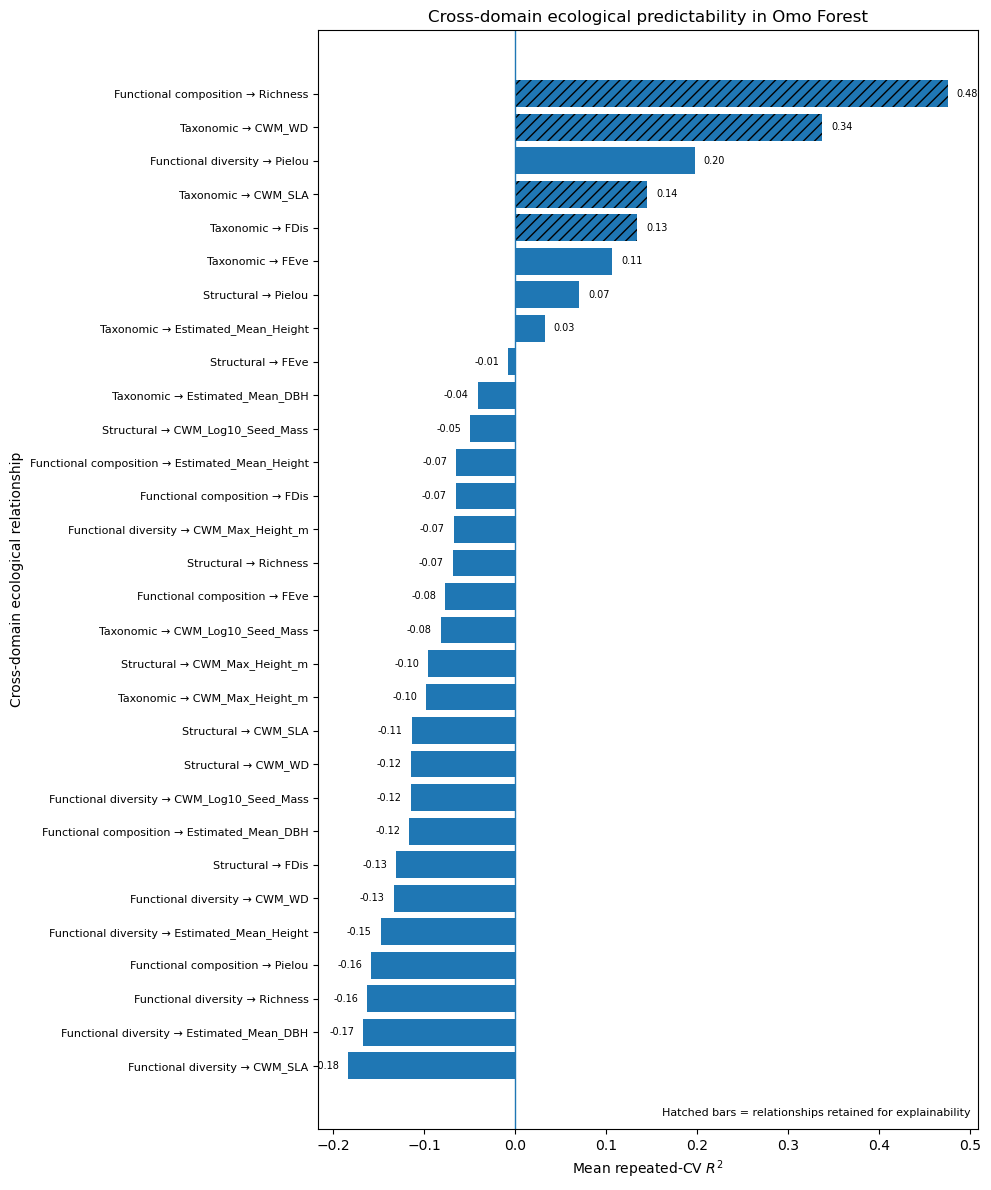

SECTION 10.1 — CROSS-DOMAIN PREDICTIVE PERFORMANCE FIGURE

Figure summary
----------------------------------------------------------------------------------------------------
Relationships displayed : 30
Retained for XAI        : 4
Positive mean R2        : 8
Negative mean R2        : 22

Top relationships
----------------------------------------------------------------------------------------------------
             Experiment_ID                        Plot_Label  Ridge_Mean  RF_Mean  Best_Observed_Model_R2     Screening_Class  Retained_For_XAI
             CD04_Richness Functional composition → Richness      0.3111   0.4751                  0.4751            MODERATE              True
               CD01_CWM_WD                Taxonomic → CWM_WD      0.3375   0.3323                  0.3375            MODERATE              True
               CD07_Pielou     Functional diversity → Pielou      0.1969   0.1174                  0.1969       WEAK_POSITIVE             False
              C

In [28]:
# ================================================================================================
# SECTION 10.1 — PUBLICATION FIGURE: CROSS-DOMAIN PREDICTIVE PERFORMANCE
# ================================================================================================

import matplotlib.pyplot as plt

# ------------------------------------------------------------------------------------------------
# Prepare plotting table
# ------------------------------------------------------------------------------------------------

performance_plot = (
    r2_screening[
        [
            "Experiment_ID",
            "Predictor_Domain",
            "Target_Domain",
            "Target",
            "Leakage_Status",
            "Ridge_Mean",
            "Screening_Class",
        ]
    ]
    .copy()
)

# Attach RF results where available
rf_lookup = (
    nonlinear_r2[
        [
            "Experiment_ID",
            "RF_Mean",
        ]
    ]
    .drop_duplicates(
        subset=["Experiment_ID"]
    )
)

performance_plot = (
    performance_plot
    .merge(
        rf_lookup,
        on="Experiment_ID",
        how="left",
        validate="one_to_one",
    )
)

# Final selected-model performance
performance_plot[
    "Best_Observed_Model_R2"
] = np.where(
    performance_plot["RF_Mean"].notna(),
    np.maximum(
        performance_plot["Ridge_Mean"],
        performance_plot["RF_Mean"],
    ),
    performance_plot["Ridge_Mean"],
)

# Mark downstream XAI relationships
selected_experiment_ids = set(
    selection_registry[
        "Experiment_ID"
    ]
)

performance_plot[
    "Retained_For_XAI"
] = (
    performance_plot[
        "Experiment_ID"
    ]
    .isin(
        selected_experiment_ids
    )
)

# Sort weakest to strongest for horizontal plotting
performance_plot = (
    performance_plot
    .sort_values(
        "Best_Observed_Model_R2",
        ascending=True,
    )
    .reset_index(drop=True)
)

# Short publication labels
performance_plot[
    "Plot_Label"
] = (
    performance_plot[
        "Predictor_Domain"
    ]
    .str.replace(
        "FUNCTIONAL_COMPOSITION",
        "Functional composition",
        regex=False,
    )
    .str.replace(
        "FUNCTIONAL_DIVERSITY",
        "Functional diversity",
        regex=False,
    )
    .str.replace(
        "TAXONOMIC",
        "Taxonomic",
        regex=False,
    )
    .str.replace(
        "STRUCTURAL",
        "Structural",
        regex=False,
    )
    +
    " → "
    +
    performance_plot[
        "Target"
    ]
)

# ------------------------------------------------------------------------------------------------
# Figure
# ------------------------------------------------------------------------------------------------

fig, ax = plt.subplots(
    figsize=(10, 12)
)

y_positions = np.arange(
    len(
        performance_plot
    )
)

bars = ax.barh(
    y_positions,
    performance_plot[
        "Best_Observed_Model_R2"
    ],
)

# ------------------------------------------------------------------------------------------------
# Highlight selected XAI experiments without using custom colors
# Use hatching instead.
# ------------------------------------------------------------------------------------------------

for i, bar in enumerate(bars):

    if performance_plot.loc[
        i,
        "Retained_For_XAI"
    ]:
        bar.set_hatch("///")
        bar.set_linewidth(1.2)

# ------------------------------------------------------------------------------------------------
# Reference line
# ------------------------------------------------------------------------------------------------

ax.axvline(
    0,
    linewidth=1,
)

# ------------------------------------------------------------------------------------------------
# Labels
# ------------------------------------------------------------------------------------------------

ax.set_yticks(
    y_positions
)

ax.set_yticklabels(
    performance_plot[
        "Plot_Label"
    ],
    fontsize=8,
)

ax.set_xlabel(
    "Mean repeated-CV $R^2$"
)

ax.set_ylabel(
    "Cross-domain ecological relationship"
)

ax.set_title(
    "Cross-domain ecological predictability in Omo Forest"
)

# ------------------------------------------------------------------------------------------------
# Add R2 values
# ------------------------------------------------------------------------------------------------

for i, value in enumerate(
    performance_plot[
        "Best_Observed_Model_R2"
    ]
):

    if value >= 0:

        ax.text(
            value + 0.01,
            i,
            f"{value:.2f}",
            va="center",
            fontsize=7,
        )

    else:

        ax.text(
            value - 0.01,
            i,
            f"{value:.2f}",
            va="center",
            ha="right",
            fontsize=7,
        )

# ------------------------------------------------------------------------------------------------
# Caption-like annotation
# ------------------------------------------------------------------------------------------------

ax.text(
    0.99,
    0.01,
    "Hatched bars = relationships retained for explainability",
    transform=ax.transAxes,
    ha="right",
    va="bottom",
    fontsize=8,
)

fig.tight_layout()

# ------------------------------------------------------------------------------------------------
# Export
# ------------------------------------------------------------------------------------------------

figure10_01_png = (
    OUTPUT_FIGURES /
    "Figure_10_01_Cross_Domain_Predictive_Performance.png"
)

figure10_01_pdf = (
    OUTPUT_FIGURES /
    "Figure_10_01_Cross_Domain_Predictive_Performance.pdf"
)

figure10_01_svg = (
    OUTPUT_FIGURES /
    "Figure_10_01_Cross_Domain_Predictive_Performance.svg"
)

fig.savefig(
    figure10_01_png,
    dpi=400,
    bbox_inches="tight",
)

fig.savefig(
    figure10_01_pdf,
    bbox_inches="tight",
)

fig.savefig(
    figure10_01_svg,
    bbox_inches="tight",
)

plt.show()

# ------------------------------------------------------------------------------------------------
# Export plotting data
# ------------------------------------------------------------------------------------------------

figure10_01_data_path = (
    OUTPUT_TABLES /
    "omo_notebook09_figure10_01_cross_domain_performance_data.csv"
)

performance_plot.to_csv(
    figure10_01_data_path,
    index=False,
)

# ------------------------------------------------------------------------------------------------
# Console report
# ------------------------------------------------------------------------------------------------

print("=" * 100)
print("SECTION 10.1 — CROSS-DOMAIN PREDICTIVE PERFORMANCE FIGURE")
print("=" * 100)

print("\nFigure summary")
print("-" * 100)

print(
    f"Relationships displayed : "
    f"{len(performance_plot)}"
)

print(
    f"Retained for XAI        : "
    f"{performance_plot['Retained_For_XAI'].sum()}"
)

print(
    f"Positive mean R2        : "
    f"{(performance_plot['Best_Observed_Model_R2'] > 0).sum()}"
)

print(
    f"Negative mean R2        : "
    f"{(performance_plot['Best_Observed_Model_R2'] < 0).sum()}"
)

print("\nTop relationships")
print("-" * 100)

print(
    performance_plot[
        [
            "Experiment_ID",
            "Plot_Label",
            "Ridge_Mean",
            "RF_Mean",
            "Best_Observed_Model_R2",
            "Screening_Class",
            "Retained_For_XAI",
        ]
    ]
    .sort_values(
        "Best_Observed_Model_R2",
        ascending=False,
    )
    .head(10)
    .round(4)
    .to_string(index=False)
)

print("\nExports")
print("-" * 100)
print(f"PNG  : {figure10_01_png}")
print(f"PDF  : {figure10_01_pdf}")
print(f"SVG  : {figure10_01_svg}")
print(f"Data : {figure10_01_data_path}")

print("\n" + "=" * 100)
print("SECTION 10.1 FIGURE COMPLETE")
print("=" * 100)

### 10.2 Functional-composition prediction and explainability of species richness

The strongest cross-domain ecological model predicts species richness from functional composition.

This figure integrates three complementary forms of evidence:

1. global permutation importance across the fitted richness model;
2. the SHAP response of species richness to community-weighted wood density; and
3. bootstrap uncertainty in the descriptive CWM-WD transition location.

The figure emphasizes that CWM wood density is the dominant functional-composition predictor of richness and that its fitted contribution is strongly positive and nonlinear.

The transition location is deliberately presented as uncertain. The full-data estimate near 0.53 g cm⁻³ is therefore shown as a descriptive reference rather than a fixed ecological threshold.

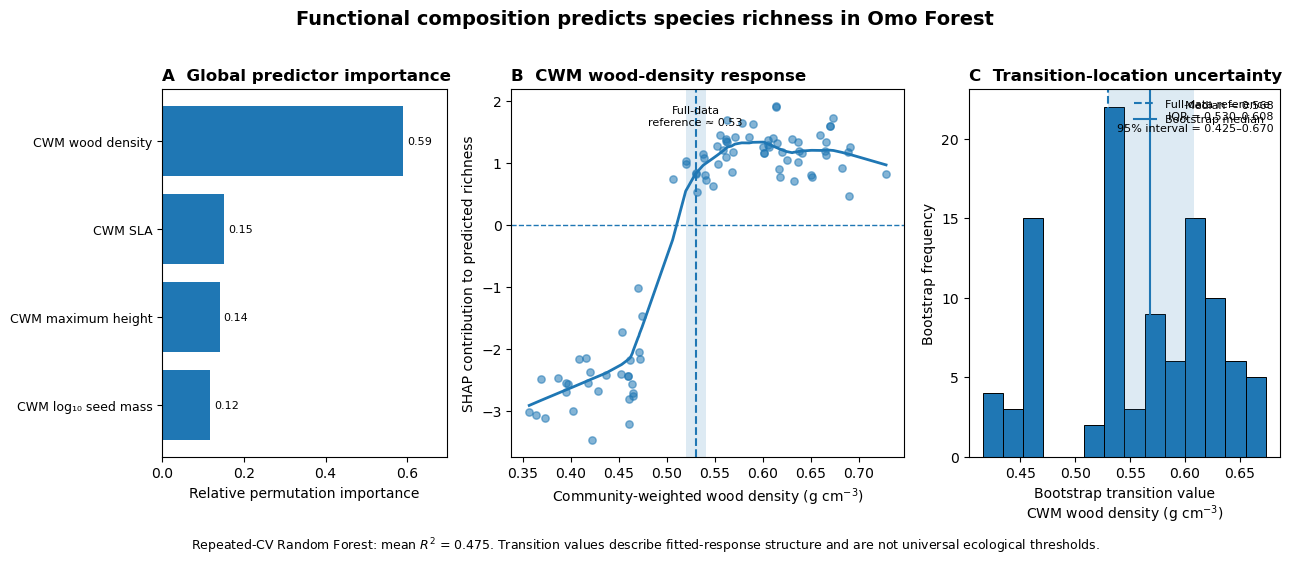

SECTION 10.2 — FUNCTIONAL COMPOSITION → RICHNESS EXPLAINABILITY FIGURE

Panel A — predictor importance
----------------------------------------------------------------------------------------------------
          Predictor  Importance_Rank  Relative_Permutation_Importance
             CWM_WD                1                           0.5905
            CWM_SLA                2                           0.1522
   CWM_Max_Height_m                3                           0.1404
CWM_Log10_Seed_Mass                4                           0.1169

Panel B — CWM-WD SHAP response
----------------------------------------------------------------------------------------------------
Observations                 : 90
Observed CWM-WD range        : 0.3567 – 0.7285
Full-data transition         : 0.5300
Full-data transition zone    : 0.5197 – 0.5411

Panel C — bootstrap transition
----------------------------------------------------------------------------------------------------
Bootstrap tran

In [29]:
# ================================================================================================
# SECTION 10.2 — PUBLICATION FIGURE: FUNCTIONAL COMPOSITION → RICHNESS EXPLAINABILITY
# ================================================================================================

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from statsmodels.nonparametric.smoothers_lowess import lowess

# ------------------------------------------------------------------------------------------------
# Configuration
# ------------------------------------------------------------------------------------------------

experiment_id = "CD04_Richness"
target = "Richness"

predictor_labels = {
    "CWM_WD": "CWM wood density",
    "CWM_SLA": "CWM SLA",
    "CWM_Log10_Seed_Mass": "CWM log₁₀ seed mass",
    "CWM_Max_Height_m": "CWM maximum height",
}

# ------------------------------------------------------------------------------------------------
# Panel A data — global permutation importance
# ------------------------------------------------------------------------------------------------

importance_data = (
    global_importance[
        global_importance["Experiment_ID"] == experiment_id
    ]
    .copy()
    .sort_values(
        "Relative_Permutation_Importance",
        ascending=True,
    )
)

importance_data[
    "Predictor_Label"
] = (
    importance_data["Predictor"]
    .map(predictor_labels)
)

# ------------------------------------------------------------------------------------------------
# Panel B data — observation-level SHAP for CWM-WD
# ------------------------------------------------------------------------------------------------

wd_shap = (
    shap_long[
        (shap_long["Experiment_ID"] == experiment_id)
        &
        (shap_long["Predictor"] == "CWM_WD")
    ]
    .copy()
    .sort_values("Predictor_Value")
    .reset_index(drop=True)
)

x_wd = (
    wd_shap["Predictor_Value"]
    .to_numpy(dtype=float)
)

y_shap = (
    wd_shap["SHAP_Value"]
    .to_numpy(dtype=float)
)

wd_lowess = lowess(
    endog=y_shap,
    exog=x_wd,
    frac=0.35,
    it=1,
    return_sorted=True,
)

# Full-data descriptive transition
transition_row = (
    transition_summary[
        (transition_summary["Experiment_ID"] == experiment_id)
        &
        (transition_summary["Predictor"] == "CWM_WD")
    ]
    .iloc[0]
)

full_transition = float(
    transition_row["Dominant_Turning_Value"]
)

full_zone_low = float(
    transition_row["Transition_Zone_Low"]
)

full_zone_high = float(
    transition_row["Transition_Zone_High"]
)

# ------------------------------------------------------------------------------------------------
# Panel C data — bootstrap transition distribution
# ------------------------------------------------------------------------------------------------

bootstrap_plot = (
    bootstrap_transition_results[
        bootstrap_transition_results[
            "Turning_Point_Detected"
        ]
    ]
    .copy()
)

bootstrap_values = (
    bootstrap_plot[
        "Dominant_Turning_Value"
    ]
    .dropna()
    .to_numpy(dtype=float)
)

bootstrap_median = float(
    bootstrap_summary[
        "Bootstrap_Transition_Median"
    ]
    .iloc[0]
)

bootstrap_q25 = float(
    bootstrap_summary[
        "Bootstrap_Q25"
    ]
    .iloc[0]
)

bootstrap_q75 = float(
    bootstrap_summary[
        "Bootstrap_Q75"
    ]
    .iloc[0]
)

bootstrap_q025 = float(
    bootstrap_summary[
        "Bootstrap_Q2.5"
    ]
    .iloc[0]
)

bootstrap_q975 = float(
    bootstrap_summary[
        "Bootstrap_Q97.5"
    ]
    .iloc[0]
)

# ------------------------------------------------------------------------------------------------
# Figure architecture
# ------------------------------------------------------------------------------------------------

fig = plt.figure(
    figsize=(13, 5.2)
)

gs = fig.add_gridspec(
    1,
    3,
    width_ratios=[
        1.05,
        1.45,
        1.15,
    ],
)

ax_a = fig.add_subplot(
    gs[0, 0]
)

ax_b = fig.add_subplot(
    gs[0, 1]
)

ax_c = fig.add_subplot(
    gs[0, 2]
)

# ================================================================================================
# PANEL A — PERMUTATION IMPORTANCE
# ================================================================================================

y_positions = np.arange(
    len(importance_data)
)

bars = ax_a.barh(
    y_positions,
    importance_data[
        "Relative_Permutation_Importance"
    ],
)

ax_a.set_yticks(
    y_positions
)

ax_a.set_yticklabels(
    importance_data[
        "Predictor_Label"
    ],
    fontsize=9,
)

ax_a.set_xlabel(
    "Relative permutation importance"
)

ax_a.set_title(
    "A  Global predictor importance",
    loc="left",
    fontweight="bold",
)

for i, value in enumerate(
    importance_data[
        "Relative_Permutation_Importance"
    ]
):

    ax_a.text(
        value + 0.01,
        i,
        f"{value:.2f}",
        va="center",
        fontsize=8,
    )

ax_a.set_xlim(
    0,
    max(
        importance_data[
            "Relative_Permutation_Importance"
        ].max()
        * 1.18,
        0.65,
    ),
)

# ================================================================================================
# PANEL B — SHAP DEPENDENCE
# ================================================================================================

ax_b.scatter(
    x_wd,
    y_shap,
    alpha=0.55,
    s=28,
)

ax_b.plot(
    wd_lowess[:, 0],
    wd_lowess[:, 1],
    linewidth=2,
)

ax_b.axhline(
    0,
    linewidth=1,
    linestyle="--",
)

# Full-data transition zone
ax_b.axvspan(
    full_zone_low,
    full_zone_high,
    alpha=0.15,
)

ax_b.axvline(
    full_transition,
    linewidth=1.5,
    linestyle="--",
)

ax_b.set_xlabel(
    "Community-weighted wood density (g cm$^{-3}$)"
)

ax_b.set_ylabel(
    "SHAP contribution to predicted richness"
)

ax_b.set_title(
    "B  CWM wood-density response",
    loc="left",
    fontweight="bold",
)

ax_b.text(
    full_transition,
    ax_b.get_ylim()[1] * 0.88,
    f"Full-data\nreference ≈ {full_transition:.2f}",
    ha="center",
    va="top",
    fontsize=8,
)

# ================================================================================================
# PANEL C — BOOTSTRAP TRANSITION STABILITY
# ================================================================================================

ax_c.hist(
    bootstrap_values,
    bins=14,
    edgecolor="black",
    linewidth=0.7,
)

ax_c.axvline(
    full_transition,
    linewidth=1.5,
    linestyle="--",
    label="Full-data reference",
)

ax_c.axvline(
    bootstrap_median,
    linewidth=1.5,
    linestyle="-",
    label="Bootstrap median",
)

ax_c.axvspan(
    bootstrap_q25,
    bootstrap_q75,
    alpha=0.15,
)

ax_c.set_xlabel(
    "Bootstrap transition value\nCWM wood density (g cm$^{-3}$)"
)

ax_c.set_ylabel(
    "Bootstrap frequency"
)

ax_c.set_title(
    "C  Transition-location uncertainty",
    loc="left",
    fontweight="bold",
)

ax_c.legend(
    fontsize=8,
    frameon=False,
)

# Bootstrap annotation
annotation_text = (
    f"Median = {bootstrap_median:.3f}\n"
    f"IQR = {bootstrap_q25:.3f}–{bootstrap_q75:.3f}\n"
    f"95% interval = {bootstrap_q025:.3f}–{bootstrap_q975:.3f}"
)

ax_c.text(
    0.98,
    0.97,
    annotation_text,
    transform=ax_c.transAxes,
    ha="right",
    va="top",
    fontsize=8,
)

# ------------------------------------------------------------------------------------------------
# Figure-level annotation
# ------------------------------------------------------------------------------------------------

fig.suptitle(
    "Functional composition predicts species richness in Omo Forest",
    fontsize=14,
    fontweight="bold",
    y=1.02,
)

fig.text(
    0.5,
    -0.02,
    (
        "Repeated-CV Random Forest: mean $R^2$ = 0.475. "
        "Transition values describe fitted-response structure and are not universal ecological thresholds."
    ),
    ha="center",
    fontsize=9,
)

fig.tight_layout()

# ------------------------------------------------------------------------------------------------
# Export
# ------------------------------------------------------------------------------------------------

figure10_02_png = (
    OUTPUT_FIGURES /
    "Figure_10_02_Functional_Composition_Richness_XAI.png"
)

figure10_02_pdf = (
    OUTPUT_FIGURES /
    "Figure_10_02_Functional_Composition_Richness_XAI.pdf"
)

figure10_02_svg = (
    OUTPUT_FIGURES /
    "Figure_10_02_Functional_Composition_Richness_XAI.svg"
)

fig.savefig(
    figure10_02_png,
    dpi=400,
    bbox_inches="tight",
)

fig.savefig(
    figure10_02_pdf,
    bbox_inches="tight",
)

fig.savefig(
    figure10_02_svg,
    bbox_inches="tight",
)

plt.show()

# ------------------------------------------------------------------------------------------------
# Export figure-specific data
# ------------------------------------------------------------------------------------------------

importance_export_path = (
    OUTPUT_TABLES /
    "omo_notebook09_figure10_02_permutation_importance_data.csv"
)

wd_shap_export_path = (
    OUTPUT_TABLES /
    "omo_notebook09_figure10_02_cwmwd_shap_data.csv"
)

bootstrap_export_path = (
    OUTPUT_TABLES /
    "omo_notebook09_figure10_02_transition_bootstrap_data.csv"
)

importance_data.to_csv(
    importance_export_path,
    index=False,
)

wd_shap.to_csv(
    wd_shap_export_path,
    index=False,
)

bootstrap_plot.to_csv(
    bootstrap_export_path,
    index=False,
)

# ------------------------------------------------------------------------------------------------
# Console report
# ------------------------------------------------------------------------------------------------

print("=" * 100)
print("SECTION 10.2 — FUNCTIONAL COMPOSITION → RICHNESS EXPLAINABILITY FIGURE")
print("=" * 100)

print("\nPanel A — predictor importance")
print("-" * 100)

print(
    importance_data[
        [
            "Predictor",
            "Importance_Rank",
            "Relative_Permutation_Importance",
        ]
    ]
    .sort_values(
        "Importance_Rank"
    )
    .round(4)
    .to_string(index=False)
)

print("\nPanel B — CWM-WD SHAP response")
print("-" * 100)

print(
    f"Observations                 : "
    f"{len(wd_shap)}"
)

print(
    f"Observed CWM-WD range        : "
    f"{x_wd.min():.4f} – {x_wd.max():.4f}"
)

print(
    f"Full-data transition         : "
    f"{full_transition:.4f}"
)

print(
    f"Full-data transition zone    : "
    f"{full_zone_low:.4f} – {full_zone_high:.4f}"
)

print("\nPanel C — bootstrap transition")
print("-" * 100)

print(
    f"Bootstrap transitions        : "
    f"{len(bootstrap_values)}"
)

print(
    f"Bootstrap median             : "
    f"{bootstrap_median:.4f}"
)

print(
    f"Bootstrap IQR                : "
    f"{bootstrap_q25:.4f} – {bootstrap_q75:.4f}"
)

print(
    f"Bootstrap 95% interval       : "
    f"{bootstrap_q025:.4f} – {bootstrap_q975:.4f}"
)

print("\nScientific interpretation")
print("-" * 100)

print(
    "CWM-WD is the dominant functional-composition predictor of richness."
)

print(
    "The fitted relationship is positive and nonlinear."
)

print(
    "The transition-like response is reproducible, but its exact location is uncertain."
)

print("\nExports")
print("-" * 100)

print(f"PNG  : {figure10_02_png}")
print(f"PDF  : {figure10_02_pdf}")
print(f"SVG  : {figure10_02_svg}")

print(
    f"Importance data : "
    f"{importance_export_path}"
)

print(
    f"SHAP data       : "
    f"{wd_shap_export_path}"
)

print(
    f"Bootstrap data  : "
    f"{bootstrap_export_path}"
)

print("\n" + "=" * 100)
print("SECTION 10.2 FIGURE COMPLETE")
print("=" * 100)

### 10.3 Contextual concentration of predictive uncertainty

Repeated out-of-fold prediction analysis showed that uncertainty is not uniformly distributed across the Omo plot system.

This figure summarizes recurrent cross-model uncertainty across the balanced Habitat × Management Zone design.

The plotted quantity is the percentage of plots within each Habitat × Zone cell classified as recurrent moderate-or-high uncertainty across the three primary cross-domain models.

This representation highlights contextual concentration of model instability while preserving the important interpretive boundary that predictive uncertainty is not equivalent to ecological degradation or disturbance.

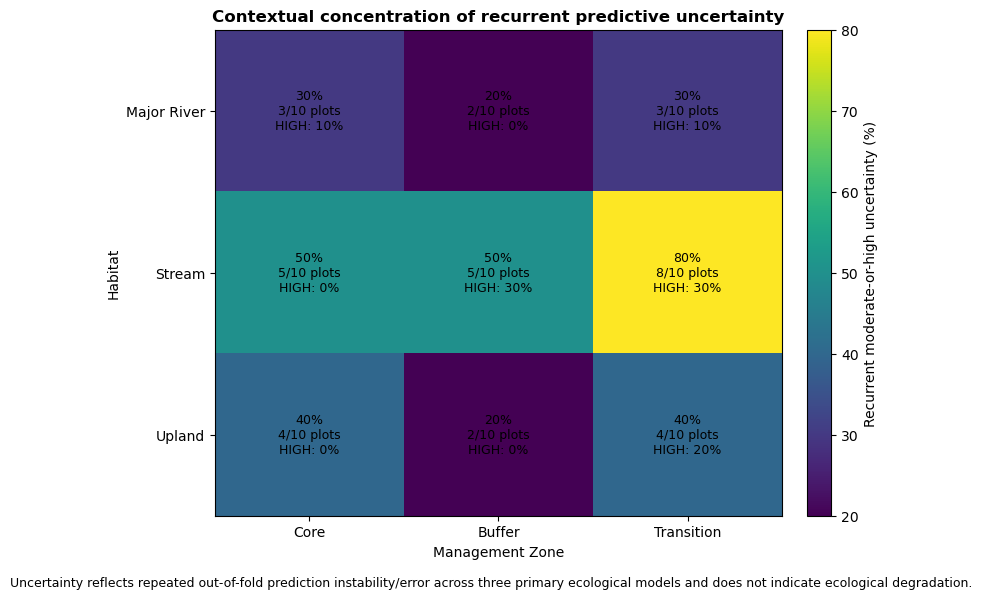

SECTION 10.3 — CONTEXTUAL PREDICTIVE UNCERTAINTY FIGURE

Habitat × Zone recurrent uncertainty
----------------------------------------------------------------------------------------------------
    Habitat       Zone  N_Plots  Recurrent_High_Plots  Recurrent_Moderate_or_High_Plots  Recurrent_High_Percent  Recurrent_Moderate_or_High_Percent
     Stream Transition       10                     3                                 8                    30.0                                80.0
     Stream     Buffer       10                     3                                 5                    30.0                                50.0
     Stream       Core       10                     0                                 5                     0.0                                50.0
     Upland Transition       10                     2                                 4                    20.0                                40.0
     Upland       Core       10                     0            

In [30]:
# ================================================================================================
# SECTION 10.3 — PUBLICATION FIGURE: CONTEXTUAL CONCENTRATION OF PREDICTIVE UNCERTAINTY
# ================================================================================================

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# ------------------------------------------------------------------------------------------------
# Prepare matrix
# ------------------------------------------------------------------------------------------------

heatmap_data = (
    context_concentration[
        [
            "Habitat",
            "Zone",
            "N_Plots",
            "Recurrent_High_Plots",
            "Recurrent_Moderate_or_High_Plots",
            "Recurrent_High_Percent",
            "Recurrent_Moderate_or_High_Percent",
        ]
    ]
    .copy()
)

habitat_order = [
    "Major River",
    "Stream",
    "Upland",
]

zone_order = [
    "Core",
    "Buffer",
    "Transition",
]

uncertainty_matrix = (
    heatmap_data
    .pivot(
        index="Habitat",
        columns="Zone",
        values="Recurrent_Moderate_or_High_Percent",
    )
    .reindex(
        index=habitat_order,
        columns=zone_order,
    )
)

high_matrix = (
    heatmap_data
    .pivot(
        index="Habitat",
        columns="Zone",
        values="Recurrent_High_Percent",
    )
    .reindex(
        index=habitat_order,
        columns=zone_order,
    )
)

count_matrix = (
    heatmap_data
    .pivot(
        index="Habitat",
        columns="Zone",
        values="Recurrent_Moderate_or_High_Plots",
    )
    .reindex(
        index=habitat_order,
        columns=zone_order,
    )
)

# ------------------------------------------------------------------------------------------------
# Figure
# ------------------------------------------------------------------------------------------------

fig, ax = plt.subplots(
    figsize=(8, 5.8)
)

image = ax.imshow(
    uncertainty_matrix.to_numpy(),
    aspect="auto",
)

# ------------------------------------------------------------------------------------------------
# Axis labels
# ------------------------------------------------------------------------------------------------

ax.set_xticks(
    np.arange(
        len(zone_order)
    )
)

ax.set_xticklabels(
    zone_order,
    fontsize=10,
)

ax.set_yticks(
    np.arange(
        len(habitat_order)
    )
)

ax.set_yticklabels(
    habitat_order,
    fontsize=10,
)

ax.set_xlabel(
    "Management Zone"
)

ax.set_ylabel(
    "Habitat"
)

ax.set_title(
    "Contextual concentration of recurrent predictive uncertainty",
    fontweight="bold",
)

# ------------------------------------------------------------------------------------------------
# Cell annotations
# ------------------------------------------------------------------------------------------------

for i, habitat in enumerate(
    habitat_order
):

    for j, zone in enumerate(
        zone_order
    ):

        pct = float(
            uncertainty_matrix.loc[
                habitat,
                zone,
            ]
        )

        high_pct = float(
            high_matrix.loc[
                habitat,
                zone,
            ]
        )

        n_modhigh = int(
            count_matrix.loc[
                habitat,
                zone,
            ]
        )

        annotation = (
            f"{pct:.0f}%\n"
            f"{n_modhigh}/10 plots\n"
            f"HIGH: {high_pct:.0f}%"
        )

        ax.text(
            j,
            i,
            annotation,
            ha="center",
            va="center",
            fontsize=9,
        )

# ------------------------------------------------------------------------------------------------
# Colorbar
# ------------------------------------------------------------------------------------------------

cbar = fig.colorbar(
    image,
    ax=ax,
    fraction=0.045,
    pad=0.04,
)

cbar.set_label(
    "Recurrent moderate-or-high uncertainty (%)"
)

# ------------------------------------------------------------------------------------------------
# Caption note
# ------------------------------------------------------------------------------------------------

fig.text(
    0.5,
    -0.02,
    (
        "Uncertainty reflects repeated out-of-fold prediction instability/error across "
        "three primary ecological models and does not indicate ecological degradation."
    ),
    ha="center",
    fontsize=9,
)

fig.tight_layout()

# ------------------------------------------------------------------------------------------------
# Export
# ------------------------------------------------------------------------------------------------

figure10_03_png = (
    OUTPUT_FIGURES /
    "Figure_10_03_Contextual_Predictive_Uncertainty.png"
)

figure10_03_pdf = (
    OUTPUT_FIGURES /
    "Figure_10_03_Contextual_Predictive_Uncertainty.pdf"
)

figure10_03_svg = (
    OUTPUT_FIGURES /
    "Figure_10_03_Contextual_Predictive_Uncertainty.svg"
)

fig.savefig(
    figure10_03_png,
    dpi=400,
    bbox_inches="tight",
)

fig.savefig(
    figure10_03_pdf,
    bbox_inches="tight",
)

fig.savefig(
    figure10_03_svg,
    bbox_inches="tight",
)

plt.show()

# ------------------------------------------------------------------------------------------------
# Export plotting data
# ------------------------------------------------------------------------------------------------

figure10_03_data_path = (
    OUTPUT_TABLES /
    "omo_notebook09_figure10_03_context_uncertainty_data.csv"
)

heatmap_data.to_csv(
    figure10_03_data_path,
    index=False,
)

# ------------------------------------------------------------------------------------------------
# Console report
# ------------------------------------------------------------------------------------------------

print("=" * 100)
print("SECTION 10.3 — CONTEXTUAL PREDICTIVE UNCERTAINTY FIGURE")
print("=" * 100)

print("\nHabitat × Zone recurrent uncertainty")
print("-" * 100)

print(
    heatmap_data[
        [
            "Habitat",
            "Zone",
            "N_Plots",
            "Recurrent_High_Plots",
            "Recurrent_Moderate_or_High_Plots",
            "Recurrent_High_Percent",
            "Recurrent_Moderate_or_High_Percent",
        ]
    ]
    .sort_values(
        [
            "Recurrent_Moderate_or_High_Percent",
            "Recurrent_High_Percent",
        ],
        ascending=False,
    )
    .round(4)
    .to_string(index=False)
)

print("\nHighest-uncertainty context")
print("-" * 100)

highest_row = (
    heatmap_data
    .sort_values(
        [
            "Recurrent_Moderate_or_High_Percent",
            "Recurrent_High_Percent",
        ],
        ascending=False,
    )
    .iloc[0]
)

print(
    f"Habitat                      : "
    f"{highest_row['Habitat']}"
)

print(
    f"Zone                         : "
    f"{highest_row['Zone']}"
)

print(
    f"Recurrent moderate-or-high  : "
    f"{highest_row['Recurrent_Moderate_or_High_Plots']:.0f}/10 "
    f"({highest_row['Recurrent_Moderate_or_High_Percent']:.1f}%)"
)

print(
    f"Recurrent HIGH              : "
    f"{highest_row['Recurrent_High_Plots']:.0f}/10 "
    f"({highest_row['Recurrent_High_Percent']:.1f}%)"
)

print("\nInterpretive boundary")
print("-" * 100)

print(
    "Predictive uncertainty reflects model stability/error across ecological relationships."
)

print(
    "It does NOT directly measure degradation, disturbance or management failure."
)

print("\nExports")
print("-" * 100)

print(f"PNG  : {figure10_03_png}")
print(f"PDF  : {figure10_03_pdf}")
print(f"SVG  : {figure10_03_svg}")
print(f"Data : {figure10_03_data_path}")

print("\n" + "=" * 100)
print("SECTION 10.3 FIGURE COMPLETE")
print("=" * 100)

### 10.4 Monitoring-oriented ecological information priorities

The ecological-informatics analyses identify a compact set of variables with comparatively high value for repeat monitoring of the Omo forest system.

Monitoring priority integrates evidence from selected predictive relationships, global permutation importance, SHAP importance, linear-model contribution and transition-response evidence.

Species richness and community-weighted wood density emerge as the two highest-priority variables, with Pielou evenness providing complementary information.

These priorities reflect information content within the current Omo dataset. They do not constitute an ecological-condition index, and the scores should not be interpreted as absolute measures of ecological importance.

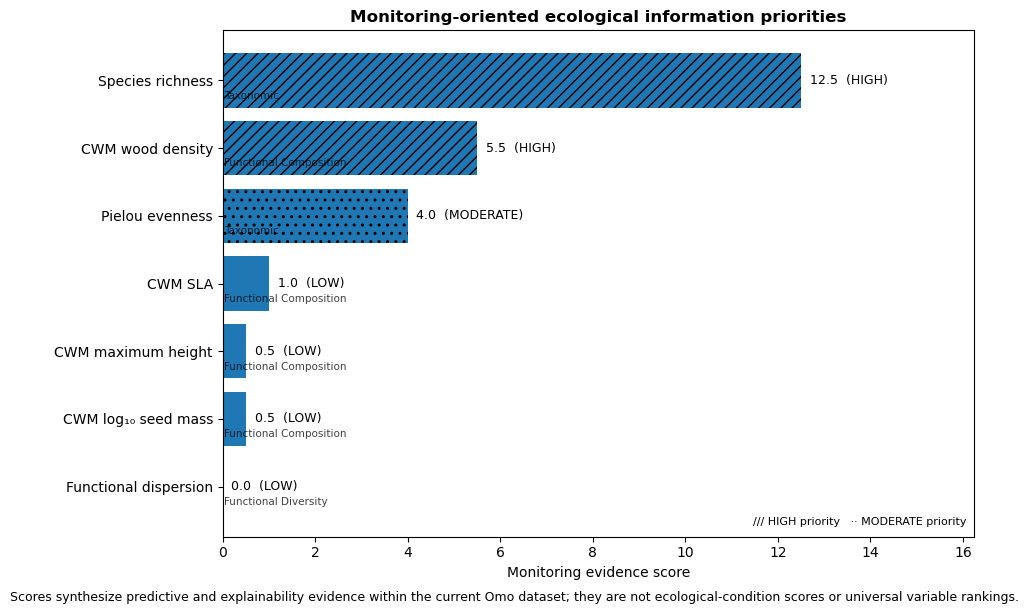

SECTION 10.4 — MONITORING-ORIENTED ECOLOGICAL INFORMATION PRIORITIES

Section 9.1 score reconstruction
----------------------------------------------------------------------------------------------------
Variable  Expected_Score  Observed_Score Validation_Status
Richness            12.5            12.5              PASS
  CWM_WD             5.5             5.5              PASS
  Pielou             4.0             4.0              PASS

Monitoring priorities
----------------------------------------------------------------------------------------------------
           Variable                 Domain  Monitoring_Evidence_Score Monitoring_Priority
           Richness              TAXONOMIC                       12.5                HIGH
             CWM_WD FUNCTIONAL_COMPOSITION                        5.5                HIGH
             Pielou              TAXONOMIC                        4.0            MODERATE
            CWM_SLA FUNCTIONAL_COMPOSITION                        1.0       

In [32]:
# ================================================================================================
# SECTION 10.4 — PUBLICATION FIGURE: MONITORING-ORIENTED ECOLOGICAL INFORMATION PRIORITIES
# ================================================================================================

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# ------------------------------------------------------------------------------------------------
# Resolve authoritative monitoring synthesis object
# ------------------------------------------------------------------------------------------------

if "monitoring_variable_synthesis" in globals():

    monitoring_source = (
        monitoring_variable_synthesis
        .copy()
    )

else:

    # Safe fallback to the authoritative Section 9.1 export
    monitoring_synthesis_path = (
        OUTPUT_TABLES /
        "omo_notebook09_monitoring_variable_synthesis.csv"
    )

    if not monitoring_synthesis_path.exists():

        raise FileNotFoundError(
            "Authoritative monitoring synthesis was not found in memory "
            "or on disk:\n"
            f"{monitoring_synthesis_path}"
        )

    monitoring_source = pd.read_csv(
        monitoring_synthesis_path
    )

# ------------------------------------------------------------------------------------------------
# Prepare monitoring-priority data
# ------------------------------------------------------------------------------------------------

monitoring_plot = (
    monitoring_source
    .copy()
    .sort_values(
        "Monitoring_Evidence_Score",
        ascending=True,
    )
    .reset_index(drop=True)
)

variable_labels = {
    "Richness": "Species richness",
    "CWM_WD": "CWM wood density",
    "Pielou": "Pielou evenness",
    "CWM_SLA": "CWM SLA",
    "CWM_Log10_Seed_Mass": "CWM log₁₀ seed mass",
    "CWM_Max_Height_m": "CWM maximum height",
    "FDis": "Functional dispersion",
}

monitoring_plot[
    "Variable_Label"
] = (
    monitoring_plot[
        "Variable"
    ]
    .map(
        variable_labels
    )
    .fillna(
        monitoring_plot[
            "Variable"
        ]
    )
)

# ------------------------------------------------------------------------------------------------
# Validation
# ------------------------------------------------------------------------------------------------

required_columns = [
    "Variable",
    "Domain",
    "Monitoring_Evidence_Score",
    "Monitoring_Priority",
]

missing_columns = [
    column
    for column in required_columns
    if column not in monitoring_plot.columns
]

if missing_columns:

    raise ValueError(
        "Missing monitoring columns: "
        + ", ".join(
            missing_columns
        )
    )

if monitoring_plot[
    "Variable"
].duplicated().any():

    duplicate_variables = (
        monitoring_plot.loc[
            monitoring_plot[
                "Variable"
            ].duplicated(
                keep=False
            ),
            "Variable",
        ]
        .tolist()
    )

    raise ValueError(
        "Duplicate monitoring variables detected: "
        + ", ".join(
            map(
                str,
                duplicate_variables,
            )
        )
    )

# ------------------------------------------------------------------------------------------------
# Confirm expected Section 9.1 monitoring hierarchy
# ------------------------------------------------------------------------------------------------

expected_scores = {
    "Richness": 12.5,
    "CWM_WD": 5.5,
    "Pielou": 4.0,
}

score_validation_records = []

for variable, expected_score in expected_scores.items():

    match = monitoring_plot[
        monitoring_plot[
            "Variable"
        ]
        == variable
    ]

    if len(match) != 1:

        score_validation_records.append({
            "Variable":
                variable,

            "Expected_Score":
                expected_score,

            "Observed_Score":
                np.nan,

            "Validation_Status":
                "REVIEW",
        })

        continue

    observed_score = float(
        match[
            "Monitoring_Evidence_Score"
        ]
        .iloc[0]
    )

    score_validation_records.append({
        "Variable":
            variable,

        "Expected_Score":
            expected_score,

        "Observed_Score":
            observed_score,

        "Validation_Status":
            (
                "PASS"
                if np.isclose(
                    observed_score,
                    expected_score,
                )
                else "REVIEW"
            ),
    })

score_validation = pd.DataFrame(
    score_validation_records
)

if not (
    score_validation[
        "Validation_Status"
    ]
    == "PASS"
).all():

    raise ValueError(
        "Section 10.4 monitoring scores do not reproduce "
        "the authoritative Section 9.1 results."
    )

# ------------------------------------------------------------------------------------------------
# Figure
# ------------------------------------------------------------------------------------------------

fig, ax = plt.subplots(
    figsize=(9.5, 6.0)
)

y_positions = np.arange(
    len(
        monitoring_plot
    )
)

bars = ax.barh(
    y_positions,
    monitoring_plot[
        "Monitoring_Evidence_Score"
    ],
)

ax.set_yticks(
    y_positions
)

ax.set_yticklabels(
    monitoring_plot[
        "Variable_Label"
    ],
    fontsize=10,
)

ax.set_xlabel(
    "Monitoring evidence score"
)

ax.set_ylabel(
    ""
)

ax.set_title(
    "Monitoring-oriented ecological information priorities",
    fontweight="bold",
)

# ------------------------------------------------------------------------------------------------
# Highlight HIGH / MODERATE monitoring variables using hatching rather than custom colors
# ------------------------------------------------------------------------------------------------

for i, bar in enumerate(
    bars
):

    priority = (
        monitoring_plot.loc[
            i,
            "Monitoring_Priority"
        ]
    )

    if priority == "HIGH":

        bar.set_hatch(
            "///"
        )

        bar.set_linewidth(
            1.2
        )

    elif priority == "MODERATE":

        bar.set_hatch(
            ".."
        )

        bar.set_linewidth(
            1.0
        )

# ------------------------------------------------------------------------------------------------
# Score and priority annotations
# ------------------------------------------------------------------------------------------------

maximum_score = float(
    monitoring_plot[
        "Monitoring_Evidence_Score"
    ]
    .max()
)

for i, row in monitoring_plot.iterrows():

    score = float(
        row[
            "Monitoring_Evidence_Score"
        ]
    )

    priority = str(
        row[
            "Monitoring_Priority"
        ]
    )

    ax.text(
        score
        +
        maximum_score
        * 0.015,

        i,

        f"{score:.1f}  ({priority})",

        va="center",

        fontsize=9,
    )

ax.set_xlim(
    0,
    maximum_score
    * 1.30,
)

# ------------------------------------------------------------------------------------------------
# Domain annotations
# ------------------------------------------------------------------------------------------------

for i, row in monitoring_plot.iterrows():

    domain_label = (
        str(
            row[
                "Domain"
            ]
        )
        .replace(
            "_",
            " ",
        )
        .title()
    )

    ax.text(
        0.02,
        i - 0.27,
        domain_label,
        fontsize=7.5,
        alpha=0.75,
    )

# ------------------------------------------------------------------------------------------------
# Add compact legend note
# ------------------------------------------------------------------------------------------------

ax.text(
    0.99,
    0.02,
    "/// HIGH priority   ·· MODERATE priority",
    transform=ax.transAxes,
    ha="right",
    va="bottom",
    fontsize=8,
)

# ------------------------------------------------------------------------------------------------
# Figure note
# ------------------------------------------------------------------------------------------------

fig.text(
    0.5,
    -0.01,
    (
        "Scores synthesize predictive and explainability evidence within the current "
        "Omo dataset; they are not ecological-condition scores or universal variable rankings."
    ),
    ha="center",
    fontsize=9,
)

fig.tight_layout()

# ------------------------------------------------------------------------------------------------
# Export figure
# ------------------------------------------------------------------------------------------------

figure10_04_png = (
    OUTPUT_FIGURES /
    "Figure_10_04_Monitoring_Information_Priorities.png"
)

figure10_04_pdf = (
    OUTPUT_FIGURES /
    "Figure_10_04_Monitoring_Information_Priorities.pdf"
)

figure10_04_svg = (
    OUTPUT_FIGURES /
    "Figure_10_04_Monitoring_Information_Priorities.svg"
)

fig.savefig(
    figure10_04_png,
    dpi=400,
    bbox_inches="tight",
)

fig.savefig(
    figure10_04_pdf,
    bbox_inches="tight",
)

fig.savefig(
    figure10_04_svg,
    bbox_inches="tight",
)

plt.show()

# ------------------------------------------------------------------------------------------------
# Export figure-specific data and validation
# ------------------------------------------------------------------------------------------------

figure10_04_data_path = (
    OUTPUT_TABLES /
    "omo_notebook09_figure10_04_monitoring_priority_data.csv"
)

figure10_04_validation_path = (
    OUTPUT_VALIDATION /
    "omo_notebook09_figure10_04_monitoring_score_validation.csv"
)

monitoring_plot.to_csv(
    figure10_04_data_path,
    index=False,
)

score_validation.to_csv(
    figure10_04_validation_path,
    index=False,
)

# ------------------------------------------------------------------------------------------------
# Console report
# ------------------------------------------------------------------------------------------------

print("=" * 100)
print("SECTION 10.4 — MONITORING-ORIENTED ECOLOGICAL INFORMATION PRIORITIES")
print("=" * 100)

print("\nSection 9.1 score reconstruction")
print("-" * 100)

print(
    score_validation
    .round(4)
    .to_string(
        index=False
    )
)

print("\nMonitoring priorities")
print("-" * 100)

print(
    monitoring_plot[
        [
            "Variable",
            "Domain",
            "Monitoring_Evidence_Score",
            "Monitoring_Priority",
        ]
    ]
    .sort_values(
        "Monitoring_Evidence_Score",
        ascending=False,
    )
    .round(4)
    .to_string(
        index=False
    )
)

# ------------------------------------------------------------------------------------------------
# Priority-class summary
# ------------------------------------------------------------------------------------------------

print("\nPriority-class distribution")
print("-" * 100)

priority_counts = (
    monitoring_plot[
        "Monitoring_Priority"
    ]
    .value_counts()
)

print(
    priority_counts
    .to_string()
)

# ------------------------------------------------------------------------------------------------
# Recommended compact monitoring set
# ------------------------------------------------------------------------------------------------

recommended_compact = (
    monitoring_plot[
        monitoring_plot[
            "Monitoring_Priority"
        ]
        .isin(
            [
                "HIGH",
                "MODERATE",
            ]
        )
    ]
    .sort_values(
        "Monitoring_Evidence_Score",
        ascending=False,
    )
)

print("\nRecommended compact monitoring set")
print("-" * 100)

print(
    recommended_compact[
        [
            "Variable",
            "Domain",
            "Monitoring_Evidence_Score",
            "Monitoring_Priority",
        ]
    ]
    .round(4)
    .to_string(
        index=False
    )
)

# ------------------------------------------------------------------------------------------------
# Contextual stratification
# ------------------------------------------------------------------------------------------------

print("\nRecommended contextual stratification")
print("-" * 100)

print(
    "Habitat × Management Zone"
)

print(
    "Particular attention: Stream × Transition, "
    "which showed the strongest recurrent predictive uncertainty."
)

# ------------------------------------------------------------------------------------------------
# Scientific interpretation
# ------------------------------------------------------------------------------------------------

print("\nScientific interpretation")
print("-" * 100)

print(
    "Species richness is the strongest monitoring-oriented information variable."
)

print(
    "CWM wood density provides the strongest complementary "
    "functional-composition signal."
)

print(
    "Pielou evenness provides additional taxonomic/community-organization information."
)

print(
    "Habitat × Zone should be retained as sampling/contextual stratification."
)

# ------------------------------------------------------------------------------------------------
# Interpretive boundary
# ------------------------------------------------------------------------------------------------

print("\nInterpretive boundary")
print("-" * 100)

print(
    "Monitoring scores summarize information content within the current Omo dataset."
)

print(
    "They are NOT ecological-condition scores and do NOT define a new composite index."
)

# ------------------------------------------------------------------------------------------------
# Exports
# ------------------------------------------------------------------------------------------------

print("\nExports")
print("-" * 100)

print(
    f"PNG        : "
    f"{figure10_04_png}"
)

print(
    f"PDF        : "
    f"{figure10_04_pdf}"
)

print(
    f"SVG        : "
    f"{figure10_04_svg}"
)

print(
    f"Data       : "
    f"{figure10_04_data_path}"
)

print(
    f"Validation : "
    f"{figure10_04_validation_path}"
)

print("\n" + "=" * 100)
print("SECTION 10.4 FIGURE COMPLETE")
print("=" * 100)

### 10.5 Final publication-product registry and audit

Notebook 09 has generated a restricted set of publication-oriented figures and synthesis tables.

This subsection registers the authoritative figure and table products, validates their existence, and confirms that each publication product is traceable to an underlying analytical dataset.

The audit is intended to ensure that:

- no figure is orphaned from its source data;
- all principal outputs exist in reproducible formats;
- publication products correspond to locked analytical results; and
- the notebook can be closed with a complete evidence trail.

In [34]:
# ================================================================================================
# SECTION 10.5 — FINAL PUBLICATION-PRODUCT REGISTRY AND AUDIT
# ================================================================================================

from pathlib import Path
import pandas as pd

# ------------------------------------------------------------------------------------------------
# Figure registry
# ------------------------------------------------------------------------------------------------

figure_registry = pd.DataFrame(
    [
        {
            "Figure_ID": "Figure_10_01",
            "Title": "Cross-domain predictive performance",
            "PNG": OUTPUT_FIGURES / "Figure_10_01_Cross_Domain_Predictive_Performance.png",
            "PDF": OUTPUT_FIGURES / "Figure_10_01_Cross_Domain_Predictive_Performance.pdf",
            "SVG": OUTPUT_FIGURES / "Figure_10_01_Cross_Domain_Predictive_Performance.svg",
            "Data": OUTPUT_TABLES / "omo_notebook09_figure10_01_cross_domain_performance_data.csv",
        },
        {
            "Figure_ID": "Figure_10_02",
            "Title": "Functional composition → richness explainability",
            "PNG": OUTPUT_FIGURES / "Figure_10_02_Functional_Composition_Richness_XAI.png",
            "PDF": OUTPUT_FIGURES / "Figure_10_02_Functional_Composition_Richness_XAI.pdf",
            "SVG": OUTPUT_FIGURES / "Figure_10_02_Functional_Composition_Richness_XAI.svg",
            "Data": OUTPUT_TABLES / "omo_notebook09_figure10_02_permutation_importance_data.csv",
        },
        {
            "Figure_ID": "Figure_10_03",
            "Title": "Contextual predictive uncertainty",
            "PNG": OUTPUT_FIGURES / "Figure_10_03_Contextual_Predictive_Uncertainty.png",
            "PDF": OUTPUT_FIGURES / "Figure_10_03_Contextual_Predictive_Uncertainty.pdf",
            "SVG": OUTPUT_FIGURES / "Figure_10_03_Contextual_Predictive_Uncertainty.svg",
            "Data": OUTPUT_TABLES / "omo_notebook09_figure10_03_context_uncertainty_data.csv",
        },
        {
            "Figure_ID": "Figure_10_04",
            "Title": "Monitoring-oriented ecological information priorities",
            "PNG": OUTPUT_FIGURES / "Figure_10_04_Monitoring_Information_Priorities.png",
            "PDF": OUTPUT_FIGURES / "Figure_10_04_Monitoring_Information_Priorities.pdf",
            "SVG": OUTPUT_FIGURES / "Figure_10_04_Monitoring_Information_Priorities.svg",
            "Data": OUTPUT_TABLES / "omo_notebook09_figure10_04_monitoring_priority_data.csv",
        },
    ]
)

# ------------------------------------------------------------------------------------------------
# Publication table registry
# ------------------------------------------------------------------------------------------------

table_registry = pd.DataFrame(
    [
        {
            "Table_ID": "T09_01",
            "Title": "Cross-domain model screening",
            "Path": OUTPUT_TABLES / "omo_notebook09_cross_domain_r2_screening.csv",
        },
        {
            "Table_ID": "T09_02",
            "Title": "Prioritized nonlinear model comparison",
            "Path": OUTPUT_TABLES / "omo_notebook09_prioritized_nonlinear_r2_comparison.csv",
        },
        {
            "Table_ID": "T09_03",
            "Title": "Global permutation importance",
            "Path": OUTPUT_TABLES / "omo_notebook09_global_permutation_importance.csv",
        },
        {
            "Table_ID": "T09_04",
            "Title": "SHAP global summary",
            "Path": OUTPUT_TABLES / "omo_notebook09_rf_shap_global_summary.csv",
        },
        {
            "Table_ID": "T09_05",
            "Title": "Descriptive transition-zone summary",
            "Path": OUTPUT_TABLES / "omo_notebook09_descriptive_transition_zone_summary.csv",
        },
        {
            "Table_ID": "T09_06",
            "Title": "Primary-model uncertainty and robustness synthesis",
            "Path": OUTPUT_TABLES / "omo_notebook09_primary_model_uncertainty_robustness_synthesis.csv",
        },
        {
            "Table_ID": "T09_07",
            "Title": "Monitoring-variable synthesis",
            "Path": OUTPUT_TABLES / "omo_notebook09_monitoring_variable_synthesis.csv",
        },
        {
            "Table_ID": "T09_08",
            "Title": "Publication claim registry",
            "Path": OUTPUT_TABLES / "omo_notebook09_publication_claim_registry.csv",
        },
        {
            "Table_ID": "T09_09",
            "Title": "Final scientific synthesis registry",
            "Path": OUTPUT_TABLES / "omo_notebook09_final_scientific_synthesis_registry.csv",
        },
    ]
)

# ------------------------------------------------------------------------------------------------
# Validate figure products
# ------------------------------------------------------------------------------------------------

figure_audit_records = []

for _, row in figure_registry.iterrows():

    required_paths = {
        "PNG": Path(row["PNG"]),
        "PDF": Path(row["PDF"]),
        "SVG": Path(row["SVG"]),
        "Data": Path(row["Data"]),
    }

    status_values = {
        key: path.exists()
        for key, path in required_paths.items()
    }

    figure_audit_records.append({
        "Figure_ID": row["Figure_ID"],
        "Title": row["Title"],
        "PNG_Exists": status_values["PNG"],
        "PDF_Exists": status_values["PDF"],
        "SVG_Exists": status_values["SVG"],
        "Data_Exists": status_values["Data"],
        "Validation_Status": (
            "PASS"
            if all(status_values.values())
            else "REVIEW"
        ),
    })

figure_audit = pd.DataFrame(
    figure_audit_records
)

# ------------------------------------------------------------------------------------------------
# Validate publication tables
# ------------------------------------------------------------------------------------------------

table_audit_records = []

for _, row in table_registry.iterrows():

    path = Path(
        row["Path"]
    )

    if path.exists():

        try:
            df = pd.read_csv(
                path
            )

            read_status = "READ_OK"
            n_rows = len(df)
            n_columns = len(df.columns)

        except Exception as exc:

            read_status = (
                f"READ_FAILED_{type(exc).__name__}"
            )

            n_rows = None
            n_columns = None

    else:

        read_status = "FILE_NOT_FOUND"
        n_rows = None
        n_columns = None

    table_audit_records.append({
        "Table_ID": row["Table_ID"],
        "Title": row["Title"],
        "Path": str(path),
        "Exists": path.exists(),
        "Read_Status": read_status,
        "Rows": n_rows,
        "Columns": n_columns,
        "Validation_Status": (
            "PASS"
            if (
                path.exists()
                and read_status == "READ_OK"
            )
            else "REVIEW"
        ),
    })

table_audit = pd.DataFrame(
    table_audit_records
)

# ------------------------------------------------------------------------------------------------
# Overall publication-product validation
# ------------------------------------------------------------------------------------------------

all_figures_pass = bool(
    (
        figure_audit[
            "Validation_Status"
        ]
        == "PASS"
    ).all()
)

all_tables_pass = bool(
    (
        table_audit[
            "Validation_Status"
        ]
        == "PASS"
    ).all()
)

publication_status = (
    "COMPLETE"
    if (
        all_figures_pass
        and all_tables_pass
    )
    else "REVIEW_REQUIRED"
)

# ------------------------------------------------------------------------------------------------
# Export registry and audits
# ------------------------------------------------------------------------------------------------

figure_registry_path = (
    OUTPUT_TABLES /
    "omo_notebook09_publication_figure_registry.csv"
)

figure_audit_path = (
    OUTPUT_VALIDATION /
    "omo_notebook09_publication_figure_audit.csv"
)

table_registry_path = (
    OUTPUT_TABLES /
    "omo_notebook09_publication_table_registry.csv"
)

table_audit_path = (
    OUTPUT_VALIDATION /
    "omo_notebook09_publication_table_audit.csv"
)

figure_registry.to_csv(
    figure_registry_path,
    index=False,
)

figure_audit.to_csv(
    figure_audit_path,
    index=False,
)

table_registry.to_csv(
    table_registry_path,
    index=False,
)

table_audit.to_csv(
    table_audit_path,
    index=False,
)

# ------------------------------------------------------------------------------------------------
# Console report
# ------------------------------------------------------------------------------------------------

print("=" * 100)
print("SECTION 10.5 — FINAL PUBLICATION-PRODUCT REGISTRY AND AUDIT")
print("=" * 100)

print("\nFigure audit")
print("-" * 100)

print(
    figure_audit
    .to_string(index=False)
)

print("\nPublication-table audit")
print("-" * 100)

print(
    table_audit[
        [
            "Table_ID",
            "Title",
            "Exists",
            "Read_Status",
            "Rows",
            "Columns",
            "Validation_Status",
        ]
    ]
    .to_string(index=False)
)

print("\nPublication-product status")
print("-" * 100)

print(
    f"All figures validated : "
    f"{all_figures_pass}"
)

print(
    f"All tables validated  : "
    f"{all_tables_pass}"
)

print(
    f"Overall status        : "
    f"{publication_status}"
)

print("\nExports")
print("-" * 100)

print(
    f"Figure registry : "
    f"{figure_registry_path}"
)

print(
    f"Figure audit    : "
    f"{figure_audit_path}"
)

print(
    f"Table registry  : "
    f"{table_registry_path}"
)

print(
    f"Table audit     : "
    f"{table_audit_path}"
)

print("\n" + "=" * 100)
print(
    f"SECTION 10 STATUS — {publication_status}"
)
print("=" * 100)

SECTION 10.5 — FINAL PUBLICATION-PRODUCT REGISTRY AND AUDIT

Figure audit
----------------------------------------------------------------------------------------------------
   Figure_ID                                                 Title  PNG_Exists  PDF_Exists  SVG_Exists  Data_Exists Validation_Status
Figure_10_01                   Cross-domain predictive performance        True        True        True         True              PASS
Figure_10_02      Functional composition → richness explainability        True        True        True         True              PASS
Figure_10_03                     Contextual predictive uncertainty        True        True        True         True              PASS
Figure_10_04 Monitoring-oriented ecological information priorities        True        True        True         True              PASS

Publication-table audit
----------------------------------------------------------------------------------------------------
Table_ID                     

## Section 11 — Final Notebook Closure and Reproducibility Audit

### 11.1 Final closure validation

Notebook 09 concludes with a formal validation of its analytical, interpretive and publication products.

The closure audit verifies that:

- the authoritative modelling backbone exists;
- the final explainability selection registry exists;
- Section 7 explainability closure passed;
- Section 8 uncertainty and sensitivity closure passed;
- the publication figure audit passed;
- the publication table audit passed;
- the scientific claim registry exists;
- prohibited claims are explicitly registered;
- the monitoring synthesis exists; and
- the scientific boundary remains unchanged.

Notebook 09 is considered complete only if all required closure products are present and all major validation stages pass.

The final scientific scope remains:

> explainable ecological-informatics modelling of multidimensional forest ecological patterns using validated plot-level ecological information.

The notebook does not establish independent environmental drivers, causal ecological mechanisms, universal tipping points or degradation diagnoses from predictive uncertainty.

In [35]:
# ================================================================================================
# SECTION 11.1 — FINAL NOTEBOOK CLOSURE AND REPRODUCIBILITY AUDIT
# ================================================================================================

from pathlib import Path
import pandas as pd
import platform
import sys

# ------------------------------------------------------------------------------------------------
# Required authoritative closure products
# ------------------------------------------------------------------------------------------------

required_products = {
    "Authoritative_Modelling_Backbone":
        OUTPUT_DATA /
        "omo_notebook09_authoritative_modelling_backbone.csv",

    "Final_XAI_Selection_Registry":
        OUTPUT_VALIDATION /
        "omo_notebook09_final_cross_domain_xai_selection_registry.csv",

    "Section7_Closure":
        OUTPUT_VALIDATION /
        "omo_notebook09_section7_closure.csv",

    "Section8_Closure":
        OUTPUT_VALIDATION /
        "omo_notebook09_section8_closure.csv",

    "Publication_Figure_Audit":
        OUTPUT_VALIDATION /
        "omo_notebook09_publication_figure_audit.csv",

    "Publication_Table_Audit":
        OUTPUT_VALIDATION /
        "omo_notebook09_publication_table_audit.csv",

    "Publication_Claim_Registry":
        OUTPUT_TABLES /
        "omo_notebook09_publication_claim_registry.csv",

    "Prohibited_Claims_Registry":
        OUTPUT_VALIDATION /
        "omo_notebook09_prohibited_claims_registry.csv",

    "Monitoring_Variable_Synthesis":
        OUTPUT_TABLES /
        "omo_notebook09_monitoring_variable_synthesis.csv",

    "Final_Scientific_Synthesis":
        OUTPUT_TABLES /
        "omo_notebook09_final_scientific_synthesis_registry.csv",
}

# ------------------------------------------------------------------------------------------------
# Existence/readability audit
# ------------------------------------------------------------------------------------------------

closure_product_records = []

for product_name, path in required_products.items():

    path = Path(path)

    exists = path.exists()

    readable = False
    rows = None
    columns = None
    read_status = None

    if exists:

        try:

            df = pd.read_csv(
                path
            )

            readable = True
            rows = len(df)
            columns = len(df.columns)
            read_status = "READ_OK"

        except Exception as exc:

            read_status = (
                f"READ_FAILED_{type(exc).__name__}"
            )

    else:

        read_status = "FILE_NOT_FOUND"

    closure_product_records.append({
        "Product":
            product_name,

        "Path":
            str(path),

        "Exists":
            exists,

        "Readable":
            readable,

        "Rows":
            rows,

        "Columns":
            columns,

        "Read_Status":
            read_status,

        "Validation_Status":
            (
                "PASS"
                if (
                    exists
                    and readable
                )
                else "REVIEW"
            ),
    })

closure_product_audit = pd.DataFrame(
    closure_product_records
)

# ------------------------------------------------------------------------------------------------
# Read section-closure products
# ------------------------------------------------------------------------------------------------

section7_closure_check = pd.read_csv(
    required_products[
        "Section7_Closure"
    ]
)

section8_closure_check = pd.read_csv(
    required_products[
        "Section8_Closure"
    ]
)

figure_audit_check = pd.read_csv(
    required_products[
        "Publication_Figure_Audit"
    ]
)

table_audit_check = pd.read_csv(
    required_products[
        "Publication_Table_Audit"
    ]
)

claims_check = pd.read_csv(
    required_products[
        "Publication_Claim_Registry"
    ]
)

prohibited_claims_check = pd.read_csv(
    required_products[
        "Prohibited_Claims_Registry"
    ]
)

monitoring_check = pd.read_csv(
    required_products[
        "Monitoring_Variable_Synthesis"
    ]
)

# ------------------------------------------------------------------------------------------------
# Major closure conditions
# ------------------------------------------------------------------------------------------------

all_products_pass = bool(
    (
        closure_product_audit[
            "Validation_Status"
        ]
        == "PASS"
    ).all()
)

section7_pass = bool(
    (
        section7_closure_check[
            "Status"
        ]
        == "COMPLETE"
    ).all()
)

section8_pass = bool(
    (
        section8_closure_check[
            "Status"
        ]
        == "COMPLETE"
    ).all()
)

figures_pass = bool(
    (
        figure_audit_check[
            "Validation_Status"
        ]
        == "PASS"
    ).all()
)

tables_pass = bool(
    (
        table_audit_check[
            "Validation_Status"
        ]
        == "PASS"
    ).all()
)

prohibited_claim_count = int(
    (
        claims_check[
            "Evidence_Class"
        ]
        == "NOT_SUPPORTED"
    ).sum()
)

prohibited_registry_count = int(
    len(
        prohibited_claims_check
    )
)

prohibited_claims_consistent = (
    prohibited_claim_count
    ==
    prohibited_registry_count
)

# ------------------------------------------------------------------------------------------------
# Monitoring hierarchy validation
# ------------------------------------------------------------------------------------------------

expected_monitoring_priorities = {
    "Richness": "HIGH",
    "CWM_WD": "HIGH",
    "Pielou": "MODERATE",
}

monitoring_validation_records = []

for variable, expected_priority in (
    expected_monitoring_priorities.items()
):

    match = monitoring_check[
        monitoring_check[
            "Variable"
        ]
        == variable
    ]

    if len(match) != 1:

        observed_priority = None
        status = "REVIEW"

    else:

        observed_priority = (
            match[
                "Monitoring_Priority"
            ]
            .iloc[0]
        )

        status = (
            "PASS"
            if observed_priority
            == expected_priority
            else "REVIEW"
        )

    monitoring_validation_records.append({
        "Variable":
            variable,

        "Expected_Priority":
            expected_priority,

        "Observed_Priority":
            observed_priority,

        "Validation_Status":
            status,
    })

monitoring_closure_validation = pd.DataFrame(
    monitoring_validation_records
)

monitoring_pass = bool(
    (
        monitoring_closure_validation[
            "Validation_Status"
        ]
        == "PASS"
    ).all()
)

# ------------------------------------------------------------------------------------------------
# Final scientific boundary
# ------------------------------------------------------------------------------------------------

scientific_boundary = {
    "Independent_Environmental_Model":
        "NOT_FEASIBLE_FROM_CURRENT_VALIDATED_REPOSITORY",

    "Ecological_Informatics":
        "FEASIBLE_AND_COMPLETED",

    "Causal_Claims":
        "NOT_ALLOWED",

    "Independent_Environmental_Driver_Claims":
        "NOT_ALLOWED",

    "Universal_Ecological_Threshold_Claims":
        "NOT_ALLOWED",

    "Degradation_Inference_From_Predictive_Uncertainty":
        "NOT_ALLOWED",

    "Monitoring_Information_Prioritization":
        "SUPPORTED_WITHIN_CURRENT_DATASET",
}

# ------------------------------------------------------------------------------------------------
# Overall notebook status
# ------------------------------------------------------------------------------------------------

final_conditions = {
    "Required_Products":
        all_products_pass,

    "Section7_Complete":
        section7_pass,

    "Section8_Complete":
        section8_pass,

    "Publication_Figures":
        figures_pass,

    "Publication_Tables":
        tables_pass,

    "Prohibited_Claims_Consistent":
        prohibited_claims_consistent,

    "Monitoring_Hierarchy":
        monitoring_pass,
}

notebook_complete = all(
    final_conditions.values()
)

final_status = (
    "COMPLETE"
    if notebook_complete
    else "REVIEW_REQUIRED"
)

# ------------------------------------------------------------------------------------------------
# Final completion record
# ------------------------------------------------------------------------------------------------

completion_record = pd.DataFrame(
    [
        {
            "Notebook_ID":
                "09",

            "Notebook_Title":
                "Ecological Informatics: Explainable Modelling of Multidimensional Forest Ecological Patterns",

            "Status":
                final_status,

            "Project_Root":
                str(PROJECT_ROOT),

            "Plots":
                90,

            "Primary_Cross_Domain_Models":
                3,

            "Sensitivity_XAI_Models":
                1,

            "Publication_Figures":
                len(
                    figure_audit_check
                ),

            "Publication_Tables":
                len(
                    table_audit_check
                ),

            "Supported_Claims":
                int(
                    (
                        claims_check[
                            "Evidence_Class"
                        ]
                        == "SUPPORTED"
                    ).sum()
                ),

            "Supported_With_Qualification_Claims":
                int(
                    (
                        claims_check[
                            "Evidence_Class"
                        ]
                        ==
                        "SUPPORTED_WITH_QUALIFICATION"
                    ).sum()
                ),

            "Not_Supported_Claims":
                prohibited_claim_count,

            "Monitoring_High_Priority":
                "Richness | CWM_WD",

            "Monitoring_Moderate_Priority":
                "Pielou",

            "Highest_Uncertainty_Context":
                "Stream × Transition",

            "Independent_Environmental_Model":
                scientific_boundary[
                    "Independent_Environmental_Model"
                ],

            "Causal_Claims_Allowed":
                False,

            "Environmental_Driver_Claims_Allowed":
                False,

            "Universal_Threshold_Claims_Allowed":
                False,

            "Python":
                sys.version.split()[0],

            "pandas":
                pd.__version__,

            "NumPy":
                np.__version__,

            "Platform":
                platform.platform(),

            "Random_Seed":
                RANDOM_SEED,
        }
    ]
)

# ------------------------------------------------------------------------------------------------
# Export closure products
# ------------------------------------------------------------------------------------------------

closure_product_audit_path = (
    OUTPUT_VALIDATION /
    "omo_notebook09_final_closure_product_audit.csv"
)

monitoring_closure_path = (
    OUTPUT_VALIDATION /
    "omo_notebook09_final_monitoring_priority_validation.csv"
)

completion_record_path = (
    OUTPUT_VALIDATION /
    "omo_notebook09_final_completion_record.csv"
)

final_conditions_path = (
    OUTPUT_VALIDATION /
    "omo_notebook09_final_closure_conditions.csv"
)

closure_product_audit.to_csv(
    closure_product_audit_path,
    index=False,
)

monitoring_closure_validation.to_csv(
    monitoring_closure_path,
    index=False,
)

completion_record.to_csv(
    completion_record_path,
    index=False,
)

pd.DataFrame(
    [
        {
            "Condition":
                key,
            "Passed":
                value,
        }
        for key, value
        in final_conditions.items()
    ]
).to_csv(
    final_conditions_path,
    index=False,
)

# ------------------------------------------------------------------------------------------------
# Console report
# ------------------------------------------------------------------------------------------------

print("=" * 100)
print("SECTION 11.1 — FINAL NOTEBOOK CLOSURE AND REPRODUCIBILITY AUDIT")
print("=" * 100)

print("\nRequired closure products")
print("-" * 100)

print(
    closure_product_audit[
        [
            "Product",
            "Exists",
            "Readable",
            "Rows",
            "Columns",
            "Validation_Status",
        ]
    ]
    .to_string(index=False)
)

print("\nMajor closure conditions")
print("-" * 100)

for condition, passed in (
    final_conditions.items()
):

    print(
        f"{condition:<38} : "
        f"{passed}"
    )

print("\nMonitoring hierarchy validation")
print("-" * 100)

print(
    monitoring_closure_validation
    .to_string(index=False)
)

print("\nScientific boundary")
print("-" * 100)

for key, value in (
    scientific_boundary.items()
):

    print(
        f"{key:<48} : "
        f"{value}"
    )

print("\nFinal completion record")
print("-" * 100)

print(
    completion_record
    .to_string(index=False)
)

print("\nFinal exports")
print("-" * 100)

print(
    f"Closure product audit : "
    f"{closure_product_audit_path}"
)

print(
    f"Monitoring validation : "
    f"{monitoring_closure_path}"
)

print(
    f"Closure conditions    : "
    f"{final_conditions_path}"
)

print(
    f"Completion record     : "
    f"{completion_record_path}"
)

print("\n" + "=" * 100)
print(
    f"NOTEBOOK 09 STATUS — {final_status}"
)
print("=" * 100)

SECTION 11.1 — FINAL NOTEBOOK CLOSURE AND REPRODUCIBILITY AUDIT

Required closure products
----------------------------------------------------------------------------------------------------
                         Product  Exists  Readable  Rows  Columns Validation_Status
Authoritative_Modelling_Backbone    True      True    90       23              PASS
    Final_XAI_Selection_Registry    True      True     4       22              PASS
                Section7_Closure    True      True     1        9              PASS
                Section8_Closure    True      True     1       13              PASS
        Publication_Figure_Audit    True      True     4        7              PASS
         Publication_Table_Audit    True      True     9        8              PASS
      Publication_Claim_Registry    True      True    15        6              PASS
      Prohibited_Claims_Registry    True      True     3        6              PASS
   Monitoring_Variable_Synthesis    True      True  